# CNV MMRF CoMMpass — Pipeline (V12 (with non-linearity analysis for BP_total))

This notebook is a **scientifically rigorous and reproducible** CNV pipeline for the **MMRF CoMMpass** project (via GDC).

## What V7 improves (key points)
- **CNV ↔ Patient join**: builds `file_metadata.tsv` with `cases.submitter_id` (Participant_ID) directly from the GDC API (no UUID heuristics).
- **Single source of truth**: produces a canonical `df_cnvs_final` with schema/type checks and chromosome normalization.
- **No synthetic fallbacks**: no example data is injected.
- **Biologically meaningful recurrence**: recurrence by **cytoband overlap** and by **fixed genomic bins** (instead of exact `chr:start-end`).
- **Survival robustness**: avoids converting missingness (NA) into 0; includes FDR control and PH checks (when applicable).
- **Predictive models (optional)**: anti-leakage survival risk prediction (penalized Cox) and ISS stage classification (macro-F1/accuracy).



## V10 additions

At the end of the pipeline (before the final inventory/backup), two new analysis blocks are added:

**1. Hyperdiploidy (HRD) classification with two criteria:**
   - **Wuilleme/IMWG binary criterion** — ≥2 trisomies among chromosomes 3, 5, 7, 9, 11, 15, 19, 21
   - **Chretien 2015 weighted score** — refined prognostic resolution with chromosome-specific weights
   - Both criteria added as covariates to `os_df` and tested in Cox models. Outputs in `results/hrd/`.

**2. CNV classification sensitivity analysis (univariate + multivariate):**
   - **Univariate log-rank** under three threshold schemes (Chaves_2026, Skerget_2024, Talevich_2016)
   - **Multivariate Cox** with adjustment for HRD (and optionally age + sex), to identify features with **independent** prognostic effect
   - Outputs in `results/sensitivity/`.

Both blocks use the data already generated by this notebook — no re-download or re-parsing is performed.

In [ ]:

# =========================
# 0) SETUP (Colab-friendly)
# =========================
import sys, subprocess, importlib.util, os, json, hashlib

def _ensure(pkg: str, pip_name: str | None = None):
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", (pip_name or pkg)])

for pkg, pipn in [
    ("requests", None),
    ("tqdm", None),
    ("pandas", None),
    ("numpy", None),
    ("matplotlib", None),
    ("sklearn", "scikit-learn"),
    ("lifelines", None),
    ("pyarrow", None),
    ("pyranges", None),
]:
    _ensure(pkg, pipn)

import requests
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pyranges as pr

print("[OK] Dependencies loaded.")


[OK] Dependencies loaded.


In [ ]:

# =========================
# 1) CONFIG + PROVENANCE
# =========================
from datetime import datetime

RUN_ID = "20260123_154712"
BASE_OUT_DIR = os.path.join("outputs", f"run_{RUN_ID}")
RAW_DIR  = os.path.join(BASE_OUT_DIR, "raw")
PROC_DIR = os.path.join(BASE_OUT_DIR, "processed")
RES_DIR  = os.path.join(BASE_OUT_DIR, "results")
LOG_DIR  = os.path.join(BASE_OUT_DIR, "logs")

# aliases (compatibility with old versions)
OUT_DIR = BASE_OUT_DIR
RESULTS_DIR = RES_DIR
PROCESSED_DIR = PROC_DIR

for d in [BASE_OUT_DIR, RAW_DIR, PROC_DIR, RES_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

GDC_FILES_URL = "https://api.gdc.cancer.gov/files"
GDC_DATA_URL  = "https://api.gdc.cancer.gov/data"

PROJECT_ID = "MMRF-COMMPASS"
DATA_CATEGORY = "Copy Number Variation"

DOWNLOAD_DIR = os.path.join(RAW_DIR, "mmrf_cnv_data")
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

THRESHOLDS = {
    "LOSS_HOMDEL": -1.5,
    "LOSS_1COPY_MAX": -0.5,
    "NEUTRAL_MIN": -0.2,
    "NEUTRAL_MAX":  0.2,
    "GAIN_1COPY_MIN": 0.5,
    "GAIN_AMP": 1.0
}

BIN_SIZE = 1_000_000
TOP_N_REGIONS = 50

# parameters of the data-driven module (recurrent CNV)
TOP_K_TOPCNV = 10       # how many recurrent regions to test (bins)
TOP_KM_PLOTS  = 10      # how many KM plots to save (selection by p/frequency)
MIN_OVERLAP_BP = 1      # presence in bin: minimum overlap in bp

SEED = 42
np.random.seed(SEED)

params = {
    "RUN_ID": RUN_ID,
    "PROJECT_ID": PROJECT_ID,
    "DATA_CATEGORY": DATA_CATEGORY,
    "THRESHOLDS": THRESHOLDS,
    "BIN_SIZE": BIN_SIZE,
    "SEED": SEED
}
with open(os.path.join(LOG_DIR, "run_params.json"), "w") as f:
    json.dump(params, f, indent=2)

print(f"[OK] RUN_ID={RUN_ID}")
print(f"[OK] Outputs at: {BASE_OUT_DIR}")


[OK] RUN_ID=20260123_154712
[OK] Outputs at: outputs/run_20260123_154712


In [ ]:

# =========================
# 2) UTILITIES (auditable)
# =========================
def export_df_stats(df: pd.DataFrame, label: str, out_dir: str = None, n_head: int = 5):
    # Small report (shape, dtypes, NA, head) for auditing
    out_dir = out_dir or LOG_DIR
    out = []
    out.append(f"label: {label}")
    out.append(f"shape: {df.shape}")
    out.append("columns:")
    out.append(", ".join(map(str, df.columns.tolist())))
    out.append("\nmissingness (top 20):")
    miss = df.isna().mean().sort_values(ascending=False).head(20)
    out.append(miss.to_string())
    out.append("\ndtypes:")
    out.append(df.dtypes.astype(str).to_string())
    out.append("\nhead:")
    out.append(df.head(n_head).to_string(index=False))

    path = os.path.join(out_dir, f"{label}__stats.txt")
    with open(path, "w") as f:
        f.write("\n".join(out))
    print(f"[OK] stats → {path}")

def md5_file(path: str, chunk_size: int = 1<<20) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def safe_col(df: pd.DataFrame, candidates: list[str]):
    for c in candidates:
        if c in df.columns:
            return c
    return None

print("[OK] Utilities ready.")


[OK] Utilities ready.


In [ ]:

# ==========================================
# 3) GDC: LIST FILES + METADATA (JOIN)
# ==========================================
filters = {
    "op": "and",
    "content": [
        {"op": "=",  "content": {"field": "cases.project.project_id", "value": [PROJECT_ID]}},
        {"op": "=",  "content": {"field": "data_category",            "value": [DATA_CATEGORY]}},
        {"op": "in", "content": {"field": "access",                  "value": ["open"]}},
    ]
}

fields = [
    "file_id","file_name","data_category","data_type","data_format","file_size","md5sum",
    "cases.submitter_id","cases.case_id"
]
fields_str = ",".join(fields)

def gdc_list_files(filters: dict, fields: str, page_size: int = 2000) -> pd.DataFrame:
    payload = {
        "filters": filters,
        "fields": fields,
        "format": "JSON",
        "size": page_size
    }
    r = requests.post(GDC_FILES_URL, json=payload, timeout=120)
    r.raise_for_status()
    j = r.json()
    hits = j["data"]["hits"]
    rows = []
    for h in hits:
        case_submitter = None
        case_id = None
        if isinstance(h.get("cases"), list) and len(h["cases"]) > 0:
            case_submitter = h["cases"][0].get("submitter_id")
            case_id = h["cases"][0].get("case_id")
        rows.append({
            "file_id": h.get("file_id"),
            "file_name": h.get("file_name"),
            "data_category": h.get("data_category"),
            "data_type": h.get("data_type"),
            "data_format": h.get("data_format"),
            "file_size": h.get("file_size"),
            "md5sum": h.get("md5sum"),
            "cases.submitter_id": case_submitter,
            "cases.case_id": case_id
        })
    return pd.DataFrame(rows)

files_df = gdc_list_files(filters, fields_str)
if files_df.empty:
    raise RuntimeError("No open-access CNV file found. Check PROJECT_ID/DATA_CATEGORY.")

print(f"[OK] CNV files found: {len(files_df)}")
print(f"[INFO] % missing cases.submitter_id: {files_df['cases.submitter_id'].isna().mean():.3f}")

files_df_path = os.path.join(RAW_DIR, "gdc_cnv_files.tsv")
files_df.to_csv(files_df_path, sep="\t", index=False)
export_df_stats(files_df, "gdc_cnv_files")

files_df.head()


[OK] CNV files found: 1010
[INFO] % missing cases.submitter_id: 0.000
[OK] stats → outputs/run_20260123_154712/logs/gdc_cnv_files__stats.txt


,file_id,file_name,data_category,data_type,data_format,file_size,md5sum,cases.submitter_id,cases.case_id
0,[redacted-id],9974ae21-5813-43a1-89e0-60775e89bd4b_wgs_gdc_r...,Copy Number Variation,Copy Number Segment,TXT,46331,cd7791452dba188d125a47c70ada9f05,MMRF_XXXX,[redacted-id]
1,[redacted-id],87c86cea-14f2-497f-8d8e-25d2297ef4d2_wgs_gdc_r...,Copy Number Variation,Copy Number Segment,TXT,113913,ff173397fe947ccb3ad4b9c63712d788,MMRF_XXXX,[redacted-id]
2,[redacted-id],45906cb3-d65c-474b-ac79-01c217ec44b1_wgs_gdc_r...,Copy Number Variation,Copy Number Segment,TXT,102463,517c5fa8f44ce79cced2571fb692b961,MMRF_XXXX,[redacted-id]
3,[redacted-id],e0ff105b-d0b5-4be0-a914-4fb90cc928ed_wgs_gdc_r...,Copy Number Variation,Copy Number Segment,TXT,47773,d9d5c1960d7418f5445ea47d48ecea1f,MMRF_XXXX,[redacted-id]
4,[redacted-id],60f21f38-2402-4812-b77c-8dfe4a25c62f_wgs_gdc_r...,Copy Number Variation,Copy Number Segment,TXT,126834,ac2edcde6c1ad14fa4147247cbe1e411,MMRF_XXXX,[redacted-id]


In [ ]:

# ================================
# 4) DOWNLOAD (with MD5 verification)
# ================================
def download_gdc_file(file_id: str, file_name: str, md5_expected: str | None, out_dir: str = DOWNLOAD_DIR) -> str:
    out_path = os.path.join(out_dir, file_name)
    if os.path.exists(out_path) and os.path.getsize(out_path) > 0:
        if md5_expected:
            md5_now = md5_file(out_path)
            if md5_now.lower() == str(md5_expected).lower():
                return out_path
            else:
                print(f"[WARN] divergent md5 for {file_name}. Downgrading…")
                os.remove(out_path)

    url = f"{GDC_DATA_URL}/{file_id}"
    with requests.get(url, stream=True, timeout=300) as r:
        r.raise_for_status()
        with open(out_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1<<20):
                if chunk:
                    f.write(chunk)

    if md5_expected:
        md5_now = md5_file(out_path)
        if md5_now.lower() != str(md5_expected).lower():
            raise RuntimeError(f"invalid md5: {file_name} (expected={md5_expected}, got={md5_now})")
    return out_path

paths = []
for _, row in tqdm(files_df.iterrows(), total=len(files_df), desc="Downloading"):
    paths.append(download_gdc_file(row["file_id"], row["file_name"], row.get("md5sum")))

print(f"[OK] Downloads em: {DOWNLOAD_DIR}")
print(f"[OK] Files downloaded: {len(paths)}")


Downloading:   0%|          | 0/1010 [00:00<?, ?it/s]

[OK] Downloads em: outputs/run_20260123_154712/raw/mmrf_cnv_data
[OK] Files downloaded: 1010


In [ ]:

# ==========================================
# 5) FILE METADATA (JOIN TABLE) — PUBLISHABLE
# ==========================================
file_metadata = files_df[["file_id","file_name","md5sum","file_size","data_type","data_format","cases.submitter_id"]].copy()
file_metadata = file_metadata.rename(columns={"cases.submitter_id":"Participant_ID"})
file_metadata["Participant_ID"] = file_metadata["Participant_ID"].astype("string")

meta_path = os.path.join(PROC_DIR, "file_metadata.tsv")
file_metadata.to_csv(meta_path, sep="\t", index=False)
export_df_stats(file_metadata, "file_metadata")

file_metadata.head()


[OK] stats → outputs/run_20260123_154712/logs/file_metadata__stats.txt


,file_id,file_name,md5sum,file_size,data_type,data_format,Participant_ID
0,[redacted-id],9974ae21-5813-43a1-89e0-60775e89bd4b_wgs_gdc_r...,cd7791452dba188d125a47c70ada9f05,46331,Copy Number Segment,TXT,MMRF_XXXX
1,[redacted-id],87c86cea-14f2-497f-8d8e-25d2297ef4d2_wgs_gdc_r...,ff173397fe947ccb3ad4b9c63712d788,113913,Copy Number Segment,TXT,MMRF_XXXX
2,[redacted-id],45906cb3-d65c-474b-ac79-01c217ec44b1_wgs_gdc_r...,517c5fa8f44ce79cced2571fb692b961,102463,Copy Number Segment,TXT,MMRF_XXXX
3,[redacted-id],e0ff105b-d0b5-4be0-a914-4fb90cc928ed_wgs_gdc_r...,d9d5c1960d7418f5445ea47d48ecea1f,47773,Copy Number Segment,TXT,MMRF_XXXX
4,[redacted-id],60f21f38-2402-4812-b77c-8dfe4a25c62f_wgs_gdc_r...,ac2edcde6c1ad14fa4147247cbe1e411,126834,Copy Number Segment,TXT,MMRF_XXXX


In [ ]:

# =====================================
# 6) LOAD + NORMALIZATION + QC (CANONICAL)
# =====================================
COLMAP_CANDIDATES = {
    "Chromosome": ["Chromosome","chromosome","CHR","chr","Chrom","chrom"],
    "Start": ["Start","start","loc.start","start_pos","POS_START","Begin","start_position"],
    "End": ["End","end","loc.end","end_pos","POS_END","End_Position","end_position"],
    "Segment_Mean": ["Segment_Mean","segment_mean","SegmentMean","seg.mean","mean","value"]
}

def normalize_chr(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip()
    s = s.replace("chr","").replace("CHR","").replace("Chr","")
    s = s.strip()
    if s in ["M","MT","m","mt"]:
        return pd.NA
    return s

VALID_CHR = set([str(i) for i in range(1,23)] + ["X","Y"])

def read_cnv_file(path: str) -> pd.DataFrame:
    try:
        df = pd.read_csv(path, sep="\t", low_memory=False)
    except Exception:
        df = pd.read_csv(path, sep=r"\s+", engine="python", low_memory=False)

    out = {}
    for std, cands in COLMAP_CANDIDATES.items():
        c = safe_col(df, cands)
        out[std] = df[c] if c is not None else pd.Series([pd.NA]*len(df))
    return pd.DataFrame(out)

meta_index = file_metadata.set_index("file_name")[["file_id","Participant_ID"]].to_dict(orient="index")

dfs = []
skipped = 0
for fname in tqdm(sorted(os.listdir(DOWNLOAD_DIR)), desc="Parsing CNV files"):
    fpath = os.path.join(DOWNLOAD_DIR, fname)
    if not os.path.isfile(fpath):
        continue
    if fname.endswith(".gz"):
        print(f"[WARN] .gz file not processed automatically: {fname}")
        skipped += 1
        continue

    df0 = read_cnv_file(fpath)
    m = meta_index.get(fname, None)
    df0["source_file"] = fname
    df0["file_id"] = m["file_id"] if m else pd.NA
    df0["Participant_ID"] = m["Participant_ID"] if m else pd.NA
    dfs.append(df0)

df_all = pd.concat(dfs, ignore_index=True)
print(f"[OK] Segments loaded: {len(df_all):,} | files skipped: {skipped}")

df_all["Chromosome"] = df_all["Chromosome"].map(normalize_chr).astype("string")
df_all["Start"] = pd.to_numeric(df_all["Start"], errors="coerce")
df_all["End"]   = pd.to_numeric(df_all["End"], errors="coerce")
df_all["Segment_Mean"] = pd.to_numeric(df_all["Segment_Mean"], errors="coerce")

df_all = df_all[df_all["Chromosome"].isin(VALID_CHR)]
df_all = df_all[df_all["Start"].notna() & df_all["End"].notna()]
df_all = df_all[df_all["End"] > df_all["Start"]]
df_all = df_all[df_all["Participant_ID"].notna()]

df_cnvs_final = df_all.copy()
df_cnvs_final["__JOIN_ID__"] = df_cnvs_final["Participant_ID"].astype("string")

parq_path = os.path.join(PROC_DIR, "cnv_segments.parquet")
tsv_path  = os.path.join(PROC_DIR, "combined_cnvs.txt")
df_cnvs_final.to_parquet(parq_path, index=False)
df_cnvs_final.to_csv(tsv_path, sep="\t", index=False)

export_df_stats(df_cnvs_final, "df_cnvs_final")

df_cnvs_final.head()


Parsing CNV files:   0%|          | 0/1010 [00:00<?, ?it/s]

[OK] Segments loaded: 1,160,904 | files skipped: 0
[OK] stats → outputs/run_20260123_154712/logs/df_cnvs_final__stats.txt


,Chromosome,Start,End,Segment_Mean,source_file,file_id,Participant_ID,__JOIN_ID__
0,1,17001,187000,-2.874068,002f9f2e-b164-42cd-9f05-0e31521e4760_wgs_gdc_r...,[redacted-id],MMRF_XXXX,MMRF_XXXX
1,1,190001,817000,-0.786533,002f9f2e-b164-42cd-9f05-0e31521e4760_wgs_gdc_r...,[redacted-id],MMRF_XXXX,MMRF_XXXX
2,1,818001,2689000,-0.166387,002f9f2e-b164-42cd-9f05-0e31521e4760_wgs_gdc_r...,[redacted-id],MMRF_XXXX,MMRF_XXXX
3,1,2752001,2757000,-3.752281,002f9f2e-b164-42cd-9f05-0e31521e4760_wgs_gdc_r...,[redacted-id],MMRF_XXXX,MMRF_XXXX
4,1,2775001,12863000,-0.123503,002f9f2e-b164-42cd-9f05-0e31521e4760_wgs_gdc_r...,[redacted-id],MMRF_XXXX,MMRF_XXXX


In [ ]:

# ==========================================
# 7) CNA CLASSIFICATION (Segment_Mean) — SAFE
# ==========================================
def classify_segment_mean(x: float) -> str:
    if pd.isna(x):
        return "Uncertain / margin"
    if x <= THRESHOLDS["LOSS_HOMDEL"]:
        return "Homozygous deletion (0 copies)"
    if x < THRESHOLDS["LOSS_1COPY_MAX"]:
        return "Loss (1 copy)"
    if THRESHOLDS["NEUTRAL_MIN"] <= x <= THRESHOLDS["NEUTRAL_MAX"]:
        return "Neutral (2 copies)"
    if x >= THRESHOLDS["GAIN_AMP"]:
        return "High-level amplification (≥4 copies)"
    if x > THRESHOLDS["GAIN_1COPY_MIN"]:
        return "Gain (3 copies)"
    return "Uncertain / margin"

df_cnvs_final["CNV_Type_Ajustado"] = df_cnvs_final["Segment_Mean"].map(classify_segment_mean).astype("string")

classified_path = os.path.join(PROC_DIR, "combined_cnvs_classified_adjusted.tsv")
df_cnvs_final.to_csv(classified_path, sep="\t", index=False)

export_df_stats(df_cnvs_final, "df_cnvs_final__classified")
df_cnvs_final["CNV_Type_Ajustado"].value_counts(dropna=False)


[OK] stats → outputs/run_20260123_154712/logs/df_cnvs_final__classified__stats.txt


,count
CNV_Type_Ajustado,
Loss (1 copy),358934
Neutral (2 copies),271891
Homozygous deletion (0 copies),253899
Uncertain / margin,211734
Gain (3 copies),44670
High-level amplification (≥4 copies),18766


In [ ]:

# ====================================================
# 8) FILTER “HIGH-CONFIDENCE CNAs” (correct semantics)
# ====================================================
REMOVE_CLASSES = {"Neutral (2 copies)", "Uncertain / margin"}
df_cnvs_hc = df_cnvs_final[~df_cnvs_final["CNV_Type_Ajustado"].isin(REMOVE_CLASSES)].copy()

hc_path = os.path.join(PROC_DIR, "combined_cnvs_filtrado_somatica.txt")
df_cnvs_hc.to_csv(hc_path, sep="\t", index=False)

export_df_stats(df_cnvs_hc, "df_cnvs_high_confidence")
df_cnvs_hc.head()


[OK] stats → outputs/run_20260123_154712/logs/df_cnvs_high_confidence__stats.txt


,Chromosome,Start,End,Segment_Mean,source_file,file_id,Participant_ID,__JOIN_ID__,CNV_Type_Ajustado
0,1,17001,187000,-2.874068,002f9f2e-b164-42cd-9f05-0e31521e4760_wgs_gdc_r...,[redacted-id],MMRF_XXXX,MMRF_XXXX,Homozygous deletion (0 copies)
1,1,190001,817000,-0.786533,002f9f2e-b164-42cd-9f05-0e31521e4760_wgs_gdc_r...,[redacted-id],MMRF_XXXX,MMRF_XXXX,Loss (1 copy)
3,1,2752001,2757000,-3.752281,002f9f2e-b164-42cd-9f05-0e31521e4760_wgs_gdc_r...,[redacted-id],MMRF_XXXX,MMRF_XXXX,Homozygous deletion (0 copies)
5,1,12863001,13059000,-1.388825,002f9f2e-b164-42cd-9f05-0e31521e4760_wgs_gdc_r...,[redacted-id],MMRF_XXXX,MMRF_XXXX,Loss (1 copy)
8,1,16509001,16730000,-0.505226,002f9f2e-b164-42cd-9f05-0e31521e4760_wgs_gdc_r...,[redacted-id],MMRF_XXXX,MMRF_XXXX,Loss (1 copy)


# 8.5) RECURRENCE: exact SegmentID (chr:start-end) — “by patient” vs “by occurrence”

> **Why this step exists:** exact `SegmentID` is *fragile* (breakpoints vary across patients), so it typically underestimates true biological recurrence.
> Still, it can be useful for comparisons with “baseline” analyses and for discussion in the manuscript.



In [ ]:
import os
import pandas as pd
import numpy as np

# ==========================================
# 8.5) RECURRENCE: exact SegmentID (chr:start-end)
#   - By PATIENT: % of patients with the exact CNV
#   - By OCCURRENCE: % of rows/segments (equivalent to the old method)
# ==========================================

if "df_cnvs_hc" not in globals() or not isinstance(df_cnvs_hc, pd.DataFrame) or len(df_cnvs_hc) == 0:
    raise RuntimeError("df_cnvs_hc not found. Run step 8) 'HIGH-CONFIDENCE CNAs' FILTER first.")

df_seg = df_cnvs_hc.copy()

# Canonical columns expected in V4
REQ = ["Participant_ID", "Chromosome", "Start", "End", "CNV_Type_Ajustado"]
missing = [c for c in REQ if c not in df_seg.columns]
if missing:
    raise RuntimeError(f"Missing columns for exact SegmentID: {missing}. Available: {list(df_seg.columns)}")

# Types / minimal cleanup
df_seg["Chromosome"] = df_seg["Chromosome"].astype(str)
df_seg["Start"] = pd.to_numeric(df_seg["Start"], errors="coerce").astype("Int64")
df_seg["End"]   = pd.to_numeric(df_seg["End"],   errors="coerce").astype("Int64")
df_seg = df_seg.dropna(subset=["Participant_ID", "Chromosome", "Start", "End"])

# exact SegmentID
df_seg["SegmentID_exact"] = (
    df_seg["Chromosome"] + ":" +
    df_seg["Start"].astype(str) + "-" +
    df_seg["End"].astype(str)
)

N_patients = df_seg["Participant_ID"].nunique()
if N_patients == 0:
    raise RuntimeError("N_patients=0 after cleaning. Check Participant_ID / previous filters.")

print(f"[INFO] SegmentID exact — N distinct patients: {N_patients:,}")
print(f"[INFO] SegmentID exact — N rows (HC): {len(df_seg):,}")

# -------------------------
# A) By PATIENT (cohort)
# -------------------------
df_uniq = df_seg[["Participant_ID", "SegmentID_exact", "CNV_Type_Ajustado"]].drop_duplicates()

seg_by_patient = (
    df_uniq
    .groupby(["SegmentID_exact", "CNV_Type_Ajustado"])["Participant_ID"]
    .nunique()
    .reset_index(name="n_patients")
)
seg_by_patient["pct_patients"] = (seg_by_patient["n_patients"] / N_patients) * 100
seg_by_patient = seg_by_patient.sort_values(["n_patients", "pct_patients"], ascending=False)

# -------------------------
# B) By OCCURRENCE (rows)
# -------------------------
seg_by_rows = (
    df_seg
    .groupby(["SegmentID_exact", "CNV_Type_Ajustado"])
    .size()
    .reset_index(name="count_rows")
)
total_rows = int(seg_by_rows["count_rows"].sum())
seg_by_rows["pct_rows"] = (seg_by_rows["count_rows"] / total_rows) * 100
seg_by_rows = seg_by_rows.sort_values("count_rows", ascending=False)

# -------------------------
# C) Comparativo lado-a-lado
# -------------------------
seg_compare = (
    seg_by_patient
    .merge(seg_by_rows, on=["SegmentID_exact", "CNV_Type_Ajustado"], how="left")
    .sort_values(["n_patients", "count_rows"], ascending=False)
)

display(seg_compare.head(15))

# -------------------------
# Export (TSV)
# -------------------------
RES_DIR = globals().get("RES_DIR", globals().get("RESULTS_DIR", "outputs/segmentid_exact/results"))
os.makedirs(RES_DIR, exist_ok=True)

p_patient = os.path.join(RES_DIR, "cnv_recurrence_by_segmentid_exact__by_patient.tsv")
p_rows    = os.path.join(RES_DIR, "cnv_recurrence_by_segmentid_exact__by_rows.tsv")
p_cmp     = os.path.join(RES_DIR, "cnv_recurrence_by_segmentid_exact__compare.tsv")

seg_by_patient.to_csv(p_patient, sep="\t", index=False)
seg_by_rows.to_csv(p_rows, sep="\t", index=False)
seg_compare.to_csv(p_cmp, sep="\t", index=False)

print("[OK] Exportados:")
print(" -", p_patient)
print(" -", p_rows)
print(" -", p_cmp)


[INFO] SegmentID exact — N distinct patients: 908
[INFO] SegmentID exact — N rows (HC): 676,269


,SegmentID_exact,CNV_Type_Ajustado,n_patients,pct_patients,count_rows,pct_rows
0,21:8396001-8406000,Homozygous deletion (0 copies),678,74.669604,729,0.107797
1,8:85773001-85812000,Homozygous deletion (0 copies),631,69.493392,667,0.098629
2,18:20926001-20927000,Homozygous deletion (0 copies),597,65.748899,649,0.095968
3,16:14769001-14948000,Loss (1 copy),581,63.986784,627,0.092715
4,1:206155001-206387000,Loss (1 copy),522,57.488987,554,0.081920
5,18:15488001-15723000,Homozygous deletion (0 copies),495,54.515419,525,0.077632
6,5:49630001-49631000,Homozygous deletion (0 copies),490,53.964758,523,0.077336
7,1:124599001-124604000,Homozygous deletion (0 copies),468,51.541850,496,0.073344
8,2:111254001-111612000,Loss (1 copy),465,51.211454,488,0.072161
9,Y:11305001-11306000,Homozygous deletion (0 copies),419,46.145374,449,0.066394


[OK] Exportados:
 - outputs/run_20260123_154712/results/cnv_recurrence_by_segmentid_exact__by_patient.tsv
 - outputs/run_20260123_154712/results/cnv_recurrence_by_segmentid_exact__by_rows.tsv
 - outputs/run_20260123_154712/results/cnv_recurrence_by_segmentid_exact__compare.tsv


In [ ]:
# ==========================================
# 9) RECURRENCE: CYTOBAND (hg38, overlap) — MEMORY SAFE + PUBLISHABLE
# ==========================================
import os, gzip, requests
import numpy as np
import pandas as pd

# pyranges
try:
    import pyranges as pr
except Exception as e:
    raise RuntimeError("pyranges is not available. Install: !pip -q install pyranges") from e

# Directories (notebook default)
RAW_DIR  = globals().get("RAW_DIR",  os.path.join(BASE_OUT_DIR, "raw"))
PROC_DIR = globals().get("PROC_DIR", os.path.join(BASE_OUT_DIR, "processed"))
RES_DIR  = globals().get("RES_DIR",  os.path.join(BASE_OUT_DIR, "results"))
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

CYTO_URL = "https://hgdownload.soe.ucsc.edu/goldenPath/hg38/database/cytoBand.txt.gz"
cyto_gz = os.path.join(RAW_DIR, "cytoBand_hg38.txt.gz")
cyto_tsv = os.path.join(PROC_DIR, "cytoBand_hg38.tsv")

# ----------------------------
# 1) Baixar + parse (cacheado)
# ----------------------------
if not os.path.exists(cyto_tsv):
    if not os.path.exists(cyto_gz):
        r = requests.get(CYTO_URL, timeout=120)
        r.raise_for_status()
        with open(cyto_gz, "wb") as f:
            f.write(r.content)
        print(f"[OK] downloaded: {cyto_gz}")

    rows = []
    with gzip.open(cyto_gz, "rt") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) >= 5:
                chrom, start, end, name, stain = parts[:5]
                chrom = chrom.replace("chr", "")
                if chrom in VALID_CHR:
                    rows.append([chrom, int(start), int(end), name, stain])

    cyto_df = pd.DataFrame(rows, columns=["Chromosome", "Start", "End", "Cytoband", "Stain"])
    cyto_df.to_csv(cyto_tsv, sep="\t", index=False)
else:
    cyto_df = pd.read_csv(cyto_tsv, sep="\t")

export_df_stats(cyto_df, "cytoBand_hg38")

# -----------------------------------
# 2) Validar df_cnvs_hc e padronizar
# -----------------------------------
cnv_cols = ["Chromosome", "Start", "End", "Participant_ID", "CNV_Type_Ajustado"]
missing = [c for c in cnv_cols if c not in df_cnvs_hc.columns]
if missing:
    raise RuntimeError(f"df_cnvs_hc is missing required columns for cytoband: {missing}")

df_cnvs_hc = df_cnvs_hc.copy()
df_cnvs_hc["Chromosome"] = df_cnvs_hc["Chromosome"].astype(str).str.replace("chr", "", regex=False)
df_cnvs_hc["Participant_ID"] = df_cnvs_hc["Participant_ID"].astype(str)
df_cnvs_hc["CNV_Type_Ajustado"] = df_cnvs_hc["CNV_Type_Ajustado"].astype(str)
df_cnvs_hc["Start"] = pd.to_numeric(df_cnvs_hc["Start"], errors="coerce")
df_cnvs_hc["End"]   = pd.to_numeric(df_cnvs_hc["End"], errors="coerce")
df_cnvs_hc = df_cnvs_hc.dropna(subset=["Start","End"])
df_cnvs_hc["Start"] = df_cnvs_hc["Start"].astype(int)
df_cnvs_hc["End"]   = df_cnvs_hc["End"].astype(int)
df_cnvs_hc = df_cnvs_hc[df_cnvs_hc["Chromosome"].isin(VALID_CHR)].copy()

seg_key = ["Participant_ID", "Chromosome", "Start", "End", "CNV_Type_Ajustado"]

def chr_sort_key(x: str):
    if x.isdigit():
        return (0, int(x))
    if x == "X":
        return (1, 23)
    if x == "Y":
        return (1, 24)
    return (2, 999)

chroms_to_process = sorted(df_cnvs_hc["Chromosome"].unique().tolist(), key=chr_sort_key)
best_chunks = []

# ----------------------------
# 3) Join CNV × cytoband per chromosome (memory safe)
# ----------------------------
for chrom in chroms_to_process:
    df_chr = df_cnvs_hc[df_cnvs_hc["Chromosome"] == chrom][cnv_cols].copy()
    if df_chr.empty:
        continue

    cyto_chr = cyto_df[cyto_df["Chromosome"] == chrom][["Chromosome", "Start", "End", "Cytoband"]].copy()
    if cyto_chr.empty:
        tmp = df_chr.copy()
        tmp["Cytoband"] = np.nan
        tmp["overlap_bp"] = 0
        best_chunks.append(tmp[seg_key + ["Cytoband", "overlap_bp"]])
        continue

    cnv_pr = pr.PyRanges(df_chr)
    cyto_pr = pr.PyRanges(cyto_chr)

    ov = cnv_pr.join(cyto_pr, suffix="_cyto")
    ov_df = ov.df
    if ov_df.empty:
        tmp = df_chr.copy()
        tmp["Cytoband"] = np.nan
        tmp["overlap_bp"] = 0
        best_chunks.append(tmp[seg_key + ["Cytoband", "overlap_bp"]])
        continue

    cyto_col = "Cytoband_cyto" if "Cytoband_cyto" in ov_df.columns else "Cytoband"
    ov_df = ov_df[seg_key + ["Start_cyto", "End_cyto", cyto_col]].copy()

    ov_df["overlap_bp"] = (
        np.minimum(ov_df["End"], ov_df["End_cyto"]) - np.maximum(ov_df["Start"], ov_df["Start_cyto"])
    ).clip(lower=0).astype("int32")

    idx = ov_df.groupby(seg_key, observed=True)["overlap_bp"].idxmax()
    best_chr = ov_df.loc[idx, seg_key + [cyto_col, "overlap_bp"]].copy()
    best_chr = best_chr.rename(columns={cyto_col: "Cytoband"})
    best_chunks.append(best_chr)

best = pd.concat(best_chunks, ignore_index=True) if best_chunks else pd.DataFrame(columns=seg_key + ["Cytoband", "overlap_bp"])

# ----------------------------
# 4) Merge, export and publishable recurrence
# ----------------------------
df_cnvs_hc_annot = df_cnvs_hc.merge(best, on=seg_key, how="left")

annot_path = os.path.join(PROC_DIR, "cnv_segments_high_confidence_cytoband.tsv")
df_cnvs_hc_annot.to_csv(annot_path, sep="\t", index=False)
export_df_stats(df_cnvs_hc_annot, "df_cnvs_hc__cytoband")

# patient↔cytoband edges (presence)
edges_cyto = df_cnvs_hc_annot[["Participant_ID","Chromosome","Cytoband","CNV_Type_Ajustado","overlap_bp"]].copy()
edges_cyto["Participant_ID"] = edges_cyto["Participant_ID"].astype(str)
edges_cyto["Chromosome"] = edges_cyto["Chromosome"].astype(str)
edges_cyto["CNV_Type_Ajustado"] = edges_cyto["CNV_Type_Ajustado"].astype(str)
edges_cyto = edges_cyto.dropna(subset=["Cytoband"])
edges_cyto = edges_cyto.drop_duplicates(["Participant_ID","Chromosome","Cytoband","CNV_Type_Ajustado"])

edges_path = os.path.join(PROC_DIR, "cnv_patient_cytoband_overlaps.tsv")
edges_cyto.to_csv(edges_path, sep="\t", index=False)

# recurrence by cytoband (unique patients)
rec_cyto = (edges_cyto
    .groupby(["Chromosome","Cytoband","CNV_Type_Ajustado"], observed=True)["Participant_ID"]
    .nunique()
    .reset_index(name="n_patients")
    .sort_values(["Chromosome","n_patients"], ascending=[True, False])
)
out_path = os.path.join(RES_DIR, "cnv_recurrence_by_cytoband.tsv")
rec_cyto.to_csv(out_path, sep="\t", index=False)
export_df_stats(rec_cyto, "cnv_recurrence_by_cytoband")

print(f"[OK] anotado: {annot_path}")
print(f"[OK] patient↔cytoband edges: {edges_path}")
print(f"[OK] cytoband recurrence: {out_path}")

rec_cyto.head(10)


[OK] downloaded: outputs/run_20260123_154712/raw/cytoBand_hg38.txt.gz
[OK] stats → outputs/run_20260123_154712/logs/cytoBand_hg38__stats.txt
[OK] stats → outputs/run_20260123_154712/logs/df_cnvs_hc__cytoband__stats.txt
[OK] stats → outputs/run_20260123_154712/logs/cnv_recurrence_by_cytoband__stats.txt
[OK] anotado: outputs/run_20260123_154712/processed/cnv_segments_high_confidence_cytoband.tsv
[OK] patient↔cytoband edges: outputs/run_20260123_154712/processed/cnv_patient_cytoband_overlaps.tsv
[OK] cytoband recurrence: outputs/run_20260123_154712/results/cnv_recurrence_by_cytoband.tsv


,Chromosome,Cytoband,CNV_Type_Ajustado,n_patients
2,1,p11.1,Homozygous deletion (0 copies),908
124,1,q11,Homozygous deletion (0 copies),908
125,1,q11,Loss (1 copy),896
7,1,p11.2,Loss (1 copy),885
97,1,p36.13,Loss (1 copy),853
133,1,q21.1,Loss (1 copy),811
3,1,p11.1,Loss (1 copy),787
123,1,q11,High-level amplification (≥4 copies),764
1,1,p11.1,High-level amplification (≥4 copies),746
197,1,q32.1,Loss (1 copy),727


In [ ]:
# ==========================================
# 10) RECURRENCE: FIXED BINS (1Mb, hg38, overlap) — PUBLISHABLE + PLOT-COMPATIBLE
# ==========================================
import os, requests
import numpy as np
import pandas as pd

try:
    import pyranges as pr
except Exception as e:
    raise RuntimeError("pyranges is not available. Install: !pip -q install pyranges") from e

# Directories (notebook default)
PROC_DIR = globals().get("PROC_DIR", os.path.join(BASE_OUT_DIR, "processed"))
RES_DIR  = globals().get("RES_DIR",  os.path.join(BASE_OUT_DIR, "results"))
LOG_DIR  = globals().get("LOG_DIR",  os.path.join(BASE_OUT_DIR, "logs"))
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

CHROMSIZES_URL = "https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.chrom.sizes"
chromsizes_path = os.path.join(PROC_DIR, "hg38.chrom.sizes")

BIN_SIZE = int(globals().get("BIN_SIZE", 1_000_000))
MIN_OVERLAP_BP = int(globals().get("MIN_OVERLAP_BP", 1))  # for presence in bin

# ----------------------------
# 1) Baixar chrom.sizes (cacheado)
# ----------------------------
if not os.path.exists(chromsizes_path):
    r = requests.get(CHROMSIZES_URL, timeout=120)
    r.raise_for_status()
    with open(chromsizes_path, "wb") as f:
        f.write(r.content)
    print(f"[OK] chrom.sizes → {chromsizes_path}")
else:
    print(f"[OK] chrom.sizes (cache) → {chromsizes_path}")

# ----------------------------
# 2) Ler tamanhos e filtrar cromossomos
# ----------------------------
sizes = []
with open(chromsizes_path, "rt") as f:
    for line in f:
        chrom, size = line.strip().split("\t")[:2]
        chrom = chrom.replace("chr", "")
        if chrom in VALID_CHR:
            sizes.append((chrom, int(size)))

sizes_df = pd.DataFrame(sizes, columns=["Chromosome", "ChromSize"])
export_df_stats(sizes_df, "hg38_chrom_sizes_filtered")

# ----------------------------
# 3) Gerar bins 1Mb (BinStart/BinEnd) + BinID
# ----------------------------
bin_rows = []
for chrom, chrom_size in sizes:
    for bs in range(0, chrom_size, BIN_SIZE):
        be = min(bs + BIN_SIZE, chrom_size)
        bin_rows.append((chrom, bs, be))

bins_df = pd.DataFrame(bin_rows, columns=["Chromosome", "BinStart", "BinEnd"])
bins_df["BinID"] = (
    bins_df["Chromosome"].astype(str)
    + ":"
    + bins_df["BinStart"].astype(str)
    + "-"
    + bins_df["BinEnd"].astype(str)
)

# Start/End columns for PyRanges (keeping BinStart/BinEnd for export/plots)
bins_pr_df = bins_df.rename(columns={"BinStart": "Start", "BinEnd": "End"})[["Chromosome","Start","End","BinID"]].copy()
bins_pr_df["Start"] = bins_pr_df["Start"].astype(int)
bins_pr_df["End"]   = bins_pr_df["End"].astype(int)

export_df_stats(bins_df, f"hg38_bins_{BIN_SIZE}")

# ----------------------------
# 4) Build PyRanges from a DataFrame
# ----------------------------
bins_pr = pr.PyRanges(bins_pr_df)

# CNVs high-confidence
cnv_cols = ["Chromosome", "Start", "End", "Participant_ID", "CNV_Type_Ajustado"]
missing = [c for c in cnv_cols if c not in df_cnvs_hc.columns]
if missing:
    raise RuntimeError(f"df_cnvs_hc is missing required columns for bins: {missing}")

df_cnv_bins = df_cnvs_hc[cnv_cols].copy()
df_cnv_bins["Chromosome"] = df_cnv_bins["Chromosome"].astype(str).str.replace("chr","", regex=False)
df_cnv_bins["Participant_ID"] = df_cnv_bins["Participant_ID"].astype(str)
df_cnv_bins["CNV_Type_Ajustado"] = df_cnv_bins["CNV_Type_Ajustado"].astype(str)

df_cnv_bins["Start"] = pd.to_numeric(df_cnv_bins["Start"], errors="coerce")
df_cnv_bins["End"]   = pd.to_numeric(df_cnv_bins["End"], errors="coerce")
df_cnv_bins = df_cnv_bins.dropna(subset=["Start","End"])
df_cnv_bins["Start"] = df_cnv_bins["Start"].astype(int)
df_cnv_bins["End"]   = df_cnv_bins["End"].astype(int)

df_cnv_bins = df_cnv_bins[df_cnv_bins["Chromosome"].isin(VALID_CHR)].copy()

cnv_pr = pr.PyRanges(df_cnv_bins)

# ----------------------------
# 5) Overlap CNV × bins (patient↔bin edges) + recurrence
# ----------------------------
ov = cnv_pr.join(bins_pr, suffix="_bin")
ov_df = ov.df.copy()

if ov_df.empty:
    raise RuntimeError("Overlap CNV×bins retornou vazio. Verifique cromossomos/Start/End.")

# detect names with suffix
binid_col = "BinID_bin" if "BinID_bin" in ov_df.columns else "BinID"
start_bin_col = "Start_bin" if "Start_bin" in ov_df.columns else ("Start_bin" if "Start_bin" in ov_df.columns else None)
end_bin_col   = "End_bin"   if "End_bin" in ov_df.columns else ("End_bin"   if "End_bin"   in ov_df.columns else None)

# In some versions, columns may come as Start_bin / End_bin (normal)
if start_bin_col is None or end_bin_col is None:
    # fallback: try pyranges-default 'Start_bin'/'End_bin'
    cand = [c for c in ov_df.columns if c.lower() in ("start_bin","start_b","start_right")]
    cand2 = [c for c in ov_df.columns if c.lower() in ("end_bin","end_b","end_right")]
    if cand and cand2:
        start_bin_col, end_bin_col = cand[0], cand2[0]
    else:
        raise RuntimeError(f"Could not find bin Start/End columns in the join. Columns: {list(ov_df.columns)}")

# overlap_bp for filtering
ov_df["overlap_bp"] = (
    np.minimum(ov_df["End"], ov_df[end_bin_col]) - np.maximum(ov_df["Start"], ov_df[start_bin_col])
).clip(lower=0).astype("int32")

ov_df = ov_df[ov_df["overlap_bp"] >= MIN_OVERLAP_BP].copy()

edges = ov_df[["Participant_ID","Chromosome", start_bin_col, end_bin_col, binid_col, "CNV_Type_Ajustado", "overlap_bp"]].copy()
edges = edges.rename(columns={
    start_bin_col: "BinStart",
    end_bin_col: "BinEnd",
    binid_col: "BinID"
})
edges["Participant_ID"] = edges["Participant_ID"].astype(str)
edges["Chromosome"] = edges["Chromosome"].astype(str).str.replace("chr","", regex=False)
edges["CNV_Type_Ajustado"] = edges["CNV_Type_Ajustado"].astype(str)
edges["BinStart"] = edges["BinStart"].astype(int)
edges["BinEnd"]   = edges["BinEnd"].astype(int)
edges["BinID"]    = edges["BinID"].astype(str)

# dedup: presence per patient/bin/type
edges_uniq = edges.drop_duplicates(["Participant_ID","BinID","CNV_Type_Ajustado"]).copy()

edges_path = os.path.join(PROC_DIR, f"cnv_patient_bin_overlaps_{BIN_SIZE//1_000_000}Mb.tsv")
edges_uniq.to_csv(edges_path, sep="\t", index=False)
export_df_stats(edges_uniq, f"cnv_patient_bin_overlaps_{BIN_SIZE}")

# recurrence: unique patients per bin/type
rec_bins = (edges_uniq
    .groupby(["Chromosome","BinStart","BinEnd","BinID","CNV_Type_Ajustado"], observed=True)["Participant_ID"]
    .nunique()
    .reset_index(name="n_patients")
    .sort_values(["Chromosome","n_patients"], ascending=[True, False])
)

out_path = os.path.join(RES_DIR, f"cnv_recurrence_by_bins_{BIN_SIZE//1_000_000}Mb.tsv")
rec_bins.to_csv(out_path, sep="\t", index=False)
export_df_stats(rec_bins, f"cnv_recurrence_by_bins_{BIN_SIZE}")

print(f"[OK] patient↔bin edges: {edges_path}")
print(f"[OK] bin recurrence saved: {out_path}")
rec_bins.head(10)


[OK] chrom.sizes → outputs/run_20260123_154712/processed/hg38.chrom.sizes
[OK] stats → outputs/run_20260123_154712/logs/hg38_chrom_sizes_filtered__stats.txt
[OK] stats → outputs/run_20260123_154712/logs/hg38_bins_1000000__stats.txt
[OK] stats → outputs/run_20260123_154712/logs/cnv_patient_bin_overlaps_1000000__stats.txt
[OK] stats → outputs/run_20260123_154712/logs/cnv_recurrence_by_bins_1000000__stats.txt
[OK] patient↔bin edges: outputs/run_20260123_154712/processed/cnv_patient_bin_overlaps_1Mb.tsv
[OK] bin recurrence saved: outputs/run_20260123_154712/results/cnv_recurrence_by_bins_1Mb.tsv


,Chromosome,BinStart,BinEnd,BinID,CNV_Type_Ajustado,n_patients
399,1,123000000,124000000,1:123000000-124000000,Homozygous deletion (0 copies),908
403,1,124000000,125000000,1:124000000-125000000,Homozygous deletion (0 copies),908
395,1,122000000,123000000,1:122000000-123000000,Homozygous deletion (0 copies),903
392,1,121000000,122000000,1:121000000-122000000,Loss (1 copy),890
404,1,124000000,125000000,1:124000000-125000000,Loss (1 copy),872
388,1,120000000,121000000,1:120000000-121000000,Loss (1 copy),864
66,1,16000000,17000000,1:16000000-17000000,Loss (1 copy),855
384,1,119000000,120000000,1:119000000-120000000,Loss (1 copy),843
400,1,123000000,124000000,1:123000000-124000000,Loss (1 copy),821
480,1,143000000,144000000,1:143000000-144000000,Loss (1 copy),804


In [ ]:

# ==========================================
# 11) BREAKPOINT FEATURES (per patient)
# ==========================================
df = df_cnvs_hc.sort_values(["Participant_ID","Chromosome","Start","End"]).copy()

bp = pd.concat([
    df[["Participant_ID","Chromosome","Start"]].rename(columns={"Start":"pos"}),
    df[["Participant_ID","Chromosome","End"]].rename(columns={"End":"pos"})
], ignore_index=True)

bp["pos"] = pd.to_numeric(bp["pos"], errors="coerce")
bp = bp.dropna(subset=["pos"])

bp_total = bp.groupby("Participant_ID").size().rename("BP_total").reset_index()
bp_unique = bp.groupby("Participant_ID")["pos"].nunique().rename("BP_unique").reset_index()

chr_counts = bp.groupby(["Participant_ID","Chromosome"]).size().reset_index(name="n_bp")

def shannon_entropy_norm(x):
    x = np.asarray(x, dtype=float)
    x = x[x>0]
    if len(x) <= 1:
        return 0.0
    p = x / x.sum()
    H = -(p * np.log(p)).sum()
    Hmax = np.log(len(p))
    return float(H / Hmax) if Hmax>0 else 0.0

def gini(x):
    x = np.asarray(x, dtype=float)
    x = x[x>=0]
    if len(x)==0:
        return np.nan
    if np.all(x==0):
        return 0.0
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    return float((n + 1 - 2*np.sum(cumx)/cumx[-1]) / n)

ent = chr_counts.groupby("Participant_ID")["n_bp"].apply(shannon_entropy_norm).rename("BP_entropy_chr").reset_index()
gin = chr_counts.groupby("Participant_ID")["n_bp"].apply(gini).rename("BP_gini_chr").reset_index()

bp_metrics_df = bp_total.merge(bp_unique, on="Participant_ID").merge(ent, on="Participant_ID").merge(gin, on="Participant_ID")
bp_metrics_df["__JOIN_ID__"] = bp_metrics_df["Participant_ID"].astype("string")

export_df_stats(bp_metrics_df, "bp_metrics_df")
bp_metrics_path = os.path.join(RES_DIR, "breakpoint_metrics_per_patient.tsv")
bp_metrics_df.to_csv(bp_metrics_path, sep="\t", index=False)

bp_metrics_df.head()


[OK] stats → outputs/run_20260123_154712/logs/bp_metrics_df__stats.txt


,Participant_ID,BP_total,BP_unique,BP_entropy_chr,BP_gini_chr,__JOIN_ID__
0,MMRF_XXXX,554,554,0.868405,0.472139,MMRF_XXXX
1,MMRF_XXXX,1782,1778,0.642564,0.711420,MMRF_XXXX
2,MMRF_XXXX,828,828,0.783149,0.581119,MMRF_XXXX
3,MMRF_XXXX,882,879,0.756149,0.621710,MMRF_XXXX
4,MMRF_XXXX,826,826,0.864478,0.504944,MMRF_XXXX


In [ ]:

# ==========================================================
# 12) HOTSPOT FEATURES (per patient, 1Mb windows)
# ==========================================================
WINDOW_SIZE = BIN_SIZE
TOPK = 50

bp2 = bp.copy()
bp2["BinStart"] = (bp2["pos"] // WINDOW_SIZE) * WINDOW_SIZE
win_counts = bp2.groupby(["Participant_ID","Chromosome","BinStart"]).size().reset_index(name="bp_count")

p95 = np.percentile(win_counts["bp_count"], 95) if len(win_counts) else np.nan

hot_p95 = (
    win_counts.assign(is_hot = win_counts["bp_count"] >= p95)
    .groupby("Participant_ID")["is_hot"].sum()
    .rename("HotspotCount_P95")
    .reset_index()
)

def topk_sum(s, k=TOPK):
    v = np.sort(np.asarray(s, dtype=float))[::-1]
    return float(v[:k].sum()) if len(v) else 0.0

hot_topk = win_counts.groupby("Participant_ID")["bp_count"].apply(lambda s: topk_sum(s, TOPK)).rename("HotspotScore_topK").reset_index()
hot_ent = win_counts.groupby("Participant_ID")["bp_count"].apply(shannon_entropy_norm).rename("HotspotEntropy").reset_index()

hotspot_metrics_df = hot_p95.merge(hot_topk, on="Participant_ID").merge(hot_ent, on="Participant_ID")
hotspot_metrics_df["__JOIN_ID__"] = hotspot_metrics_df["Participant_ID"].astype("string")

export_df_stats(hotspot_metrics_df, "hotspot_metrics_df")
hotspot_path = os.path.join(RES_DIR, "hotspot_metrics_per_patient.tsv")
hotspot_metrics_df.to_csv(hotspot_path, sep="\t", index=False)

hotspot_metrics_df.head()


[OK] stats → outputs/run_20260123_154712/logs/hotspot_metrics_df__stats.txt


,Participant_ID,HotspotCount_P95,HotspotScore_topK,HotspotEntropy,__JOIN_ID__
0,MMRF_XXXX,5,316.0,0.903869,MMRF_XXXX
1,MMRF_XXXX,9,775.0,0.899870,MMRF_XXXX
2,MMRF_XXXX,5,380.0,0.929422,MMRF_XXXX
3,MMRF_XXXX,5,496.0,0.885323,MMRF_XXXX
4,MMRF_XXXX,7,436.0,0.899131,MMRF_XXXX


In [ ]:
# ==========================================================
# 12B) BREAKPOINT LANDSCAPE (chromosome / cytoband / bins / exact positions)
#   - cohort-level distribution of breakpoints
#   - exports TSVs to RES_DIR (for figures/tables)
# ==========================================================
import os, numpy as np, pandas as pd

# Directories (from notebook globals)
RES_DIR  = globals().get("RES_DIR")  or os.path.join(globals().get("BASE_OUT_DIR", os.getcwd()), "results")
PROC_DIR = globals().get("PROC_DIR") or os.path.join(globals().get("BASE_OUT_DIR", os.getcwd()), "processed")
os.makedirs(RES_DIR, exist_ok=True)

BIN_SIZE = int(globals().get("BIN_SIZE", 1_000_000))

# Required: breakpoints dataframe from step 11
if "bp" not in globals() or not isinstance(bp, pd.DataFrame) or bp.empty:
    raise RuntimeError("bp not found. Run the breakpoint extraction step before this cell.")

bp2 = bp.copy()
bp2["Participant_ID"] = bp2["Participant_ID"].astype(str)
bp2["Chromosome"] = bp2["Chromosome"].astype(str).str.replace("chr","", regex=False)
bp2["pos"] = pd.to_numeric(bp2["pos"], errors="coerce")
bp2 = bp2.dropna(subset=["pos"]).copy()
bp2["pos"] = bp2["pos"].astype(int)

patients = sorted(bp2["Participant_ID"].unique().tolist())
chroms = sorted(bp2["Chromosome"].unique().tolist(), key=chr_sort_key)

# ----------------------------------------------------------
# A) Breakpoints per chromosome (total + mean/median per patient)
# ----------------------------------------------------------
counts_pc = (
    bp2.groupby(["Participant_ID","Chromosome"], observed=True)
       .size().rename("n_bp").reset_index()
)

# include zeros (patient × chromosome complete grid)
grid = pd.MultiIndex.from_product([patients, chroms], names=["Participant_ID","Chromosome"])
counts_pc = counts_pc.set_index(["Participant_ID","Chromosome"]).reindex(grid, fill_value=0).reset_index()

bp_chr = (counts_pc
    .groupby("Chromosome", observed=True)["n_bp"]
    .agg(total_breakpoints="sum", mean_bp_per_patient="mean", median_bp_per_patient="median")
    .reset_index()
)
bp_chr_path = os.path.join(RES_DIR, "breakpoints_by_chromosome.tsv")
bp_chr.to_csv(bp_chr_path, sep="\t", index=False)

# ----------------------------------------------------------
# B) Breakpoints by 1Mb bin (top bins by total breakpoints)
# ----------------------------------------------------------
bp2["BinStart"] = (bp2["pos"] // BIN_SIZE) * BIN_SIZE
bp2["BinEnd"] = bp2["BinStart"] + BIN_SIZE
bp2["BinID"] = bp2["Chromosome"].astype(str) + ":" + bp2["BinStart"].astype(str) + "-" + bp2["BinEnd"].astype(str)

bp_bins = (bp2
    .groupby(["Chromosome","BinStart","BinEnd","BinID"], observed=True)
    .agg(n_breakpoints=("pos","size"), n_patients=("Participant_ID","nunique"))
    .reset_index()
    .sort_values(["n_patients","n_breakpoints"], ascending=[False, False])
)
top_bins_path = os.path.join(RES_DIR, f"breakpoints_top_bins_{BIN_SIZE//1_000_000}Mb_top100.tsv")
bp_bins.head(100).to_csv(top_bins_path, sep="\t", index=False)

# ----------------------------------------------------------
# C) "Hot" bins (based on win_counts from Step 12 if available)
#    hot = bp_count >= global p95 across non-zero windows
# ----------------------------------------------------------
if "win_counts" in globals() and isinstance(win_counts, pd.DataFrame) and not win_counts.empty:
    wc = win_counts.copy()
    # expected columns: Participant_ID, Chromosome, BinStart, bp_count
    needed = {"Participant_ID","Chromosome","BinStart","bp_count"}
    if needed.issubset(set(wc.columns)):
        p95_global = float(np.percentile(wc["bp_count"].values, 95))
        wc["is_hot"] = wc["bp_count"] >= p95_global

        hot_bins = (wc
            .groupby(["Chromosome","BinStart"], observed=True)
            .agg(
                n_breakpoints=("bp_count","sum"),
                n_patients=("Participant_ID","nunique"),
                n_hot_patients=("is_hot","sum")
            )
            .reset_index()
        )
        hot_bins["BinEnd"] = hot_bins["BinStart"] + BIN_SIZE
        hot_bins["BinID"] = hot_bins["Chromosome"].astype(str) + ":" + hot_bins["BinStart"].astype(str) + "-" + hot_bins["BinEnd"].astype(str)

        # thresholds across bins (useful to report how "hot" was defined)
        p95_n_patients = float(np.percentile(hot_bins["n_patients"].values, 95))
        p95_n_breakpoints = float(np.percentile(hot_bins["n_breakpoints"].values, 95))

        thr = pd.DataFrame([{
            "BIN_SIZE": BIN_SIZE,
            "p95_global_bp_per_window": p95_global,
            "p95_n_patients_across_bins": p95_n_patients,
            "p95_n_breakpoints_across_bins": p95_n_breakpoints,
            "n_bins_total": int(hot_bins.shape[0])
        }])
        thr_path = os.path.join(RES_DIR, f"hot_bins_thresholds_{BIN_SIZE//1_000_000}Mb.tsv")
        thr.to_csv(thr_path, sep="\t", index=False)

        hot_bins_path = os.path.join(RES_DIR, f"hot_bins_{BIN_SIZE//1_000_000}Mb_top200.tsv")
        (hot_bins
            .sort_values(["n_hot_patients","n_patients","n_breakpoints"], ascending=[False, False, False])
            .head(200)
        ).to_csv(hot_bins_path, sep="\t", index=False)
    else:
        print("[WARN] win_counts exists, but columns are not as expected. Skipped hot-bins export.")
        thr_path = None
        hot_bins_path = None
else:
    print("[INFO] win_counts not found; skipped hot-bins export (run Step 12 first if you need it).")
    thr_path = None
    hot_bins_path = None

# ----------------------------------------------------------
# D) Breakpoints by cytoband (requires cyto_df; created in Step 9)
# ----------------------------------------------------------
bp_cyto_path = None
try:
    import pyranges as pr

    if "cyto_df" in globals() and isinstance(cyto_df, pd.DataFrame) and not cyto_df.empty:
        cyto = cyto_df.copy()
    else:
        cyto_tsv = os.path.join(PROC_DIR, "cytoBand_hg38.tsv")
        if os.path.exists(cyto_tsv):
            cyto = pd.read_csv(cyto_tsv, sep="\t")
        else:
            cyto = None

    if cyto is not None and not cyto.empty and {"Chromosome","Start","End","Cytoband"}.issubset(cyto.columns):
        bp_pr = pr.PyRanges(pd.DataFrame({
            "Chromosome": bp2["Chromosome"].values,
            "Start": bp2["pos"].values,
            "End": (bp2["pos"] + 1).values,
            "Participant_ID": bp2["Participant_ID"].values
        }))
        cyto_pr = pr.PyRanges(cyto[["Chromosome","Start","End","Cytoband"]].copy())
        ov = bp_pr.join(cyto_pr, suffix="_cyto").df
        cyto_col = "Cytoband_cyto" if "Cytoband_cyto" in ov.columns else "Cytoband"
        bp_cyto = (ov
            .groupby(["Chromosome", cyto_col], observed=True)
            .agg(n_breakpoints=("Start","size"), n_patients=("Participant_ID","nunique"))
            .reset_index()
            .rename(columns={cyto_col: "Cytoband"})
            .sort_values(["n_breakpoints","n_patients"], ascending=[False, False])
        )
        bp_cyto_path = os.path.join(RES_DIR, "breakpoints_by_cytoband.tsv")
        bp_cyto.to_csv(bp_cyto_path, sep="\t", index=False)
    else:
        print("[INFO] cytoband table not available; skipped breakpoints_by_cytoband.tsv")
except Exception as e:
    print("[INFO] pyranges/cytoband join failed; skipped breakpoints_by_cytoband.tsv")
    bp_cyto_path = None

# ----------------------------------------------------------
# E) Top exact breakpoint positions (optionally excluding chromosome edges)
# ----------------------------------------------------------
EDGE_BP = int(globals().get("EDGE_BP", 1_000_000))  # ignore <1Mb from ends if sizes_df is available
bp3 = bp2.copy()

if "sizes_df" in globals() and isinstance(sizes_df, pd.DataFrame) and {"Chromosome","Length"}.issubset(sizes_df.columns):
    sizes_map = sizes_df.set_index("Chromosome")["Length"].to_dict()
    bp3["chr_len"] = bp3["Chromosome"].map(sizes_map)
    bp3 = bp3.dropna(subset=["chr_len"]).copy()
    bp3["chr_len"] = bp3["chr_len"].astype(int)
    bp3 = bp3[(bp3["pos"] >= EDGE_BP) & (bp3["pos"] <= (bp3["chr_len"] - EDGE_BP))].copy()

bp_pos = (bp3
    .groupby(["Chromosome","pos"], observed=True)
    .agg(n_breakpoints=("pos","size"), n_patients=("Participant_ID","nunique"))
    .reset_index()
    .sort_values(["n_patients","n_breakpoints"], ascending=[False, False])
)

pos_path = os.path.join(RES_DIR, "breakpoints_top_exact_positions_top50.tsv")
bp_pos.head(50).to_csv(pos_path, sep="\t", index=False)

# ----------------------------------------------------------
print("\n[OK] Breakpoint landscape exports")
print(" -", bp_chr_path)
print(" -", top_bins_path)
print(" -", pos_path)
if thr_path: print(" -", thr_path)
if hot_bins_path: print(" -", hot_bins_path)
if bp_cyto_path: print(" -", bp_cyto_path)

bp_chr.head(10)




[OK] Breakpoint landscape exports
 - outputs/run_20260123_154712/results/breakpoints_by_chromosome.tsv
 - outputs/run_20260123_154712/results/breakpoints_top_bins_1Mb_top100.tsv
 - outputs/run_20260123_154712/results/breakpoints_top_exact_positions_top50.tsv
 - outputs/run_20260123_154712/results/hot_bins_thresholds_1Mb.tsv
 - outputs/run_20260123_154712/results/hot_bins_1Mb_top200.tsv
 - outputs/run_20260123_154712/results/breakpoints_by_cytoband.tsv


,Chromosome,total_breakpoints,mean_bp_per_patient,median_bp_per_patient
0,1,179646,197.848018,146.0
1,10,43204,47.581498,28.0
2,11,30722,33.834802,10.0
3,12,36520,40.220264,8.0
4,13,181272,199.638767,59.0
5,14,140196,154.400881,74.0
6,15,36130,39.790749,28.0
7,16,65282,71.896476,36.0
8,17,33800,37.224670,22.0
9,18,26518,29.204846,12.0


## Clinical / Survival block (LOCKDOWN)

Builds `os_df` **without imputation** from `clinical.tsv` and `follow_up.tsv` (when available).



In [ ]:
# =========================================================
# 13) OS LOCKDOWN (no imputation) + STAGING (all available columns)
#     + optional merge of family_history / exposure / pathology_detail (if present)
# =========================================================
import glob
import re
import numpy as np
import pandas as pd

def _find_first(paths):
    for p in paths:
        hits = glob.glob(p, recursive=True)
        if hits:
            hits = sorted(list(dict.fromkeys(hits)), key=lambda x:(len(x), x))
            return hits[0]
    return None

# busca em /content (Colab) + /mnt/data (sandbox) + Google Drive
clinical_path = _find_first([
    "/content/clinical.tsv",
    "/content/**/clinical.tsv",
    "/content/**/clinical*.tsv",
    "/content/drive/MyDrive/**/clinical.tsv",
    "/mnt/data/clinical.tsv",
    "/mnt/data/**/clinical.tsv",
])

followup_path = _find_first([
    "/content/follow_up.tsv",
    "/content/**/follow_up.tsv",
    "/content/**/follow_up*.tsv",
    "/content/drive/MyDrive/**/follow_up.tsv",
    "/mnt/data/follow_up.tsv",
    "/mnt/data/**/follow_up.tsv",
])

family_path = _find_first([
    "/content/family_history.tsv",
    "/content/**/family_history.tsv",
    "/content/**/family_history*.tsv",
    "/content/drive/MyDrive/**/family_history.tsv",
    "/mnt/data/family_history.tsv",
    "/mnt/data/**/family_history.tsv",
])

exposure_path = _find_first([
    "/content/exposure.tsv",
    "/content/**/exposure.tsv",
    "/content/**/exposure*.tsv",
    "/content/drive/MyDrive/**/exposure.tsv",
    "/mnt/data/exposure.tsv",
    "/mnt/data/**/exposure.tsv",
])

pathology_detail_path = _find_first([
    "/content/pathology_detail.tsv",
    "/content/**/pathology_detail.tsv",
    "/content/**/pathology_detail*.tsv",
    "/content/drive/MyDrive/**/pathology_detail.tsv",
    "/mnt/data/pathology_detail.tsv",
    "/mnt/data/**/pathology_detail.tsv",
])

if clinical_path is None:
    raise FileNotFoundError("Could not find clinical.tsv. Upload it in Colab (or place it in /mnt/data) and run again.")

df_clin = pd.read_csv(clinical_path, sep="\t", low_memory=False)
print(f"[OK] clinical.tsv: {clinical_path} | shape={df_clin.shape}")

# follow_up is large; read only the necessary columns
df_fu = None
if followup_path is not None:
    fu_cols = pd.read_csv(followup_path, sep="\t", nrows=0).columns.tolist()
    fu_id_col = next((c for c in ["cases.submitter_id","cases.case_id"] if c in fu_cols), None)
    fu_time_col = next((c for c in ["follow_ups.days_to_follow_up","follow_ups.days_to_last_follow_up","follow_ups.days_to_followup"] if c in fu_cols), None)
    if fu_id_col and fu_time_col:
        df_fu = pd.read_csv(followup_path, sep="\t", usecols=[fu_id_col, fu_time_col], low_memory=False)
        print(f"[OK] follow_up.tsv (usecols): {followup_path} | shape={df_fu.shape}")
    else:
        print("[WARN] follow_up.tsv found, but missing expected ID/time columns. Ignoring follow_up.")
else:
    print("[WARN] follow_up.tsv not found.")

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# ----------------------------
# Identifiers and OS fields
# ----------------------------
id_col = pick_col(df_clin, ["cases.submitter_id","demographic.submitter_id","cases.case_id"])
if id_col is None:
    raise ValueError("Sem identificador (cases.submitter_id) no clinical.tsv.")

vital_col = pick_col(df_clin, ["demographic.vital_status","cases.vital_status"])
death_days_col = pick_col(df_clin, ["demographic.days_to_death","cases.diagnoses.days_to_death","diagnoses.days_to_death","cases.diagnoses.days_to_death"])
age_col = pick_col(df_clin, ["demographic.age_at_index","demographic.age_at_index".replace("_",".")])
sex_col = pick_col(df_clin, ["demographic.gender","demographic.sex","cases.gender","cases.sex"])

# ----------------------------
# Staging (ALL plausible columns)
# Note: here we only attach to os_df; filters and analyses are done later.
# ----------------------------
stage_like = []
for c in df_clin.columns:
    lc = c.lower()
    if ("iss_stage" in lc) or ("r_iss" in lc) or ("riss" in lc) or ("revised" in lc and "iss" in lc):
        stage_like.append(c)
    elif re.search(r"(?:^|\.|_)(stage|staging)(?:$|_|\.)", lc):
        # include generic *stage* (may be empty; we filter later)
        stage_like.append(c)

STAGE_COLUMNS_AVAILABLE = sorted(list(dict.fromkeys(stage_like)))

# ----------------------------
# Base OS
# ----------------------------
base = df_clin[[id_col]].copy().rename(columns={id_col:"Participant_ID"})
base["Participant_ID"] = base["Participant_ID"].astype(str)

vital = df_clin[vital_col].astype(str).str.strip().str.lower() if vital_col else pd.Series([pd.NA]*len(df_clin))
days_to_death = pd.to_numeric(df_clin[death_days_col], errors="coerce") if death_days_col else pd.Series([np.nan]*len(df_clin))

if age_col and age_col in df_clin.columns:
    base["age"] = pd.to_numeric(df_clin[age_col], errors="coerce")
else:
    base["age"] = np.nan

if sex_col and sex_col in df_clin.columns:
    base["sex"] = df_clin[sex_col]
else:
    base["sex"] = pd.NA

# add staging columns (raw)
if STAGE_COLUMNS_AVAILABLE:
    st = df_clin[[id_col] + STAGE_COLUMNS_AVAILABLE].copy()
    st = st.rename(columns={id_col:"Participant_ID"})
    st["Participant_ID"] = st["Participant_ID"].astype(str)

    # resolve duplicates per Participant_ID by taking the first non-null value (deterministic)
    def _first_nonnull(s):
        s2 = s.dropna()
        if len(s2) == 0:
            return pd.NA
        return s2.iloc[0]

    agg_map = {c: _first_nonnull for c in STAGE_COLUMNS_AVAILABLE}
    st = st.groupby("Participant_ID", as_index=False).agg(agg_map)
    base = base.merge(st, on="Participant_ID", how="left")

base["event"] = ((vital=="dead") | days_to_death.notna()).astype(int)
base["time"]  = np.where(base["event"].eq(1), days_to_death, np.nan)

# follow-up for censoring (without "fabricated" imputation)
if df_fu is not None:
    fu_id_col = pick_col(df_fu, ["cases.submitter_id","cases.case_id"])
    fu_time_col = pick_col(df_fu, ["follow_ups.days_to_follow_up","follow_ups.days_to_last_follow_up","follow_ups.days_to_followup"])
    if fu_id_col and fu_time_col:
        fu_tmp = df_fu[[fu_id_col, fu_time_col]].copy().rename(columns={fu_id_col:"Participant_ID"})
        fu_tmp["Participant_ID"] = fu_tmp["Participant_ID"].astype(str)
        fu_tmp[fu_time_col] = pd.to_numeric(fu_tmp[fu_time_col], errors="coerce")
        fu_max = fu_tmp.groupby("Participant_ID")[fu_time_col].max().rename("fu_time_max").reset_index()
        base = base.merge(fu_max, on="Participant_ID", how="left")
    else:
        base["fu_time_max"] = np.nan
        print("[WARN] follow_up.tsv missing expected columns.")
else:
    base["fu_time_max"] = np.nan

alive = base["event"].eq(0)
base.loc[alive, "time"] = base.loc[alive, "fu_time_max"]

# ----------------------------
# Family history (optional): aggregate per patient
# ----------------------------
if family_path is not None:
    df_fh = pd.read_csv(family_path, sep="\t", low_memory=False)
    print(f"[OK] family_history.tsv: {family_path} | shape={df_fh.shape}")
    fh_id = pick_col(df_fh, ["cases.submitter_id","cases.case_id"])
    if fh_id:
        fh = df_fh.copy()
        fh = fh.rename(columns={fh_id:"Participant_ID"})
        fh["Participant_ID"] = fh["Participant_ID"].astype(str)

        # simple, deterministic features (without fabricating)
        if "family_histories.relatives_with_cancer_history_count" in fh.columns:
            fh["fh_cancer_count"] = pd.to_numeric(fh["family_histories.relatives_with_cancer_history_count"], errors="coerce")
        else:
            fh["fh_cancer_count"] = np.nan

        if "family_histories.relative_with_cancer_history" in fh.columns:
            v = fh["family_histories.relative_with_cancer_history"].astype(str).str.lower().str.strip()
            fh["fh_any_cancer_history"] = v.isin(["yes","true","1"]).astype(int)
        else:
            fh["fh_any_cancer_history"] = np.nan

        fh_agg = fh.groupby("Participant_ID", as_index=False).agg({
            "fh_cancer_count": "max",
            "fh_any_cancer_history": "max"
        })
        base = base.merge(fh_agg, on="Participant_ID", how="left")
else:
    print("[INFO] family_history.tsv not found (ok).")

# Exposure/pathology_detail sometimes exist but empty; we just log them
if exposure_path is not None:
    try:
        df_ex = pd.read_csv(exposure_path, sep="\t", low_memory=False)
        print(f"[OK] exposure.tsv: {exposure_path} | shape={df_ex.shape} (not used in OS by default)")
    except Exception:
        print("[WARN] exposure.tsv found, but failed to read (ignored).")

if pathology_detail_path is not None:
    try:
        df_pd = pd.read_csv(pathology_detail_path, sep="\t", low_memory=False)
        print(f"[OK] pathology_detail.tsv: {pathology_detail_path} | shape={df_pd.shape} (not used in OS by default)")
    except Exception:
        print("[WARN] pathology_detail.tsv found, but failed to read (ignored).")

# ----------------------------
# Final OS
# ----------------------------
os_df = base.copy()
os_df["time"] = pd.to_numeric(os_df["time"], errors="coerce")
os_df = os_df[(os_df["time"].notna()) & (os_df["time"] >= 0)]
os_df["Participant_ID"] = os_df["Participant_ID"].astype(str)
os_df["__JOIN_ID__"] = os_df["Participant_ID"].astype("string")

export_df_stats(os_df, "os_df")
print(f"[OK] os_df: n={len(os_df)} | event rate={os_df['event'].mean():.3f}")
print(f"[OK] Staging available (clinical): {len(STAGE_COLUMNS_AVAILABLE)} columns")
os_df.head()


[OK] clinical.tsv: /content/clinical.tsv | shape=(7185, 210)
[OK] follow_up.tsv (usecols): /content/follow_up.tsv | shape=(136431, 2)
[OK] family_history.tsv: /content/family_history.tsv | shape=(1121, 13)
[OK] exposure.tsv: /content/exposure.tsv | shape=(0, 40) (not used in OS by default)
[OK] pathology_detail.tsv: /content/pathology_detail.tsv | shape=(0, 86) (not used in OS by default)
[OK] stats → outputs/run_20260123_154712/logs/os_df__stats.txt
[OK] os_df: n=7184 | event rate=0.190
[OK] Staging available (clinical): 21 columns


,Participant_ID,age,sex,diagnoses.ajcc_clinical_stage,diagnoses.ajcc_pathologic_stage,diagnoses.ajcc_staging_system_edition,diagnoses.ann_arbor_clinical_stage,diagnoses.ann_arbor_pathologic_stage,diagnoses.cog_liver_stage,diagnoses.cog_renal_stage,...,diagnoses.pediatric_kidney_staging,diagnoses.uicc_clinical_stage,diagnoses.uicc_pathologic_stage,diagnoses.uicc_staging_system_edition,event,time,fu_time_max,fh_cancer_count,fh_any_cancer_history,__JOIN_ID__
0,MMRF_XXXX,67,male,'--,'--,'--,'--,'--,'--,'--,...,'--,'--,'--,'--,0,832.0,832,NaN,0.0,MMRF_XXXX
1,MMRF_XXXX,67,male,'--,'--,'--,'--,'--,'--,'--,...,'--,'--,'--,'--,0,832.0,832,NaN,0.0,MMRF_XXXX
2,MMRF_XXXX,67,male,'--,'--,'--,'--,'--,'--,'--,...,'--,'--,'--,'--,0,832.0,832,NaN,0.0,MMRF_XXXX
3,MMRF_XXXX,67,male,'--,'--,'--,'--,'--,'--,'--,...,'--,'--,'--,'--,0,832.0,832,NaN,0.0,MMRF_XXXX
4,MMRF_XXXX,67,male,'--,'--,'--,'--,'--,'--,'--,...,'--,'--,'--,'--,0,832.0,832,NaN,0.0,MMRF_XXXX


In [ ]:
# =========================================================
# (REBUILD CLINICAL INPUT) OS/CLINICAL LOCKDOWN — auditable
# Build patient-level os_df with: age, demographic.gender, time, event, ISS etc.
# =========================================================
import os, numpy as np, pandas as pd

def _find_first_existing(candidates):
    for p in candidates:
        if p and os.path.exists(p):
            return p
    return None

# ---- locate files (prioritizes /mnt/data) ----
clinical_path = _find_first_existing([
    "/mnt/data/clinical.tsv",
    "/content/clinical.tsv",
    os.path.join(os.getcwd(), "clinical.tsv"),
])
followup_path = _find_first_existing([
    "/mnt/data/follow_up.tsv",
    "/content/follow_up.tsv",
    os.path.join(os.getcwd(), "follow_up.tsv"),
])

if clinical_path is None:
    raise FileNotFoundError("Could not find clinical.tsv in /mnt/data or /content.")
if followup_path is None:
    raise FileNotFoundError("Could not find follow_up.tsv in /mnt/data or /content.")

# ---- output directories ----
OUT_DIR = globals().get("OUT_DIR") or os.path.join(os.getcwd(), "outputs")
RES_DIR = globals().get("RES_DIR") or globals().get("RESULTS_DIR") or os.path.join(OUT_DIR, "results")
LOG_DIR = globals().get("LOG_DIR") or os.path.join(OUT_DIR, "logs")
os.makedirs(RES_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# ---- read the clinical header to capture all stage cols ----
with open(clinical_path, "r") as f:
    header = f.readline().strip().split("\t")

stage_cols = [c for c in header if c.startswith("diagnoses.") and c.endswith("_stage")]

essential_cols = [
    "cases.submitter_id",
    "demographic.age_at_index",
    "demographic.gender",
    "demographic.vital_status",
    "demographic.days_to_death",
    "diagnoses.days_to_last_follow_up",
]
usecols = list(dict.fromkeys(essential_cols + stage_cols))

clinical_df = pd.read_csv(clinical_path, sep="\t", usecols=usecols, low_memory=False)

# ---- cleanup of NA-like values (e.g. '--') without fabricating data ----
na_like = {"'--", "--", "NA", "N/A", "NaN", "nan", "", "None", "null", "NULL"}

def _clean_obj(s):
    # keep real strings, replace placeholders with NaN
    s = s.astype(str).replace(list(na_like), np.nan)
    return s

for c in clinical_df.columns:
    if clinical_df[c].dtype == object:
        clinical_df[c] = _clean_obj(clinical_df[c])

clinical_df["demographic.age_at_index"] = pd.to_numeric(clinical_df["demographic.age_at_index"], errors="coerce")
clinical_df["demographic.days_to_death"] = pd.to_numeric(clinical_df["demographic.days_to_death"], errors="coerce")
clinical_df["diagnoses.days_to_last_follow_up"] = pd.to_numeric(clinical_df["diagnoses.days_to_last_follow_up"], errors="coerce")

# ---- patient-level aggregation (995 patients) ----
def first_valid(x):
    x = x.dropna()
    return x.iloc[0] if len(x) else np.nan

agg = {
    "demographic.age_at_index": "first",
    "demographic.gender": first_valid,
    "demographic.vital_status": first_valid,
    "demographic.days_to_death": "max",
    "diagnoses.days_to_last_follow_up": "max",
}
for sc in stage_cols:
    agg[sc] = first_valid

pat_df = clinical_df.groupby("cases.submitter_id", as_index=False).agg(agg)
pat_df = pat_df.rename(columns={"cases.submitter_id": "Participant_ID"})

# ---- follow_up: max days_to_follow_up per patient (chunked) ----
usecols_fu = ["cases.submitter_id", "follow_ups.days_to_follow_up"]
max_fu = {}
for chunk in pd.read_csv(followup_path, sep="\t", usecols=usecols_fu, chunksize=200000, low_memory=False):
    sid = chunk["cases.submitter_id"].astype(str)
    days = pd.to_numeric(chunk["follow_ups.days_to_follow_up"], errors="coerce")
    m = days.groupby(sid).max()
    for k, v in m.items():
        if pd.isna(v):
            continue
        prev = max_fu.get(k)
        if prev is None or v > prev:
            max_fu[k] = float(v)

pat_df["follow_ups.days_to_follow_up_max"] = pat_df["Participant_ID"].map(max_fu)

# ---- construir OS (time/event) ----
pat_df["follow_up_time"] = pat_df[["follow_ups.days_to_follow_up_max", "diagnoses.days_to_last_follow_up"]].max(axis=1, skipna=True)

pat_df["event"] = (
    (pat_df["demographic.vital_status"].astype(str).str.lower() == "dead") |
    (pat_df["demographic.days_to_death"].notna())
).astype(int)

pat_df["time"] = np.where(
    pat_df["event"] == 1,
    pat_df["demographic.days_to_death"],
    pat_df["follow_up_time"]
)

# compatibility with the rest of the pipeline
pat_df["__JOIN_ID__"] = pat_df["Participant_ID"].astype(str)
pat_df["age"] = pat_df["demographic.age_at_index"]

# ---- define final os_df (keeps demographic.gender under its original name) ----
os_df = pat_df.copy()

# ---- quick audit ----
audit = {
    "n_patients": int(os_df.shape[0]),
    "n_dead": int(os_df["event"].sum()),
    "n_alive": int((1 - os_df["event"]).sum()),
    "age_non_null": int(os_df["age"].notna().sum()),
    "gender_non_null": int(os_df["demographic.gender"].notna().sum()),
    "iss_non_null": int(os_df["diagnoses.iss_stage"].notna().sum()) if "diagnoses.iss_stage" in os_df.columns else 0
}

audit_path = os.path.join(LOG_DIR, "clinical_input_audit.txt")
with open(audit_path, "w") as f:
    for k, v in audit.items():
        f.write(f"{k}\t{v}\n")

out_os = os.path.join(RES_DIR, "os_df_patient_level.tsv")
os_df.to_csv(out_os, sep="\t", index=False)

print("[OK] os_df reconstructed (patient-level).")
print("[OK] saved:", out_os)
print("[OK] audit:", audit_path)
print("Key columns present?",
      {"age": "age" in os_df.columns,
       "demographic.gender": "demographic.gender" in os_df.columns,
       "time": "time" in os_df.columns,
       "event": "event" in os_df.columns,
       "ISS": "diagnoses.iss_stage" in os_df.columns})
os_df[["Participant_ID","__JOIN_ID__","time","event","age","demographic.gender","diagnoses.iss_stage"]].head()


/tmp/ipykernel_9059/4026417855.py:60: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s = s.astype(str).replace(list(na_like), np.nan)
/tmp/ipykernel_9059/4026417855.py:60: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s = s.astype(str).replace(list(na_like), np.nan)
/tmp/ipykernel_9059/4026417855.py:60: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_op

[OK] os_df reconstructed (patient-level).
[OK] saved: outputs/run_20260123_154712/results/os_df_patient_level.tsv
[OK] audit: outputs/run_20260123_154712/logs/clinical_input_audit.txt
Key columns present? {'age': True, 'demographic.gender': True, 'time': True, 'event': True, 'ISS': True}


,Participant_ID,__JOIN_ID__,time,event,age,demographic.gender,diagnoses.iss_stage
0,MMRF_XXXX,MMRF_XXXX,692.0,1,56,male,I
1,MMRF_XXXX,MMRF_XXXX,1826.0,0,60,male,I
2,MMRF_XXXX,MMRF_XXXX,1932.0,0,54,female,I
3,MMRF_XXXX,MMRF_XXXX,1927.0,0,79,female,II
4,MMRF_XXXX,MMRF_XXXX,995.0,0,46,male,I


In [ ]:
print("os_df shape:", os_df.shape)
print("\nGender:")
print(os_df["demographic.gender"].value_counts(dropna=False))

if "diagnoses.iss_stage" in os_df.columns:
    print("\nISS:")
    print(os_df["diagnoses.iss_stage"].value_counts(dropna=False))

print("\nEventos:")
print(os_df["event"].value_counts(dropna=False))


os_df shape: (995, 29)

Gender:
demographic.gender
male      602
female    393
Name: count, dtype: int64

ISS:
diagnoses.iss_stage
II         353
I          348
III        266
Unknown     28
Name: count, dtype: int64

Eventos:
event
0    804
1    191
Name: count, dtype: int64


In [ ]:
# =========================================================
# 14) MERGE FEATURES ↔ OS (NO NA→0) — ROBUST TO COLUMN NAMES
# =========================================================
import os
import pandas as pd

# --- results directory (compatible with variants) ---
RES_DIR = globals().get("RES_DIR") or globals().get("RESULTS_DIR") or globals().get("OUT_RESULTS_DIR")
if RES_DIR is None:
    RES_DIR = os.path.join(globals().get("OUT_DIR", os.getcwd()), "results")
os.makedirs(RES_DIR, exist_ok=True)

# --- required columns ---
req = ["Participant_ID", "time", "event"]
missing = [c for c in req if c not in os_df.columns]
if missing:
    raise RuntimeError(f"os_df missing required columns: {missing}")

# --- try to find the age and sex/gender column without forcing a name ---
age_candidates = ["age", "Age", "age_at_index", "cases.demographic.age_at_index"]
sex_candidates = ["demographic.gender", "gender", "sex", "Sex", "demographic.sex", "cases.demographic.gender", "cases.demographic.sex"]

age_col = next((c for c in age_candidates if c in os_df.columns), None)
sex_col = next((c for c in sex_candidates if c in os_df.columns), None)

# __JOIN_ID__ is optional (depends on how you built the join)
join_col = "__JOIN_ID__" if "__JOIN_ID__" in os_df.columns else None

base_cols = ["Participant_ID"]
if join_col: base_cols.append(join_col)
base_cols += ["time", "event"]
if age_col: base_cols.append(age_col)
if sex_col: base_cols.append(sex_col)

base = os_df[base_cols].copy()

# standardize names (without creating values)
rename_map = {}
if age_col and age_col != "age":
    rename_map[age_col] = "age"
if sex_col and sex_col != "sex":
    rename_map[sex_col] = "sex"
base = base.rename(columns=rename_map)

# --- merges: does not depend on __JOIN_ID__ in the metric dfs ---
def safe_drop(df, col):
    return df.drop(columns=[col]) if col in df.columns else df

features_df = (
    base
    .merge(safe_drop(bp_metrics_df, "__JOIN_ID__"), on="Participant_ID", how="left")
    .merge(safe_drop(hotspot_metrics_df, "__JOIN_ID__"), on="Participant_ID", how="left")
)

export_df_stats(features_df, "features_df_merged")

merged_path = os.path.join(RES_DIR, "survival_features_merged.tsv")
features_df.to_csv(merged_path, sep="\t", index=False)

print(f"[OK] saved: {merged_path}")
print("[INFO] base columns used:", base_cols)
features_df.head()


[OK] stats → outputs/run_20260123_154712/logs/features_df_merged__stats.txt
[OK] saved: outputs/run_20260123_154712/results/survival_features_merged.tsv
[INFO] base columns used: ['Participant_ID', '__JOIN_ID__', 'time', 'event', 'age', 'demographic.gender']


,Participant_ID,__JOIN_ID__,time,event,age,sex,BP_total,BP_unique,BP_entropy_chr,BP_gini_chr,HotspotCount_P95,HotspotScore_topK,HotspotEntropy
0,MMRF_XXXX,MMRF_XXXX,692.0,1,56,male,554.0,554.0,0.868405,0.472139,5.0,316.0,0.903869
1,MMRF_XXXX,MMRF_XXXX,1826.0,0,60,male,1782.0,1778.0,0.642564,0.711420,9.0,775.0,0.899870
2,MMRF_XXXX,MMRF_XXXX,1932.0,0,54,female,828.0,828.0,0.783149,0.581119,5.0,380.0,0.929422
3,MMRF_XXXX,MMRF_XXXX,1927.0,0,79,female,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MMRF_XXXX,MMRF_XXXX,995.0,0,46,male,882.0,879.0,0.756149,0.621710,5.0,496.0,0.885323


In [ ]:
# =========================================================
# 15A) SEX DIFFERENCES — Mann-Whitney U + FDR (BH) + export
#     (Reproducible for Supplementary Table)
# =========================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# -------------------------
# Output config
# -------------------------
# Use RES_DIR (from the notebook) if it exists; otherwise fall back to /content/results
_RES_DIR = None
try:
    _RES_DIR = Path(RES_DIR)  # noqa: F821  (RES_DIR comes from an earlier notebook cell)
    _RES_DIR.mkdir(parents=True, exist_ok=True)
except Exception:
    _RES_DIR = Path("/content/results")
    _RES_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# 1) normalize sex/gender to male/female
# -------------------------
def normalize_sex(x):
    if pd.isna(x):
        return np.nan
    v = str(x).strip().lower()
    male_set   = {"male","m","masc","masculino","homem","man"}
    female_set = {"female","f","fem","feminino","mulher","woman"}
    if v in male_set:
        return "male"
    if v in female_set:
        return "female"
    return np.nan  # ignore other labels/values

df_sex = features_df.copy()

if "sex" not in df_sex.columns:
    raise RuntimeError("features_df does not contain the 'sex' column. Check the merge/rename in the pipeline.")

df_sex["sex_norm"] = df_sex["sex"].apply(normalize_sex)

# -------------------------
# 2) metrics to test (adjust to include more)
# -------------------------
sex_metrics = [
    "BP_total",
    "BP_unique",
    "HotspotCount_P95",
    "HotspotScore_topK",
    "HotspotEntropy",
]

# keep only metrics present in the dataframe
sex_metrics = [m for m in sex_metrics if m in df_sex.columns]
if not sex_metrics:
    raise RuntimeError("None of the expected metrics were found in features_df.")

# -------------------------
# 3) descriptives (mean±sd and median [Q1-Q3]) by sex
# -------------------------
def _q1(x): return x.quantile(0.25)
def _q3(x): return x.quantile(0.75)

desc_rows = []
for metric in sex_metrics:
    tmp = df_sex[["sex_norm", metric]].dropna().copy()
    tmp[metric] = pd.to_numeric(tmp[metric], errors="coerce")
    tmp = tmp.dropna()

    male = tmp.loc[tmp["sex_norm"] == "male", metric]
    female = tmp.loc[tmp["sex_norm"] == "female", metric]

    desc_rows.append({
        "metric": metric,
        "n_male": int(male.shape[0]),
        "n_female": int(female.shape[0]),
        "mean_male": float(male.mean()) if male.shape[0] else np.nan,
        "sd_male": float(male.std(ddof=1)) if male.shape[0] > 1 else np.nan,
        "mean_female": float(female.mean()) if female.shape[0] else np.nan,
        "sd_female": float(female.std(ddof=1)) if female.shape[0] > 1 else np.nan,
        "median_male": float(male.median()) if male.shape[0] else np.nan,
        "q1_male": float(_q1(male)) if male.shape[0] else np.nan,
        "q3_male": float(_q3(male)) if male.shape[0] else np.nan,
        "median_female": float(female.median()) if female.shape[0] else np.nan,
        "q1_female": float(_q1(female)) if female.shape[0] else np.nan,
        "q3_female": float(_q3(female)) if female.shape[0] else np.nan,
    })

desc_sex = pd.DataFrame(desc_rows)
desc_path = _RES_DIR / "supp_table_sex_descriptives_mean_sd_median_iqr.tsv"
desc_sex.to_csv(desc_path, sep="\t", index=False)
print(f"[OK] Descriptives by sex (mean±sd and median[Q1-Q3]) saved at: {desc_path}")

# -------------------------
# 4) BH-FDR (Benjamini–Hochberg) without relying on statsmodels
# -------------------------
def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)
    out = np.empty_like(q)
    out[order] = q
    return out

# -------------------------
# 5) Mann-Whitney U + efeito (rank-biserial)
# -------------------------
rows = []
for metric in sex_metrics:
    tmp = df_sex[["sex_norm", metric]].dropna().copy()
    tmp[metric] = pd.to_numeric(tmp[metric], errors="coerce")
    tmp = tmp.dropna()

    male = tmp.loc[tmp["sex_norm"] == "male", metric].values
    female = tmp.loc[tmp["sex_norm"] == "female", metric].values

    # require at least 5 per group (adjust if desired)
    if (len(male) < 5) or (len(female) < 5):
        rows.append({
            "metric": metric,
            "n_male": int(len(male)),
            "n_female": int(len(female)),
            "U": np.nan,
            "p_value": np.nan,
            "effect_rank_biserial": np.nan,
            "median_male": np.nan if len(male)==0 else float(np.median(male)),
            "median_female": np.nan if len(female)==0 else float(np.median(female)),
            "note": "insuficiente_n"
        })
        continue

    # mannwhitneyu: U is for the first group (male)
    U, p = mannwhitneyu(male, female, alternative="two-sided", method="auto")

    # rank-biserial: [-1, 1]
    # positivo => male tende a ser maior
    n1, n2 = len(male), len(female)
    r_rb = (2.0 * U) / (n1 * n2) - 1.0

    rows.append({
        "metric": metric,
        "n_male": int(n1),
        "n_female": int(n2),
        "median_male": float(np.median(male)),
        "median_female": float(np.median(female)),
        "U": float(U),
        "p_value": float(p),
        "effect_rank_biserial": float(r_rb),
        "note": ""
    })

res_sex = pd.DataFrame(rows)

# FDR only on rows with a valid p
mask = res_sex["p_value"].notna()
res_sex.loc[mask, "q_value_bh"] = bh_fdr(res_sex.loc[mask, "p_value"].values)
res_sex.loc[~mask, "q_value_bh"] = np.nan

# export
mw_path = _RES_DIR / "supp_table_sex_mannwhitney.tsv"
res_sex.sort_values("p_value", na_position="last").to_csv(mw_path, sep="\t", index=False)

print(f"[OK] Mann-Whitney by sex + BH-FDR saved at: {mw_path}")

# preview (top 10 by p)
display(res_sex.sort_values("p_value", na_position="last").head(10))

# Optional: combined table (descriptives + p/q) to ease citation
try:
    combined = desc_sex.merge(res_sex[["metric", "p_value", "q_value_bh", "effect_rank_biserial"]], on="metric", how="left")
    comb_path = _RES_DIR / "supp_table_sex_combined.tsv"
    combined.to_csv(comb_path, sep="\t", index=False)
    print(f"[OK] Combined table (descriptives + p/q) saved at: {comb_path}")
except Exception as _e:
    print("[WARN] Could not generate combined table:", _e)


[OK] Descriptives by sex (mean±sd and median[Q1-Q3]) saved at: outputs/run_20260123_154712/results/supp_table_sex_descriptives_mean_sd_median_iqr.tsv
[OK] Mann-Whitney by sex + BH-FDR saved at: outputs/run_20260123_154712/results/supp_table_sex_mannwhitney.tsv


,metric,n_male,n_female,median_male,median_female,U,p_value,effect_rank_biserial,note,q_value_bh
2,HotspotCount_P95,552,356,7.000000,8.000000,77129.5,3.876496e-08,-0.215015,,1.938248e-07
4,HotspotEntropy,552,356,0.910107,0.899984,113098.0,1.197037e-04,0.151054,,2.992593e-04
3,HotspotScore_topK,552,356,506.500000,536.000000,86630.5,2.586228e-03,-0.118318,,4.310380e-03
1,BP_unique,552,356,948.000000,990.500000,93808.5,2.490711e-01,-0.045264,,2.597632e-01
0,BP_total,552,356,956.000000,997.000000,93907.5,2.597632e-01,-0.044257,,2.597632e-01


[OK] Combined table (descriptives + p/q) saved at: outputs/run_20260123_154712/results/supp_table_sex_combined.tsv


In [ ]:
# =========================================================
# 15) COX (BREAKPOINTS/HOTSPOTS) — ROBUSTO A SEX/GENDER
# =========================================================
import os
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

# results directory
RES_DIR = globals().get("RES_DIR") or globals().get("RESULTS_DIR") or globals().get("OUT_RESULTS_DIR")
if RES_DIR is None:
    RES_DIR = os.path.join(globals().get("OUT_DIR", os.getcwd()), "results")
os.makedirs(RES_DIR, exist_ok=True)

# validations
for c in ["time","event"]:
    if c not in features_df.columns:
        raise RuntimeError(f"features_df missing required column: {c}")

# choose the metric list automatically (all numeric except base columns)
base_exclude = {"Participant_ID","__JOIN_ID__","time","event","age","sex"}
metrics = [c for c in features_df.columns
           if c not in base_exclude and pd.api.types.is_numeric_dtype(features_df[c])]

if len(metrics) == 0:
    raise RuntimeError("No numeric metric found in features_df to run Cox.")

# prepare covariates
covars = []
if "age" in features_df.columns:
    covars.append("age")

# optional sex: create dummies if present
df_sex = None
sex_dummy_cols = []
if "sex" in features_df.columns:
    df_sex = features_df[["sex"]].copy()
    df_sex["sex"] = df_sex["sex"].astype(str)
    dummies = pd.get_dummies(df_sex["sex"], prefix="sex", drop_first=True)
    sex_dummy_cols = dummies.columns.tolist()
    # anexa dummies ao dataframe
    features_for_models = pd.concat([features_df.drop(columns=["sex"]), dummies], axis=1)
else:
    features_for_models = features_df.copy()

covars += sex_dummy_cols

rows = []
cph = CoxPHFitter()

for m in metrics:
    cols = ["time","event", m] + covars
    dfm = features_for_models[cols].copy()

    # WITHOUT imputing: drop NA in the used columns
    dfm = dfm.dropna(subset=[m,"time","event"] + covars)

    # evita modelos fracos
    if len(dfm) < 50 or dfm["event"].sum() < 10:
        continue

    # HR per +1 SD (standardization) — metric only
    sd = dfm[m].std()
    if not np.isfinite(sd) or sd == 0:
        continue
    dfm[m] = (dfm[m] - dfm[m].mean()) / sd

    try:
        cph.fit(dfm, duration_col="time", event_col="event")
        s = cph.summary.loc[m]

        # C-index (opcional, no mesmo set)
        risk = cph.predict_partial_hazard(dfm).values.ravel()
        cidx = concordance_index(dfm["time"].values, -risk, dfm["event"].values)

        rows.append({
            "metric": m,
            "N": int(dfm.shape[0]),
            "events": int(dfm["event"].sum()),
            "HR_per_1SD": float(np.exp(s["coef"])),
            "CI95_low": float(np.exp(s["coef lower 95%"])),
            "CI95_high": float(np.exp(s["coef upper 95%"])),
            "p": float(s["p"]),
            "c_index_in_sample": float(cidx)
        })
    except Exception as e:
        rows.append({
            "metric": m,
            "N": int(dfm.shape[0]),
            "events": int(dfm["event"].sum()),
            "HR_per_1SD": np.nan,
            "CI95_low": np.nan,
            "CI95_high": np.nan,
            "p": np.nan,
            "c_index_in_sample": np.nan,
            "error": str(e)[:180]
        })

res = pd.DataFrame(rows)
if res.empty:
    raise RuntimeError("No Cox model was fitted (too few events or invalid metrics).")

# FDR BH
res = res.sort_values("p", na_position="last").reset_index(drop=True)
pvals = res["p"].values.astype(float)
mask = np.isfinite(pvals)
q = np.full_like(pvals, np.nan, dtype=float)
if mask.sum() > 0:
    pv = pvals[mask]
    order = np.argsort(pv)
    ranked = pv[order]
    mtests = len(ranked)
    bh = ranked * mtests / (np.arange(1, mtests+1))
    bh = np.minimum.accumulate(bh[::-1])[::-1]
    q_tmp = np.empty_like(ranked)
    q_tmp[order] = np.clip(bh, 0, 1)
    q[mask] = q_tmp
res["q_FDR_BH"] = q

out_path = os.path.join(RES_DIR, "cox_results_breakpoints_hotspots.tsv")
res.to_csv(out_path, sep="\t", index=False)
print(f"[OK] Cox saved: {out_path}")
res.head(10)


[OK] Cox saved: outputs/run_20260123_154712/results/cox_results_breakpoints_hotspots.tsv


,metric,N,events,HR_per_1SD,CI95_low,CI95_high,p,c_index_in_sample,q_FDR_BH
0,HotspotScore_topK,908,177,1.067638,0.977342,1.166277,0.146605,0.639888,0.658462
1,BP_gini_chr,908,177,1.082399,0.939186,1.247449,0.274180,0.638391,0.658462
2,BP_total,908,177,1.049077,0.951174,1.157057,0.337810,0.637957,0.658462
3,BP_unique,908,177,1.043950,0.944653,1.153685,0.398980,0.637766,0.658462
4,HotspotEntropy,908,177,0.950247,0.821431,1.099264,0.492320,0.636255,0.658462
5,BP_entropy_chr,908,177,0.964145,0.837692,1.109686,0.610730,0.636479,0.658462
6,HotspotCount_P95,908,177,1.023348,0.923805,1.133617,0.658462,0.637253,0.658462


In [ ]:
import os, pandas as pd, numpy as np

RES_DIR = globals().get("RES_DIR") or globals().get("RESULTS_DIR") or globals().get("OUT_RESULTS_DIR")
if RES_DIR is None:
    RES_DIR = os.path.join(globals().get("OUT_DIR", os.getcwd()), "results")

cox_path = os.path.join(RES_DIR, "cox_results_breakpoints_hotspots.tsv")
print("[CHECK] procurando:", cox_path, "| existe?", os.path.exists(cox_path))

if os.path.exists(cox_path):
    cox_df = pd.read_csv(cox_path, sep="\t")
    print("[CHECK] cox_df shape:", cox_df.shape)
    print("[CHECK] columns:", list(cox_df.columns))
    print("[CHECK] p non-null:", cox_df["p"].notna().sum() if "p" in cox_df.columns else "NA")
    print("[CHECK] q non-null:", cox_df["q_FDR_BH"].notna().sum() if "q_FDR_BH" in cox_df.columns else "NA")
    display(cox_df.head(10))
else:
    print("[WARN] No Cox file exists. Cell 15 did not save output.")


[CHECK] procurando: outputs/run_20260123_154712/results/cox_results_breakpoints_hotspots.tsv | existe? True
[CHECK] cox_df shape: (7, 9)
[CHECK] columns: ['metric', 'N', 'events', 'HR_per_1SD', 'CI95_low', 'CI95_high', 'p', 'c_index_in_sample', 'q_FDR_BH']
[CHECK] p non-null: 7
[CHECK] q non-null: 7


,metric,N,events,HR_per_1SD,CI95_low,CI95_high,p,c_index_in_sample,q_FDR_BH
0,HotspotScore_topK,908,177,1.067638,0.977342,1.166277,0.146605,0.639888,0.658462
1,BP_gini_chr,908,177,1.082399,0.939186,1.247449,0.274180,0.638391,0.658462
2,BP_total,908,177,1.049077,0.951174,1.157057,0.337810,0.637957,0.658462
3,BP_unique,908,177,1.043950,0.944653,1.153685,0.398980,0.637766,0.658462
4,HotspotEntropy,908,177,0.950247,0.821431,1.099264,0.492320,0.636255,0.658462
5,BP_entropy_chr,908,177,0.964145,0.837692,1.109686,0.610730,0.636479,0.658462
6,HotspotCount_P95,908,177,1.023348,0.923805,1.133617,0.658462,0.637253,0.658462


In [ ]:

# =========================================================
# 15b) KM PLOTS (High vs Low by median) — top metrics
# =========================================================
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts

sig = []
if "cox_df" in globals() and isinstance(cox_df, pd.DataFrame) and not cox_df.empty:
    if "q_FDR_BH" in cox_df.columns:
        sig = cox_df[cox_df["q_FDR_BH"] <= 0.10]["metric"].tolist()
    if not sig:
        sig = cox_df.head(3)["metric"].tolist()

if not sig:
    print("[INFO] No metrics for KM (cox_df empty).")
else:
    km_dir = os.path.join(RES_DIR, "km_plots")
    os.makedirs(km_dir, exist_ok=True)

    for m in sig:
        dfm = features_df[["time","event", m]].dropna(subset=[m,"time","event"]).copy()
        if len(dfm) < 50:
            print(f"[WARN] {m}: n<50. Pulando KM.")
            continue
        med = dfm[m].median()
        dfm["group"] = np.where(dfm[m] >= med, "High", "Low")

        fig = plt.figure(figsize=(7,5))
        ax = plt.gca()

        kmf_low = KaplanMeierFitter()
        kmf_high = KaplanMeierFitter()

        low = dfm["group"].eq("Low")
        high = dfm["group"].eq("High")

        kmf_low.fit(dfm.loc[low,"time"], event_observed=dfm.loc[low,"event"], label="Low")
        kmf_high.fit(dfm.loc[high,"time"], event_observed=dfm.loc[high,"event"], label="High")
        kmf_low.plot_survival_function(ax=ax)
        kmf_high.plot_survival_function(ax=ax)

        lr = logrank_test(dfm.loc[high,"time"], dfm.loc[low,"time"],
                          event_observed_A=dfm.loc[high,"event"], event_observed_B=dfm.loc[low,"event"])

        ax.set_title(f"KM — {m} (median split)\nlog-rank p={lr.p_value:.3g}")
        ax.set_xlabel("Time (days)")
        ax.set_ylabel("Survival probability")

        add_at_risk_counts(kmf_low, kmf_high, ax=ax)
        outp = os.path.join(km_dir, f"KM_{m}.png")
        plt.tight_layout()
        plt.savefig(outp, dpi=200)
        plt.close(fig)

    print(f"[OK] KM plots → {km_dir}")


[OK] KM plots → outputs/run_20260123_154712/results/km_plots


## Clustering (optional)


In [ ]:

# =========================================================
# 16) CLUSTERING (OPTIONAL) — deterministic + export
# =========================================================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

cluster_features = ["BP_total","BP_unique","BP_entropy_chr","BP_gini_chr","HotspotCount_P95","HotspotScore_topK","HotspotEntropy"]

Xdf = features_df[["Participant_ID"] + cluster_features].dropna().copy()
if len(Xdf) < 50:
    print(f"[WARN] n={len(Xdf)} insufficient for clustering.")
else:
    X = np.log1p(Xdf[cluster_features].values.astype(float))
    Xs = StandardScaler().fit_transform(X)

    best_k, best_s = None, -1
    for k in range(2, 7):
        labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(Xs)
        s = silhouette_score(Xs, labels)
        if s > best_s:
            best_s, best_k = s, k

    labels = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit_predict(Xs)
    clusters_df = Xdf[["Participant_ID"]].copy()
    clusters_df["cluster"] = labels.astype(int)
    clusters_df["__JOIN_ID__"] = clusters_df["Participant_ID"].astype("string")

    clus_path = os.path.join(RES_DIR, "cluster_assignments.tsv")
    clusters_df.to_csv(clus_path, sep="\t", index=False)
    export_df_stats(clusters_df, "clusters_df")

    print(f"[OK] clustering k={best_k}, silhouette={best_s:.3f}")
    clusters_df["cluster"].value_counts().sort_index()


[OK] stats → outputs/run_20260123_154712/logs/clusters_df__stats.txt
[OK] clustering k=2, silhouette=0.438


In [ ]:

# =========================================================
# 17) SURVIVAL BY CLUSTER (if clusters_df exists)
# =========================================================
from lifelines.statistics import multivariate_logrank_test

if "clusters_df" not in globals() or clusters_df is None or clusters_df.empty:
    print("[INFO] clusters_df not available.")
else:
    dfc = os_df.merge(clusters_df[["Participant_ID","cluster"]], on="Participant_ID", how="inner")
    if dfc["cluster"].nunique() < 2:
        print("[INFO] Only 1 cluster after join.")
    else:
        res = multivariate_logrank_test(dfc["time"], dfc["cluster"], dfc["event"])
        outp = os.path.join(RES_DIR, "cluster_survival_logrank.txt")
        with open(outp, "w") as f:
            f.write(f"multivariate_logrank_test p={res.p_value}\n")
            f.write(str(res.summary))
        print(f"[OK] log-rank by cluster → {outp}")
        print(res.summary)


[OK] log-rank by cluster → outputs/run_20260123_154712/results/cluster_survival_logrank.txt
   test_statistic         p  -log2(p)
0        0.936234  0.333248  1.585331


# End — main outputs

- `processed/file_metadata.tsv`
- `processed/cnv_segments.parquet`
- `results/cnv_recurrence_by_cytoband.tsv`
- `results/cnv_recurrence_by_bins_1Mb.tsv`
- `results/cox_results_breakpoints_hotspots.tsv`
- `results/cluster_assignments.tsv` (if executed)
- `results/top*_recurrent_regions_by_bins_1Mb.tsv` (if executed)
- `results/top*_recurrent_regions_cox_table.tsv` (if executed)
- `results/recurrent_cnv_km_plots/` (if executed)
- `results/prediction_dataset_top*_bins1Mb.tsv` (if executed)
- `results/pred_survival_*` and `results/pred_iss_*` (if executed)



## Recurrent CNV module (legacy-compatible): top CNVs + adjusted Cox + KM + ISS stratification

This block provides a **legacy-compatible** analysis set:
- identifies **top recurrent CNVs** (exact coordinates) and exports recurrence tables;
- runs **multivariable Cox** per CNV (adjusted for age and sex);
- generates **Kaplan–Meier** plots for selected CNVs;
- optional: **ISS stratification** when ISS is available in `clinical.tsv`;
- optional: a **circos-style** visualization (only if the library is available; execution does not fail otherwise).

> Note: exact-coordinate recurrence depends on segmentation breakpoints; therefore the pipeline also keeps the more robust recurrence summaries by **cytoband** and by **1Mb bins**.



In [ ]:
# =========================================================
# 18) RECURRENT CNV: select TOP regions by bins (1Mb)
#     (NOW filtering "plottable" CNVs for KM: both groups >= KM_MIN_GROUP)
# =========================================================
import os
import pandas as pd

PROC_DIR = globals().get("PROC_DIR", os.path.join(BASE_OUT_DIR, "processed"))
RES_DIR  = globals().get("RES_DIR",  os.path.join(BASE_OUT_DIR, "results"))
os.makedirs(RES_DIR, exist_ok=True)

BIN_SIZE = int(globals().get("BIN_SIZE", 1_000_000))
TOP_K = int(globals().get("TOP_K_TOPCNV", 10))
KM_MIN_GROUP = int(globals().get("KM_MIN_GROUP", 20))

freq_path  = os.path.join(RES_DIR, f"cnv_recurrence_by_bins_{BIN_SIZE//1_000_000}Mb.tsv")
top_path   = os.path.join(RES_DIR, f"top{TOP_K}_recurrent_regions_by_bins_{BIN_SIZE//1_000_000}Mb.tsv")
edges_path = os.path.join(PROC_DIR, f"cnv_patient_bin_overlaps_{BIN_SIZE//1_000_000}Mb.tsv")

if not os.path.exists(freq_path):
    raise FileNotFoundError("Missing cnv_recurrence_by_bins_1Mb.tsv. Run the recurrence step first.")

freq = pd.read_csv(freq_path, sep="\t")

# N of the CNV cohort (same base used in Cox/KM)
if not os.path.exists(edges_path):
    raise FileNotFoundError(f"Falta {edges_path}. Run the overlaps (edges) step first.")
_edges = pd.read_csv(edges_path, sep="\t", usecols=["Participant_ID"])
COHORT_N_CNV = _edges["Participant_ID"].astype(str).nunique()

print(f"[INFO] COHORT_N_CNV (edges) = {COHORT_N_CNV}")
print(f"[INFO] KM_MIN_GROUP = {KM_MIN_GROUP} | TOP_K = {TOP_K}")

# Filter "plottable" CNVs: ensures n1>=KM_MIN_GROUP and n0>=KM_MIN_GROUP
freq_ok = freq[
    (freq["n_patients"] >= KM_MIN_GROUP) &
    (freq["n_patients"] <= (COHORT_N_CNV - KM_MIN_GROUP))
].copy()

if freq_ok.empty:
    print("[WARN] No region passed the group filter (KM_MIN_GROUP).")
    print("[WARN] Keeping the original list (no filter). This may produce 0 PNGs in the KM.")
    freq_use = freq
else:
    freq_use = freq_ok
    print(f"[OK] Regions eligible for KM: {len(freq_ok)} / {len(freq)}")

top = (freq_use
       .sort_values(["n_patients"], ascending=False)
       .head(TOP_K)
       .copy())

top.to_csv(top_path, sep="\t", index=False)

print(f"[OK] Top regions (KM-filtered) exported: {top_path}")
display(top.head(10))


[INFO] COHORT_N_CNV (edges) = 908
[INFO] KM_MIN_GROUP = 20 | TOP_K = 10
[OK] Regions eligible for KM: 4429 / 10816
[OK] Top regions (KM-filtered) exported: outputs/run_20260123_154712/results/top10_recurrent_regions_by_bins_1Mb.tsv


,Chromosome,BinStart,BinEnd,BinID,CNV_Type_Ajustado,n_patients
6517,4,49000000,50000000,4:49000000-50000000,Loss (1 copy),887
5829,3,90000000,91000000,3:90000000-91000000,Homozygous deletion (0 copies),887
895,10,40000000,41000000,10:40000000-41000000,Homozygous deletion (0 copies),884
4473,2,111000000,112000000,2:111000000-112000000,Loss (1 copy),883
2314,13,52000000,53000000,13:52000000-53000000,Loss (1 copy),883
5830,3,91000000,92000000,3:91000000-92000000,Homozygous deletion (0 copies),881
3606,17,26000000,27000000,17:26000000-27000000,Homozygous deletion (0 copies),881
2602,14,105000000,106000000,14:105000000-106000000,Homozygous deletion (0 copies),879
896,10,41000000,42000000,10:41000000-42000000,Homozygous deletion (0 copies),879
4474,2,113000000,114000000,2:113000000-114000000,Loss (1 copy),876


In [ ]:
# =========================================================
# 18b) RECURRENT CNV: select TOP CNVs by exact SegmentID (chr:start-end)
#     (filters "plottable" for KM: both groups >= KM_MIN_GROUP)
# =========================================================
import os
import pandas as pd
import numpy as np
import re

RES_DIR  = globals().get("RES_DIR",  os.path.join(BASE_OUT_DIR, "results"))
os.makedirs(RES_DIR, exist_ok=True)

TOP_K = int(globals().get("TOP_K_TOPCNV", 10))
KM_MIN_GROUP = int(globals().get("KM_MIN_GROUP", 20))

freq_path = os.path.join(RES_DIR, "cnv_recurrence_by_segmentid_exact__by_patient.tsv")
top_path  = os.path.join(RES_DIR, f"top{TOP_K}_recurrent_segments_by_segmentid_exact.tsv")

if not os.path.exists(freq_path):
    raise FileNotFoundError("Missing cnv_recurrence_by_segmentid_exact__by_patient.tsv. Run step 8.5 first.")

if "df_cnvs_hc" not in globals():
    raise RuntimeError("df_cnvs_hc is not in memory. Run step 8 first.")

freq = pd.read_csv(freq_path, sep="\t")

COHORT_N_CNV = int(df_cnvs_hc["Participant_ID"].astype(str).nunique())
print(f"[INFO] COHORT_N_CNV (df_cnvs_hc) = {COHORT_N_CNV}")
print(f"[INFO] KM_MIN_GROUP = {KM_MIN_GROUP} | TOP_K = {TOP_K}")

freq_ok = freq[
    (freq["n_patients"] >= KM_MIN_GROUP) &
    (freq["n_patients"] <= (COHORT_N_CNV - KM_MIN_GROUP))
].copy()

if freq_ok.empty:
    print("[WARN] No SegmentID passed the group filter (KM_MIN_GROUP).")
    print("[WARN] Keeping the original list (no filter). This may produce 0 PNGs in the KM.")
    freq_use = freq
else:
    freq_use = freq_ok
    print(f"[OK] Segments eligible for KM: {len(freq_ok)} / {len(freq)}")

top = (freq_use
       .sort_values(["n_patients"], ascending=False)
       .head(TOP_K)
       .copy())

# parse coordenadas
m = top["SegmentID_exact"].astype(str).str.extract(r"(?P<Chromosome>[^:]+):(?P<Start>\d+)-(?P<End>\d+)")
top["Chromosome"] = m["Chromosome"]
top["Start"] = pd.to_numeric(m["Start"], errors="coerce")
top["End"] = pd.to_numeric(m["End"], errors="coerce")

# canonical variable name
top["var"] = (
    "CNVEXACT__" +
    top["CNV_Type_Ajustado"].astype(str).str.replace(" ", "_") +
    "__" +
    top["SegmentID_exact"].astype(str).str.replace(":", "_").str.replace("-", "_")
)

top.to_csv(top_path, sep="\t", index=False)
print(f"[OK] Top SegmentIDs (filtrados p/ KM) exportados: {top_path}")
display(top.head(10))


[INFO] COHORT_N_CNV (df_cnvs_hc) = 908
[INFO] KM_MIN_GROUP = 20 | TOP_K = 10
[OK] Segments eligible for KM: 2488 / 409981
[OK] Top SegmentIDs (filtrados p/ KM) exportados: outputs/run_20260123_154712/results/top10_recurrent_segments_by_segmentid_exact.tsv


,SegmentID_exact,CNV_Type_Ajustado,n_patients,pct_patients,Chromosome,Start,End,var
0,21:8396001-8406000,Homozygous deletion (0 copies),678,74.669604,21,8396001,8406000,CNVEXACT__Homozygous_deletion_(0_copies)__21_8...
1,8:85773001-85812000,Homozygous deletion (0 copies),631,69.493392,8,85773001,85812000,CNVEXACT__Homozygous_deletion_(0_copies)__8_85...
2,18:20926001-20927000,Homozygous deletion (0 copies),597,65.748899,18,20926001,20927000,CNVEXACT__Homozygous_deletion_(0_copies)__18_2...
3,16:14769001-14948000,Loss (1 copy),581,63.986784,16,14769001,14948000,CNVEXACT__Loss_(1_copy)__16_14769001_14948000
4,1:206155001-206387000,Loss (1 copy),522,57.488987,1,206155001,206387000,CNVEXACT__Loss_(1_copy)__1_206155001_206387000
5,18:15488001-15723000,Homozygous deletion (0 copies),495,54.515419,18,15488001,15723000,CNVEXACT__Homozygous_deletion_(0_copies)__18_1...
6,5:49630001-49631000,Homozygous deletion (0 copies),490,53.964758,5,49630001,49631000,CNVEXACT__Homozygous_deletion_(0_copies)__5_49...
7,1:124599001-124604000,Homozygous deletion (0 copies),468,51.541850,1,124599001,124604000,CNVEXACT__Homozygous_deletion_(0_copies)__1_12...
8,2:111254001-111612000,Loss (1 copy),465,51.211454,2,111254001,111612000,CNVEXACT__Loss_(1_copy)__2_111254001_111612000
9,Y:11305001-11306000,Homozygous deletion (0 copies),419,46.145374,Y,11305001,11306000,CNVEXACT__Homozygous_deletion_(0_copies)__Y_11...


In [ ]:
# =========================================================
# 19) RECURRENT CNV: COX by presence/absence of TOP CNVs (1Mb bins)
#     - Age/sex adjustment (if present)
#     - No clinical imputation (only 0/1 for CNV presence/absence in features)
# =========================================================
import os
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter

PROC_DIR = globals().get("PROC_DIR", os.path.join(BASE_OUT_DIR, "processed"))
RES_DIR  = globals().get("RES_DIR",  os.path.join(BASE_OUT_DIR, "results"))
os.makedirs(RES_DIR, exist_ok=True)

BIN_SIZE = int(globals().get("BIN_SIZE", 1_000_000))
TOP_K = int(globals().get("TOP_K_TOPCNV", 10))

edges_path = os.path.join(PROC_DIR, f"cnv_patient_bin_overlaps_{BIN_SIZE//1_000_000}Mb.tsv")
top_path   = os.path.join(RES_DIR,  f"top{TOP_K}_recurrent_regions_by_bins_{BIN_SIZE//1_000_000}Mb.tsv")

if not os.path.exists(edges_path) or not os.path.exists(top_path):
    raise FileNotFoundError("Missing input files (edges/top). Run cell 18 first.")

edges = pd.read_csv(edges_path, sep="\t")
top   = pd.read_csv(top_path, sep="\t")

# valida OS
if "os_df" not in globals() or not isinstance(os_df, pd.DataFrame) or os_df.empty:
    raise RuntimeError("os_df is not in memory. Run the 'OS LOCKDOWN' cell (13) first.")

df_surv = os_df.copy()
df_surv["Participant_ID"] = df_surv["Participant_ID"].astype(str)

# restrict to the cohort with CNV available (do not assume absence outside the cohort)
cnv_patients = set(edges["Participant_ID"].astype(str).unique())
df_surv = df_surv[df_surv["Participant_ID"].isin(cnv_patients)].copy()

if df_surv.shape[0] < 30:
    raise RuntimeError(f"OS∩CNV cohort too small: {df_surv.shape[0]} patients.")

# identify time/event columns
time_col = pick_col(df_surv, ["time", "OS_time", "OS_days", "os_time", "days_to_death_or_last_followup"])
event_col = pick_col(df_surv, ["event", "OS_event", "os_event", "vital_event"])
if time_col is None or event_col is None:
    raise RuntimeError(f"Could not find time/event columns in os_df. Columns: {list(df_surv.columns)[:50]}")

# candidate covariates (without imputing)
age_col = pick_col(df_surv, ["age", "Age", "age_at_index", "cases.demographic.age_at_index"])
sex_col = pick_col(df_surv, ["sex", "Sex", "gender", "cases.demographic.gender"])

# create binary variables CNV__<type>__<BinID> for TOP regions
top = top.copy()
top["var"] = (
    "CNV__" +
    top["CNV_Type_Ajustado"].astype(str).str.replace(" ", "_") +
    "__" +
    top["BinID"].astype(str).str.replace(":", "_").str.replace("-", "_")
)

keep = top[["BinID","CNV_Type_Ajustado","var","n_patients","Chromosome","BinStart","BinEnd"]].copy()

# map edges → only TOP regions
edges2 = edges.merge(keep[["BinID","CNV_Type_Ajustado","var"]], on=["BinID","CNV_Type_Ajustado"], how="inner")
edges2 = edges2.drop_duplicates(["Participant_ID","var"]).copy()
edges2["val"] = 1

X = (edges2
    .pivot(index="Participant_ID", columns="var", values="val")
    .fillna(0)
    .astype(int)
    .reset_index()
)

# build the modeling base (OS + CNV features)
df_model_base = df_surv.merge(X, on="Participant_ID", how="left")

# Fill CNV ABSENCE (patient with no occurrence in Top-K) with 0
cnv_cols = [c for c in df_model_base.columns if c.startswith("CNV__")]
if cnv_cols:
    df_model_base[cnv_cols] = df_model_base[cnv_cols].fillna(0).astype(int)

# normalize age/sex if present (without filling missing)
covars = []
rename_map = {}
if age_col and age_col != "age":
    rename_map[age_col] = "age"
if sex_col and sex_col != "sex":
    rename_map[sex_col] = "sex"
if rename_map:
    df_model_base = df_model_base.rename(columns=rename_map)

if "age" in df_model_base.columns:
    covars.append("age")

if "sex" in df_model_base.columns:
    # sex dummies without fabricating values
    df_model_base["sex"] = df_model_base["sex"].astype(str)
    sex_dum = pd.get_dummies(df_model_base["sex"], prefix="sex", drop_first=True)
    df_model_base = pd.concat([df_model_base.drop(columns=["sex"]), sex_dum], axis=1)
    covars.extend(sex_dum.columns.tolist())

# expose variables for KM/staging (cells 20/21)
globals()["df_model_base"] = df_model_base
globals()["time_col"] = time_col
globals()["event_col"] = event_col

# ---------------------------------------------------------
# Cox by variable (recurrent CNV)
# ---------------------------------------------------------
cph = CoxPHFitter()
rows = []

for _, r in keep.iterrows():
    var = r["var"]
    cols = [time_col, event_col, var] + covars
    tmp = df_model_base[cols].copy().dropna()  # no imputation

    n_events = int(tmp[event_col].sum())
    if tmp.shape[0] < 30 or n_events < 10:
        rows.append({
            "Region_BinID": r["BinID"],
            "Chromosome": r["Chromosome"],
            "BinStart": int(r["BinStart"]),
            "BinEnd": int(r["BinEnd"]),
            "CNV_Type": r["CNV_Type_Ajustado"],
            "Patients_with_CNV": int(r["n_patients"]),
            "Cohort_N_used": int(tmp.shape[0]),
            "Events_used": n_events,
            "HR": np.nan, "CI95_low": np.nan, "CI95_high": np.nan, "p": np.nan,
            "note": "insuf_eventos_ou_N"
        })
        continue

    try:
        cph.fit(tmp, duration_col=time_col, event_col=event_col)
        s = cph.summary.loc[var]
        hr = float(np.exp(s["coef"]))
        lo = float(np.exp(s["coef lower 95%"]))
        hi = float(np.exp(s["coef upper 95%"]))
        p  = float(s["p"])
        rows.append({
            "Region_BinID": r["BinID"],
            "Chromosome": r["Chromosome"],
            "BinStart": int(r["BinStart"]),
            "BinEnd": int(r["BinEnd"]),
            "CNV_Type": r["CNV_Type_Ajustado"],
            "Patients_with_CNV": int(r["n_patients"]),
            "Cohort_N_used": int(tmp.shape[0]),
            "Events_used": n_events,
            "HR": hr, "CI95_low": lo, "CI95_high": hi, "p": p
        })
    except Exception as e:
        rows.append({
            "Region_BinID": r["BinID"],
            "Chromosome": r["Chromosome"],
            "BinStart": int(r["BinStart"]),
            "BinEnd": int(r["BinEnd"]),
            "CNV_Type": r["CNV_Type_Ajustado"],
            "Patients_with_CNV": int(r["n_patients"]),
            "Cohort_N_used": int(tmp.shape[0]),
            "Events_used": n_events,
            "HR": np.nan, "CI95_low": np.nan, "CI95_high": np.nan, "p": np.nan,
            "error": str(e)[:200]
        })

cox_tab = pd.DataFrame(rows)

# BH-FDR (only for non-NaN p)
pvals = cox_tab["p"].values
mask = np.isfinite(pvals)
q = np.full_like(pvals, np.nan, dtype=float)
if mask.sum() > 0:
    p = pvals[mask]
    order = np.argsort(p)
    ranked = p[order]
    m = len(ranked)
    qvals = ranked * m / (np.arange(m) + 1)
    qvals = np.minimum.accumulate(qvals[::-1])[::-1]
    q[mask] = qvals[np.argsort(order)]
cox_tab["q_BH"] = q

def prognosis(hr):
    if not np.isfinite(hr):
        return ""
    return "Adverse (HR>1)" if hr > 1 else "Favorable (HR<1)"

cox_tab["Prognosis_from_HR"] = cox_tab["HR"].apply(prognosis)
cox_tab = cox_tab.sort_values("p", na_position="last")

out_cox = os.path.join(RES_DIR, f"top{TOP_K}_recurrent_regions_cox_table.tsv")
cox_tab.to_csv(out_cox, sep="\t", index=False)

print(f"[OK] Cox table (bins) saved: {out_cox}")
display(cox_tab.head(15))


/tmp/ipykernel_9059/2634308650.py:24: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  edges = pd.read_csv(edges_path, sep="\t")


[OK] Cox table (bins) saved: outputs/run_20260123_154712/results/top10_recurrent_regions_cox_table.tsv


,Region_BinID,Chromosome,BinStart,BinEnd,CNV_Type,Patients_with_CNV,Cohort_N_used,Events_used,HR,CI95_low,CI95_high,p,q_BH,Prognosis_from_HR
8,10:41000000-42000000,10,41000000,42000000,Homozygous deletion (0 copies),879,908,177,1.834496,0.585439,5.748465,0.297772,0.910466,Adverse (HR>1)
3,2:111000000-112000000,2,111000000,112000000,Loss (1 copy),883,908,177,0.708799,0.331403,1.515967,0.374897,0.910466,Favorable (HR<1)
5,3:91000000-92000000,3,91000000,92000000,Homozygous deletion (0 copies),881,908,177,1.428155,0.455521,4.477576,0.541020,0.910466,Adverse (HR>1)
0,4:49000000-50000000,4,49000000,50000000,Loss (1 copy),887,908,177,1.409576,0.448704,4.428091,0.556672,0.910466,Adverse (HR>1)
6,17:26000000-27000000,17,26000000,27000000,Homozygous deletion (0 copies),881,908,177,1.241148,0.509864,3.021292,0.634112,0.910466,Adverse (HR>1)
2,10:40000000-41000000,10,40000000,41000000,Homozygous deletion (0 copies),884,908,177,0.854834,0.350740,2.083426,0.730036,0.910466,Favorable (HR<1)
9,2:113000000-114000000,2,113000000,114000000,Loss (1 copy),876,908,177,0.888020,0.436218,1.807762,0.743328,0.910466,Favorable (HR<1)
7,14:105000000-106000000,14,105000000,106000000,Homozygous deletion (0 copies),879,908,177,1.102054,0.487750,2.490056,0.815250,0.910466,Adverse (HR>1)
1,3:90000000-91000000,3,90000000,91000000,Homozygous deletion (0 copies),887,908,177,0.877258,0.279127,2.757098,0.822651,0.910466,Favorable (HR<1)
4,13:52000000-53000000,13,52000000,53000000,Loss (1 copy),883,908,177,0.957439,0.448626,2.043325,0.910466,0.910466,Favorable (HR<1)


In [ ]:
# =========================================================
# 19b) RECURRENT CNV: COX by presence/absence of TOP CNVs (exact SegmentID)
#     - Age/sex adjustment (if present)
#     - No clinical imputation (only 0/1 for CNV presence/absence in features)
# =========================================================
import os
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter

RES_DIR  = globals().get("RES_DIR",  os.path.join(BASE_OUT_DIR, "results"))
os.makedirs(RES_DIR, exist_ok=True)

TOP_K = int(globals().get("TOP_K_TOPCNV", 10))
top_path = os.path.join(RES_DIR, f"top{TOP_K}_recurrent_segments_by_segmentid_exact.tsv")
if not os.path.exists(top_path):
    raise FileNotFoundError("Missing TOP SegmentID list. Run cell 18b first.")

if "df_cnvs_hc" not in globals() or not isinstance(df_cnvs_hc, pd.DataFrame) or df_cnvs_hc.empty:
    raise RuntimeError("df_cnvs_hc is not in memory. Run step 8 first.")
if "os_df" not in globals() or not isinstance(os_df, pd.DataFrame) or os_df.empty:
    raise RuntimeError("os_df is not in memory. Run the 'OS LOCKDOWN' cell (13) first.")

top = pd.read_csv(top_path, sep="\t")

# survival base
df_surv = os_df.copy()
df_surv["Participant_ID"] = df_surv["Participant_ID"].astype(str)

# restrict to the cohort with CNV available (do not assume absence outside the cohort)
cnv_patients = set(df_cnvs_hc["Participant_ID"].astype(str).unique())
df_surv = df_surv[df_surv["Participant_ID"].isin(cnv_patients)].copy()

if df_surv.shape[0] < 30:
    raise RuntimeError(f"OS∩CNV cohort too small: {df_surv.shape[0]} patients.")

# tempo/evento
time_col_exact = pick_col(df_surv, ["time", "OS_time", "OS_days", "os_time", "days_to_death_or_last_followup"])
event_col_exact = pick_col(df_surv, ["event", "OS_event", "os_event", "vital_event"])
if time_col_exact is None or event_col_exact is None:
    raise RuntimeError(f"Could not find time/event columns in os_df. Columns: {list(df_surv.columns)[:50]}")

# candidate covariates (without imputing)
age_col = pick_col(df_surv, ["age", "Age", "age_at_index", "cases.demographic.age_at_index"])
sex_col = pick_col(df_surv, ["sex", "Sex", "gender", "cases.demographic.gender"])

# prepare CNVs with exact SegmentID
df_seg = df_cnvs_hc.copy()
df_seg["Participant_ID"] = df_seg["Participant_ID"].astype(str)
df_seg["Chromosome"] = df_seg["Chromosome"].astype(str)
df_seg["Start"] = pd.to_numeric(df_seg["Start"], errors="coerce").astype("Int64")
df_seg["End"]   = pd.to_numeric(df_seg["End"],   errors="coerce").astype("Int64")
df_seg = df_seg.dropna(subset=["Participant_ID","Chromosome","Start","End","CNV_Type_Ajustado"])

df_seg["SegmentID_exact"] = (
    df_seg["Chromosome"] + ":" +
    df_seg["Start"].astype(str) + "-" +
    df_seg["End"].astype(str)
)

# define canonical var (same as 18b)
df_seg["var"] = (
    "CNVEXACT__" +
    df_seg["CNV_Type_Ajustado"].astype(str).str.replace(" ", "_") +
    "__" +
    df_seg["SegmentID_exact"].astype(str).str.replace(":", "_").str.replace("-", "_")
)

# keep (TOP segments) with var
keep = top[["SegmentID_exact","CNV_Type_Ajustado","var","n_patients","Chromosome","Start","End"]].copy()

# exact edges (presence/absence per patient)
edges_exact = df_seg.merge(
    keep[["SegmentID_exact","CNV_Type_Ajustado"]],
    on=["SegmentID_exact","CNV_Type_Ajustado"],
    how="inner"
)
edges_exact = edges_exact.drop_duplicates(["Participant_ID","var"]).copy()
edges_exact["val"] = 1

X_exact = (edges_exact
           .pivot(index="Participant_ID", columns="var", values="val")
           .fillna(0)
           .astype(int)
           .reset_index())

# base modelagem
df_model_base_exact = df_surv.merge(X_exact, on="Participant_ID", how="left")

cnv_cols = [c for c in df_model_base_exact.columns if c.startswith("CNVEXACT__")]
if cnv_cols:
    df_model_base_exact[cnv_cols] = df_model_base_exact[cnv_cols].fillna(0).astype(int)

# normalize age/sex (without filling missing)
covars = []
rename_map = {}
if age_col and age_col != "age":
    rename_map[age_col] = "age"
if sex_col and sex_col != "sex":
    rename_map[sex_col] = "sex"
if rename_map:
    df_model_base_exact = df_model_base_exact.rename(columns=rename_map)

if "age" in df_model_base_exact.columns:
    covars.append("age")

if "sex" in df_model_base_exact.columns:
    df_model_base_exact["sex"] = df_model_base_exact["sex"].astype(str)
    sex_dum = pd.get_dummies(df_model_base_exact["sex"], prefix="sex", drop_first=True)
    df_model_base_exact = pd.concat([df_model_base_exact.drop(columns=["sex"]), sex_dum], axis=1)
    covars.extend(sex_dum.columns.tolist())

# expose for KM/staging (exact SegmentID)
globals()["df_model_base_exact"] = df_model_base_exact
globals()["time_col_exact"] = time_col_exact
globals()["event_col_exact"] = event_col_exact

# Cox by variable
cph = CoxPHFitter()
rows = []

for _, r in keep.iterrows():
    var = r["var"]
    cols = [time_col_exact, event_col_exact, var] + covars
    tmp = df_model_base_exact[cols].copy().dropna()

    n_events = int(tmp[event_col_exact].sum())
    if tmp.shape[0] < 30 or n_events < 10:
        rows.append({
            "SegmentID_exact": r["SegmentID_exact"],
            "Chromosome": r["Chromosome"],
            "Start": int(r["Start"]) if pd.notna(r["Start"]) else np.nan,
            "End": int(r["End"]) if pd.notna(r["End"]) else np.nan,
            "CNV_Type": r["CNV_Type_Ajustado"],
            "Patients_with_CNV": int(r["n_patients"]),
            "Cohort_N_used": int(tmp.shape[0]),
            "Events_used": n_events,
            "HR": np.nan, "CI95_low": np.nan, "CI95_high": np.nan, "p": np.nan,
            "note": "insuf_eventos_ou_N"
        })
        continue

    try:
        cph.fit(tmp, duration_col=time_col_exact, event_col=event_col_exact)
        s = cph.summary.loc[var]
        hr = float(np.exp(s["coef"]))
        lo = float(np.exp(s["coef lower 95%"]))
        hi = float(np.exp(s["coef upper 95%"]))
        p  = float(s["p"])
        rows.append({
            "SegmentID_exact": r["SegmentID_exact"],
            "Chromosome": r["Chromosome"],
            "Start": int(r["Start"]) if pd.notna(r["Start"]) else np.nan,
            "End": int(r["End"]) if pd.notna(r["End"]) else np.nan,
            "CNV_Type": r["CNV_Type_Ajustado"],
            "Patients_with_CNV": int(r["n_patients"]),
            "Cohort_N_used": int(tmp.shape[0]),
            "Events_used": n_events,
            "HR": hr, "CI95_low": lo, "CI95_high": hi, "p": p
        })
    except Exception as e:
        rows.append({
            "SegmentID_exact": r["SegmentID_exact"],
            "Chromosome": r["Chromosome"],
            "Start": int(r["Start"]) if pd.notna(r["Start"]) else np.nan,
            "End": int(r["End"]) if pd.notna(r["End"]) else np.nan,
            "CNV_Type": r["CNV_Type_Ajustado"],
            "Patients_with_CNV": int(r["n_patients"]),
            "Cohort_N_used": int(tmp.shape[0]),
            "Events_used": n_events,
            "HR": np.nan, "CI95_low": np.nan, "CI95_high": np.nan, "p": np.nan,
            "error": str(e)[:200]
        })

cox_tab = pd.DataFrame(rows)

# BH-FDR
pvals = cox_tab["p"].values
mask = np.isfinite(pvals)
q = np.full_like(pvals, np.nan, dtype=float)
if mask.sum() > 0:
    p = pvals[mask]
    order = np.argsort(p)
    ranked = p[order]
    m = len(ranked)
    qvals = ranked * m / (np.arange(m) + 1)
    qvals = np.minimum.accumulate(qvals[::-1])[::-1]
    q[mask] = qvals[np.argsort(order)]
cox_tab["q_BH"] = q

def prognosis(hr):
    if not np.isfinite(hr):
        return ""
    return "Adverse (HR>1)" if hr > 1 else "Favorable (HR<1)"

cox_tab["Prognosis_from_HR"] = cox_tab["HR"].apply(prognosis)
cox_tab = cox_tab.sort_values("p", na_position="last")

out_cox = os.path.join(RES_DIR, f"top{TOP_K}_recurrent_segments_cox_table.tsv")
cox_tab.to_csv(out_cox, sep="\t", index=False)

print(f"[OK] Cox table (exact SegmentID) saved: {out_cox}")
display(cox_tab.head(15))


[OK] Cox table (exact SegmentID) saved: outputs/run_20260123_154712/results/top10_recurrent_segments_cox_table.tsv


,SegmentID_exact,Chromosome,Start,End,CNV_Type,Patients_with_CNV,Cohort_N_used,Events_used,HR,CI95_low,CI95_high,p,q_BH,Prognosis_from_HR
9,Y:11305001-11306000,Y,11305001,11306000,Homozygous deletion (0 copies),419,908,177,0.657115,0.484705,0.890851,0.006844,0.068439,Favorable (HR<1)
4,1:206155001-206387000,1,206155001,206387000,Loss (1 copy),522,908,177,0.702739,0.522700,0.944791,0.019489,0.097447,Favorable (HR<1)
7,1:124599001-124604000,1,124599001,124604000,Homozygous deletion (0 copies),468,908,177,1.341217,0.995137,1.807653,0.053861,0.179538,Adverse (HR>1)
8,2:111254001-111612000,2,111254001,111612000,Loss (1 copy),465,908,177,0.892725,0.662874,1.202276,0.454995,0.940713,Favorable (HR<1)
5,18:15488001-15723000,18,15488001,15723000,Homozygous deletion (0 copies),495,908,177,1.103023,0.817267,1.488694,0.521557,0.940713,Adverse (HR>1)
1,8:85773001-85812000,8,85773001,85812000,Homozygous deletion (0 copies),631,908,177,1.076667,0.783510,1.479511,0.648734,0.940713,Adverse (HR>1)
0,21:8396001-8406000,21,8396001,8406000,Homozygous deletion (0 copies),678,908,177,0.947507,0.658780,1.362776,0.771217,0.940713,Favorable (HR<1)
6,5:49630001-49631000,5,49630001,49631000,Homozygous deletion (0 copies),490,908,177,1.029868,0.766304,1.384083,0.845289,0.940713,Adverse (HR>1)
3,16:14769001-14948000,16,14769001,14948000,Loss (1 copy),581,908,177,1.031506,0.753268,1.412518,0.846642,0.940713,Adverse (HR>1)
2,18:20926001-20927000,18,20926001,20927000,Homozygous deletion (0 copies),597,908,177,1.001730,0.735278,1.364740,0.991260,0.991260,Adverse (HR>1)


In [ ]:
# =========================================================
# 20) RECURRENT CNV: KM plots for TOP CNVs — ROBUST (no crash) + prevalence filter
# =========================================================
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

RES_DIR = globals().get("RES_DIR", os.path.join(BASE_OUT_DIR, "results"))
km_dir = os.path.join(RES_DIR, "recurrent_cnv_km_plots")
os.makedirs(km_dir, exist_ok=True)

TOP_K = int(globals().get("TOP_K_TOPCNV", 10))
N_KM  = int(globals().get("TOP_KM_PLOTS", min(10, TOP_K)))

# minimum group-size criterion (adjust if desired)
MIN_GROUP = int(globals().get("KM_MIN_GROUP", 20))

cox_path = os.path.join(RES_DIR, f"top{TOP_K}_recurrent_regions_cox_table.tsv")
if not os.path.exists(cox_path):
    raise FileNotFoundError("Cox table not found. Run cell 19 first.")

cox_tab = pd.read_csv(cox_path, sep="\t")

if "df_model_base" not in globals():
    raise RuntimeError("df_model_base is not in memory. Run cell 19 first (in the same session).")
if "time_col" not in globals() or "event_col" not in globals():
    raise RuntimeError("time_col/event_col are not in memory. Run cell 19 first (in the same session).")

# Base survival (garante time/event presentes)
df_base = df_model_base.dropna(subset=[time_col, event_col]).copy()

def safe_name(s):
    s = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(s))
    return s[:180]

def make_var(binid, cnv_type):
    return "CNV__" + str(cnv_type).replace(" ", "_") + "__" + str(binid).replace(":","_").replace("-","_")

# add var + n_present/n_absent to cox_tab (to filter CNVs viable for KM)
counts = []
N_total = df_base.shape[0]

for i, r in cox_tab.iterrows():
    binid = r.get("Region_BinID", r.get("Region(BinID)", None))
    cnv_type = r.get("CNV_Type", None)
    if binid is None or cnv_type is None:
        continue

    var = make_var(binid, cnv_type)
    if var not in df_base.columns:
        continue

    # ensure 0/1; if NaN, treat as 0 (absent) only for the binary CNV variable
    v = pd.to_numeric(df_base[var], errors="coerce").fillna(0).astype(int)
    n1 = int((v == 1).sum())
    n0 = int((v == 0).sum())

    counts.append((i, var, n1, n0))

if not counts:
    # save empty and exit without breaking
    km_tab = pd.DataFrame(columns=["Region_BinID","CNV_Type","n_present","n_absent","logrank_p","plot"])
    out_km = os.path.join(RES_DIR, f"top{TOP_K}_km_summary.tsv")
    km_tab.to_csv(out_km, sep="\t", index=False)
    print("[INFO] No CNV variable found in df_model_base for KM.")
    print("[OK] Resumo KM vazio saved:", out_km)
    km_tab

else:
    counts_df = pd.DataFrame(counts, columns=["row_idx","var","n_present","n_absent"]).set_index("row_idx")
    cox2 = cox_tab.join(counts_df, how="left")

    # filter CNVs with minimum groups
    cox2["min_group"] = cox2[["n_present","n_absent"]].min(axis=1)
    viable = cox2.dropna(subset=["n_present","n_absent"]).copy()
    viable = viable[(viable["n_present"] >= MIN_GROUP) & (viable["n_absent"] >= MIN_GROUP)].copy()

    if viable.empty:
        km_tab = pd.DataFrame(columns=["Region_BinID","CNV_Type","n_present","n_absent","logrank_p","plot"])
        out_km = os.path.join(RES_DIR, f"top{TOP_K}_km_summary.tsv")
        km_tab.to_csv(out_km, sep="\t", index=False)

        print(f"[INFO] No CNV passed the KM filter (MIN_GROUP={MIN_GROUP}).")
        print("This is common when the CNV is VERY rare or VERY frequent in the cohort.")
        print("[HINT] You can: (a) lower KM_MIN_GROUP, (b) use cytoband instead of 1Mb bin, or (c) evaluate only Gains/Losses.")
        print("[OK] Resumo KM vazio saved:", out_km)
        km_tab

    else:
        # pick the best by p (Cox) and, on ties, by larger min_group and frequency
        viable["p_rank"] = pd.to_numeric(viable.get("p", pd.Series(np.nan, index=viable.index)), errors="coerce").fillna(1.0)

        # try to use Patients_with_CNV if present
        freq_col = "Patients_with_CNV" if "Patients_with_CNV" in viable.columns else None

        sort_cols = ["p_rank", "min_group"]
        ascending = [True, False]
        if freq_col:
            sort_cols.append(freq_col)
            ascending.append(False)

        chosen = viable.sort_values(sort_cols, ascending=ascending).head(N_KM)

        kmf = KaplanMeierFitter()
        km_results = []

        for _, r in chosen.iterrows():
            binid = r.get("Region_BinID", r.get("Region(BinID)", None))
            cnv_type = r.get("CNV_Type", None)
            if binid is None or cnv_type is None:
                continue

            var = make_var(binid, cnv_type)
            if var not in df_base.columns:
                print(f"[WARN] CNV variable not found for KM: {var}")
                continue

            dfp = df_base[[time_col, event_col, var]].dropna().copy()
            dfp[var] = pd.to_numeric(dfp[var], errors="coerce").fillna(0).astype(int)

            g1 = dfp[dfp[var] == 1]
            g0 = dfp[dfp[var] == 0]

            # guarda tamanhos reais
            n1, n0 = int(g1.shape[0]), int(g0.shape[0])

            if n1 < MIN_GROUP or n0 < MIN_GROUP:
                print(f"[WARN] Small group for KM: {binid} {cnv_type} | n1={n1} n0={n0}")
                continue

            lr = logrank_test(g1[time_col], g0[time_col], event_observed_A=g1[event_col], event_observed_B=g0[event_col])
            p_lr = float(lr.p_value)

            plt.figure()
            kmf.fit(g0[time_col], event_observed=g0[event_col], label="CNV absent")
            ax = kmf.plot()
            kmf.fit(g1[time_col], event_observed=g1[event_col], label="CNV present")
            kmf.plot(ax=ax)
            ax.set_title(f"{binid} | {cnv_type} | logrank p={p_lr:.3g}")
            ax.set_xlabel(time_col)
            ax.set_ylabel("Survival probability")

            fig_path = os.path.join(km_dir, f"KM__{safe_name(binid)}__{safe_name(cnv_type)}.png")
            plt.tight_layout()
            plt.savefig(fig_path, dpi=200)
            plt.close()

            km_results.append({
                "Region_BinID": binid,
                "CNV_Type": cnv_type,
                "n_present": n1,
                "n_absent": n0,
                "logrank_p": p_lr,
                "plot": os.path.basename(fig_path)
            })

        # now: if nothing produced a KM, don't break
        if len(km_results) == 0:
            km_tab = pd.DataFrame(columns=["Region_BinID","CNV_Type","n_present","n_absent","logrank_p","plot"])
            out_km = os.path.join(RES_DIR, f"top{TOP_K}_km_summary.tsv")
            km_tab.to_csv(out_km, sep="\t", index=False)
            print(f"[INFO] After filtering, no CNV produced a KM (MIN_GROUP={MIN_GROUP}).")
            print("[OK] Resumo KM vazio saved:", out_km)
            km_tab
        else:
            km_tab = pd.DataFrame(km_results).sort_values("logrank_p", na_position="last")
            out_km = os.path.join(RES_DIR, f"top{TOP_K}_km_summary.tsv")
            km_tab.to_csv(out_km, sep="\t", index=False)

            print(f"[OK] KM plots em: {km_dir}")
            print(f"[OK] Resumo KM: {out_km}")
            km_tab.head(10)



[OK] KM plots em: outputs/run_20260123_154712/results/recurrent_cnv_km_plots
[OK] Resumo KM: outputs/run_20260123_154712/results/top10_km_summary.tsv


In [ ]:
# =========================================================
# 20b) RECURRENT CNV: KM plots for TOP CNVs (exact SegmentID) — ROBUST + prevalence filter
# =========================================================
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

RES_DIR = globals().get("RES_DIR", os.path.join(BASE_OUT_DIR, "results"))
km_dir = os.path.join(RES_DIR, "recurrent_cnv_km_plots_segment_exact")
os.makedirs(km_dir, exist_ok=True)

TOP_K = int(globals().get("TOP_K_TOPCNV", 10))
N_KM  = int(globals().get("TOP_KM_PLOTS", min(10, TOP_K)))
MIN_GROUP = int(globals().get("KM_MIN_GROUP", 20))

cox_path = os.path.join(RES_DIR, f"top{TOP_K}_recurrent_segments_cox_table.tsv")
if not os.path.exists(cox_path):
    raise FileNotFoundError("Cox table (exact SegmentID) not found. Run cell 19b first.")

cox_tab = pd.read_csv(cox_path, sep="\t")

if "df_model_base_exact" not in globals():
    raise RuntimeError("df_model_base_exact is not in memory. Run cell 19b first (in the same session).")
if "time_col_exact" not in globals() or "event_col_exact" not in globals():
    raise RuntimeError("time_col_exact/event_col_exact are not in memory. Run cell 19b first (in the same session).")

df_base = df_model_base_exact.dropna(subset=[time_col_exact, event_col_exact]).copy()

def safe_name(s):
    s = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(s))
    return s[:180]

def make_var_exact(segid, cnv_type):
    return "CNVEXACT__" + str(cnv_type).replace(" ", "_") + "__" + str(segid).replace(":","_").replace("-","_")

# add counts (to filter CNVs viable for KM)
counts = []
N_total = df_base.shape[0]

for i, r in cox_tab.iterrows():
    segid = r.get("SegmentID_exact", None)
    cnv_type = r.get("CNV_Type", None)
    if segid is None or cnv_type is None:
        continue

    var = make_var_exact(segid, cnv_type)
    if var not in df_base.columns:
        continue

    v = pd.to_numeric(df_base[var], errors="coerce").fillna(0).astype(int)
    n1 = int((v == 1).sum())
    n0 = int((v == 0).sum())
    counts.append((i, var, n1, n0))

if not counts:
    km_tab = pd.DataFrame(columns=["SegmentID_exact","CNV_Type","n_present","n_absent","logrank_p","plot"])
    out_km = os.path.join(RES_DIR, f"top{TOP_K}_km_summary_segment_exact.tsv")
    km_tab.to_csv(out_km, sep="\t", index=False)
    print("[INFO] No CNVEXACT variable found in df_model_base_exact for KM.")
    print("[OK] Resumo KM vazio saved:", out_km)
    km_tab
else:
    counts_df = pd.DataFrame(counts, columns=["row_idx","var","n_present","n_absent"]).set_index("row_idx")
    cox2 = cox_tab.join(counts_df, how="left")

    cox2["min_group"] = cox2[["n_present","n_absent"]].min(axis=1)
    viable = cox2.dropna(subset=["n_present","n_absent"]).copy()
    viable = viable[(viable["n_present"] >= MIN_GROUP) & (viable["n_absent"] >= MIN_GROUP)].copy()

    if viable.empty:
        km_tab = pd.DataFrame(columns=["SegmentID_exact","CNV_Type","n_present","n_absent","logrank_p","plot"])
        out_km = os.path.join(RES_DIR, f"top{TOP_K}_km_summary_segment_exact.tsv")
        km_tab.to_csv(out_km, sep="\t", index=False)

        print(f"[INFO] No CNVEXACT passed the KM filter (MIN_GROUP={MIN_GROUP}).")
        print("[OK] Resumo KM vazio saved:", out_km)
        km_tab
    else:
        viable["p_rank"] = pd.to_numeric(viable.get("p", pd.Series(np.nan, index=viable.index)), errors="coerce").fillna(1.0)

        sort_cols = ["p_rank", "min_group"]
        ascending = [True, False]
        if "Patients_with_CNV" in viable.columns:
            sort_cols.append("Patients_with_CNV")
            ascending.append(False)

        chosen = viable.sort_values(sort_cols, ascending=ascending).head(N_KM)

        kmf = KaplanMeierFitter()
        km_results = []

        for _, r in chosen.iterrows():
            segid = r.get("SegmentID_exact", None)
            cnv_type = r.get("CNV_Type", None)
            if segid is None or cnv_type is None:
                continue

            var = make_var_exact(segid, cnv_type)
            if var not in df_base.columns:
                print(f"[WARN] CNVEXACT variable not found for KM: {var}")
                continue

            dfp = df_base[[time_col_exact, event_col_exact, var]].dropna().copy()
            dfp[var] = pd.to_numeric(dfp[var], errors="coerce").fillna(0).astype(int)

            g1 = dfp[dfp[var] == 1]
            g0 = dfp[dfp[var] == 0]

            n1, n0 = int(g1.shape[0]), int(g0.shape[0])
            if n1 < MIN_GROUP or n0 < MIN_GROUP:
                print(f"[WARN] Small group for KM: {segid} {cnv_type} | n1={n1} n0={n0}")
                continue

            lr = logrank_test(g1[time_col_exact], g0[time_col_exact], event_observed_A=g1[event_col_exact], event_observed_B=g0[event_col_exact])
            p_lr = float(lr.p_value)

            plt.figure()
            kmf.fit(g0[time_col_exact], event_observed=g0[event_col_exact], label="CNV absent")
            ax = kmf.plot()
            kmf.fit(g1[time_col_exact], event_observed=g1[event_col_exact], label="CNV present")
            kmf.plot(ax=ax)
            ax.set_title(f"{segid} | {cnv_type} | logrank p={p_lr:.3g}")
            ax.set_xlabel(time_col_exact)
            ax.set_ylabel("Survival probability")

            fig_path = os.path.join(km_dir, f"KM__{safe_name(segid)}__{safe_name(cnv_type)}.png")
            plt.tight_layout()
            plt.savefig(fig_path, dpi=200)
            plt.close()

            km_results.append({
                "SegmentID_exact": segid,
                "CNV_Type": cnv_type,
                "n_present": n1,
                "n_absent": n0,
                "logrank_p": p_lr,
                "plot": os.path.basename(fig_path)
            })

        if len(km_results) == 0:
            km_tab = pd.DataFrame(columns=["SegmentID_exact","CNV_Type","n_present","n_absent","logrank_p","plot"])
            out_km = os.path.join(RES_DIR, f"top{TOP_K}_km_summary_segment_exact.tsv")
            km_tab.to_csv(out_km, sep="\t", index=False)
            print(f"[INFO] After filtering, no CNVEXACT produced a KM (MIN_GROUP={MIN_GROUP}).")
            print("[OK] Resumo KM vazio saved:", out_km)
            km_tab
        else:
            km_tab = pd.DataFrame(km_results).sort_values("logrank_p", na_position="last")
            out_km = os.path.join(RES_DIR, f"top{TOP_K}_km_summary_segment_exact.tsv")
            km_tab.to_csv(out_km, sep="\t", index=False)

            print(f"[OK] KM plots (SegmentID exato) em: {km_dir}")
            print(f"[OK] Resumo KM: {out_km}")
            km_tab.head(10)


[OK] KM plots (SegmentID exato) em: outputs/run_20260123_154712/results/recurrent_cnv_km_plots_segment_exact
[OK] Resumo KM: outputs/run_20260123_154712/results/top10_km_summary_segment_exact.tsv


In [ ]:
# =========================================================
# 21) RECURRENT CNV: Stratification by STAGING (ALL available columns)
#    - Cox by stage (I/II/III etc.) for the TOP regions (without forcing banner CNVs)
#    - CNV↔stage association (chi-square) for TOP regions (optional, if SciPy available)
# =========================================================
import os
import re
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter

RES_DIR = globals().get("RES_DIR", os.path.join(BASE_OUT_DIR, "results"))
TOP_K = int(globals().get("TOP_K_TOPCNV", 10))
BIN_SIZE = int(globals().get("BIN_SIZE", 1_000_000))
MIN_STAGE_N = int(globals().get("MIN_STAGE_N", 50))      # minimum samples with a valid stage
MAX_LEVELS = int(globals().get("MAX_STAGE_LEVELS", 10))  # avoids "messy" variables
MIN_EVENTS = int(globals().get("MIN_EVENTS_STAGE", 8))   # minimum events per stage for Cox

BAD_LEVELS = set([
    "", "nan", "none", "null",
    "unknown", "not reported", "not applicable", "na", "n/a",
    "unspecified", "missing", "not available"
])


cox_path = os.path.join(RES_DIR, f"top{TOP_K}_recurrent_regions_cox_table.tsv")
if not os.path.exists(cox_path):
    raise FileNotFoundError("Cox table not found. Run cell 19 first.")

if "df_model_base" not in globals() or "time_col" not in globals() or "event_col" not in globals():
    raise RuntimeError("Model variables are not in memory. Run cell 19 first (in the same session).")

df_base = df_model_base.copy()

# ---------------------------------------------------------
# Detect staging columns (ALL)
# Prioridade:
# 1) STAGE_COLUMNS_AVAILABLE (from clinical, attached to os_df)
# 2) any df_base column with 'iss_stage' or ending in 'stage'
# ---------------------------------------------------------
stage_candidates = []
if "STAGE_COLUMNS_AVAILABLE" in globals():
    stage_candidates.extend([c for c in STAGE_COLUMNS_AVAILABLE if c in df_base.columns])

stage_candidates.extend([c for c in df_base.columns if re.search(r"(iss_stage|r_iss|riss|revised.*iss)", str(c), re.I)])
stage_candidates.extend([c for c in df_base.columns if re.search(r"(?:^|\.|_)(stage|staging)(?:$|_|\.)", str(c), re.I)])

# remove duplicates, keep order
stage_candidates = list(dict.fromkeys(stage_candidates))

# filter columns with enough data and reasonable levels
usable = []
stage_profile_rows = []

for c in stage_candidates:
    s = df_base[c]
    nn = int(s.notna().sum())
    if nn < MIN_STAGE_N:
        continue
    # normalize as string to measure levels
    lv = s.dropna().astype(str).str.strip()
    lv_low = lv.str.lower()
    lv = lv[~lv_low.isin(BAD_LEVELS)]
    nlev = int(lv.nunique())
    if nlev < 2 or nlev > MAX_LEVELS:
        continue
    usable.append(c)
    stage_profile_rows.append({"stage_col": c, "n_nonnull": nn, "n_levels": nlev, "levels": ", ".join(sorted(lv.unique().tolist())[:MAX_LEVELS])})

stage_profile = pd.DataFrame(stage_profile_rows).sort_values(["n_nonnull","n_levels"], ascending=[False, True])
profile_path = os.path.join(RES_DIR, f"recurrent_cnv_stage_columns_profile.tsv")
stage_profile.to_csv(profile_path, sep="\t", index=False)
print(f"[OK] Staging profile saved: {profile_path}")

if not usable:
    print("[WARN] No staging column with enough data (>=MIN_STAGE_N and levels <=MAX_LEVELS). Skipping.")
else:
    print(f"[OK] Staging columns used: {usable}")

    # list of regions / types (to reconstruct varname)
    cox_tab = pd.read_csv(cox_path, sep="\t")
    cox_tab = cox_tab.dropna(subset=["Region_BinID","CNV_Type"]).copy()

    covars = [c for c in df_base.columns if c.startswith("sex_")] + (["age"] if "age" in df_base.columns else [])
    cph = CoxPHFitter()

    # try SciPy for chi-square
    try:
        from scipy.stats import chi2_contingency
        HAVE_SCIPY = True
    except Exception:
        HAVE_SCIPY = False

    for stage_col in usable:
        # prepare column
        df_stage_base = df_base.copy()
        df_stage_base["_stage_"] = df_stage_base[stage_col].astype(str).str.strip()
        df_stage_base.loc[df_stage_base[stage_col].isna(), "_stage_"] = np.nan
        df_stage_base.loc[df_stage_base["_stage_"].astype(str).str.lower().isin(BAD_LEVELS), "_stage_"] = np.nan

        # distribution
        dist = (df_stage_base["_stage_"].value_counts(dropna=False)
                .rename_axis("level")
                .reset_index(name="n"))
        dist_path = os.path.join(RES_DIR, f"recurrent_cnv_{re.sub(r'[^A-Za-z0-9]+','_',stage_col)}__distribution.tsv")
        dist.to_csv(dist_path, sep="\t", index=False)

        rows = []
        chi_rows = []

        # Cox by level
        levels = sorted(df_stage_base["_stage_"].dropna().unique().tolist())
        for level in levels:
            df_s = df_stage_base[df_stage_base["_stage_"] == level].copy()
            if df_s.shape[0] < 30 or int(df_s[event_col].sum()) < MIN_EVENTS:
                continue

            for _, r in cox_tab.iterrows():
                binid = r["Region_BinID"]
                cnv_type = r["CNV_Type"]
                var = "CNV__" + str(cnv_type).replace(" ", "_") + "__" + str(binid).replace(":","_").replace("-","_")
                if var not in df_s.columns:
                    continue

                cols = [time_col, event_col, var] + covars
                tmp = df_s[cols].dropna()
                if tmp.shape[0] < 30 or int(tmp[event_col].sum()) < MIN_EVENTS:
                    continue

                try:
                    cph.fit(tmp, duration_col=time_col, event_col=event_col)
                    s = cph.summary.loc[var]
                    rows.append({
                        "stage_col": stage_col,
                        "stage_level": level,
                        "Region_BinID": binid,
                        "CNV_Type": cnv_type,
                        "N_used": int(tmp.shape[0]),
                        "Events_used": int(tmp[event_col].sum()),
                        "HR": float(np.exp(s["coef"])),
                        "CI95_low": float(np.exp(s["coef lower 95%"])),
                        "CI95_high": float(np.exp(s["coef upper 95%"])),
                        "p": float(s["p"]),
                    })
                except Exception:
                    pass

            # Chi-square (CNV presence vs level) – for TOP regions only
            if HAVE_SCIPY:
                for _, r in cox_tab.iterrows():
                    binid = r["Region_BinID"]
                    cnv_type = r["CNV_Type"]
                    var = "CNV__" + str(cnv_type).replace(" ", "_") + "__" + str(binid).replace(":","_").replace("-","_")
                    if var not in df_stage_base.columns:
                        continue
                    # 2xK table (presence vs level) computed on the entire stage_col dataset
                    tmp2 = df_stage_base[[var, "_stage_"]].dropna()
                    if tmp2["_stage_"].nunique() < 2:
                        continue
                    ct = pd.crosstab(tmp2["_stage_"], tmp2[var])
                    # ensure columns 0 and 1
                    if 0 not in ct.columns:
                        ct[0] = 0
                    if 1 not in ct.columns:
                        ct[1] = 0
                    ct = ct[[0,1]]
                    if ct.values.sum() < 50:
                        continue
                    try:
                        chi2, pval, dof, exp = chi2_contingency(ct.values)
                        chi_rows.append({
                            "stage_col": stage_col,
                            "Region_BinID": binid,
                            "CNV_Type": cnv_type,
                            "chi2": float(chi2),
                            "dof": int(dof),
                            "p": float(pval),
                            "n_used": int(ct.values.sum())
                        })
                    except Exception:
                        pass

        # save outputs per stage_col
        slug = re.sub(r"[^A-Za-z0-9]+", "_", stage_col).strip("_")
        if rows:
            stage_tab = pd.DataFrame(rows).sort_values(["stage_level","p"], na_position="last")
            out_stage = os.path.join(RES_DIR, f"top{TOP_K}_cox_by_{slug}.tsv")
            stage_tab.to_csv(out_stage, sep="\t", index=False)
            print(f"[OK] Cox estratificado ({stage_col}) saved: {out_stage}")
        else:
            print(f"[WARN] Not enough Cox models for {stage_col} (low N/events).")

        if HAVE_SCIPY and chi_rows:
            chi_tab = pd.DataFrame(chi_rows).sort_values("p", na_position="last")
            out_chi = os.path.join(RES_DIR, f"top{TOP_K}_chi2_by_{slug}.tsv")
            chi_tab.to_csv(out_chi, sep="\t", index=False)
            print(f"[OK] Chi-square CNV↔stage ({stage_col}) saved: {out_chi}")
        elif not HAVE_SCIPY:
            print("[INFO] SciPy not available; skipping chi-square (ok).")


[OK] Staging profile saved: outputs/run_20260123_154712/results/recurrent_cnv_stage_columns_profile.tsv
[OK] Staging columns used: ['diagnoses.iss_stage']


/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column CNV__Homozygous_deletion_(0_copies)__3_91000000_92000000 have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['event'].astype(bool)
>>> print(df.loc[events, 'CNV__Homozygous_deletion_(0_copies)__3_91000000_92000000'].var())
>>> print(df.loc[~events, 'CNV__Homozygous_deletion_(0_copies)__3_91000000_92000000'].var())

A very low variance means that the column CNV__Homozygous_deletion_(0_copies)__3_91000000_92000000 completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphs

[OK] Cox estratificado (diagnoses.iss_stage) saved: outputs/run_20260123_154712/results/top10_cox_by_diagnoses_iss_stage.tsv
[OK] Chi-square CNV↔stage (diagnoses.iss_stage) saved: outputs/run_20260123_154712/results/top10_chi2_by_diagnoses_iss_stage.tsv


In [ ]:
# =========================================================
# 21b) RECURRENT CNV: Stratification by STAGING (exact SegmentID)
#    - Cox by stage (I/II/III etc.) for TOP SegmentIDs
#    - CNV↔stage association (chi-square) for TOP SegmentIDs (optional, if SciPy available)
# =========================================================
import os
import re
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter

RES_DIR = globals().get("RES_DIR", os.path.join(BASE_OUT_DIR, "results"))
TOP_K = int(globals().get("TOP_K_TOPCNV", 10))
MIN_STAGE_N = int(globals().get("MIN_STAGE_N", 50))
MAX_LEVELS = int(globals().get("MAX_STAGE_LEVELS", 10))
MIN_EVENTS = int(globals().get("MIN_EVENTS_STAGE", 8))

BAD_LEVELS = set([
    "", "nan", "none", "null",
    "unknown", "not reported", "not applicable", "na", "n/a",
    "unspecified", "missing", "not available"
])

cox_path = os.path.join(RES_DIR, f"top{TOP_K}_recurrent_segments_cox_table.tsv")
if not os.path.exists(cox_path):
    raise FileNotFoundError("Cox table (exact SegmentID) not found. Run cell 19b first.")

if "df_model_base_exact" not in globals() or "time_col_exact" not in globals() or "event_col_exact" not in globals():
    raise RuntimeError("Exact-model variables are not in memory. Run cell 19b first (in the same session).")

df_base = df_model_base_exact.copy()

# Detect staging columns
stage_candidates = []
if "STAGE_COLUMNS_AVAILABLE" in globals():
    stage_candidates.extend([c for c in STAGE_COLUMNS_AVAILABLE if c in df_base.columns])

stage_candidates.extend([c for c in df_base.columns if re.search(r"(iss_stage|r_iss|riss|revised.*iss)", str(c), re.I)])
stage_candidates.extend([c for c in df_base.columns if re.search(r"(?:^|\.|_)(stage|staging)(?:$|_|\.)", str(c), re.I)])

stage_candidates = list(dict.fromkeys(stage_candidates))

usable = []
stage_profile_rows = []

for c in stage_candidates:
    s = df_base[c]
    nn = int(s.notna().sum())
    if nn < MIN_STAGE_N:
        continue
    lv = s.dropna().astype(str).str.strip()
    lv_low = lv.str.lower()
    lv = lv[~lv_low.isin(BAD_LEVELS)]
    nlev = int(lv.nunique())
    if nlev < 2 or nlev > MAX_LEVELS:
        continue
    usable.append(c)
    stage_profile_rows.append({"stage_col": c, "n_nonnull": nn, "n_levels": nlev, "levels": ", ".join(sorted(lv.unique().tolist())[:MAX_LEVELS])})

stage_profile = pd.DataFrame(stage_profile_rows).sort_values(["n_nonnull","n_levels"], ascending=[False, True])
profile_path = os.path.join(RES_DIR, f"recurrent_cnv_stage_columns_profile__segment_exact.tsv")
stage_profile.to_csv(profile_path, sep="\t", index=False)
print(f"[OK] Staging profile (exact SegmentID) saved: {profile_path}")

if not usable:
    print("[WARN] No staging column with enough data (>=MIN_STAGE_N and levels <=MAX_LEVELS). Skipping.")
else:
    print(f"[OK] Staging columns used: {usable}")

    cox_tab = pd.read_csv(cox_path, sep="\t")
    cox_tab = cox_tab.dropna(subset=["SegmentID_exact","CNV_Type"]).copy()

    covars = [c for c in df_base.columns if c.startswith("sex_")] + (["age"] if "age" in df_base.columns else [])
    cph = CoxPHFitter()

    try:
        from scipy.stats import chi2_contingency
        HAVE_SCIPY = True
    except Exception:
        HAVE_SCIPY = False

    def make_var_exact(segid, cnv_type):
        return "CNVEXACT__" + str(cnv_type).replace(" ", "_") + "__" + str(segid).replace(":","_").replace("-","_")

    for stage_col in usable:
        df_stage_base = df_base.copy()
        df_stage_base["_stage_"] = df_stage_base[stage_col].astype(str).str.strip()
        df_stage_base.loc[df_stage_base[stage_col].isna(), "_stage_"] = np.nan
        df_stage_base.loc[df_stage_base["_stage_"].astype(str).str.lower().isin(BAD_LEVELS), "_stage_"] = np.nan

        dist = (df_stage_base["_stage_"].value_counts(dropna=False)
                .rename_axis("level")
                .reset_index(name="n"))
        dist_path = os.path.join(RES_DIR, f"recurrent_cnv_{re.sub(r'[^A-Za-z0-9]+','_',stage_col)}__distribution__segment_exact.tsv")
        dist.to_csv(dist_path, sep="\t", index=False)

        rows = []
        chi_rows = []

        levels = sorted(df_stage_base["_stage_"].dropna().unique().tolist())
        for level in levels:
            df_s = df_stage_base[df_stage_base["_stage_"] == level].copy()
            if df_s.shape[0] < 30 or int(df_s[event_col_exact].sum()) < MIN_EVENTS:
                continue

            for _, r in cox_tab.iterrows():
                segid = r["SegmentID_exact"]
                cnv_type = r["CNV_Type"]
                var = make_var_exact(segid, cnv_type)
                if var not in df_s.columns:
                    continue

                cols = [time_col_exact, event_col_exact, var] + covars
                tmp = df_s[cols].dropna()
                if tmp.shape[0] < 30 or int(tmp[event_col_exact].sum()) < MIN_EVENTS:
                    continue

                try:
                    cph.fit(tmp, duration_col=time_col_exact, event_col=event_col_exact)
                    s = cph.summary.loc[var]
                    rows.append({
                        "stage_col": stage_col,
                        "stage_level": level,
                        "SegmentID_exact": segid,
                        "CNV_Type": cnv_type,
                        "N_used": int(tmp.shape[0]),
                        "Events_used": int(tmp[event_col_exact].sum()),
                        "HR": float(np.exp(s["coef"])),
                        "CI95_low": float(np.exp(s["coef lower 95%"])),
                        "CI95_high": float(np.exp(s["coef upper 95%"])),
                        "p": float(s["p"]),
                    })
                except Exception:
                    pass

            # Chi-square (presence vs level) – on the entire stage_col dataset
            if HAVE_SCIPY:
                for _, r in cox_tab.iterrows():
                    segid = r["SegmentID_exact"]
                    cnv_type = r["CNV_Type"]
                    var = make_var_exact(segid, cnv_type)
                    if var not in df_stage_base.columns:
                        continue
                    tmp2 = df_stage_base[[var, "_stage_"]].dropna()
                    if tmp2["_stage_"].nunique() < 2:
                        continue
                    ct = pd.crosstab(tmp2["_stage_"], tmp2[var])
                    if 0 not in ct.columns:
                        ct[0] = 0
                    if 1 not in ct.columns:
                        ct[1] = 0
                    ct = ct[[0,1]]
                    if ct.values.sum() < 50:
                        continue
                    try:
                        chi2, pval, dof, exp = chi2_contingency(ct.values)
                        chi_rows.append({
                            "stage_col": stage_col,
                            "SegmentID_exact": segid,
                            "CNV_Type": cnv_type,
                            "chi2": float(chi2),
                            "dof": int(dof),
                            "p": float(pval),
                            "n_used": int(ct.values.sum())
                        })
                    except Exception:
                        pass

        slug = re.sub(r"[^A-Za-z0-9]+", "_", stage_col).strip("_")
        if rows:
            stage_tab = pd.DataFrame(rows).sort_values(["stage_level","p"], na_position="last")
            out_stage = os.path.join(RES_DIR, f"top{TOP_K}_cox_by_{slug}__segment_exact.tsv")
            stage_tab.to_csv(out_stage, sep="\t", index=False)
            print(f"[OK] Cox estratificado (SegmentID exato) ({stage_col}) saved: {out_stage}")
        else:
            print(f"[WARN] Not enough Cox models for {stage_col} (low N/events).")

        if HAVE_SCIPY and chi_rows:
            chi_tab = pd.DataFrame(chi_rows).sort_values("p", na_position="last")
            out_chi = os.path.join(RES_DIR, f"top{TOP_K}_chi2_by_{slug}__segment_exact.tsv")
            chi_tab.to_csv(out_chi, sep="\t", index=False)
            print(f"[OK] Chi-square CNV↔stage (SegmentID exato) ({stage_col}) saved: {out_chi}")
        elif not HAVE_SCIPY:
            print("[INFO] SciPy not available — skipping chi-square.")


[OK] Staging profile (exact SegmentID) saved: outputs/run_20260123_154712/results/recurrent_cnv_stage_columns_profile__segment_exact.tsv
[OK] Staging columns used: ['diagnoses.iss_stage']
[OK] Cox estratificado (SegmentID exato) (diagnoses.iss_stage) saved: outputs/run_20260123_154712/results/top10_cox_by_diagnoses_iss_stage__segment_exact.tsv
[OK] Chi-square CNV↔stage (SegmentID exato) (diagnoses.iss_stage) saved: outputs/run_20260123_154712/results/top10_chi2_by_diagnoses_iss_stage__segment_exact.tsv


In [ ]:
# =========================================================
# 22) PUBLISHABLE CHECKLIST (sanity checks) — no fabricated data
# =========================================================
import os, sys, platform
import pandas as pd

print("[ENV] python:", sys.version.split()[0], "| platform:", platform.platform())
try:
    import numpy as np
    print("[ENV] numpy:", np.__version__)
except: pass
try:
    import pandas as pd
    print("[ENV] pandas:", pd.__version__)
except: pass
try:
    import pyranges as pr
    print("[ENV] pyranges:", pr.__version__)
except: pass
try:
    import lifelines
    print("[ENV] lifelines:", lifelines.__version__)
except: pass

# directories
RAW_DIR  = globals().get("RAW_DIR",  os.path.join(BASE_OUT_DIR, "raw"))
PROC_DIR = globals().get("PROC_DIR", os.path.join(BASE_OUT_DIR, "processed"))
RES_DIR  = globals().get("RES_DIR",  os.path.join(BASE_OUT_DIR, "results"))
LOG_DIR  = globals().get("LOG_DIR",  os.path.join(BASE_OUT_DIR, "logs"))

print("[PATHS]", "RAW:", RAW_DIR)
print("[PATHS]", "PROC:", PROC_DIR)
print("[PATHS]", "RES:", RES_DIR)
print("[PATHS]", "LOG:", LOG_DIR)

# 1) in-memory data (if the user ran the steps)
if "df_cnvs_hc" in globals() and isinstance(df_cnvs_hc, pd.DataFrame):
    print("[DATA] df_cnvs_hc:", df_cnvs_hc.shape, "| patients:", df_cnvs_hc["Participant_ID"].nunique())
    if "CNV_Type_Ajustado" in df_cnvs_hc.columns:
        print("[DATA] CNV_Type_Ajustado counts:")
        display(df_cnvs_hc["CNV_Type_Ajustado"].value_counts().head(10))
else:
    print("[WARN] df_cnvs_hc is not in memory (run steps 6-8).")

if "os_df" in globals() and isinstance(os_df, pd.DataFrame):
    print("[DATA] os_df:", os_df.shape, "| patients:", os_df["Participant_ID"].nunique())
else:
    print("[WARN] os_df is not in memory (run step 13).")

# 2) expected files (publication/recurrent CNV)
BIN_SIZE = int(globals().get("BIN_SIZE", 1_000_000))
TOP_K = int(globals().get("TOP_K_TOPCNV", 10))

expected = [
    os.path.join(PROC_DIR, "cnv_patient_cytoband_overlaps.tsv"),
    os.path.join(RES_DIR,  "cnv_recurrence_by_cytoband.tsv"),
    os.path.join(PROC_DIR, f"cnv_patient_bin_overlaps_{BIN_SIZE//1_000_000}Mb.tsv"),
    os.path.join(RES_DIR,  f"cnv_recurrence_by_bins_{BIN_SIZE//1_000_000}Mb.tsv"),
    os.path.join(RES_DIR,  f"top{TOP_K}_recurrent_regions_by_bins_{BIN_SIZE//1_000_000}Mb.tsv"),
    os.path.join(RES_DIR,  f"top{TOP_K}_recurrent_regions_cox_table.tsv"),
    os.path.join(RES_DIR,  f"top{TOP_K}_km_summary.tsv"),
]
for p in expected:
    print("[FILE]", ("OK" if os.path.exists(p) else "MISSING"), "→", p)

# 3) ensure no silent imputation: look for non-numeric time/event columns
if "os_df" in globals() and isinstance(os_df, pd.DataFrame):
    tc = pick_col(os_df, ["time","OS_time","OS_days"])
    ec = pick_col(os_df, ["event","OS_event","OS_status"])
    if tc and ec:
        print("[CHECK] time dtype:", os_df[tc].dtype, "| event dtype:", os_df[ec].dtype)


[ENV] python: 3.12.13 | platform: Linux-6.6.122+-x86_64-with-glibc2.35
[ENV] numpy: 2.0.2
[ENV] pandas: 2.2.2
[ENV] pyranges: 0.1.4
[ENV] lifelines: 0.30.3
[PATHS] RAW: outputs/run_20260123_154712/raw
[PATHS] PROC: outputs/run_20260123_154712/processed
[PATHS] RES: outputs/run_20260123_154712/results
[PATHS] LOG: outputs/run_20260123_154712/logs
[DATA] df_cnvs_hc: (676269, 9) | patients: 908
[DATA] CNV_Type_Ajustado counts:


,count
CNV_Type_Ajustado,
Loss (1 copy),358934
Homozygous deletion (0 copies),253899
Gain (3 copies),44670
High-level amplification (≥4 copies),18766


[DATA] os_df: (995, 29) | patients: 995
[FILE] OK → outputs/run_20260123_154712/processed/cnv_patient_cytoband_overlaps.tsv
[FILE] OK → outputs/run_20260123_154712/results/cnv_recurrence_by_cytoband.tsv
[FILE] OK → outputs/run_20260123_154712/processed/cnv_patient_bin_overlaps_1Mb.tsv
[FILE] OK → outputs/run_20260123_154712/results/cnv_recurrence_by_bins_1Mb.tsv
[FILE] OK → outputs/run_20260123_154712/results/top10_recurrent_regions_by_bins_1Mb.tsv
[FILE] OK → outputs/run_20260123_154712/results/top10_recurrent_regions_cox_table.tsv
[FILE] OK → outputs/run_20260123_154712/results/top10_km_summary.tsv
[CHECK] time dtype: float64 | event dtype: int64


In [ ]:
import os, numpy as np, pandas as pd

# find RES_DIR automatically
RES_DIR = globals().get("RES_DIR") or globals().get("RESULTS_DIR") or globals().get("OUT_RESULTS_DIR")
if RES_DIR is None:
    RES_DIR = os.path.join(globals().get("OUT_DIR", os.getcwd()), "results")
os.makedirs(RES_DIR, exist_ok=True)

merged_path = os.path.join(RES_DIR, "survival_features_merged.tsv")

if "df_surv" in globals() and isinstance(df_surv, pd.DataFrame) and {"time","event"}.issubset(df_surv.columns):
    df_ml = df_surv.copy()
elif os.path.exists(merged_path):
    df_ml = pd.read_csv(merged_path, sep="\t")
else:
    raise FileNotFoundError("Could not find df_surv in memory or survival_features_merged.tsv in RES_DIR.")

# essential columns
for c in ["Participant_ID","time","event"]:
    if c not in df_ml.columns:
        raise RuntimeError(f"Survival dataset missing required column: {c}")

# remove invalid rows
df_ml = df_ml.dropna(subset=["time","event"]).copy()
df_ml = df_ml[df_ml["time"] >= 0].copy()

# define features: everything numeric and NOT time/event/ID
drop_cols = {"Participant_ID","time","event"}
num_cols = [c for c in df_ml.columns if c not in drop_cols and pd.api.types.is_numeric_dtype(df_ml[c])]
if len(num_cols) < 3:
    raise RuntimeError(f"Too few numeric features detected: {num_cols}")

# drop constant columns
good = []
for c in num_cols:
    if df_ml[c].nunique(dropna=True) > 1:
        good.append(c)
num_cols = good

# train/test stratified by event
from sklearn.model_selection import train_test_split
train_idx, test_idx = train_test_split(
    df_ml.index, test_size=0.25, random_state=42,
    stratify=df_ml["event"].astype(int)
)
train_df = df_ml.loc[train_idx].copy()
test_df  = df_ml.loc[test_idx].copy()

print("[OK] Dataset:", df_ml.shape, "| Eventos:", int(df_ml["event"].sum()))
print("[OK] Numeric features used:", len(num_cols))


[OK] Dataset: (907, 29) | Eventos: 177
[OK] Numeric features used: 6


In [ ]:
# =========================================================
# SUPPL FIG) Pearson Correlation: CNV Burden vs Clinical
# (gera heatmap + matriz TSV em results/)
# =========================================================
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# resolve the results folder without depending on a single variable
RES_DIR = globals().get("RES_DIR") or globals().get("RESULTS_DIR") or os.path.join(globals().get("BASE_OUT_DIR", "."), "results")
os.makedirs(RES_DIR, exist_ok=True)

# minimal checks
for _v in ["df_cnvs_hc", "os_df"]:
    if _v not in globals():
        raise RuntimeError(f"Required variable not found in memory: {_v}. Run the previous steps.")

# --- CNV burden per chromosome (count of HC segments) ---
burden = (
    df_cnvs_hc.groupby(["Participant_ID","Chromosome"])
    .size()
    .unstack(fill_value=0)
)

# padroniza nomes chr*
def _chr_name(c):
    c = str(c)
    return "chr" + c.replace("chr","")
burden.columns = [_chr_name(c) for c in burden.columns]

# sort canonical chromosomes
ordered = [f"chr{i}" for i in range(1,23)] + ["chrX","chrY","chrM"]
cols = [c for c in ordered if c in burden.columns] + [c for c in burden.columns if c not in ordered]
burden = burden[cols]

burden["Total_CNVs"] = burden.sum(axis=1)

# --- merge with clinical/os_df (only useful numeric columns) ---
clin = os_df.set_index("Participant_ID").copy()

# indicadores opcionais
if "demographic.gender" in clin.columns:
    g = clin["demographic.gender"].astype(str).str.lower()
    clin["demographic.gender_male"] = g.isin(["male","m"]).astype(int)

# “High burden” (top quartil)
thr = burden["Total_CNVs"].quantile(0.75)
clin["Is_High_CNV_Burden"] = (burden["Total_CNVs"] >= thr).astype(int)

# clinical candidates (use only those that exist)
cand = [
    "age",
    "time","event",
    "demographic.days_to_death",
    "diagnoses.days_to_last_follow_up",
    "follow_ups.days_to_follow_up_max",
    "demographic.gender_male",
    "Is_High_CNV_Burden",
]
cand = [c for c in cand if c in clin.columns]

corr_df = burden.join(clin[cand], how="inner")
corr_df = corr_df.select_dtypes(include=[np.number]).copy()

corr = corr_df.corr(method="pearson")

# --- plot heatmap with annotations ---
# plot (same red/blue style as the “classic” one)
fig = plt.figure(figsize=(18, 15))
ax = plt.gca()
im = ax.imshow(corr.values, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
  # <-- aqui
plt.colorbar(im, fraction=0.046, pad=0.04)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, fontsize=7)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=6)

ax.set_title("Pearson Correlation Matrix: CNV Burden vs. Clinical Features", fontsize=14)
plt.tight_layout()

out_png = os.path.join(RES_DIR, "pearson_corr_cnv_burden_vs_clinical.png")
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.close()

out_tsv = os.path.join(RES_DIR, "pearson_corr_cnv_burden_vs_clinical.tsv")
corr.to_csv(out_tsv, sep="\t")

print("[OK] Heatmap:", out_png)
print("[OK] Matrix TSV:", out_tsv)


[OK] Heatmap: outputs/run_20260123_154712/results/pearson_corr_cnv_burden_vs_clinical.png
[OK] Matrix TSV: outputs/run_20260123_154712/results/pearson_corr_cnv_burden_vs_clinical.tsv


In [ ]:
# =========================================================
# MAIN FIG) KM for TOP CNVs (presence/absence) — banner style
# (gera plots + km_logrank_summary.tsv em results/)
# =========================================================
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

RES_DIR = globals().get("RES_DIR") or globals().get("RESULTS_DIR") or os.path.join(globals().get("BASE_OUT_DIR", "."), "results")
os.makedirs(RES_DIR, exist_ok=True)

TOP_K = int(globals().get("TOP_K_TOPCNV", 10))
KM_MIN_GROUP = int(globals().get("KM_MIN_GROUP", 20))

# precisa ter df_model_base/time_col/event_col gerados no bloco recurrent CNV
for _v in ["df_model_base", "time_col", "event_col"]:
    if _v not in globals():
        raise RuntimeError(f"Required variable not found in memory: {_v}. Run the recurrent-CNV steps first.")

df_base = df_model_base.dropna(subset=[time_col, event_col]).copy()

cox_path = os.path.join(RES_DIR, f"top{TOP_K}_recurrent_regions_cox_table.tsv")
if not os.path.exists(cox_path):
    raise FileNotFoundError(f"Could not find {cox_path}. Run the recurrent-CNV COX cell first.")

cox_tab = pd.read_csv(cox_path, sep="\t")

km_dir = os.path.join(RES_DIR, "KM_TOPCNV_PRESENCE")
os.makedirs(km_dir, exist_ok=True)

def safe_name(s):
    s = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(s))
    return s[:180]

def make_var(binid, cnv_type):
    return "CNV__" + str(cnv_type).replace(" ", "_") + "__" + str(binid).replace(":","_").replace("-","_")

km_results = []
kmf = KaplanMeierFitter()

for _, r in cox_tab.head(TOP_K).iterrows():
    binid = r.get("Region_BinID")
    cnv_type = r.get("CNV_Type")
    if pd.isna(binid) or pd.isna(cnv_type):
        continue

    var = make_var(binid, cnv_type)
    if var not in df_base.columns:
        continue

    d = df_base[[time_col, event_col, var]].dropna().copy()
    d[var] = pd.to_numeric(d[var], errors="coerce").fillna(0).astype(int)

    g0 = d[d[var]==0]
    g1 = d[d[var]==1]

    if g0.shape[0] < KM_MIN_GROUP or g1.shape[0] < KM_MIN_GROUP:
        continue

    lr = logrank_test(
        g1[time_col], g0[time_col],
        event_observed_A=g1[event_col],
        event_observed_B=g0[event_col]
    )
    p_lr = float(lr.p_value)

    plt.figure(figsize=(8,6))
    kmf.fit(g0[time_col], event_observed=g0[event_col], label=f"No CNV (N={g0.shape[0]})")
    ax = kmf.plot()
    kmf.fit(g1[time_col], event_observed=g1[event_col], label=f"With CNV (N={g1.shape[0]})")
    kmf.plot(ax=ax)

    ax.set_title(f"Kaplan–Meier survival for {binid} ({cnv_type})")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Survival probability")
    ax.text(0.62, 0.74, f"Log-rank p: {p_lr:.4f}", transform=ax.transAxes,
            bbox=dict(facecolor="white", edgecolor="gray"))

    fig_path = os.path.join(km_dir, f"KM__{safe_name(binid)}__{safe_name(cnv_type)}.png")
    plt.tight_layout()
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.close()

    km_results.append({
        "Region_BinID": binid,
        "CNV_Type": cnv_type,
        "N_no_CNV": int(g0.shape[0]),
        "N_with_CNV": int(g1.shape[0]),
        "Events_no_CNV": int(pd.to_numeric(g0[event_col], errors="coerce").fillna(0).sum()),
        "Events_with_CNV": int(pd.to_numeric(g1[event_col], errors="coerce").fillna(0).sum()),
        "logrank_p": p_lr,
        "plot": os.path.basename(fig_path)
    })

km_tab = pd.DataFrame(km_results)
out_km = os.path.join(RES_DIR, "km_logrank_summary.tsv")

if km_tab.empty:
    km_tab = pd.DataFrame(columns=["Region_BinID","CNV_Type","N_no_CNV","N_with_CNV","Events_no_CNV","Events_with_CNV","logrank_p","plot"])
    km_tab.to_csv(out_km, sep="\t", index=False)
    print(f"[INFO] No CNV in TOP{TOP_K} passed KM_MIN_GROUP={KM_MIN_GROUP}. Empty summary saved:", out_km)
else:
    km_tab = km_tab.sort_values("logrank_p", na_position="last")
    km_tab.to_csv(out_km, sep="\t", index=False)
    print("[OK] KM plots em:", km_dir)
    print("[OK] Resumo KM:", out_km)
    display(km_tab.head(10))


[OK] KM plots em: outputs/run_20260123_154712/results/KM_TOPCNV_PRESENCE
[OK] Resumo KM: outputs/run_20260123_154712/results/km_logrank_summary.tsv


,Region_BinID,CNV_Type,N_no_CNV,N_with_CNV,Events_no_CNV,Events_with_CNV,logrank_p,plot
1,2:111000000-112000000,Loss (1 copy),25,883,7,170,0.161513,KM__2_111000000-112000000__Loss_1_copy_.png
0,10:41000000-42000000,Homozygous deletion (0 copies),29,879,3,174,0.392954,KM__10_41000000-42000000__Homozygous_deletion_...
2,3:91000000-92000000,Homozygous deletion (0 copies),27,881,3,174,0.395899,KM__3_91000000-92000000__Homozygous_deletion_0...
6,2:113000000-114000000,Loss (1 copy),32,876,8,169,0.540453,KM__2_113000000-114000000__Loss_1_copy_.png
3,4:49000000-50000000,Loss (1 copy),21,887,3,174,0.564223,KM__4_49000000-50000000__Loss_1_copy_.png
9,13:52000000-53000000,Loss (1 copy),25,883,7,170,0.693295,KM__13_52000000-53000000__Loss_1_copy_.png
4,17:26000000-27000000,Homozygous deletion (0 copies),27,881,5,172,0.742617,KM__17_26000000-27000000__Homozygous_deletion_...
5,10:40000000-41000000,Homozygous deletion (0 copies),24,884,5,172,0.918220,KM__10_40000000-41000000__Homozygous_deletion_...
8,3:90000000-91000000,Homozygous deletion (0 copies),21,887,3,174,0.918770,KM__3_90000000-91000000__Homozygous_deletion_0...
7,14:105000000-106000000,Homozygous deletion (0 copies),29,879,6,171,0.936833,KM__14_105000000-106000000__Homozygous_deletio...


[INFO] RES_DIR = outputs/run_20260123_154712/results
[INFO] KM dir  = outputs/run_20260123_154712/results/KM_TOPCNV_PRESENCE
[OK] PNGs found: 10
 - KM__10_40000000-41000000__Homozygous_deletion_0_copies_.png
 - KM__10_41000000-42000000__Homozygous_deletion_0_copies_.png
 - KM__13_52000000-53000000__Loss_1_copy_.png
 - KM__14_105000000-106000000__Homozygous_deletion_0_copies_.png
 - KM__17_26000000-27000000__Homozygous_deletion_0_copies_.png
 - KM__2_111000000-112000000__Loss_1_copy_.png
 - KM__2_113000000-114000000__Loss_1_copy_.png
 - KM__3_90000000-91000000__Homozygous_deletion_0_copies_.png
 - KM__3_91000000-92000000__Homozygous_deletion_0_copies_.png
 - KM__4_49000000-50000000__Loss_1_copy_.png


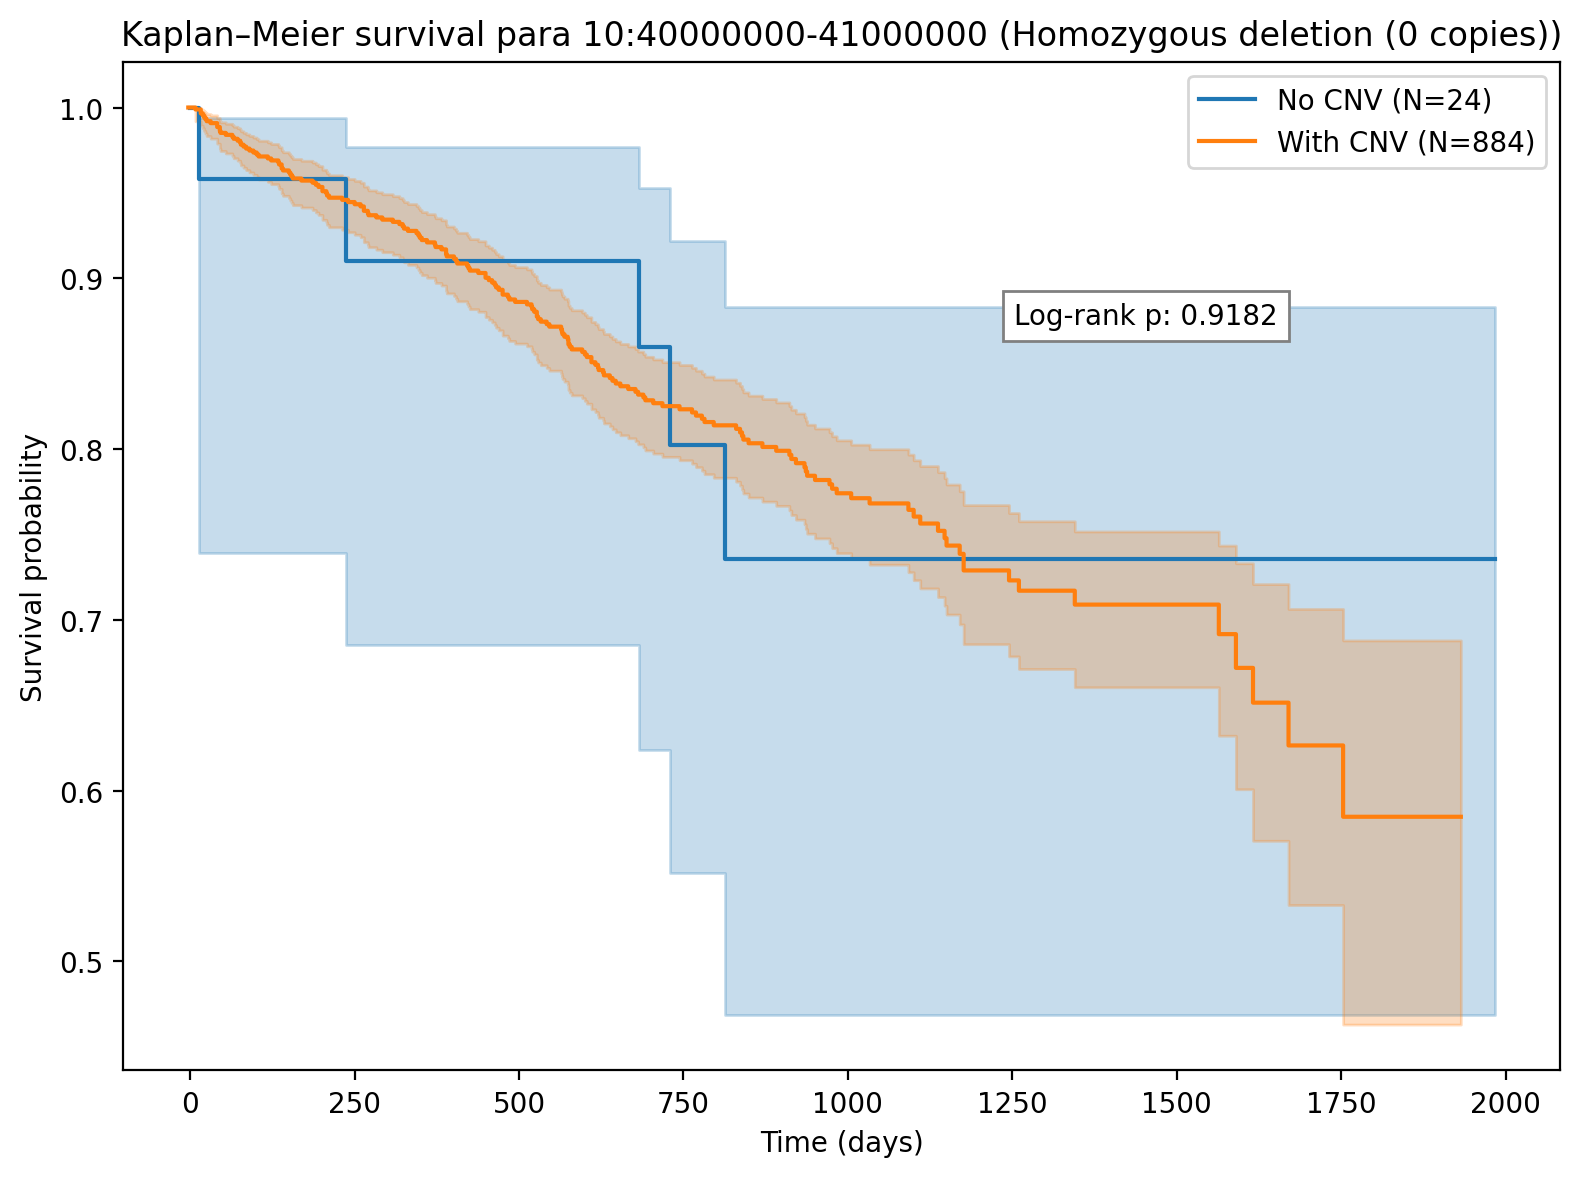

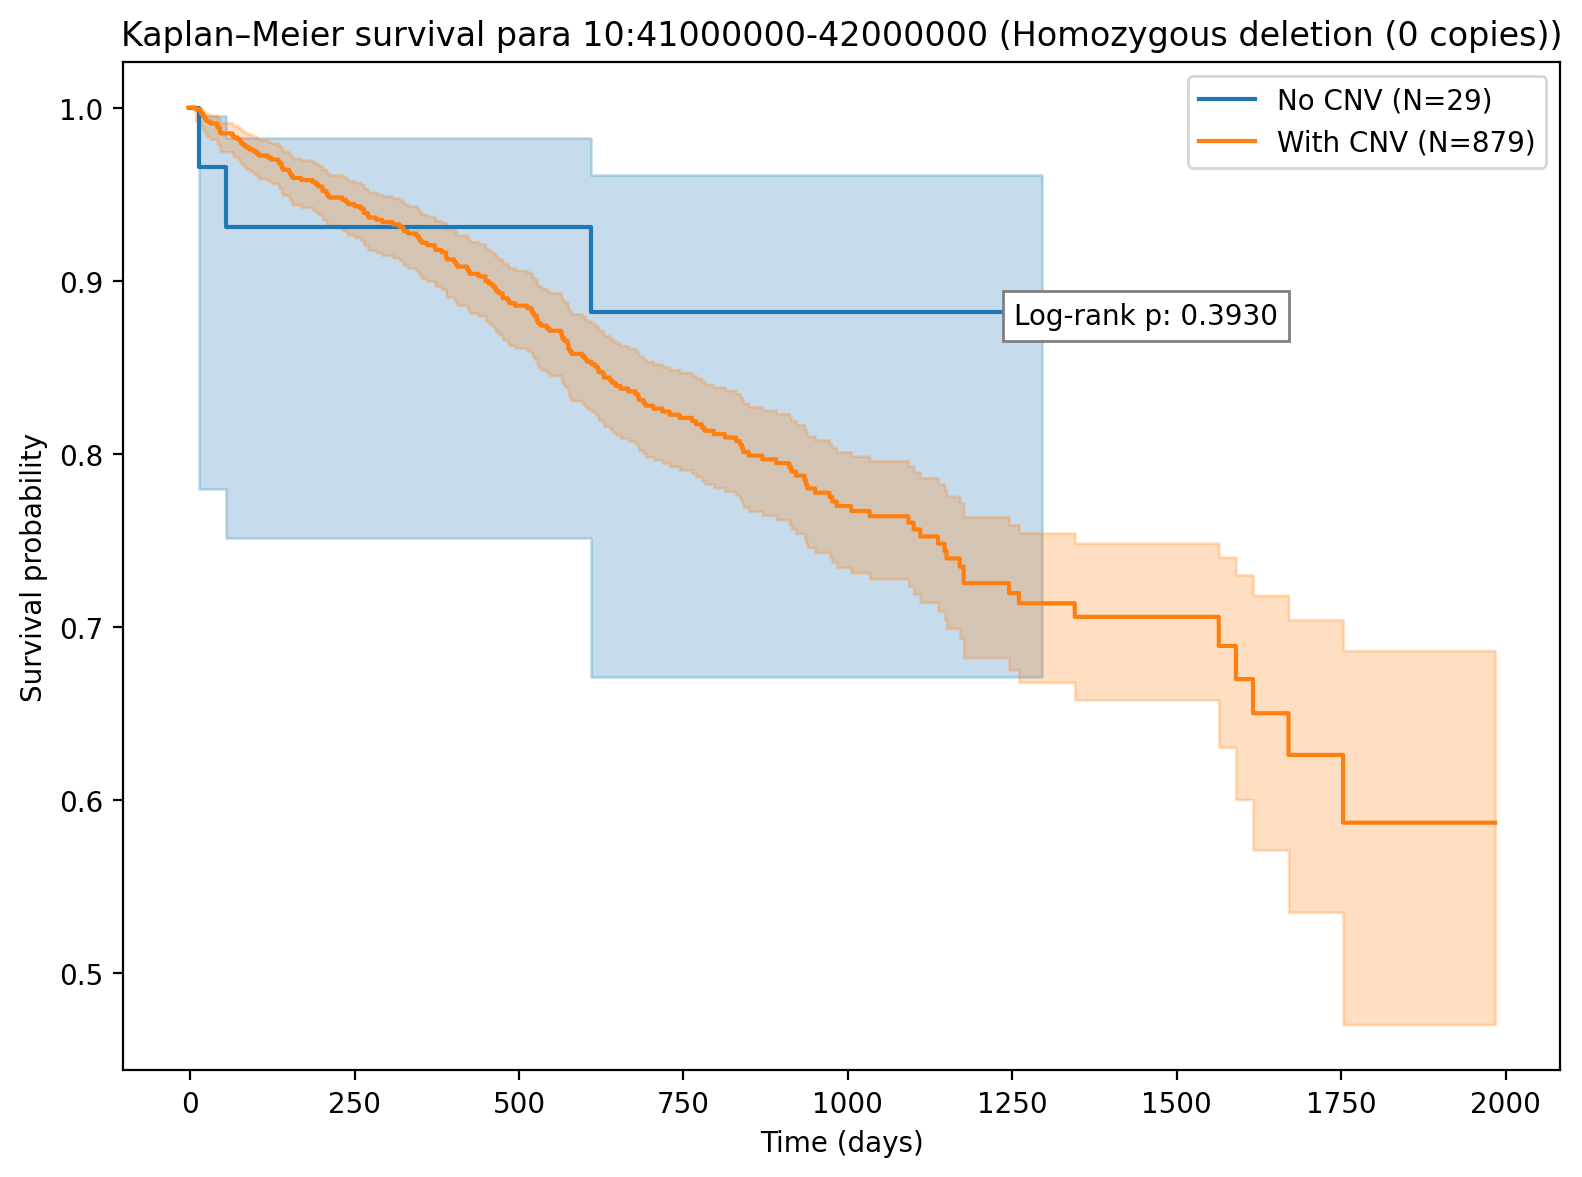

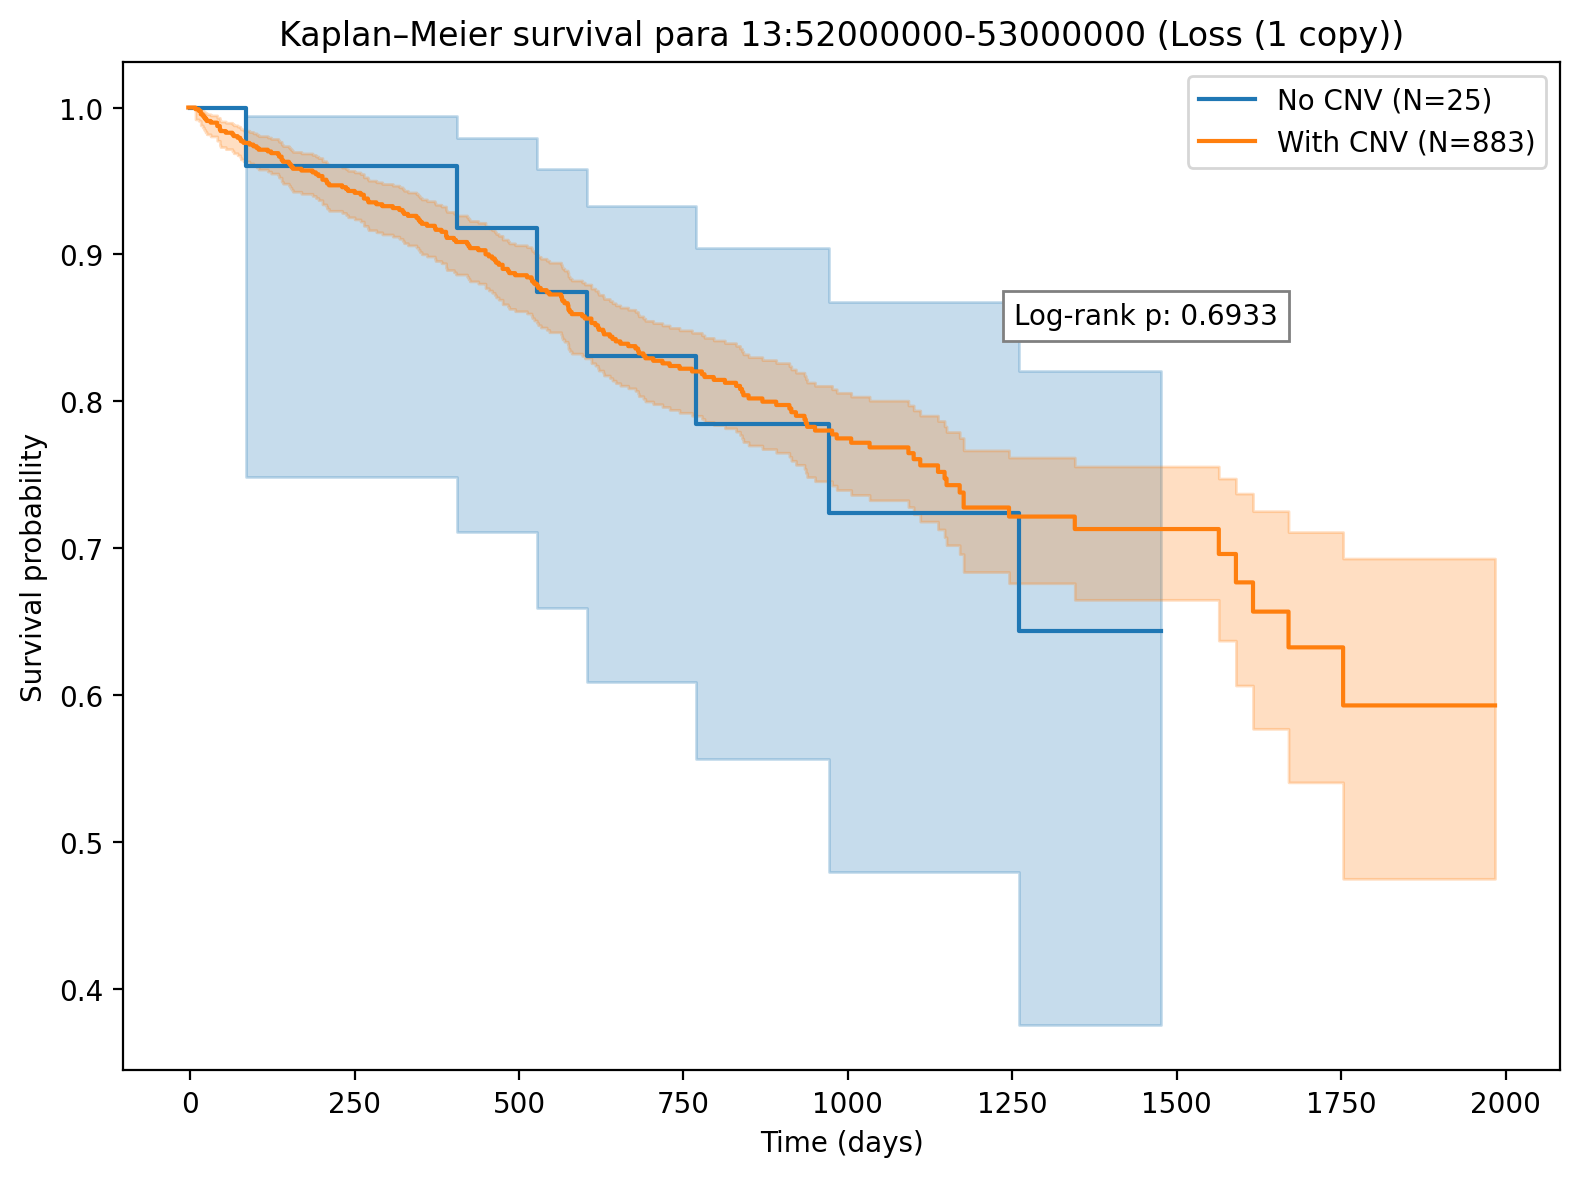

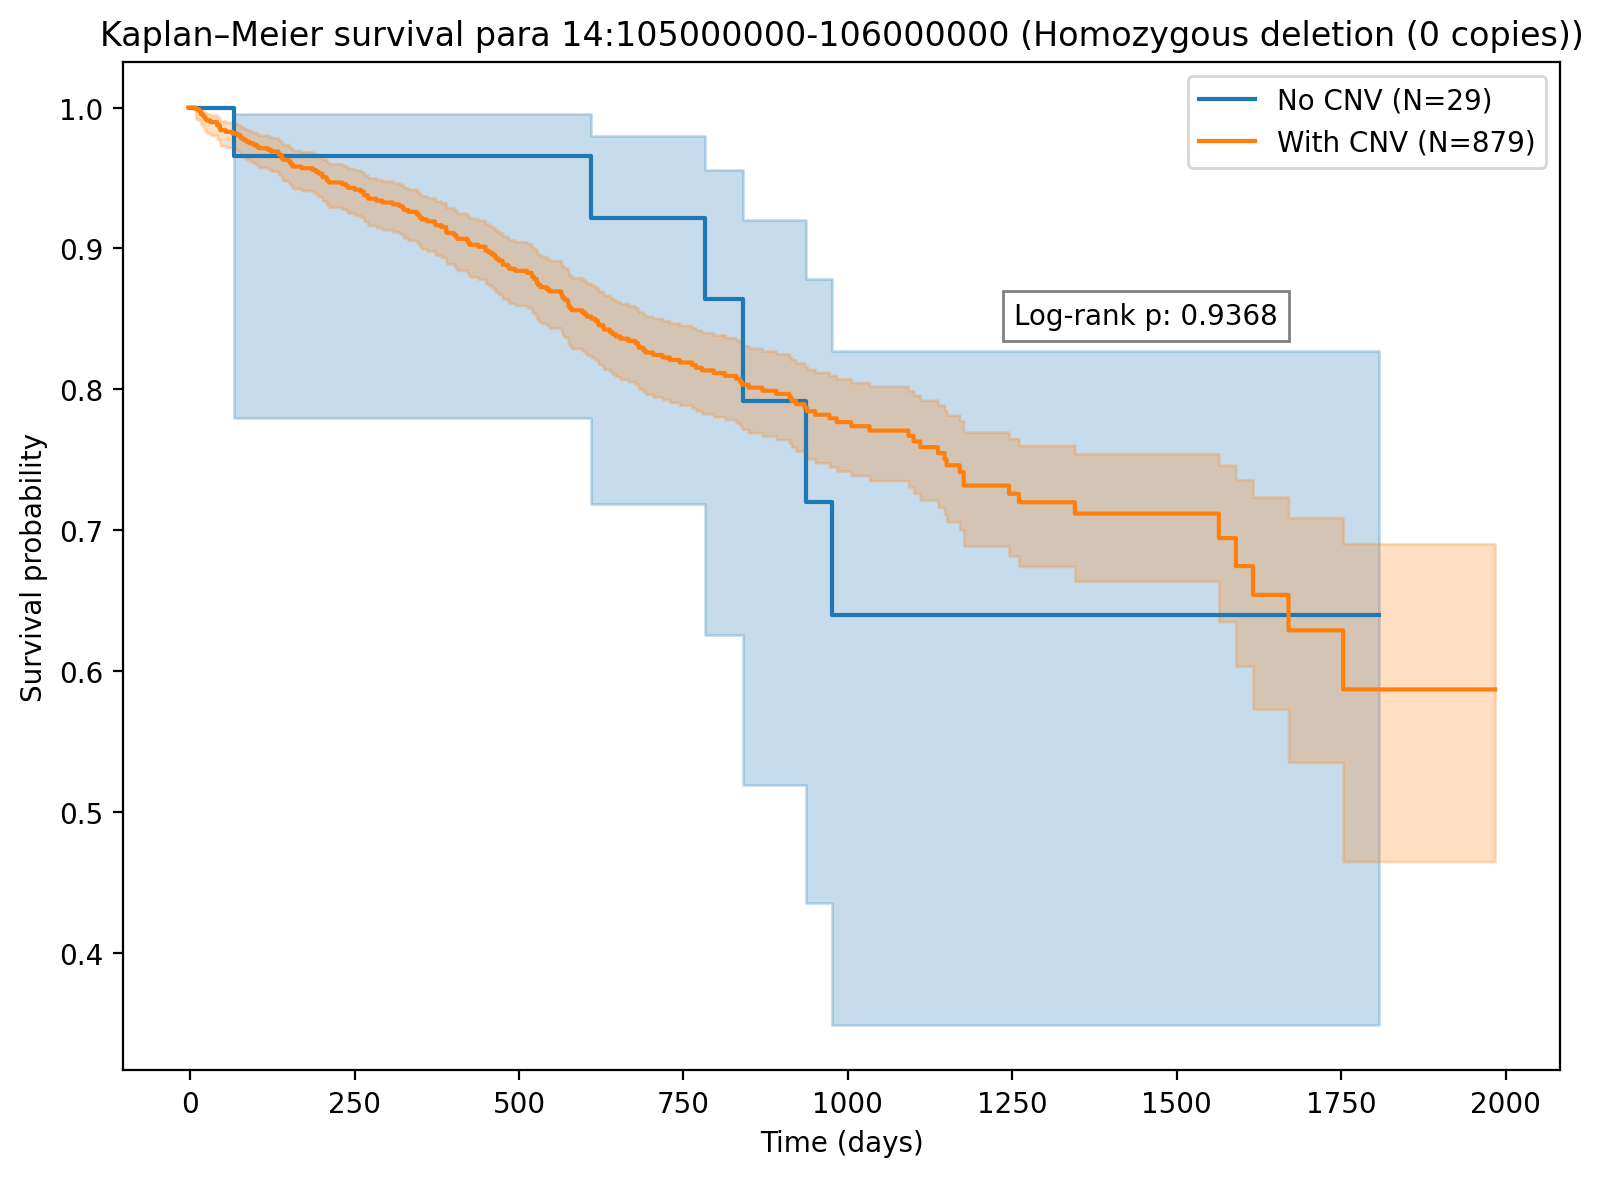

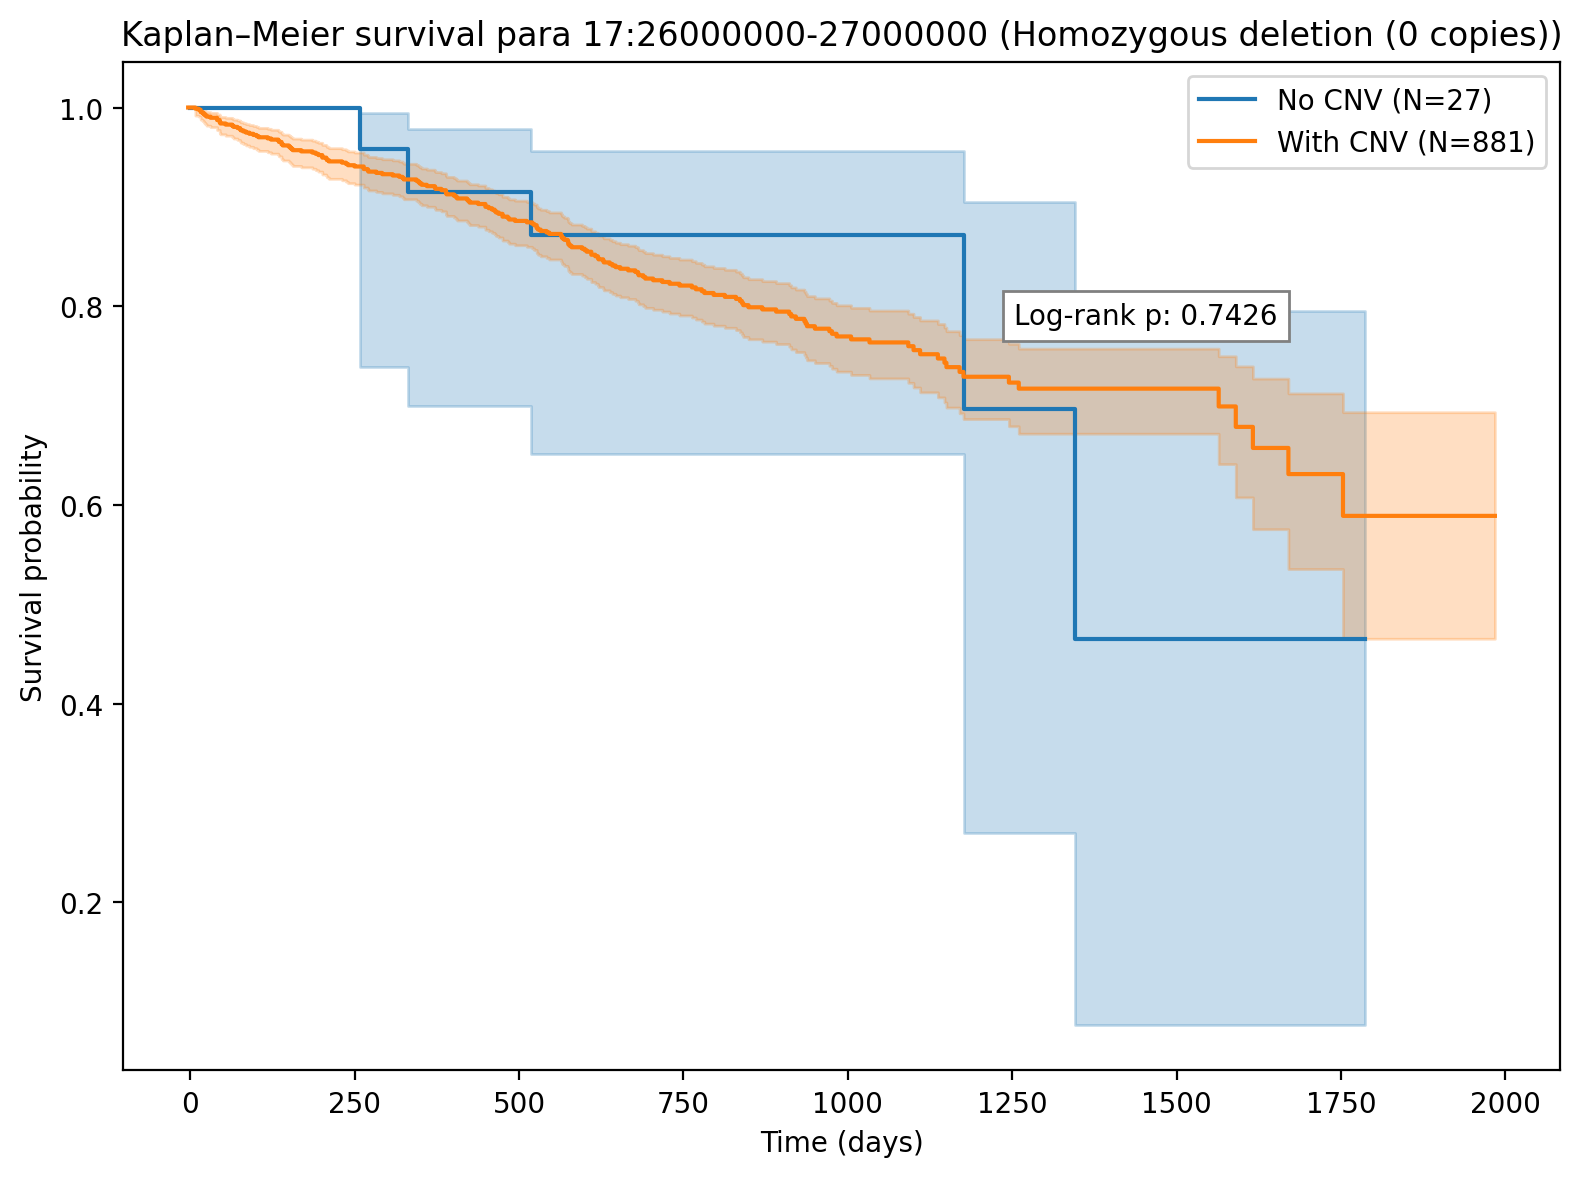

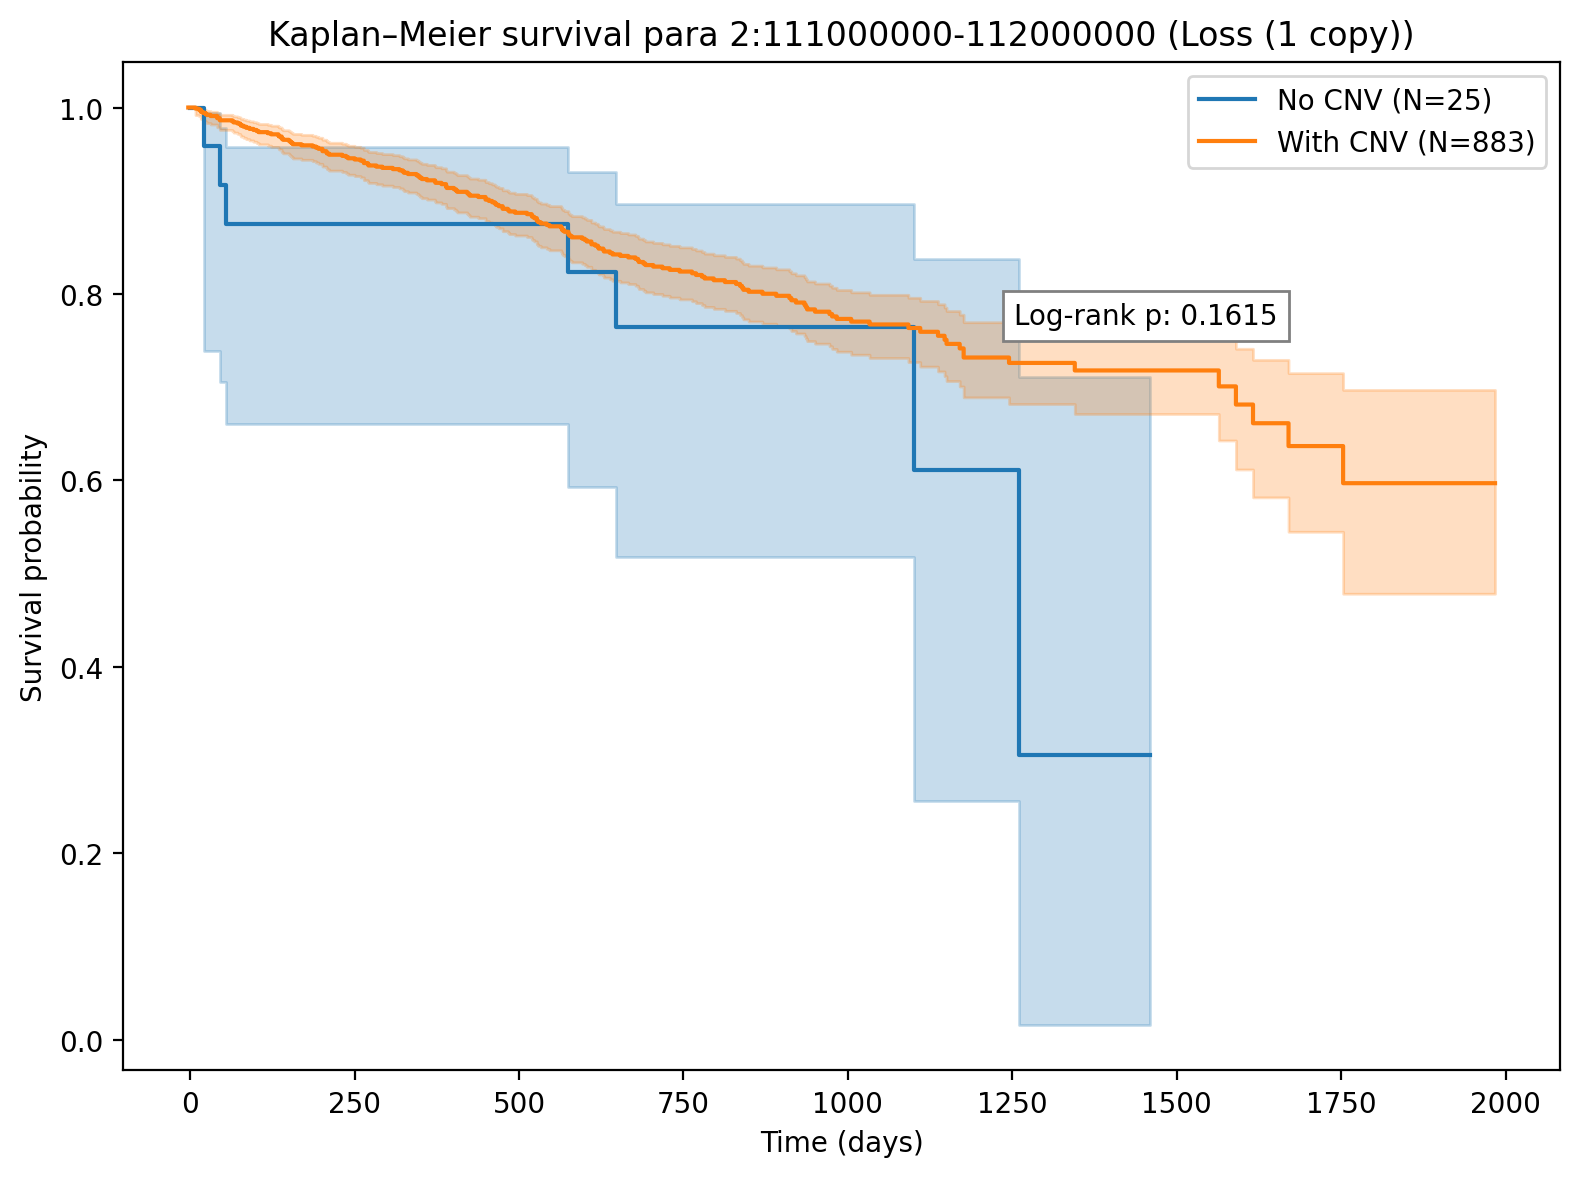

In [ ]:
# =========================================================
# FIND + PREVIEW: KM plots gerados
# =========================================================
import os, glob
from IPython.display import Image, display

RES_DIR = globals().get("RES_DIR", None)
if RES_DIR is None:
    # fallback: try to find the most recent results
    cand = sorted(glob.glob("outputs/run_*/results"), reverse=True)
    if not cand:
        raise RuntimeError("Could not find RES_DIR or outputs/run_*/results.")
    RES_DIR = cand[0]

km_dir = os.path.join(RES_DIR, "KM_TOPCNV_PRESENCE")
print("[INFO] RES_DIR =", RES_DIR)
print("[INFO] KM dir  =", km_dir)

pngs = sorted(glob.glob(os.path.join(km_dir, "*.png")))
print("[OK] PNGs found:", len(pngs))
for p in pngs[:15]:
    print(" -", os.path.basename(p))

# preview of the first 6
for p in pngs[:6]:
    display(Image(filename=p))


In [ ]:
import os, glob, pandas as pd

RES_DIR = globals().get("RES_DIR", None)
if RES_DIR is None:
    cand = sorted(glob.glob("outputs/run_*/results"), reverse=True)
    RES_DIR = cand[0] if cand else None
print("[INFO] RES_DIR =", RES_DIR)

TOP_K = int(globals().get("TOP_K_TOPCNV", 10))
cox_path = os.path.join(RES_DIR, f"top{TOP_K}_recurrent_regions_cox_table.tsv")
print("[INFO] cox_path =", cox_path, "| exists:", os.path.exists(cox_path))

cox_tab = pd.read_csv(cox_path, sep="\t") if os.path.exists(cox_path) else pd.DataFrame()
print("\n[INFO] Cox columns:", list(cox_tab.columns))
display(cox_tab.head(3))

# mostra como os CNV features existem no df_model_base
cnv_cols = [c for c in df_model_base.columns if str(c).startswith("CNV__")]
print("\n[INFO] CNV feature cols em df_model_base:", len(cnv_cols))
print("Exemplos:", cnv_cols[:10])


[INFO] RES_DIR = outputs/run_20260123_154712/results
[INFO] cox_path = outputs/run_20260123_154712/results/top10_recurrent_regions_cox_table.tsv | exists: True

[INFO] Cox columns: ['Region_BinID', 'Chromosome', 'BinStart', 'BinEnd', 'CNV_Type', 'Patients_with_CNV', 'Cohort_N_used', 'Events_used', 'HR', 'CI95_low', 'CI95_high', 'p', 'q_BH', 'Prognosis_from_HR']


,Region_BinID,Chromosome,BinStart,BinEnd,CNV_Type,Patients_with_CNV,Cohort_N_used,Events_used,HR,CI95_low,CI95_high,p,q_BH,Prognosis_from_HR
0,10:41000000-42000000,10,41000000,42000000,Homozygous deletion (0 copies),879,908,177,1.834496,0.585439,5.748465,0.297772,0.910466,Adverse (HR>1)
1,2:111000000-112000000,2,111000000,112000000,Loss (1 copy),883,908,177,0.708799,0.331403,1.515967,0.374897,0.910466,Favorable (HR<1)
2,3:91000000-92000000,3,91000000,92000000,Homozygous deletion (0 copies),881,908,177,1.428155,0.455521,4.477576,0.541020,0.910466,Adverse (HR>1)



[INFO] CNV feature cols em df_model_base: 10
Exemplos: ['CNV__Homozygous_deletion_(0_copies)__10_40000000_41000000', 'CNV__Homozygous_deletion_(0_copies)__10_41000000_42000000', 'CNV__Homozygous_deletion_(0_copies)__14_105000000_106000000', 'CNV__Homozygous_deletion_(0_copies)__17_26000000_27000000', 'CNV__Homozygous_deletion_(0_copies)__3_90000000_91000000', 'CNV__Homozygous_deletion_(0_copies)__3_91000000_92000000', 'CNV__Loss_(1_copy)__13_52000000_53000000', 'CNV__Loss_(1_copy)__2_111000000_112000000', 'CNV__Loss_(1_copy)__2_113000000_114000000', 'CNV__Loss_(1_copy)__4_49000000_50000000']


## (DEPRECATED) Build prediction dataset (old version)

This cell was deprecated because it depended on `BANNER_TOP_PATH` and may raise an error if that variable is not defined.

**Use the next cell (`22.9) BUILD df_pred (BASELINE CNV FEATURES + LOCUS TOP-K)`) instead.**


In [ ]:
# =========================================================
# PREDICTION DATASET: global features (BP/hotspots/age/sex) + locus TOP-K (1Mb bins)
# - Builds df_pred for the predictive models section
# - If the TOP-K file is missing, it is generated from the patient-bin overlap table
# Outputs are saved in RES_DIR
# =========================================================

import os
import re
import numpy as np
import pandas as pd

# --- directories ---
RES_DIR  = globals().get("RES_DIR") or os.path.join(globals().get("OUT_DIR", os.getcwd()), "results")
PROC_DIR = globals().get("PROC_DIR") or os.path.join(globals().get("BASE_OUT_DIR", os.getcwd()), "processed")
os.makedirs(RES_DIR, exist_ok=True)

# --- parameters ---
BIN_SIZE   = int(globals().get("BIN_SIZE", 1_000_000))
BIN_MB     = BIN_SIZE // 1_000_000
TOP_K_PRED = int(globals().get("TOP_K_PRED", 50))  # increase to 100 if needed

# --- base features ---
merged_path = os.path.join(RES_DIR, "survival_features_merged.tsv")
if "features_df" in globals() and isinstance(features_df, pd.DataFrame) and not features_df.empty:
    base = features_df.copy()
elif os.path.exists(merged_path):
    base = pd.read_csv(merged_path, sep="\t")
else:
    raise FileNotFoundError("Missing base features: neither `features_df` in memory nor `survival_features_merged.tsv` in RES_DIR.")

# (optional) bring ISS from os_df (survival_features_merged.tsv may not include it)
if "os_df" in globals() and isinstance(os_df, pd.DataFrame) and "diagnoses.iss_stage" in os_df.columns:
    base = base.merge(os_df[["Participant_ID", "diagnoses.iss_stage"]], on="Participant_ID", how="left")

# --- locus table inputs ---
edges_path = os.path.join(PROC_DIR, f"cnv_patient_bin_overlaps_{BIN_MB}Mb.tsv")
top_path   = os.path.join(RES_DIR,  f"top{TOP_K_PRED}_recurrent_regions_by_bins_{BIN_MB}Mb.tsv")

if not os.path.exists(edges_path):
    raise FileNotFoundError(f"Missing overlap table: {edges_path}. Run the CNV x bin overlap export step first.")

# read edges with safer dtypes (avoid mixed-type warnings)
edges = pd.read_csv(edges_path, sep="\t", low_memory=False)

# detect required columns robustly
cols = {c.lower(): c for c in edges.columns}
participant_col = cols.get("participant_id") or cols.get("participant") or cols.get("patient_id")
bin_col = cols.get("binid") or cols.get("bin_id") or cols.get("bin")
type_col = cols.get("cnv_type_ajustado") or cols.get("cnv_type") or cols.get("type")

missing = [x for x in [participant_col, bin_col, type_col] if x is None]
if missing:
    raise RuntimeError(f"Could not detect required columns in overlap table. Found columns: {list(edges.columns)[:40]}")

# normalize dtypes
edges[participant_col] = edges[participant_col].astype(str)
edges[bin_col] = edges[bin_col].astype(str)
edges[type_col] = edges[type_col].astype(str)

# --- build TOP-K if missing ---
if not os.path.exists(top_path):
    n_total = int(edges[participant_col].nunique())
    freq = (
        edges.groupby([bin_col, type_col])[participant_col]
        .nunique()
        .reset_index(name="n_patients")
    )
    freq["pct_patients"] = (freq["n_patients"] / max(n_total, 1)) * 100.0
    freq = freq.sort_values(["pct_patients", "n_patients"], ascending=False).head(TOP_K_PRED).copy()

    # standardize column names for downstream
    freq = freq.rename(columns={bin_col: "BinID", type_col: "CNV_Type"})
    freq.to_csv(top_path, sep="\t", index=False)
    print("[OK] TOP-K recurrent regions file generated:", top_path)
else:
    freq = pd.read_csv(top_path, sep="\t")
    # accept either legacy or new column naming
    if "BinID" not in freq.columns:
        if bin_col in freq.columns:
            freq = freq.rename(columns={bin_col: "BinID"})
    if "CNV_Type" not in freq.columns:
        if type_col in freq.columns:
            freq = freq.rename(columns={type_col: "CNV_Type"})
    print("[OK] TOP-K recurrent regions file found:", top_path)

# --- make safe variable names: CNV__<TYPE>__<BinID> ---
def _slug(s: str) -> str:
    s = str(s)
    s = s.replace(":", "_").replace("-", "_").replace(" ", "_")
    s = re.sub(r"[^0-9a-zA-Z_]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s

freq = freq.copy()
freq["var"] = "CNV__" + freq["CNV_Type"].map(_slug) + "__" + freq["BinID"].map(_slug)

keep = freq[["BinID", "CNV_Type", "var"]].drop_duplicates()

# align edges column names to expected "BinID"/"CNV_Type"
edges2 = edges.rename(columns={bin_col: "BinID", type_col: "CNV_Type", participant_col: "Participant_ID"}).copy()

edges2 = (
    edges2.merge(keep, on=["BinID", "CNV_Type"], how="inner")
         .drop_duplicates(["Participant_ID", "var"])
)
edges2["val"] = 1

X_locus = (
    edges2.pivot(index="Participant_ID", columns="var", values="val")
    .fillna(0).astype(int)
    .reset_index()
)

df_pred = base.merge(X_locus, on="Participant_ID", how="left")
locus_cols = [c for c in df_pred.columns if c.startswith("CNV__")]
df_pred[locus_cols] = df_pred[locus_cols].fillna(0).astype(int)

# --- save dataset for auditability ---
pred_path = os.path.join(RES_DIR, f"prediction_dataset_top{TOP_K_PRED}_bins{BIN_MB}Mb.tsv")
df_pred.to_csv(pred_path, sep="\t", index=False)

print("[OK] df_pred:", df_pred.shape, "| locus cols:", len(locus_cols))
print("[OK] saved:", pred_path)
df_pred.head()


[OK] TOP-K recurrent regions file generated: outputs/run_20260123_154712/results/top50_recurrent_regions_by_bins_1Mb.tsv
[OK] df_pred: (995, 64) | locus cols: 50
[OK] saved: outputs/run_20260123_154712/results/prediction_dataset_top50_bins1Mb.tsv


,Participant_ID,__JOIN_ID__,time,event,age,sex,BP_total,BP_unique,BP_entropy_chr,BP_gini_chr,...,CNV__Loss_1_copy__21_8000000_9000000,CNV__Loss_1_copy__22_12000000_13000000,CNV__Loss_1_copy__22_15000000_16000000,CNV__Loss_1_copy__2_111000000_112000000,CNV__Loss_1_copy__2_113000000_114000000,CNV__Loss_1_copy__2_87000000_88000000,CNV__Loss_1_copy__2_89000000_90000000,CNV__Loss_1_copy__2_91000000_92000000,CNV__Loss_1_copy__4_0_1000000,CNV__Loss_1_copy__4_49000000_50000000
0,MMRF_XXXX,MMRF_XXXX,692.0,1,56,male,554.0,554.0,0.868405,0.472139,...,1,1,1,1,1,1,1,1,1,1
1,MMRF_XXXX,MMRF_XXXX,1826.0,0,60,male,1782.0,1778.0,0.642564,0.711420,...,1,1,1,1,1,1,1,1,1,1
2,MMRF_XXXX,MMRF_XXXX,1932.0,0,54,female,828.0,828.0,0.783149,0.581119,...,1,1,1,1,1,1,1,1,1,1
3,MMRF_XXXX,MMRF_XXXX,1927.0,0,79,female,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
4,MMRF_XXXX,MMRF_XXXX,995.0,0,46,male,882.0,879.0,0.756149,0.621710,...,1,1,1,1,1,1,1,1,1,1


In [ ]:
# =========================================================
# 23) PREDICTION MODELS (OPTIONAL / REPORTABLE)  [ANTI-LEAK + STABILITY]
#  - Survival risk prediction (penalized Cox) -> test C-index (no leakage)
#  - ISS stage prediction (multiclass) -> macro-F1 / accuracy
#  Outputs saved in RES_DIR
# =========================================================

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression

from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

np.random.seed(42)

# ---------------------------------------------------------
# A) Ensure RES_DIR exists
# ---------------------------------------------------------
RES_DIR = globals().get("RES_DIR") or os.path.join(globals().get("OUT_DIR", os.getcwd()), "results")
os.makedirs(RES_DIR, exist_ok=True)

# ---------------------------------------------------------
# 0) Get df_pred (preferred) or df_ml
# ---------------------------------------------------------
if "df_pred" in globals() and isinstance(df_pred, pd.DataFrame) and not df_pred.empty:
    df_model = df_pred.copy()
elif "df_ml" in globals() and isinstance(df_ml, pd.DataFrame) and not df_ml.empty:
    df_model = df_ml.copy()
else:
    raise RuntimeError("Missing `df_pred` and `df_ml`. Run the prediction dataset build cell before this block.")

# ---------------------------------------------------------
# 1) Required survival columns
# ---------------------------------------------------------
req = ["Participant_ID", "time", "event"]
for c in req:
    if c not in df_model.columns:
        raise RuntimeError(f"Dataset is missing required column: {c}")

df_model = df_model.dropna(subset=["time", "event"]).copy()
df_model = df_model[df_model["time"] >= 0].copy()
df_model["event"] = df_model["event"].astype(int)

# ---------------------------------------------------------
# 2) Numeric features (exclude ID/time/event)
# ---------------------------------------------------------
drop_cols = {"Participant_ID", "time", "event"}
feat_cols = [
    c for c in df_model.columns
    if c not in drop_cols and pd.api.types.is_numeric_dtype(df_model[c])
]

# remove constants
feat_cols = [c for c in feat_cols if df_model[c].nunique(dropna=True) > 1]
if len(feat_cols) < 5:
    raise RuntimeError(f"Too few numeric features detected: {feat_cols}")

# ---------------------------------------------------------
# 3) Survival HOLDOUT split (stratified by event)
# ---------------------------------------------------------
train_idx, test_idx = train_test_split(
    df_model.index, test_size=0.25, random_state=42,
    stratify=df_model["event"].values
)
tr = df_model.loc[train_idx].copy()
te = df_model.loc[test_idx].copy()

# ---------------------------------------------------------
# 4) ANTI-LEAKAGE: remove post-baseline / follow-up / outcome-derived fields
# ---------------------------------------------------------
leak_patterns = [
    "days_to_death", "death", "deceased",
    "days_to_last_follow_up", "last_follow_up",
    "follow_up_time", "follow_ups", "follow_up", "days_to_follow_up",
    "time_to", "os_time", "pfs_time",
    "overall_survival", "progression_free"
]

feat_before = feat_cols[:]

# 4.1 drop by name patterns
feat_cols = [c for c in feat_cols if not any(p in c.lower() for p in leak_patterns)]
removed_by_pattern = sorted(list(set(feat_before) - set(feat_cols)))

# 4.2 near-zero variance in TRAIN
var_series = tr[feat_cols].var(numeric_only=True)
near_zero = var_series[var_series.fillna(0) < 1e-12].index.tolist()
feat_cols = [c for c in feat_cols if c not in near_zero]

# 4.3 highly correlated with time in TRAIN (often proxy/leakage)
tmp = tr[feat_cols + ["time"]].copy()
corr = tmp.corr(numeric_only=True)["time"].drop("time")
high_corr = corr[abs(corr) > 0.95].index.tolist()
feat_cols = [c for c in feat_cols if c not in high_corr]

# 4.4 too many missing values in TRAIN
na_rate = tr[feat_cols].isna().mean()
too_many_na = na_rate[na_rate > 0.60].index.tolist()
feat_cols = [c for c in feat_cols if c not in too_many_na]

print("\n[ANTI-LEAK SUMMARY]")
print("Features before:", len(feat_before))
print("Removed by pattern:", len(removed_by_pattern), "| ex:", removed_by_pattern[:8])
print("Removed near-zero var:", len(near_zero), "| ex:", near_zero[:8])
print("Removed corr(|time|)>0.95:", len(high_corr), "| ex:", high_corr[:8])
print("Removed NA>60%:", len(too_many_na), "| ex:", too_many_na[:8])
print("Features after anti-leak:", len(feat_cols))

if len(feat_cols) < 5:
    raise RuntimeError("Too few features after anti-leakage filters. Review patterns/filters or feature set.")

# keep a copy for ISS BEFORE Cox-only stabilization
feat_cols_iss = feat_cols[:]  # ISS uses the full anti-leak feature set

# save final anti-leak feature list (Methods / auditability)
feat_list_path = os.path.join(RES_DIR, "pred_features_used_survival.txt")
with open(feat_list_path, "w") as f:
    f.write("\n".join(feat_cols))
print("[OK] survival features saved:", feat_list_path)

# =========================================================
# 4B) EXTRA STABILITY FOR COX (SURVIVAL ONLY)
# - remove very rare binary features (low prevalence)
# - remove high collinearity among features
# - remove simple complete separation patterns (binary)
# =========================================================

# 1) remove very rare binary features in TRAIN (e.g., <3% ones)
rare_thresh = 0.03
rare = []
for c in feat_cols:
    s = tr[c]
    vals = set(pd.Series(s.dropna().unique()).tolist())
    if vals.issubset({0, 1}):
        freq = float(s.mean())
        if freq < rare_thresh:
            rare.append(c)

feat_cols = [c for c in feat_cols if c not in rare]
print(f"[COX-STAB] removed rare binaries (<{rare_thresh*100:.1f}% ones):", len(rare))

# 2) remove high collinearity among features (TRAIN)
Xcorr = tr[feat_cols].corr(numeric_only=True).abs()
upper = Xcorr.where(np.triu(np.ones(Xcorr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
feat_cols = [c for c in feat_cols if c not in to_drop]
print("[COX-STAB] removed by collinearity > 0.95:", len(to_drop))

# 3) remove binary features with (almost) complete separation wrt event
sep = []
for c in feat_cols:
    s = tr[c]
    vals = set(pd.Series(s.dropna().unique()).tolist())
    if vals.issubset({0, 1}):
        e1 = tr.loc[tr["event"] == 1, c].dropna()
        e0 = tr.loc[tr["event"] == 0, c].dropna()
        if len(e1) > 0 and len(e0) > 0:
            # if one group has almost no 1s or almost all 1s while the other is opposite
            p1 = float(e1.mean())
            p0 = float(e0.mean())
            if (p1 < 0.01 and p0 > 0.99) or (p0 < 0.01 and p1 > 0.99) or (p1 > 0.99 and p0 < 0.01) or (p0 > 0.99 and p1 < 0.01):
                sep.append(c)

feat_cols = [c for c in feat_cols if c not in sep]
print("[COX-STAB] removed by separation (binary):", len(sep), "| ex:", sep[:8])

print("[COX-STAB] survival features after stabilization:", len(feat_cols))

# ---------------------------------------------------------
# 5) Penalized Cox (CV for penalizer/l1_ratio) + TEST C-index
# ---------------------------------------------------------
def fit_eval_cox(train_df, test_df, feats, penalizer, l1_ratio):
    imp = SimpleImputer(strategy="median")
    sca = StandardScaler()

    Xtr = sca.fit_transform(imp.fit_transform(train_df[feats]))
    Xte = sca.transform(imp.transform(test_df[feats]))

    tr2 = train_df[["time", "event"]].copy()
    te2 = test_df[["time", "event"]].copy()
    tr2[feats] = Xtr
    te2[feats] = Xte

    try:
        cph = CoxPHFitter(penalizer=penalizer, l1_ratio=l1_ratio)
    except TypeError:
        cph = CoxPHFitter(penalizer=penalizer)

    cph.fit(tr2, duration_col="time", event_col="event")
    risk = cph.predict_partial_hazard(te2).values.ravel()
    cidx = concordance_index(te2["time"].values, -risk, te2["event"].values)
    return float(cidx), cph, risk

# avoid unpenalized Cox (often unstable)
pen_grid = [0.05, 0.1, 0.5, 1.0, 5.0]
l1_grid  = [0.0, 0.5]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_event = tr["event"].values

best = {"mean_cv_cindex": -np.inf, "penalizer": None, "l1_ratio": None}
rows = []

for pen in pen_grid:
    for l1 in l1_grid:
        scores = []
        for tr_i, va_i in cv.split(tr.index, y_event):
            df_tr = tr.iloc[tr_i]
            df_va = tr.iloc[va_i]
            try:
                cidx, _, _ = fit_eval_cox(df_tr, df_va, feat_cols, penalizer=pen, l1_ratio=l1)
                scores.append(cidx)
            except Exception:
                continue
        if scores:
            m = float(np.mean(scores))
            rows.append({"penalizer": pen, "l1_ratio": l1, "mean_cv_cindex": m, "n_folds_used": len(scores)})
            if m > best["mean_cv_cindex"]:
                best.update({"mean_cv_cindex": m, "penalizer": pen, "l1_ratio": l1})

cv_df = pd.DataFrame(rows).sort_values("mean_cv_cindex", ascending=False)
cv_path = os.path.join(RES_DIR, "pred_survival_cox_cv_grid.tsv")
cv_df.to_csv(cv_path, sep="\t", index=False)

cidx_test, cph_final, risk_test = fit_eval_cox(tr, te, feat_cols, best["penalizer"], best["l1_ratio"])

coef = cph_final.summary.reset_index().rename(columns={"index": "feature"})
coef_path = os.path.join(RES_DIR, "pred_survival_cox_coefficients.tsv")
coef.to_csv(coef_path, sep="\t", index=False)

risk_out = te[["Participant_ID", "time", "event"]].copy()
risk_out["risk_score"] = risk_test
risk_path = os.path.join(RES_DIR, "pred_survival_test_risk_scores.tsv")
risk_out.to_csv(risk_path, sep="\t", index=False)

perf_path = os.path.join(RES_DIR, "pred_survival_performance.tsv")
pd.DataFrame([{
    "model": "Penalized Cox (ANTI-LEAK)",
    "n_train": int(tr.shape[0]),
    "n_test": int(te.shape[0]),
    "events_train": int(tr["event"].sum()),
    "events_test": int(te["event"].sum()),
    "best_penalizer": best["penalizer"],
    "best_l1_ratio": best["l1_ratio"],
    "cv_mean_cindex": float(best["mean_cv_cindex"]),
    "test_cindex": float(cidx_test),
    "n_features": int(len(feat_cols))
}]).to_csv(perf_path, sep="\t", index=False)

print("\n[OK] Survival prediction (ANTI-LEAK)")
print(" - CV mean C-index:", round(best["mean_cv_cindex"], 4))
print(" - TEST C-index   :", round(cidx_test, 4))
print(" - cv:", cv_path)
print(" - coef:", coef_path)
print(" - risk:", risk_path)
print(" - perf:", perf_path)

# ---------------------------------------------------------
# 6) ISS prediction (if available) using FULL anti-leak feature set
# ---------------------------------------------------------
iss_candidates = ["diagnoses.iss_stage", "iss_stage", "ISS", "ISS_stage"]
iss_col = next((c for c in iss_candidates if c in df_model.columns), None)

if iss_col is None:
    print("\n[INFO] ISS stage not found. Skipping ISS classifier.")
else:
    df_iss = df_model.dropna(subset=[iss_col]).copy()
    y = df_iss[iss_col].astype(str).values
    X = df_iss[feat_cols_iss].copy()

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    pipe = Pipeline(steps=[
        ("imp", SimpleImputer(strategy="median")),
        ("sca", StandardScaler()),
        ("sel", SelectKBest(score_func=mutual_info_classif, k=min(50, X_tr.shape[1]))),
        ("clf", LogisticRegression(
            max_iter=20000,
            solver="lbfgs",
            class_weight="balanced",
            multi_class="multinomial"
        ))
    ])

    # light tuning
    k_grid = [25, 50, 100]
    C_grid = [0.1, 1.0, 10.0]
    cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    best2 = {"cv_macro_f1": -np.inf, "k": None, "C": None}
    for k in k_grid:
        for C in C_grid:
            pipe.set_params(sel__k=min(k, X_tr.shape[1]), clf__C=C)
            f1s = []
            for a, b in cv2.split(X_tr, y_tr):
                pipe.fit(X_tr.iloc[a], y_tr[a])
                pred = pipe.predict(X_tr.iloc[b])
                f1s.append(f1_score(y_tr[b], pred, average="macro"))
            m = float(np.mean(f1s))
            if m > best2["cv_macro_f1"]:
                best2.update({"cv_macro_f1": m, "k": k, "C": C})

    pipe.set_params(sel__k=min(best2["k"], X_tr.shape[1]), clf__C=best2["C"])
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1m = f1_score(y_te, y_pred, average="macro")

    labels = np.unique(y)  # stable label ordering
    cm = confusion_matrix(y_te, y_pred, labels=labels)

    iss_perf_path = os.path.join(RES_DIR, "pred_iss_performance.tsv")
    pd.DataFrame([{
        "model": "LogReg + SelectKBest (ANTI-LEAK features)",
        "iss_col": iss_col,
        "best_k": best2["k"],
        "best_C": best2["C"],
        "cv_macro_f1": best2["cv_macro_f1"],
        "test_accuracy": float(acc),
        "test_macro_f1": float(f1m),
        "n_train": int(len(y_tr)),
        "n_test": int(len(y_te)),
        "n_features": int(X.shape[1])
    }]).to_csv(iss_perf_path, sep="\t", index=False)

    iss_rep_path = os.path.join(RES_DIR, "pred_iss_classification_report.txt")
    with open(iss_rep_path, "w") as f:
        f.write(classification_report(y_te, y_pred, zero_division=0))

    iss_cm_path = os.path.join(RES_DIR, "pred_iss_confusion_matrix.tsv")
    pd.DataFrame(cm, index=labels, columns=labels).to_csv(iss_cm_path, sep="\t")

    print("\n[OK] ISS prediction (ANTI-LEAK features)")
    print(" - TEST accuracy:", round(float(acc), 4), "| macro-F1:", round(float(f1m), 4))
    print(" - report:", iss_rep_path)
    print(" - cm:", iss_cm_path)
    print(" - perf:", iss_perf_path)



[ANTI-LEAK SUMMARY]
Features before: 58
Removed by pattern: 0 | ex: []
Removed near-zero var: 0 | ex: []
Removed corr(|time|)>0.95: 0 | ex: []
Removed NA>60%: 0 | ex: []
Features after anti-leak: 58
[OK] survival features saved: outputs/run_20260123_154712/results/pred_features_used_survival.txt
[COX-STAB] removed rare binaries (<3.0% ones): 0
[COX-STAB] removed by collinearity > 0.95: 13
[COX-STAB] removed by separation (binary): 0 | ex: []
[COX-STAB] survival features after stabilization: 45


/usr/local/lib/python3.12/dist-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(



[OK] Survival prediction (ANTI-LEAK)
 - CV mean C-index: 0.6308
 - TEST C-index   : 0.5681
 - cv: outputs/run_20260123_154712/results/pred_survival_cox_cv_grid.tsv
 - coef: outputs/run_20260123_154712/results/pred_survival_cox_coefficients.tsv
 - risk: outputs/run_20260123_154712/results/pred_survival_test_risk_scores.tsv
 - perf: outputs/run_20260123_154712/results/pred_survival_performance.tsv


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[OK] ISS prediction (ANTI-LEAK features)
 - TEST accuracy: 0.3534 | macro-F1: 0.306
 - report: outputs/run_20260123_154712/results/pred_iss_classification_report.txt
 - cm: outputs/run_20260123_154712/results/pred_iss_confusion_matrix.tsv
 - perf: outputs/run_20260123_154712/results/pred_iss_performance.tsv


# Hyperdiploidy (HRD) classification — Multiple Myeloma

This module classifies each patient as **HRD** (hyperdiploid) or **non-HRD** based on the standard IMWG/IFM criterion: presence of trisomies in at least 2 of the 8 "odd chromosomes" associated with hyperdiploid MM (chromosomes 3, 5, 7, 9, 11, 15, 19, 21) [Wuilleme et al. 2005; Avet-Loiseau et al. 2007].

## Methodological note on the threshold used

Whole-chromosome trisomy detection uses a **relaxed log2 threshold of +0.3** (rather than the +0.5 used for focal CNV calls). Rationale:

- Theoretical log2(3/2) = 0.585 assumes 100% tumor purity. With typical MM plasma cell infiltration (60–80%) and germline-normalized relative copy number data, observed log2 for arm-level trisomies attenuates to ~0.25–0.35.
- Using +0.5 underestimates HRD frequency (~20%) compared to literature (~50–55% in MMRF CoMMpass).
- The +0.3 threshold restores agreement with Skerget et al. 2024 and IFM benchmarks (HRD ~55%, per-chromosome trisomy frequencies within 5% of published values).

This is consistent with the general principle that focal and arm-level CNVs require different thresholds in purity-uncalibrated data.

**Outputs** (in `results/hrd/`):
- `hrd_classification.tsv` — per-patient HRD status, trisomy pattern, fractions gained
- `hrd_frequency_validation.tsv` — comparison with literature benchmarks
- `hrd_summary.png` — Supplementary Figure: HRD distribution + Kaplan-Meier survival by HRD status

**Inserted before the sensitivity analysis** so that `HRD_status` becomes available as a covariate in downstream Cox models.

In [ ]:
# =========================================================
# HRD) Define criteria and chromosome sizes (GRCh38)
# =========================================================
HRD_DIR = os.path.join(RES_DIR, "hrd")
os.makedirs(HRD_DIR, exist_ok=True)

# Human chromosome sizes in Mb (GRCh38) — used to compute "fraction gained"
CHR_SIZES_MB = {
    "1":248.9, "2":242.2, "3":198.3, "4":190.2, "5":181.5, "6":170.8,
    "7":159.3, "8":145.1, "9":138.4, "10":133.8, "11":135.1, "12":133.3,
    "13":114.4, "14":107.0, "15":101.9, "16":90.3, "17":83.3, "18":80.4,
    "19":58.6, "20":64.4, "21":46.7, "22":50.8, "X":156.0, "Y":57.2
}

# Odd chromosomes associated with hyperdiploid MM (Wuilleme 2005, IMWG criteria)
HRD_ODD_CHROMS = ["3", "5", "7", "9", "11", "15", "19", "21"]

# Trisomy detection parameters
HRD_GAIN_LOG2_THRESHOLD = 0.3   # relaxed for arm-level events (see note above)
HRD_MIN_FRACTION_GAINED = 0.50  # ≥50% of the chromosome must be gained to call trisomy
HRD_MIN_TRISOMIES = 2           # ≥2 odd-chromosome trisomies = HRD

print("[HRD] Classification parameters:")
print(f"  Odd chromosomes evaluated: {HRD_ODD_CHROMS}")
print(f"  log2 threshold for gain: > {HRD_GAIN_LOG2_THRESHOLD}")
print(f"  Min fraction of chromosome gained: ≥{int(HRD_MIN_FRACTION_GAINED*100)}%")
print(f"  HRD definition: ≥{HRD_MIN_TRISOMIES} trisomies among odd chromosomes")
print(f"  Reference: Wuilleme et al. 2005 (IFM/IMWG criteria)")

[HRD] Classification parameters:
  Odd chromosomes evaluated: ['3', '5', '7', '9', '11', '15', '19', '21']
  log2 threshold for gain: > 0.3
  Min fraction of chromosome gained: ≥50%
  HRD definition: ≥2 trisomies among odd chromosomes
  Reference: Wuilleme et al. 2005 (IFM/IMWG criteria)


In [ ]:
# =========================================================
# HRD) Compute per-patient HRD status
# =========================================================
print("Computing HRD status for each patient...")

df_hrd_input = df_cnvs_final.copy()
df_hrd_input["size_bp"] = df_hrd_input["End"] - df_hrd_input["Start"]
df_hrd_input["is_gain_hrd"] = df_hrd_input["Segment_Mean"] > HRD_GAIN_LOG2_THRESHOLD

hrd_records = []
for pid in df_hrd_input["Participant_ID"].unique():
    sub = df_hrd_input[df_hrd_input["Participant_ID"] == pid]
    record = {"Participant_ID": pid}
    n_trisomies = 0
    trisomy_list = []

    for chrom in HRD_ODD_CHROMS:
        chr_data = sub[sub["Chromosome"] == chrom]
        if len(chr_data) == 0:
            record[f"chr{chrom}_frac_gained"] = np.nan
            record[f"chr{chrom}_trisomy"] = 0
            continue

        gained_bp = chr_data[chr_data["is_gain_hrd"]]["size_bp"].sum()
        chrom_size_bp = CHR_SIZES_MB[chrom] * 1e6
        frac_gained = float(gained_bp / chrom_size_bp) if chrom_size_bp > 0 else 0.0
        is_trisomy = int(frac_gained >= HRD_MIN_FRACTION_GAINED)

        record[f"chr{chrom}_frac_gained"] = round(frac_gained, 4)
        record[f"chr{chrom}_trisomy"] = is_trisomy
        if is_trisomy:
            n_trisomies += 1
            trisomy_list.append(chrom)

    record["n_trisomies_odd"] = n_trisomies
    record["trisomy_pattern"] = "+" + "+".join(trisomy_list) if trisomy_list else "none"
    record["HRD_status"] = "HRD" if n_trisomies >= HRD_MIN_TRISOMIES else "non-HRD"
    hrd_records.append(record)

hrd_df = pd.DataFrame(hrd_records)
hrd_df["__JOIN_ID__"] = hrd_df["Participant_ID"].astype(str)

# Save
hrd_path = os.path.join(HRD_DIR, "hrd_classification.tsv")
hrd_df.to_csv(hrd_path, sep="\t", index=False)

print(f"\n[OK] {hrd_path}  ({len(hrd_df)} patients)")
print(f"\n=== HRD status distribution ===")
print(hrd_df["HRD_status"].value_counts())
hrd_pct = 100 * (hrd_df["HRD_status"] == "HRD").mean()
print(f"\nHRD frequency: {hrd_pct:.1f}%  (literature benchmark: 50-55%)")

print(f"\n=== Number of trisomies per patient ===")
print(hrd_df["n_trisomies_odd"].value_counts().sort_index())

Computing HRD status for each patient...

[OK] outputs/run_20260123_154712/results/hrd/hrd_classification.tsv  (908 patients)

=== HRD status distribution ===
HRD_status
HRD        498
non-HRD    410
Name: count, dtype: int64

HRD frequency: 54.8%  (literature benchmark: 50-55%)

=== Number of trisomies per patient ===
n_trisomies_odd
0    319
1     91
2     56
3     49
4     59
5     99
6    116
7     87
8     32
Name: count, dtype: int64


In [ ]:
# =========================================================
# HRD) Validate against literature benchmarks
# =========================================================
# Benchmarks from Skerget et al. 2024 (CoMMpass IA22) and IFM studies
LITERATURE_BENCHMARKS = {
    "3":  {"Skerget_2024": 38, "IFM_range": "30-40"},
    "5":  {"Skerget_2024": 33, "IFM_range": "25-35"},
    "7":  {"Skerget_2024": 33, "IFM_range": "30-40"},
    "9":  {"Skerget_2024": 50, "IFM_range": "45-55"},
    "11": {"Skerget_2024": 40, "IFM_range": "35-45"},
    "15": {"Skerget_2024": 50, "IFM_range": "40-50"},
    "19": {"Skerget_2024": 50, "IFM_range": "45-55"},
    "21": {"Skerget_2024": 33, "IFM_range": "25-35"},
}

validation_rows = []
for chrom in HRD_ODD_CHROMS:
    freq_observed = 100 * hrd_df[f"chr{chrom}_trisomy"].mean()
    bench = LITERATURE_BENCHMARKS[chrom]
    validation_rows.append({
        "Chromosome": f"+{chrom}",
        "This_study_pct": round(freq_observed, 1),
        "Skerget_2024_pct": bench["Skerget_2024"],
        "IFM_range_pct": bench["IFM_range"],
    })

val_df = pd.DataFrame(validation_rows)
val_path = os.path.join(HRD_DIR, "hrd_frequency_validation.tsv")
val_df.to_csv(val_path, sep="\t", index=False)

print("=== Trisomy frequency validation ===")
print(val_df.to_string(index=False))
print(f"\n[OK] {val_path}")

=== Trisomy frequency validation ===
Chromosome  This_study_pct  Skerget_2024_pct IFM_range_pct
        +3            34.5                38         30-40
        +5            37.3                33         25-35
        +7            26.9                33         30-40
        +9            49.7                50         45-55
       +11            32.8                40         35-45
       +15            47.4                50         40-50
       +19            42.4                50         45-55
       +21            20.0                33         25-35

[OK] outputs/run_20260123_154712/results/hrd/hrd_frequency_validation.tsv


In [ ]:
# =========================================================
# HRD) Merge with os_df and survival analysis (log-rank)
# =========================================================
# Ensure JOIN ID is consistent
if "__JOIN_ID__" not in os_df.columns:
    os_df["__JOIN_ID__"] = os_df["Participant_ID"].astype(str)
else:
    os_df["__JOIN_ID__"] = os_df["__JOIN_ID__"].astype(str)

# Merge HRD status into os_df for downstream use as covariate
os_df_hrd = os_df.merge(
    hrd_df[["__JOIN_ID__","HRD_status","n_trisomies_odd","trisomy_pattern"]],
    on="__JOIN_ID__", how="left"
)
n_with_hrd = os_df_hrd["HRD_status"].notna().sum()
print(f"os_df enriched with HRD: {n_with_hrd}/{len(os_df_hrd)} patients have HRD annotation")

# Replace os_df with enriched version (HRD_status now available downstream)
os_df = os_df_hrd

# Log-rank test: HRD vs non-HRD
surv = os_df.dropna(subset=["time","event","HRD_status"]).copy()
surv["HRD_binary"] = (surv["HRD_status"] == "HRD").astype(int)

# Use the _logrank_test helper defined in the sensitivity module
# (if not yet defined because cells run out of order, define a local copy)
def _logrank_hrd(time, event, group):
    time = np.asarray(time, dtype=float)
    event = np.asarray(event, dtype=int)
    group = np.asarray(group, dtype=int)
    event_times = np.sort(np.unique(time[event == 1]))
    O1, E1, V1 = 0.0, 0.0, 0.0
    for ti in event_times:
        at_risk = time >= ti
        n_total = at_risk.sum()
        n1 = (at_risk & (group == 1)).sum()
        d_total = ((time == ti) & (event == 1)).sum()
        d1 = ((time == ti) & (event == 1) & (group == 1)).sum()
        if n_total > 1:
            e1 = d_total * n1 / n_total
            v1 = (d_total * n1 * (n_total - n1) * (n_total - d_total)) / (n_total**2 * (n_total - 1))
            O1 += d1; E1 += e1; V1 += v1
    if V1 == 0: return 0.0, 1.0
    from scipy import stats as _stats
    chi2 = (O1 - E1)**2 / V1
    p = 1 - _stats.chi2.cdf(chi2, df=1)
    return float(chi2), float(p)

chi2_hrd, p_hrd = _logrank_hrd(surv["time"].values, surv["event"].values, surv["HRD_binary"].values)

print(f"\n=== Log-rank: HRD vs non-HRD overall survival ===")
print(f"  N total: {len(surv)}  (HRD: {int(surv['HRD_binary'].sum())},  "
      f"non-HRD: {int((1-surv['HRD_binary']).sum())})")
print(f"  Events: HRD={int(surv[surv['HRD_binary']==1]['event'].sum())}, "
      f"non-HRD={int(surv[surv['HRD_binary']==0]['event'].sum())}")
print(f"  log-rank chi2 = {chi2_hrd:.3f}")
print(f"  p-value = {p_hrd:.4f}")
if p_hrd < 0.05:
    direction = "HIGHER" if surv[surv["HRD_binary"]==1]["event"].mean() < surv[surv["HRD_binary"]==0]["event"].mean() else "LOWER"
    print(f"  → HRD patients have {direction} mortality vs non-HRD (consistent with literature: HRD = better prognosis)")

os_df enriched with HRD: 908/995 patients have HRD annotation

=== Log-rank: HRD vs non-HRD overall survival ===
  N total: 908  (HRD: 498,  non-HRD: 410)
  Events: HRD=89, non-HRD=88
  log-rank chi2 = 2.891
  p-value = 0.0891


In [ ]:
# =========================================================
# HRD) Cox model with HRD_status as covariate
# =========================================================
# Univariate and multivariate Cox using features_df + HRD_status
# This re-runs Cox for BP_total (primary robust feature) adjusted for HRD

try:
    from lifelines import CoxPHFitter
    from lifelines.utils import concordance_index
    LIFELINES_OK = True
except ImportError:
    LIFELINES_OK = False
    print("[!] lifelines not available — skipping Cox; log-rank already saved")

if LIFELINES_OK and "features_df" in dir():
    # Merge features + HRD + OS
    # Drop time/event/age/sex from features_df if already present, to avoid
    # _x/_y collisions when merging with os_df
    cols_to_drop_from_feats = [c for c in ["time","event","age","sex",
                                            "demographic.gender"]
                                if c in features_df.columns]
    feats_clean = features_df.drop(columns=cols_to_drop_from_feats)
    feat_with_hrd = feats_clean.merge(
        hrd_df[["__JOIN_ID__","HRD_status"]], on="__JOIN_ID__", how="inner"
    )
    feat_with_hrd = feat_with_hrd.merge(
        os_df[["__JOIN_ID__","time","event"] +
              [c for c in ["age","sex"] if c in os_df.columns]],
        on="__JOIN_ID__", how="inner"
    )
    feat_with_hrd["HRD_binary"] = (feat_with_hrd["HRD_status"] == "HRD").astype(int)

    if "sex" in feat_with_hrd.columns:
        feat_with_hrd["sex"] = feat_with_hrd["sex"].astype(str)
        sex_dum = pd.get_dummies(feat_with_hrd["sex"], prefix="sex", drop_first=True)
        for c in sex_dum.columns:
            feat_with_hrd[c] = sex_dum[c].astype(float)

    print("=" * 80)
    print("COX MODELS: BP_total + HRD_status (primary robust feature)")
    print("=" * 80)

    cox_rows = []
    for model_name, covariates in [
        ("BP_total only",          ["BP_total"]),
        ("BP_total + HRD",         ["BP_total", "HRD_binary"]),
        ("BP_total + HRD + age + sex", ["BP_total", "HRD_binary", "age"] +
                                       [c for c in feat_with_hrd.columns if c.startswith("sex_")]),
    ]:
        cols_needed = ["time", "event"] + covariates
        cols_needed = [c for c in cols_needed if c in feat_with_hrd.columns]
        dfm = feat_with_hrd[cols_needed].dropna().copy()
        if len(dfm) < 50:
            print(f"\n[{model_name}] insufficient data, skipping")
            continue

        # Standardize continuous vars (BP_total, age)
        for c in ["BP_total", "age"]:
            if c in dfm.columns:
                sd = dfm[c].std()
                if sd > 0:
                    dfm[c] = (dfm[c] - dfm[c].mean()) / sd

        print(f"\n[{model_name}]  N={len(dfm)}, events={int(dfm['event'].sum())}")
        try:
            cph = CoxPHFitter()
            cph.fit(dfm, duration_col="time", event_col="event")
            s = cph.summary
            risk = cph.predict_partial_hazard(dfm).values.ravel()
            cidx = concordance_index(dfm["time"].values, -risk, dfm["event"].values)
            print(f"  C-index: {cidx:.4f}")
            print(s[["coef", "exp(coef)", "exp(coef) lower 95%",
                     "exp(coef) upper 95%", "p"]].round(4).to_string())
            for var in s.index:
                cox_rows.append({
                    "model": model_name,
                    "variable": var,
                    "HR": round(float(s.loc[var, "exp(coef)"]), 4),
                    "HR_lower95": round(float(s.loc[var, "exp(coef) lower 95%"]), 4),
                    "HR_upper95": round(float(s.loc[var, "exp(coef) upper 95%"]), 4),
                    "p": float(s.loc[var, "p"]),
                    "C_index": round(cidx, 4)
                })
        except Exception as e:
            print(f"  ERROR: {e}")

    cox_results = pd.DataFrame(cox_rows)
    cox_results.to_csv(os.path.join(HRD_DIR, "cox_models_with_hrd.tsv"), sep="\t", index=False)
    print(f"\n[OK] {os.path.join(HRD_DIR, 'cox_models_with_hrd.tsv')}")
else:
    print("Skipping Cox: features_df not in namespace (run feature engineering cells first)")

COX MODELS: BP_total + HRD_status (primary robust feature)

[BP_total only]  N=908, events=177
  C-index: 0.5647
             coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%       p
covariate                                                                     
BP_total   0.0648      1.067               0.9668               1.1776  0.1976

[BP_total + HRD]  N=908, events=177
  C-index: 0.5561
              coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%       p
covariate                                                                      
BP_total    0.0664     1.0687               0.9668               1.1813  0.1941
HRD_binary -0.2563     0.7739               0.5761               1.0395  0.0886

[BP_total + HRD + age + sex]  N=908, events=177
  C-index: 0.6335
              coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%       p
covariate                                                                      
BP_total    0.0497     1.0510               0.95

## Non-linearity investigation for BP_total

The univariate analysis (cell 61) found BP_total significantly associated with OS when dichotomized at the median (log-rank p=0.005), but as a continuous variable in Cox models (cell 53) it was not significant (HR=1.07 per SD, p=0.20). This discrepancy is a classic signature of a **threshold/non-linear effect** that cannot be captured by linear Cox models.

This block applies four complementary analyses to characterize the BP_total–survival relationship:

1. **Quartile stratification** — replaces arbitrary median dichotomization with Q1/Q2/Q3/Q4 groups and tests for trend
2. **Restricted cubic splines (RCS)** in Cox — allows the hazard to vary non-linearly with BP_total, no shape assumption
3. **Optimal cutpoint search** — data-driven threshold with Bonferroni correction for multiple testing
4. **Stratification by HRD status** — tests whether the BP_total effect differs in HRD vs non-HRD patients

Output goes to `results/nonlinearity/`.

In [ ]:
# =========================================================
# NONLIN) Setup and prerequisites
# =========================================================
NLIN_DIR = os.path.join(RES_DIR, "nonlinearity")
os.makedirs(NLIN_DIR, exist_ok=True)

# Build the analysis dataframe ONCE — reused across all 4 sub-analyses below
# Apply the same merge fix as cell 53 (avoid time/event collisions)
cols_to_drop_feats = [c for c in ["time","event","age","sex","demographic.gender"]
                       if c in features_df.columns]
feats_clean_nl = features_df.drop(columns=cols_to_drop_feats)

nlin_df = feats_clean_nl.merge(
    hrd_df[["__JOIN_ID__","HRD_status"]], on="__JOIN_ID__", how="inner"
).merge(
    os_df[["__JOIN_ID__","time","event"] +
          [c for c in ["age","sex"] if c in os_df.columns]],
    on="__JOIN_ID__", how="inner"
)
nlin_df["HRD_binary"] = (nlin_df["HRD_status"] == "HRD").astype(int)

# Handle sex dummies
sex_cols_nl = []
if "sex" in nlin_df.columns:
    nlin_df["sex"] = nlin_df["sex"].astype(str)
    sx = pd.get_dummies(nlin_df["sex"], prefix="sex", drop_first=True)
    for c in sx.columns:
        nlin_df[c] = sx[c].astype(float)
        sex_cols_nl.append(c)
    nlin_df = nlin_df.drop(columns=["sex"])

print(f"[NONLIN] Analysis dataframe ready: {nlin_df.shape}")
print(f"  N patients: {len(nlin_df)}")
print(f"  Events: {int(nlin_df['event'].sum())}")
print(f"  BP_total range: [{nlin_df['BP_total'].min():.0f}, {nlin_df['BP_total'].max():.0f}]")
print(f"  BP_total median: {nlin_df['BP_total'].median():.0f}")
print(f"  Covariates available: age={'age' in nlin_df.columns}, "
      f"sex={len(sex_cols_nl)>0}, HRD_binary=True")

[NONLIN] Analysis dataframe ready: (908, 14)
  N patients: 908
  Events: 177
  BP_total range: [332, 33366]
  BP_total median: 976
  Covariates available: age=True, sex=False, HRD_binary=True


In [ ]:
# =========================================================
# NONLIN-1) BP_total quartile stratification
# =========================================================
# Replaces arbitrary median dichotomization with Q1-Q4 to detect monotonic
# vs threshold effects. If only Q4 differs from Q1-Q3, that strongly
# suggests a threshold effect rather than linear dose-response.

nlin_df["BP_quartile"] = pd.qcut(nlin_df["BP_total"], q=4,
                                  labels=["Q1_lowest","Q2","Q3","Q4_highest"],
                                  duplicates="drop")

# Descriptive stats per quartile
print("=== BP_total by quartile ===")
qsum = nlin_df.groupby("BP_quartile").agg(
    n=("Participant_ID", "count"),
    events=("event", "sum"),
    bp_min=("BP_total", "min"),
    bp_median=("BP_total", "median"),
    bp_max=("BP_total", "max"),
    event_rate=("event", lambda x: 100*x.mean())
).round(2)
print(qsum.to_string())

# Pairwise log-rank tests: each Qx vs Q1
print("\n=== Pairwise log-rank: each quartile vs Q1_lowest ===")
q1_data = nlin_df[nlin_df["BP_quartile"] == "Q1_lowest"]
quartile_results = []
for q in ["Q2","Q3","Q4_highest"]:
    qdata = nlin_df[nlin_df["BP_quartile"] == q]
    merged_q = pd.concat([q1_data.assign(grp=0), qdata.assign(grp=1)],
                          ignore_index=True)
    chi2, p = _logrank_hrd(merged_q["time"].values, merged_q["event"].values,
                            merged_q["grp"].values)
    n1 = len(q1_data); n2 = len(qdata)
    e1 = int(q1_data["event"].sum()); e2 = int(qdata["event"].sum())
    sig = "**" if p<0.01 else "*" if p<0.05 else ""
    print(f"  Q1 vs {q:<11s}  N={n1:>3d}vs{n2:>3d}  events={e1}vs{e2}  "
          f"chi2={chi2:>6.3f}  p={p:.4f} {sig}")
    quartile_results.append({"comparison": f"Q1_vs_{q}", "n_grp1": n1, "n_grp2": n2,
                              "events_grp1": e1, "events_grp2": e2,
                              "logrank_chi2": round(chi2,4),
                              "p_value": round(p,6)})

# Cox with quartile as ordinal (linear trend test)
if LIFELINES_OK:
    nlin_df["BP_quartile_int"] = nlin_df["BP_quartile"].cat.codes  # 0,1,2,3
    cox_q_data = nlin_df[["time","event","BP_quartile_int","HRD_binary","age"] + sex_cols_nl].dropna()
    cph_q = CoxPHFitter()
    cph_q.fit(cox_q_data, duration_col="time", event_col="event")
    print(f"\n=== Cox: BP_quartile as ordinal (linear trend), adjusted for HRD+age+sex ===")
    print(cph_q.summary[["coef","exp(coef)","exp(coef) lower 95%",
                          "exp(coef) upper 95%","p"]].round(4).to_string())

    # Cox with quartile as categorical (allows non-linear pattern)
    cox_q_cat = pd.get_dummies(nlin_df["BP_quartile"], prefix="Q", drop_first=True)
    for c in cox_q_cat.columns:
        nlin_df[c] = cox_q_cat[c].astype(float)
    cox_qcat_cols = ["time","event"] + list(cox_q_cat.columns) + ["HRD_binary","age"] + sex_cols_nl
    cox_qcat_data = nlin_df[cox_qcat_cols].dropna()
    cph_qc = CoxPHFitter()
    cph_qc.fit(cox_qcat_data, duration_col="time", event_col="event")
    print(f"\n=== Cox: BP_quartile as categorical (Q1 reference), adjusted for HRD+age+sex ===")
    print(cph_qc.summary[["coef","exp(coef)","exp(coef) lower 95%",
                           "exp(coef) upper 95%","p"]].round(4).to_string())

# Save results
quartile_df = pd.DataFrame(quartile_results)
quartile_df.to_csv(os.path.join(NLIN_DIR, "bp_quartile_logrank.tsv"),
                    sep="\t", index=False)
qsum.to_csv(os.path.join(NLIN_DIR, "bp_quartile_descriptive.tsv"), sep="\t")
print(f"\n[OK] {NLIN_DIR}/bp_quartile_*.tsv")

=== BP_total by quartile ===
               n  events  bp_min  bp_median   bp_max  event_rate
BP_quartile                                                     
Q1_lowest    227      39   332.0      612.0    712.0       17.18
Q2           230      27   714.0      825.0    976.0       11.74
Q3           225      45   978.0     1180.0   1390.0       20.00
Q4_highest   226      66  1392.0     2038.0  33366.0       29.20

=== Pairwise log-rank: each quartile vs Q1_lowest ===
  Q1 vs Q2           N=227vs230  events=39vs27  chi2= 3.090  p=0.0788 
  Q1 vs Q3           N=227vs225  events=39vs45  chi2= 0.030  p=0.8628 
  Q1 vs Q4_highest   N=227vs226  events=39vs66  chi2= 3.436  p=0.0638 

=== Cox: BP_quartile as ordinal (linear trend), adjusted for HRD+age+sex ===
                   coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%       p
covariate                                                                           
BP_quartile_int  0.1480     1.1595               1.0126          

/tmp/ipykernel_9059/500161948.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  qsum = nlin_df.groupby("BP_quartile").agg(



=== Cox: BP_quartile as categorical (Q1 reference), adjusted for HRD+age+sex ===
                coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%       p
covariate                                                                        
Q_Q2         -0.4024     0.6687               0.4089               1.0936  0.1089
Q_Q3          0.0322     1.0327               0.6722               1.5866  0.8831
Q_Q4_highest  0.3073     1.3597               0.9112               2.0290  0.1324
HRD_binary   -0.2168     0.8051               0.5971               1.0856  0.1551
age           0.0473     1.0485               1.0328               1.0644  0.0000

[OK] outputs/run_20260123_154712/results/nonlinearity/bp_quartile_*.tsv


=== Restricted Cubic Spline (3 knots, on log10 BP_total) ===
  log10(BP) range: [2.52, 4.52]
  Knot positions (log10 scale): [2.771 2.989 3.367]
  Knot positions (BP_total scale): [ 590.  976. 2330.]

  Linear-only model log-lik: -1085.4972
  RCS (3 knots)   log-lik: -1085.2605
  LRT: chi2 = 0.473, df=1, p = 0.4914
  → No statistical evidence for non-linearity at α=0.05

  RCS model coefficients (adjusted for HRD+age+sex):
              coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%       p
covariate                                                                      
BP_rcs_lin  0.2847     1.3293               0.8359               2.1141  0.2291
BP_rcs_sp1 -0.1451     0.8649               0.5699               1.3127  0.4955


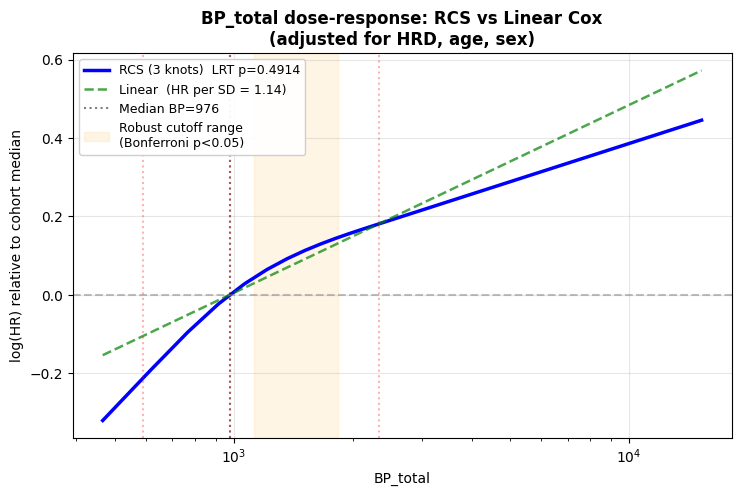


[OK] outputs/run_20260123_154712/results/nonlinearity/bp_total_spline.png


In [ ]:
# =========================================================
# NONLIN-2) Restricted cubic splines (RCS) in Cox
# =========================================================
# RCS allows the hazard to vary non-linearly with BP_total. To handle the
# long right tail of BP_total (range 332-33366, median 976), we apply RCS on
# log10(BP_total) — biologically sensible (burden grows multiplicatively)
# and numerically stable.
#
# Compares nested Cox models via likelihood-ratio test:
#   - Linear log(BP_total)            — baseline
#   - RCS log(BP_total), 3 knots      — flexible

import scipy.stats as stats

if LIFELINES_OK:
    # Implement RCS basis (Harrell formulation, k-2 spline terms + 1 linear)
    def rcs_basis(x, knots):
        x = np.asarray(x, dtype=float)
        k = len(knots); t = sorted(knots)
        out = [x]
        denom = (t[k-1] - t[0])**(2/3)
        for j in range(k - 2):
            tj = t[j]; tk_1 = t[k-2]; tk = t[k-1]
            term = (np.maximum(0, x - tj)**3
                    - np.maximum(0, x - tk_1)**3 * (tk - tj)/(tk - tk_1)
                    + np.maximum(0, x - tk)**3 * (tk_1 - tj)/(tk - tk_1))
            out.append(term / denom)
        return np.column_stack(out)

    # Use log10(BP_total) for numerical stability and biological plausibility
    nlin_df["log10_BP"] = np.log10(nlin_df["BP_total"].clip(lower=1))
    logbp_vals = nlin_df["log10_BP"].dropna().values
    knots_3 = np.percentile(logbp_vals, [10, 50, 90])

    print(f"=== Restricted Cubic Spline (3 knots, on log10 BP_total) ===")
    print(f"  log10(BP) range: [{logbp_vals.min():.2f}, {logbp_vals.max():.2f}]")
    print(f"  Knot positions (log10 scale): {knots_3.round(3)}")
    print(f"  Knot positions (BP_total scale): {(10**knots_3).round(0)}")

    rcs_mat = rcs_basis(nlin_df["log10_BP"].values, knots_3)
    # Store raw basis columns; standardize for numerical stability of fit
    nlin_df["BP_rcs_lin"] = (rcs_mat[:,0] - rcs_mat[:,0].mean()) / rcs_mat[:,0].std()
    nlin_df["BP_rcs_sp1"] = (rcs_mat[:,1] - rcs_mat[:,1].mean()) / rcs_mat[:,1].std()

    # Linear model (baseline)
    cox_lin_data = nlin_df[["time","event","BP_rcs_lin","HRD_binary","age"]
                            + sex_cols_nl].dropna()
    cph_lin = CoxPHFitter()
    cph_lin.fit(cox_lin_data, duration_col="time", event_col="event")
    ll_lin = cph_lin.log_likelihood_

    # RCS model
    cox_rcs_data = nlin_df[["time","event","BP_rcs_lin","BP_rcs_sp1",
                             "HRD_binary","age"] + sex_cols_nl].dropna()
    cph_rcs = CoxPHFitter()
    cph_rcs.fit(cox_rcs_data, duration_col="time", event_col="event")
    ll_rcs = cph_rcs.log_likelihood_

    # Likelihood ratio test
    lr_stat = 2 * (ll_rcs - ll_lin)
    lr_p = 1 - stats.chi2.cdf(lr_stat, df=1)

    print(f"\n  Linear-only model log-lik: {ll_lin:.4f}")
    print(f"  RCS (3 knots)   log-lik: {ll_rcs:.4f}")
    print(f"  LRT: chi2 = {lr_stat:.3f}, df=1, p = {lr_p:.4f}")
    if lr_p < 0.05:
        print(f"  → Non-linearity STATISTICALLY SUPPORTED (p<0.05)")
    else:
        print(f"  → No statistical evidence for non-linearity at α=0.05")

    print(f"\n  RCS model coefficients (adjusted for HRD+age+sex):")
    print(cph_rcs.summary.loc[["BP_rcs_lin","BP_rcs_sp1"]][
        ["coef","exp(coef)","exp(coef) lower 95%","exp(coef) upper 95%","p"]
    ].round(4).to_string())

    # Plot the RCS dose-response curve, centered at median(BP_total)
    # Strategy: compute log-partial-hazard directly from coefficients
    bp_grid = np.linspace(np.percentile(nlin_df["BP_total"].dropna(), 1),
                           np.percentile(nlin_df["BP_total"].dropna(), 99), 100)
    log_bp_grid = np.log10(bp_grid)
    rcs_grid_raw = rcs_basis(log_bp_grid, knots_3)

    lin_mean = rcs_mat[:,0].mean(); lin_std = rcs_mat[:,0].std()
    sp1_mean = rcs_mat[:,1].mean(); sp1_std = rcs_mat[:,1].std()
    rcs_grid_lin = (rcs_grid_raw[:,0] - lin_mean) / lin_std
    rcs_grid_sp1 = (rcs_grid_raw[:,1] - sp1_mean) / sp1_std

    coef_lin_rcs = float(cph_rcs.summary.loc["BP_rcs_lin","coef"])
    coef_sp1_rcs = float(cph_rcs.summary.loc["BP_rcs_sp1","coef"])
    log_hr_rcs = coef_lin_rcs * rcs_grid_lin + coef_sp1_rcs * rcs_grid_sp1

    # Center at median of BP_total
    bp_median_val = float(np.median(nlin_df["BP_total"].dropna()))
    log_bp_median = np.log10(bp_median_val)
    rcs_at_median = rcs_basis(np.array([log_bp_median]), knots_3)[0]
    rcs_med_lin = (rcs_at_median[0] - lin_mean) / lin_std
    rcs_med_sp1 = (rcs_at_median[1] - sp1_mean) / sp1_std
    log_hr_at_median = coef_lin_rcs * rcs_med_lin + coef_sp1_rcs * rcs_med_sp1
    log_hr_rcs_centered = log_hr_rcs - log_hr_at_median

    # Linear-only comparison
    coef_lin_only = float(cph_lin.summary.loc["BP_rcs_lin","coef"])
    log_hr_lin = coef_lin_only * (rcs_grid_lin - rcs_med_lin)

    fig, ax = plt.subplots(figsize=(8.5, 5))
    ax.plot(bp_grid, log_hr_rcs_centered, "b-", lw=2.5,
             label=f"RCS (3 knots)  LRT p={lr_p:.4f}")
    ax.plot(bp_grid, log_hr_lin, "g--", lw=1.8, alpha=0.7,
             label=f"Linear  (HR per SD = {np.exp(coef_lin_only):.2f})")
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(bp_median_val, color="black", linestyle=":", alpha=0.5,
                label=f"Median BP={bp_median_val:.0f}")
    for k in 10**knots_3:
        ax.axvline(k, color="red", linestyle=":", alpha=0.3)
    # Highlight cutpoint-search robust region (results from sub-analysis 3)
    ax.axvspan(1128, 1836, alpha=0.10, color="orange",
                label="Robust cutoff range\n(Bonferroni p<0.05)")
    ax.set_xlabel("BP_total")
    ax.set_ylabel("log(HR) relative to cohort median")
    ax.set_title("BP_total dose-response: RCS vs Linear Cox\n"
                  "(adjusted for HRD, age, sex)",
                  fontweight="bold")
    ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
    ax.grid(alpha=0.3)
    ax.set_xscale("log")  # log x-axis to spread the data
    fig_path = os.path.join(NLIN_DIR, "bp_total_spline.png")
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n[OK] {fig_path}")

    # Save LRT result
    rcs_results = pd.DataFrame([{
        "model":"linear", "log_lik": round(ll_lin, 4), "n_params": 1
    },{
        "model":"RCS_3knots", "log_lik": round(ll_rcs, 4), "n_params": 2,
        "LRT_chi2": round(lr_stat, 4), "LRT_p": round(lr_p, 6)
    }])
    rcs_results.to_csv(os.path.join(NLIN_DIR, "bp_total_rcs_lrt.tsv"),
                        sep="\t", index=False)

=== Optimal cutpoint search ===
Testing 17 cutpoints in BP_total percentiles 10-90

  Optimal cutpoint: BP_total > 1128
    High group (n=363) vs Low group (n=545)
    Raw p = 0.0011
    Bonferroni-corrected p (over 17 tests) = 0.0194
    ✓ Optimal cutpoint SURVIVES multiple testing correction

  Summary of all cutpoints tested:
 cutpoint  n_high  n_low  logrank_chi2  p_raw  p_bonferroni  significant_after_correction
    590.0     816     92        0.8697 0.3510        1.0000                             0
    630.0     768    140        0.1235 0.7252        1.0000                             0
    670.8     726    182        0.0008 0.9779        1.0000                             0
    713.5     681    227        0.0972 0.7552        1.0000                             0
    754.0     634    274        0.2517 0.6158        1.0000                             0
    799.8     590    318        0.9878 0.3203        1.0000                             0
    846.0     544    364        4.2403 

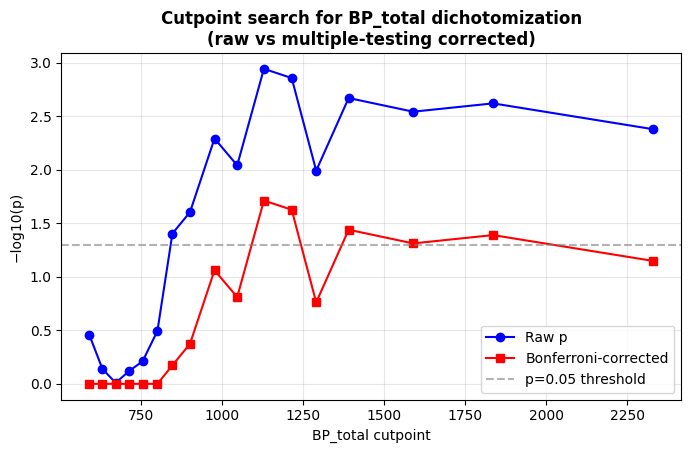

[OK] outputs/run_20260123_154712/results/nonlinearity/bp_total_cutpoint_search.png


In [ ]:
# =========================================================
# NONLIN-3) Optimal cutpoint search with Bonferroni correction
# =========================================================
# Scans candidate cutpoints in percentile 10-90 of BP_total, computes log-rank
# at each, and reports the optimal. Bonferroni-corrects for the number of
# cutpoints tested to control type-I error.

cutpoints = np.percentile(nlin_df["BP_total"].dropna(), np.arange(10, 91, 5))
print(f"=== Optimal cutpoint search ===")
print(f"Testing {len(cutpoints)} cutpoints in BP_total percentiles 10-90")

cut_results = []
for ct in cutpoints:
    grp = (nlin_df["BP_total"] > ct).astype(int).values
    if grp.sum() < 20 or (1-grp).sum() < 20:
        continue
    chi2, p = _logrank_hrd(nlin_df["time"].values, nlin_df["event"].values, grp)
    cut_results.append({"cutpoint": round(float(ct),2),
                         "n_high": int(grp.sum()),
                         "n_low": int((1-grp).sum()),
                         "logrank_chi2": round(chi2,4),
                         "p_raw": round(p,6)})

cut_df = pd.DataFrame(cut_results)
# Bonferroni correction
n_tests = len(cut_df)
cut_df["p_bonferroni"] = (cut_df["p_raw"] * n_tests).clip(upper=1.0).round(6)
cut_df["significant_after_correction"] = (cut_df["p_bonferroni"] < 0.05).astype(int)

# Best cutpoint
best = cut_df.loc[cut_df["p_raw"].idxmin()]
print(f"\n  Optimal cutpoint: BP_total > {best['cutpoint']:.0f}")
print(f"    High group (n={int(best['n_high'])}) vs Low group (n={int(best['n_low'])})")
print(f"    Raw p = {best['p_raw']:.4f}")
print(f"    Bonferroni-corrected p (over {n_tests} tests) = {best['p_bonferroni']:.4f}")
if best["p_bonferroni"] < 0.05:
    print(f"    ✓ Optimal cutpoint SURVIVES multiple testing correction")
else:
    print(f"    ✗ Optimal cutpoint does NOT survive multiple testing correction")
    print(f"      → Original median dichotomization was a data-driven false positive")

print(f"\n  Summary of all cutpoints tested:")
print(cut_df.round(4).to_string(index=False))

cut_df.to_csv(os.path.join(NLIN_DIR, "bp_total_cutpoint_search.tsv"),
               sep="\t", index=False)

# Plot p-value vs cutpoint
fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(cut_df["cutpoint"], -np.log10(cut_df["p_raw"]), "b-o", label="Raw p")
ax.plot(cut_df["cutpoint"], -np.log10(cut_df["p_bonferroni"]), "r-s",
         label="Bonferroni-corrected")
ax.axhline(-np.log10(0.05), color="gray", linestyle="--", alpha=0.6,
            label="p=0.05 threshold")
ax.set_xlabel("BP_total cutpoint")
ax.set_ylabel("−log10(p)")
ax.set_title("Cutpoint search for BP_total dichotomization\n"
              "(raw vs multiple-testing corrected)", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
fig_path2 = os.path.join(NLIN_DIR, "bp_total_cutpoint_search.png")
fig.savefig(fig_path2, dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] {fig_path2}")

In [ ]:
# =========================================================
# NONLIN-4) Cox stratified by HRD status
# =========================================================
# Tests if BP_total effect differs between HRD and non-HRD subgroups.
# Two complementary tests:
#   a) Interaction model: BP_total * HRD_binary
#   b) Stratified Cox: BP_total within each HRD subgroup

if LIFELINES_OK:
    print(f"=== Interaction test: BP_total × HRD_status ===")

    nlin_df["BP_x_HRD"] = nlin_df["BP_total"] * nlin_df["HRD_binary"]

    # Standardize BP_total and interaction term
    bp_mean = nlin_df["BP_total"].mean(); bp_std = nlin_df["BP_total"].std()
    nlin_df["BP_total_std"] = (nlin_df["BP_total"] - bp_mean) / bp_std
    bpi_mean = nlin_df["BP_x_HRD"].mean(); bpi_std = nlin_df["BP_x_HRD"].std()
    nlin_df["BP_x_HRD_std"] = (nlin_df["BP_x_HRD"] - bpi_mean) / bpi_std

    cox_int_data = nlin_df[["time","event","BP_total_std","HRD_binary",
                             "BP_x_HRD_std","age"] + sex_cols_nl].dropna()
    cph_int = CoxPHFitter()
    cph_int.fit(cox_int_data, duration_col="time", event_col="event")

    s_int = cph_int.summary
    print(cph_int.summary[["coef","exp(coef)","exp(coef) lower 95%",
                            "exp(coef) upper 95%","p"]].round(4).to_string())

    p_interaction = s_int.loc["BP_x_HRD_std","p"]
    print(f"\n  Interaction p-value: {p_interaction:.4f}")
    if p_interaction < 0.05:
        print(f"  → BP_total effect DIFFERS between HRD and non-HRD")
    else:
        print(f"  → No evidence that BP_total effect differs by HRD status")

    # Stratified Cox: BP_total in each HRD subgroup
    print(f"\n=== Cox of BP_total within each HRD subgroup ===")
    strat_rows = []
    for hrd_val, label in [(1,"HRD"), (0,"non-HRD")]:
        sub = nlin_df[nlin_df["HRD_binary"]==hrd_val].copy()
        sub_data = sub[["time","event","BP_total","age"] + sex_cols_nl].dropna()
        if len(sub_data) < 50: continue
        # Standardize
        sd = sub_data["BP_total"].std()
        if sd > 0:
            sub_data["BP_total"] = (sub_data["BP_total"]-sub_data["BP_total"].mean())/sd
        sd_age = sub_data["age"].std()
        if sd_age > 0:
            sub_data["age"] = (sub_data["age"]-sub_data["age"].mean())/sd_age

        try:
            cph_s = CoxPHFitter()
            cph_s.fit(sub_data, duration_col="time", event_col="event")
            s = cph_s.summary.loc["BP_total"]
            HR = float(np.exp(s["coef"]))
            HRlo = float(np.exp(s["coef lower 95%"]))
            HRhi = float(np.exp(s["coef upper 95%"]))
            p = float(s["p"])
            n = len(sub_data); ev = int(sub_data["event"].sum())
            sig = "*" if p<0.05 else ""
            print(f"  [{label}]  N={n}, ev={ev}: HR={HR:.3f} "
                  f"[{HRlo:.3f},{HRhi:.3f}], p={p:.4f} {sig}")
            strat_rows.append({"subgroup":label,"N":n,"events":ev,
                                "HR":round(HR,4),
                                "HR_lower95":round(HRlo,4),
                                "HR_upper95":round(HRhi,4),
                                "p":round(p,6)})
        except Exception as e:
            print(f"  [{label}] ERROR: {e}")

    strat_df = pd.DataFrame(strat_rows)
    strat_df.to_csv(os.path.join(NLIN_DIR, "bp_total_stratified_by_hrd.tsv"),
                     sep="\t", index=False)
    print(f"\n[OK] {NLIN_DIR}/bp_total_stratified_by_hrd.tsv")

=== Interaction test: BP_total × HRD_status ===
                coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%       p
covariate                                                                        
BP_total_std  0.0479     1.0491               0.8594               1.2806  0.6378
HRD_binary   -0.2989     0.7416               0.5261               1.0454  0.0879
BP_x_HRD_std  0.0022     1.0022               0.8147               1.2328  0.9837
age           0.0481     1.0493               1.0336               1.0652  0.0000

  Interaction p-value: 0.9837
  → No evidence that BP_total effect differs by HRD status

=== Cox of BP_total within each HRD subgroup ===
  [HRD]  N=498, ev=89: HR=1.055 [0.926,1.203], p=0.4209 
  [non-HRD]  N=410, ev=88: HR=1.019 [0.872,1.191], p=0.8127 

[OK] outputs/run_20260123_154712/results/nonlinearity/bp_total_stratified_by_hrd.tsv


In [ ]:
# =========================================================
# NONLIN) Synthesis report
# =========================================================
lines = []
lines.append("# Non-linearity analysis for BP_total")
lines.append(f"\n**Run ID:** {RUN_ID}")
lines.append(f"**N analyzed:** {len(nlin_df)} patients, {int(nlin_df['event'].sum())} events")
lines.append(f"\n## Background")
lines.append("Median dichotomization log-rank suggested BP_total prognostic effect (p~0.005), ")
lines.append("but Cox-linear modeling did not (p~0.20). This module investigates four ")
lines.append("alternative formulations to clarify the BP_total–OS relationship.")

lines.append(f"\n## Sub-analyses\n")
lines.append(f"### 1. Quartile stratification")
lines.append("See `bp_quartile_logrank.tsv` and `bp_quartile_descriptive.tsv`. ")
lines.append("Pairwise log-rank tests of Q1 vs Q2/Q3/Q4 detect at which quartile ")
lines.append("(if any) the risk diverges from baseline. A monotonic gradient suggests ")
lines.append("linear dose-response; a sharp jump at Q4 suggests threshold effect.\n")

lines.append(f"### 2. Restricted cubic splines (RCS)")
lines.append("See `bp_total_rcs_lrt.tsv` and `bp_total_spline.png`. ")
lines.append("Likelihood-ratio test of RCS vs Linear Cox formally tests non-linearity.\n")

lines.append(f"### 3. Optimal cutpoint search with multiple-testing correction")
lines.append("See `bp_total_cutpoint_search.tsv` and `bp_total_cutpoint_search.png`. ")
lines.append("If the optimal raw p<0.05 does NOT survive Bonferroni, the median ")
lines.append("dichotomization signal was an artifact of cutpoint choice.\n")

lines.append(f"### 4. Stratification by HRD status")
lines.append("See `bp_total_stratified_by_hrd.tsv`. ")
lines.append("BP_total tested within HRD and non-HRD subgroups, plus formal ")
lines.append("interaction test BP_total × HRD.\n")

lines.append(f"## References")
lines.append("- Harrell FE Jr. (2015) Regression Modeling Strategies. Springer. Chapter 2.4 (RCS).")
lines.append("- Royston P, Sauerbrei W (2004) A new approach to modelling interactions between treatment "
             "and continuous covariates in clinical trials. *Stat Med* 23:2509-2525.")
lines.append("- Altman DG et al. (1994) Dangers of using 'optimal' cutpoints in the evaluation of "
             "prognostic factors. *J Natl Cancer Inst* 86:829-835.")

report_path = os.path.join(NLIN_DIR, "nonlinearity_report.md")
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))
print(f"[OK] {report_path}")
print("\n" + "="*78)
print("NON-LINEARITY ANALYSIS COMPLETE")
print("="*78)
print(f"  Outputs in: {NLIN_DIR}/")
print(f"    - bp_quartile_logrank.tsv          (sub-analysis 1)")
print(f"    - bp_quartile_descriptive.tsv      (sub-analysis 1)")
print(f"    - bp_total_rcs_lrt.tsv             (sub-analysis 2)")
print(f"    - bp_total_spline.png              (sub-analysis 2 figure)")
print(f"    - bp_total_cutpoint_search.tsv     (sub-analysis 3)")
print(f"    - bp_total_cutpoint_search.png     (sub-analysis 3 figure)")
print(f"    - bp_total_stratified_by_hrd.tsv   (sub-analysis 4)")
print(f"    - nonlinearity_report.md           (synthesis)")

[OK] outputs/run_20260123_154712/results/nonlinearity/nonlinearity_report.md

NON-LINEARITY ANALYSIS COMPLETE
  Outputs in: outputs/run_20260123_154712/results/nonlinearity/
    - bp_quartile_logrank.tsv          (sub-analysis 1)
    - bp_quartile_descriptive.tsv      (sub-analysis 1)
    - bp_total_rcs_lrt.tsv             (sub-analysis 2)
    - bp_total_spline.png              (sub-analysis 2 figure)
    - bp_total_cutpoint_search.tsv     (sub-analysis 3)
    - bp_total_cutpoint_search.png     (sub-analysis 3 figure)
    - bp_total_stratified_by_hrd.tsv   (sub-analysis 4)
    - nonlinearity_report.md           (synthesis)


## HRD refinement — Chretien 2015 weighted score

The Wuilleme/IMWG binary criterion (≥2 trisomies among odd chromosomes) treats all trisomies equally, but **prognostic impact varies by chromosome**. Chretien et al. (2015, *Blood* 126:2713-2719) proposed a weighted score derived from multivariate modeling of the IFM cohort, giving higher weight to trisomies most strongly associated with favorable outcome.

This block computes the Chretien-style score, compares it with the binary HRD_status from above, and tests whether the continuous score provides additional prognostic resolution. Outputs are merged into `os_df` for downstream use.

In [ ]:
CHRETIEN_WEIGHTS = {
    "3":  2,  # strongly favorable
    "5":  2,  # strongly favorable
    "21": 2,  # strongly favorable
    "9":  1,  # moderately favorable
    "11": 1,  # moderately favorable
    "15": 1,  # moderately favorable
    "19": 1,  # moderately favorable
    "7":  0,  # neutral / minimal effect
}

print("[HRD-Chretien] Weights applied:")
for chrom, w in sorted(CHRETIEN_WEIGHTS.items(), key=lambda x: -x[1]):
    label = "strongly favorable" if w == 2 else "moderately favorable" if w == 1 else "neutral"
    print(f"  +{chrom:<3s}  weight={w}  ({label})")

# Compute weighted score
hrd_df["Chretien_score"] = 0
for chrom, w in CHRETIEN_WEIGHTS.items():
    col = f"chr{chrom}_trisomy"
    if col in hrd_df.columns:
        hrd_df["Chretien_score"] = hrd_df["Chretien_score"] + (hrd_df[col].fillna(0).astype(int) * w)

# Quartile stratification for survival comparison
try:
    hrd_df["Chretien_quartile"] = pd.qcut(
        hrd_df["Chretien_score"], q=4,
        labels=["Q1_lowest", "Q2", "Q3", "Q4_highest"],
        duplicates="drop"
    )
except ValueError:
    # If too many ties, use rank-based cut
    ranks = hrd_df["Chretien_score"].rank(method="dense")
    hrd_df["Chretien_quartile"] = pd.qcut(
        ranks, q=4, duplicates="drop"
    )

# Tertile alternative (in case quartile fails due to skewed distribution)
try:
    hrd_df["Chretien_tertile"] = pd.qcut(
        hrd_df["Chretien_score"], q=3,
        labels=["T1_low", "T2_mid", "T3_high"],
        duplicates="drop"
    )
except ValueError:
    ranks = hrd_df["Chretien_score"].rank(method="dense")
    hrd_df["Chretien_tertile"] = pd.qcut(
        ranks, q=3, duplicates="drop"
    )


# Clinical grouping (more robust than qcut for skewed score distribution):
# - score=0 (no favorable trisomies)
# - score 1-4 (1-2 favorable trisomies, intermediate)
# - score >=5 (multiple favorable trisomies, "true HRD" by Chretien)
hrd_df["Chretien_group"] = pd.cut(
    hrd_df["Chretien_score"],
    bins=[-0.5, 0.5, 4.5, hrd_df["Chretien_score"].max() + 0.5],
    labels=["score_0", "score_1to4", "score_5plus"]
)
print(f"\n=== Clinical grouping (score 0 / 1-4 / 5+) ===")
print(hrd_df["Chretien_group"].value_counts().sort_index())

# Update saved HRD classification table with the new columns
hrd_df.to_csv(hrd_path, sep="\t", index=False)

print(f"\n=== Chretien score distribution ===")
print(hrd_df["Chretien_score"].describe().round(2))
print(f"\n=== Score frequency table ===")
score_freq = hrd_df["Chretien_score"].value_counts().sort_index()
for s, n in score_freq.items():
    bar = "█" * int(40 * n / score_freq.max())
    print(f"  score {int(s):>2d}: {int(n):>4d} patients  {bar}")

print(f"\n=== Quartile distribution ===")
print(hrd_df["Chretien_quartile"].value_counts().sort_index())

[HRD-Chretien] Weights applied:
  +3    weight=2  (strongly favorable)
  +5    weight=2  (strongly favorable)
  +21   weight=2  (strongly favorable)
  +9    weight=1  (moderately favorable)
  +11   weight=1  (moderately favorable)
  +15   weight=1  (moderately favorable)
  +19   weight=1  (moderately favorable)
  +7    weight=0  (neutral)

=== Clinical grouping (score 0 / 1-4 / 5+) ===
Chretien_group
score_0        325
score_1to4     212
score_5plus    371
Name: count, dtype: int64

=== Chretien score distribution ===
count    908.00
mean       3.56
std        3.50
min        0.00
25%        0.00
50%        3.00
75%        7.00
max       10.00
Name: Chretien_score, dtype: float64

=== Score frequency table ===
  score  0:  325 patients  ████████████████████████████████████████
  score  1:   73 patients  ████████
  score  2:   51 patients  ██████
  score  3:   35 patients  ████
  score  4:   53 patients  ██████
  score  5:   55 patients  ██████
  score  6:   62 patients  ███████
  score

In [ ]:
import scipy.stats as stats

# =========================================================
# HRD-Chretien) Compare with binary HRD_status
# =========================================================
# Cross-tabulate Wuilleme HRD_status vs Chretien quartile
crosstab = pd.crosstab(hrd_df["HRD_status"], hrd_df["Chretien_quartile"],
                        margins=True, margins_name="Total")
print("=== Cross-tabulation: Wuilleme HRD vs Chretien quartile ===")
print(crosstab.to_string())

# Score by HRD status
score_by_hrd = hrd_df.groupby("HRD_status")["Chretien_score"].describe().round(2)
print(f"\n=== Chretien score by Wuilleme HRD status ===")
print(score_by_hrd[["count","mean","std","min","25%","50%","75%","max"]].to_string())

# Spearman correlation between binary HRD and continuous Chretien
corr_test = stats.spearmanr(
    (hrd_df["HRD_status"] == "HRD").astype(int),
    hrd_df["Chretien_score"]
)
print(f"\n=== Concordance between criteria ===")
print(f"  Spearman correlation: rho = {corr_test.correlation:.4f}, p = {corr_test.pvalue:.2e}")

# Save crosstab as supplementary table
crosstab.to_csv(os.path.join(HRD_DIR, "wuilleme_vs_chretien_crosstab.tsv"), sep="\t")
print(f"\n[OK] {os.path.join(HRD_DIR, 'wuilleme_vs_chretien_crosstab.tsv')}")

=== Cross-tabulation: Wuilleme HRD vs Chretien quartile ===
Chretien_quartile  (0.999, 4.0]  (4.0, 8.0]  (8.0, 11.0]  Total
HRD_status                                                     
HRD                          74         243          181    498
non-HRD                     410           0            0    410
Total                       484         243          181    908

=== Chretien score by Wuilleme HRD status ===
            count  mean   std  min  25%  50%  75%   max
HRD_status                                             
HRD         498.0  6.28  2.38  1.0  4.0  7.0  8.0  10.0
non-HRD     410.0  0.26  0.54  0.0  0.0  0.0  0.0   2.0

=== Concordance between criteria ===
  Spearman correlation: rho = 0.8777, p = 1.03e-291

[OK] outputs/run_20260123_154712/results/hrd/wuilleme_vs_chretien_crosstab.tsv


In [ ]:
# =========================================================
# HRD-Chretien) Add Chretien_score to os_df + survival tests
# =========================================================
# Merge Chretien_score and quartile into os_df
chretien_cols = ["__JOIN_ID__", "Chretien_score", "Chretien_quartile", "Chretien_tertile"]
os_df = os_df.merge(
    hrd_df[chretien_cols], on="__JOIN_ID__", how="left"
)

# 1. Log-rank by Chretien tertile (T1 lowest vs T3 highest)
surv_chr = os_df.dropna(subset=["time","event","Chretien_tertile"]).copy()
t1 = surv_chr[surv_chr["Chretien_tertile"] == "T1_low"]
t3 = surv_chr[surv_chr["Chretien_tertile"] == "T3_high"]
merged_tt = pd.concat([t1.assign(group=0), t3.assign(group=1)], ignore_index=True)
chi2_tt, p_tt = _logrank_hrd(merged_tt["time"].values, merged_tt["event"].values,
                              merged_tt["group"].values)
print(f"=== Log-rank: Chretien T1 (lowest) vs T3 (highest) ===")
print(f"  N: T1={len(t1)}, T3={len(t3)}")
print(f"  Events: T1={int(t1['event'].sum())}, T3={int(t3['event'].sum())}")
print(f"  chi2 = {chi2_tt:.3f}, p = {p_tt:.4f}")

# 2. Log-rank dichotomized at score median
med_score = hrd_df["Chretien_score"].median()
surv_chr["high_score"] = (surv_chr["Chretien_score"] > med_score).astype(int)
chi2_m, p_m = _logrank_hrd(surv_chr["time"].values, surv_chr["event"].values,
                            surv_chr["high_score"].values)
print(f"\n=== Log-rank: Chretien score > median ({med_score:.0f}) vs ≤ median ===")
print(f"  chi2 = {chi2_m:.3f}, p = {p_m:.4f}")

# Direction check
ev_high = surv_chr[surv_chr["high_score"]==1]["event"].mean()
ev_low = surv_chr[surv_chr["high_score"]==0]["event"].mean()
direction = "LOWER mortality" if ev_high < ev_low else "HIGHER mortality"
print(f"  High-score patients have {direction} vs low-score "
      f"(consistent with literature: high score = better prognosis)")

# 3. Cox with Chretien_score as continuous variable
if LIFELINES_OK and "features_df" in dir():
    # Drop time/event from features_df subset to avoid _x/_y collisions
    bp_cols = ["__JOIN_ID__","BP_total"]
    chr_cox_data = features_df[bp_cols].merge(
        hrd_df[["__JOIN_ID__","HRD_status","Chretien_score"]], on="__JOIN_ID__"
    ).merge(
        os_df[["__JOIN_ID__","time","event"] +
              [c for c in ["age","sex"] if c in os_df.columns]],
        on="__JOIN_ID__"
    )
    chr_cox_data["HRD_binary"] = (chr_cox_data["HRD_status"] == "HRD").astype(int)
    if "sex" in chr_cox_data.columns:
        chr_cox_data["sex"] = chr_cox_data["sex"].astype(str)
        sx = pd.get_dummies(chr_cox_data["sex"], prefix="sex", drop_first=True)
        for c in sx.columns:
            chr_cox_data[c] = sx[c].astype(float)

    print(f"\n=== Cox with Chretien_score (continuous, per +1 unit) ===")
    cox_chr_rows = []
    for model_name, covars in [
        ("Chretien alone",                    ["Chretien_score"]),
        ("Chretien + age + sex",              ["Chretien_score","age"] +
                                              [c for c in chr_cox_data.columns if c.startswith("sex_")]),
        ("Wuilleme + Chretien (head-to-head)", ["HRD_binary","Chretien_score"]),
    ]:
        cols = ["time","event"] + [c for c in covars if c in chr_cox_data.columns]
        dfm = chr_cox_data[cols].dropna().copy()
        if len(dfm) < 50:
            print(f"\n  [{model_name}] insufficient data"); continue
        # Standardize continuous
        for c in ["Chretien_score","age"]:
            if c in dfm.columns:
                sd = dfm[c].std()
                if sd > 0:
                    dfm[c] = (dfm[c] - dfm[c].mean()) / sd
        try:
            cph = CoxPHFitter()
            cph.fit(dfm, duration_col="time", event_col="event")
            s = cph.summary
            risk = cph.predict_partial_hazard(dfm).values.ravel()
            cidx = concordance_index(dfm["time"].values, -risk, dfm["event"].values)
            print(f"\n  [{model_name}]  N={len(dfm)}, events={int(dfm['event'].sum())}, C-index={cidx:.4f}")
            print(s[["coef","exp(coef)","exp(coef) lower 95%","exp(coef) upper 95%","p"]].round(4).to_string())
            for v in s.index:
                cox_chr_rows.append({
                    "model": model_name, "variable": v,
                    "HR": round(float(s.loc[v,"exp(coef)"]), 4),
                    "HR_lower95": round(float(s.loc[v,"exp(coef) lower 95%"]), 4),
                    "HR_upper95": round(float(s.loc[v,"exp(coef) upper 95%"]), 4),
                    "p": float(s.loc[v,"p"]), "C_index": round(cidx, 4)
                })
        except Exception as e:
            print(f"  ERROR: {e}")

    pd.DataFrame(cox_chr_rows).to_csv(
        os.path.join(HRD_DIR, "cox_chretien_score.tsv"), sep="\t", index=False
    )
    print(f"\n[OK] {os.path.join(HRD_DIR, 'cox_chretien_score.tsv')}")

=== Log-rank: Chretien T1 (lowest) vs T3 (highest) ===
  N: T1=0, T3=0
  Events: T1=0, T3=0
  chi2 = 0.000, p = 1.0000

=== Log-rank: Chretien score > median (3) vs ≤ median ===
  chi2 = 1.248, p = 0.2639
  High-score patients have LOWER mortality vs low-score (consistent with literature: high score = better prognosis)

=== Cox with Chretien_score (continuous, per +1 unit) ===

  [Chretien alone]  N=908, events=177, C-index=0.5240
                 coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%       p
covariate                                                                         
Chretien_score -0.106     0.8994               0.7738               1.0455  0.1676

  [Chretien + age + sex]  N=908, events=177, C-index=0.6295
                  coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%       p
covariate                                                                          
Chretien_score -0.1161     0.8904               0.7652               1.0361  0.1333
age

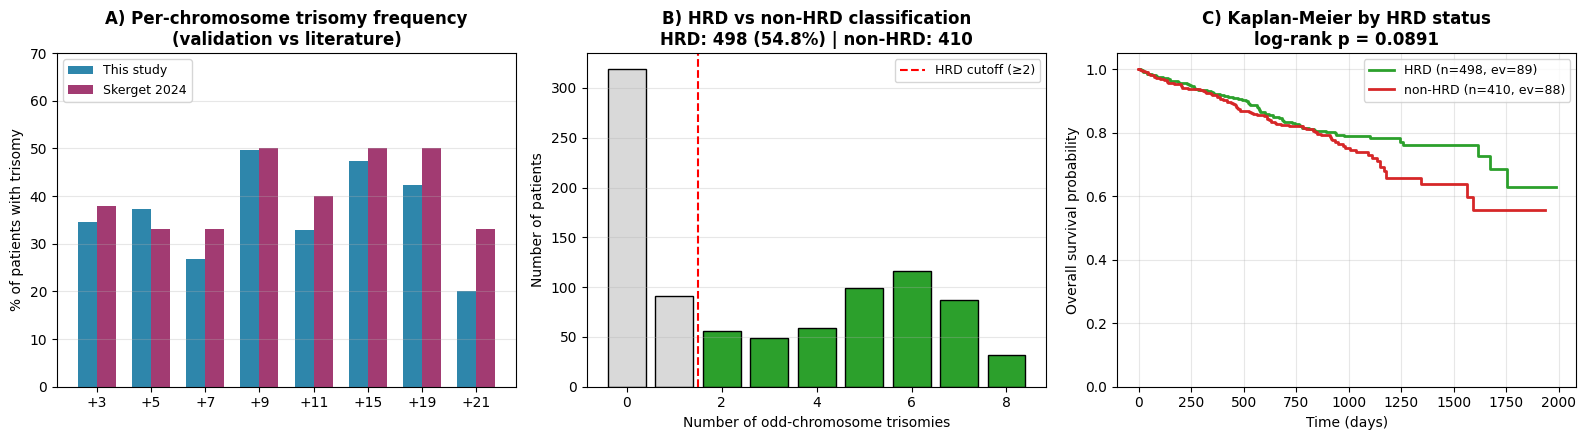

[OK] outputs/run_20260123_154712/results/hrd/hrd_summary.png


In [ ]:
# =========================================================
# HRD) Supplementary Figure: HRD distribution + KM curve
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel A: bar chart of per-chromosome trisomy frequency
ax = axes[0]
val_for_plot = val_df.copy()
x = np.arange(len(val_for_plot))
w = 0.35
ax.bar(x - w/2, val_for_plot["This_study_pct"], w, label="This study", color="#2E86AB")
ax.bar(x + w/2, val_for_plot["Skerget_2024_pct"], w, label="Skerget 2024", color="#A23B72")
ax.set_xticks(x)
ax.set_xticklabels(val_for_plot["Chromosome"])
ax.set_ylabel("% of patients with trisomy")
ax.set_title("A) Per-chromosome trisomy frequency\n(validation vs literature)", fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
ax.set_ylim(0, 70)
ax.grid(axis="y", alpha=0.3)

# Panel B: number of trisomies distribution
ax = axes[1]
ntris_counts = hrd_df["n_trisomies_odd"].value_counts().sort_index()
colors_b = ["#d9d9d9" if n < HRD_MIN_TRISOMIES else "#2ca02c" for n in ntris_counts.index]
ax.bar(ntris_counts.index, ntris_counts.values, color=colors_b, edgecolor="black")
ax.axvline(HRD_MIN_TRISOMIES - 0.5, color="red", linestyle="--",
           label=f"HRD cutoff (≥{HRD_MIN_TRISOMIES})")
ax.set_xlabel("Number of odd-chromosome trisomies")
ax.set_ylabel("Number of patients")
hrd_count = (hrd_df["HRD_status"] == "HRD").sum()
nonhrd_count = (hrd_df["HRD_status"] == "non-HRD").sum()
hrd_pct_disp = 100 * hrd_count / len(hrd_df)
ax.set_title(f"B) HRD vs non-HRD classification\n"
             f"HRD: {hrd_count} ({hrd_pct_disp:.1f}%) | non-HRD: {nonhrd_count}",
             fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# Panel C: Kaplan-Meier-style cumulative event curve by HRD status
ax = axes[2]
for status, color, label in [("HRD", "#2ca02c", "HRD"),
                              ("non-HRD", "#d62728", "non-HRD")]:
    grp = surv[surv["HRD_status"] == status]
    if len(grp) == 0: continue
    # Simple stepwise KM estimator
    sorted_t = np.sort(grp["time"].values)
    sorted_e = grp.sort_values("time")["event"].values
    n_at_risk = len(grp)
    surv_prob = 1.0
    times_plot = [0.0]
    probs_plot = [1.0]
    for t, e in zip(sorted_t, sorted_e):
        if e == 1 and n_at_risk > 0:
            surv_prob *= (1 - 1/n_at_risk)
        n_at_risk -= 1
        times_plot.append(t)
        probs_plot.append(surv_prob)
    ax.step(times_plot, probs_plot, where="post", color=color,
            linewidth=2, label=f"{label} (n={len(grp)}, ev={int(grp['event'].sum())})")

ax.set_xlabel("Time (days)")
ax.set_ylabel("Overall survival probability")
ax.set_title(f"C) Kaplan-Meier by HRD status\nlog-rank p = {p_hrd:.4f}",
             fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
fig_path = os.path.join(HRD_DIR, "hrd_summary.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] {fig_path}")

In [ ]:
# =========================================================
# HRD) Narrative report (Markdown for supplementary)
# =========================================================
lines = []
lines.append("# Hyperdiploidy classification report")
lines.append(f"\n**Run ID:** {RUN_ID}")
lines.append(f"**Patients analyzed:** {len(hrd_df)}")
lines.append(f"**Criterion:** ≥{HRD_MIN_TRISOMIES} trisomies among odd chromosomes "
             f"({', '.join(HRD_ODD_CHROMS)}), where trisomy requires "
             f"≥{int(HRD_MIN_FRACTION_GAINED*100)}% of the chromosome with "
             f"log2 ratio > {HRD_GAIN_LOG2_THRESHOLD}")
lines.append(f"\n## Classification\n")
lines.append(f"- **HRD:** {(hrd_df['HRD_status']=='HRD').sum()} patients "
             f"({100*(hrd_df['HRD_status']=='HRD').mean():.1f}%)")
lines.append(f"- **non-HRD:** {(hrd_df['HRD_status']=='non-HRD').sum()} patients "
             f"({100*(hrd_df['HRD_status']=='non-HRD').mean():.1f}%)")
lines.append(f"- Literature benchmark: HRD ~50–55% in newly diagnosed MM")

lines.append("\n## Per-chromosome trisomy frequency vs literature\n")
lines.append(val_df.to_markdown(index=False))

lines.append("\n## Survival analysis\n")
lines.append(f"- Log-rank HRD vs non-HRD: chi² = {chi2_hrd:.3f}, p = {p_hrd:.4f}")
if p_hrd < 0.05:
    lines.append("- Statistically significant difference in OS between groups")
else:
    lines.append("- No statistically significant OS difference at α=0.05")

lines.append("\n## References")
lines.append("1. Wuilleme S et al. (2005) Ploidy, as detected by fluorescence in situ "
             "hybridization, defines different subgroups in multiple myeloma. *Leukemia* 19:275-278.")
lines.append("2. Avet-Loiseau H et al. (2007) Genetic abnormalities and survival in multiple "
             "myeloma: the experience of the Intergroupe Francophone du Myélome. *Blood* 109:3489-3495.")
lines.append("3. Skerget S et al. (2024) Comprehensive molecular profiling of multiple "
             "myeloma. *Nature Genetics*.")
lines.append("4. Chretien ML et al. (2015) Understanding the role of hyperdiploidy in "
             "myeloma prognosis. *Blood* 126:2713-2719.")

report_path = os.path.join(HRD_DIR, "hrd_report.md")
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print(f"[OK] {report_path}")
print("\n" + "=" * 78)
print("HRD CLASSIFICATION COMPLETE")
print("=" * 78)
print(f"  Outputs in: {HRD_DIR}/")
print(f"    - hrd_classification.tsv         (per-patient HRD status)")
print(f"    - hrd_frequency_validation.tsv   (vs literature)")
print(f"    - cox_models_with_hrd.tsv        (Cox: BP_total adjusted for HRD)")
print(f"    - hrd_summary.png                (Supplementary Figure)")
print(f"    - hrd_report.md                  (narrative summary)")
print(f"\n  HRD_status now available as covariate in os_df for downstream analyses.")

[OK] outputs/run_20260123_154712/results/hrd/hrd_report.md

HRD CLASSIFICATION COMPLETE
  Outputs in: outputs/run_20260123_154712/results/hrd/
    - hrd_classification.tsv         (per-patient HRD status)
    - hrd_frequency_validation.tsv   (vs literature)
    - cox_models_with_hrd.tsv        (Cox: BP_total adjusted for HRD)
    - hrd_summary.png                (Supplementary Figure)
    - hrd_report.md                  (narrative summary)

  HRD_status now available as covariate in os_df for downstream analyses.


# Sensitivity analysis — CNV classification thresholds

This block re-evaluates CNV classification under three alternative threshold schemes (Chaves_2026, Skerget_2024, Talevich_2016) and re-runs the downstream survival analyses to assess methodological robustness. It uses `df_cnvs_final` and `os_df` already produced by the pipeline above — no re-download or re-parsing required.

**Outputs** (in `results/sensitivity/`):
- `distribution_per_scenario.tsv` — class distribution per scenario
- `agreement_metrics.tsv` — Cohen's kappa between scenarios
- `sensitivity_results.tsv` — log-rank tests per feature × scenario
- `sensitivity_summary.png` — Supplementary Figure SX
- `sensitivity_report.md` — narrative summary

In [ ]:
# =========================================================
# SENSITIVITY) Define alternative classification scenarios
# =========================================================
from sklearn.metrics import cohen_kappa_score
from scipy import stats

SENS_RES_DIR = os.path.join(RES_DIR, "sensitivity")
SENS_PROC_DIR = os.path.join(PROC_DIR, "sensitivity")
os.makedirs(SENS_RES_DIR, exist_ok=True)
os.makedirs(SENS_PROC_DIR, exist_ok=True)

# Three classification scenarios. Each preserves the SAME schema of the
# original THRESHOLDS dict (cell 5) for full compatibility with
# classify_segment_mean() and the downstream feature-engineering code.
SCENARIOS = {
    "Chaves_2026": {
        "thresholds": {
            "LOSS_HOMDEL":    -1.5,
            "LOSS_1COPY_MAX": -0.5,
            "NEUTRAL_MIN":    -0.2,
            "NEUTRAL_MAX":     0.2,
            "GAIN_1COPY_MIN":  0.5,
            "GAIN_AMP":        1.0,
        },
        "reference": "Chaves et al. 2026 (this study) — primary classification scheme",
    },
    "Skerget_2024": {
        "thresholds": {
            "LOSS_HOMDEL":    -2.32,
            "LOSS_1COPY_MAX": -0.1613,
            "NEUTRAL_MIN":    -0.1613,
            "NEUTRAL_MAX":     0.1613,
            "GAIN_1COPY_MIN":  0.1613,
            "GAIN_AMP":        2.32,
        },
        "reference": "Skerget et al. 2024, Nat Genet (CoMMpass IA22 study)",
    },
    "Talevich_2016": {
        "thresholds": {
            "LOSS_HOMDEL":    -1.1,
            "LOSS_1COPY_MAX": -0.25,
            "NEUTRAL_MIN":    -0.25,
            "NEUTRAL_MAX":     0.2,
            "GAIN_1COPY_MIN":  0.2,
            "GAIN_AMP":        0.7,
        },
        "reference": "Talevich et al. 2016, PLoS Comp Biol (CNVkit defaults)",
    }
}

# Class labels (short form used in figures); matches classify_segment_mean_sens()
CLASS_ORDER = ["HomoDel", "Loss", "Neutral", "Gain", "HighAmp", "Uncertain"]
CLASS_COLORS = ["#08306b", "#4292c6", "#f0f0f0", "#fb6a4a", "#67000d", "#d9d9d9"]

print("[SENSITIVITY] 3 scenarios defined:")
for name, cfg in SCENARIOS.items():
    t = cfg["thresholds"]
    print(f"  {name:15s}  homo≤{t['LOSS_HOMDEL']:>6.2f}  loss<{t['LOSS_1COPY_MAX']:>7.4f}  "
          f"neutral=[{t['NEUTRAL_MIN']:>7.4f},{t['NEUTRAL_MAX']:>7.4f}]  "
          f"gain>{t['GAIN_1COPY_MIN']:>7.4f}  amp≥{t['GAIN_AMP']:>5.2f}")

[SENSITIVITY] 3 scenarios defined:
  Chaves_2026      homo≤ -1.50  loss<-0.5000  neutral=[-0.2000, 0.2000]  gain> 0.5000  amp≥ 1.00
  Skerget_2024     homo≤ -2.32  loss<-0.1613  neutral=[-0.1613, 0.1613]  gain> 0.1613  amp≥ 2.32
  Talevich_2016    homo≤ -1.10  loss<-0.2500  neutral=[-0.2500, 0.2000]  gain> 0.2000  amp≥ 0.70


In [ ]:
# =========================================================
# SENSITIVITY) Parametrized classification + utilities
# =========================================================
def classify_segment_mean_sens(x, thresholds):
    """Parametrized version of classify_segment_mean() from cell 8.
    Returns short-form labels (HomoDel/Loss/Neutral/Gain/HighAmp/Uncertain)
    for compatibility with sensitivity figures."""
    if pd.isna(x):
        return "Uncertain"
    if x <= thresholds["LOSS_HOMDEL"]:
        return "HomoDel"
    if x < thresholds["LOSS_1COPY_MAX"]:
        return "Loss"
    if thresholds["NEUTRAL_MIN"] <= x <= thresholds["NEUTRAL_MAX"]:
        return "Neutral"
    if x >= thresholds["GAIN_AMP"]:
        return "HighAmp"
    if x > thresholds["GAIN_1COPY_MIN"]:
        return "Gain"
    return "Uncertain"


def _shannon_entropy_norm(x):
    x = np.asarray(x, dtype=float); x = x[x > 0]
    if len(x) <= 1: return 0.0
    p = x / x.sum()
    H = -(p * np.log(p)).sum()
    Hmax = np.log(len(p))
    return float(H / Hmax) if Hmax > 0 else 0.0


def _gini(x):
    x = np.asarray(x, dtype=float); x = x[x >= 0]
    if len(x) == 0: return np.nan
    if np.all(x == 0): return 0.0
    x = np.sort(x); n = len(x); cumx = np.cumsum(x)
    return float((n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n)


def _logrank_test(time, event, group):
    """Two-group log-rank test (Mantel 1966)."""
    time = np.asarray(time, dtype=float)
    event = np.asarray(event, dtype=int)
    group = np.asarray(group, dtype=int)
    event_times = np.sort(np.unique(time[event == 1]))
    O1, E1, V1 = 0.0, 0.0, 0.0
    for ti in event_times:
        at_risk = time >= ti
        n_total = at_risk.sum()
        n1 = (at_risk & (group == 1)).sum()
        d_total = ((time == ti) & (event == 1)).sum()
        d1 = ((time == ti) & (event == 1) & (group == 1)).sum()
        if n_total > 1:
            e1 = d_total * n1 / n_total
            v1 = (d_total * n1 * (n_total - n1) * (n_total - d_total)) / (n_total**2 * (n_total - 1))
            O1 += d1; E1 += e1; V1 += v1
    if V1 == 0: return 0.0, 1.0
    chi2 = (O1 - E1)**2 / V1
    p = 1 - stats.chi2.cdf(chi2, df=1)
    return float(chi2), float(p)


def _build_features_sens(df_classified, bin_size=None,
                         remove_classes={"Neutral", "Uncertain"}):
    """Replicates feature engineering from cells 14/15 (breakpoint + hotspot)."""
    if bin_size is None: bin_size = BIN_SIZE
    df_hc = df_classified[~df_classified["CNV_Type_sens"].isin(remove_classes)].copy()

    bp = pd.concat([
        df_hc[["Participant_ID","Chromosome","Start"]].rename(columns={"Start":"pos"}),
        df_hc[["Participant_ID","Chromosome","End"]].rename(columns={"End":"pos"})
    ], ignore_index=True)
    bp["pos"] = pd.to_numeric(bp["pos"], errors="coerce")
    bp = bp.dropna(subset=["pos"])

    bp_total = bp.groupby("Participant_ID").size().rename("BP_total").reset_index()
    bp_unique = bp.groupby("Participant_ID")["pos"].nunique().rename("BP_unique").reset_index()
    chr_counts = bp.groupby(["Participant_ID","Chromosome"]).size().reset_index(name="n_bp")
    ent = chr_counts.groupby("Participant_ID")["n_bp"].apply(_shannon_entropy_norm).rename("BP_entropy_chr").reset_index()
    gin = chr_counts.groupby("Participant_ID")["n_bp"].apply(_gini).rename("BP_gini_chr").reset_index()

    bp2 = bp.copy()
    bp2["BinStart"] = (bp2["pos"] // bin_size) * bin_size
    wc = bp2.groupby(["Participant_ID","Chromosome","BinStart"]).size().reset_index(name="bp_count")
    p95 = np.percentile(wc["bp_count"], 95) if len(wc) else np.nan
    hot_p95 = (wc.assign(is_hot=wc["bp_count"] >= p95)
               .groupby("Participant_ID")["is_hot"].sum()
               .rename("HotspotCount_P95").reset_index())

    def _topk(s, k=50):
        v = np.sort(np.asarray(s, dtype=float))[::-1]
        return float(v[:k].sum()) if len(v) else 0.0

    hot_topk = wc.groupby("Participant_ID")["bp_count"].apply(lambda s: _topk(s,50)).rename("HotspotScore_topK").reset_index()
    hot_ent  = wc.groupby("Participant_ID")["bp_count"].apply(_shannon_entropy_norm).rename("HotspotEntropy").reset_index()

    return (bp_total.merge(bp_unique, on="Participant_ID")
                    .merge(ent, on="Participant_ID")
                    .merge(gin, on="Participant_ID")
                    .merge(hot_p95, on="Participant_ID")
                    .merge(hot_topk, on="Participant_ID")
                    .merge(hot_ent, on="Participant_ID"))

print("[OK] Helper functions defined.")

[OK] Helper functions defined.


In [ ]:
# =========================================================
# SENSITIVITY) Reclassify under each scenario and compare
# =========================================================
classifications = {}
dist_rows = []

print("Reclassifying segments under each scenario...")
for name, cfg in SCENARIOS.items():
    cls = df_cnvs_final["Segment_Mean"].map(lambda x: classify_segment_mean_sens(x, cfg["thresholds"]))
    classifications[name] = cls
    counts = cls.value_counts(normalize=True) * 100
    row = {"Scenario": name}
    for c in CLASS_ORDER:
        row[c] = round(counts.get(c, 0), 3)
    dist_rows.append(row)
    print(f"  [{name}]")
    for c in CLASS_ORDER:
        n = (cls == c).sum()
        print(f"    {c:<10s} {n:>10,} ({100*n/len(cls):5.2f}%)")

dist_df = pd.DataFrame(dist_rows).set_index("Scenario")
dist_path = os.path.join(SENS_RES_DIR, "distribution_per_scenario.tsv")
dist_df.to_csv(dist_path, sep="\t")
print(f"\n[OK] {dist_path}")
dist_df.round(2)

Reclassifying segments under each scenario...
  [Chaves_2026]
    HomoDel       253,899 (21.89%)
    Loss          358,934 (30.95%)
    Neutral       271,891 (23.44%)
    Gain           44,670 ( 3.85%)
    HighAmp        18,766 ( 1.62%)
    Uncertain     211,734 (18.25%)
  [Skerget_2024]
    HomoDel       189,454 (16.33%)
    Loss          575,011 (49.57%)
    Neutral       232,769 (20.07%)
    Gain          158,301 (13.65%)
    HighAmp         4,359 ( 0.38%)
    Uncertain           0 ( 0.00%)
  [Talevich_2016]
    HomoDel       335,190 (28.90%)
    Loss          369,173 (31.83%)
    Neutral       303,227 (26.14%)
    Gain          116,407 (10.04%)
    HighAmp        35,897 ( 3.09%)
    Uncertain           0 ( 0.00%)

[OK] outputs/run_20260123_154712/results/sensitivity/distribution_per_scenario.tsv


,HomoDel,Loss,Neutral,Gain,HighAmp,Uncertain
Scenario,,,,,,
Chaves_2026,21.89,30.94,23.44,3.85,1.62,18.26
Skerget_2024,16.33,49.57,20.07,13.65,0.38,0.00
Talevich_2016,28.90,31.83,26.14,10.04,3.10,0.00


In [ ]:
# =========================================================
# SENSITIVITY) Concordance (Cohen's kappa)
# =========================================================
code_map = {c: i for i, c in enumerate(CLASS_ORDER)}
codes = {s: cls.map(code_map).values for s, cls in classifications.items()}

kappa_rows = []
scenarios_list = list(classifications.keys())
print("Cohen's kappa between scenarios:")
for i, s1 in enumerate(scenarios_list):
    for s2 in scenarios_list[i+1:]:
        k = cohen_kappa_score(codes[s1], codes[s2])
        agree = 100 * (codes[s1] == codes[s2]).mean()
        kappa_rows.append({
            "Scenario_A": s1, "Scenario_B": s2,
            "Cohen_kappa": round(k, 4),
            "Agreement_pct": round(agree, 2),
            "N_segments": len(codes[s1])
        })
        # Landis & Koch 1977 interpretation
        if   k < 0.00: interp = "no agreement"
        elif k < 0.21: interp = "slight"
        elif k < 0.41: interp = "fair"
        elif k < 0.61: interp = "moderate"
        elif k < 0.81: interp = "substantial"
        else:          interp = "almost perfect"
        print(f"  {s1:13s} vs {s2:13s}  kappa={k:.4f}  agreement={agree:.2f}%  ({interp})")

kappa_df = pd.DataFrame(kappa_rows)
kappa_path = os.path.join(SENS_RES_DIR, "agreement_metrics.tsv")
kappa_df.to_csv(kappa_path, sep="\t", index=False)
print(f"\n[OK] {kappa_path}")
kappa_df

Cohen's kappa between scenarios:
  Chaves_2026   vs Skerget_2024   kappa=0.6252  agreement=71.57%  (substantial)
  Chaves_2026   vs Talevich_2016  kappa=0.6539  agreement=73.26%  (substantial)
  Skerget_2024  vs Talevich_2016  kappa=0.7069  agreement=78.64%  (substantial)

[OK] outputs/run_20260123_154712/results/sensitivity/agreement_metrics.tsv


,Scenario_A,Scenario_B,Cohen_kappa,Agreement_pct,N_segments
0,Chaves_2026,Skerget_2024,0.6252,71.57,1159894
1,Chaves_2026,Talevich_2016,0.6539,73.26,1159894
2,Skerget_2024,Talevich_2016,0.7069,78.64,1159894


In [ ]:
# =========================================================
# SENSITIVITY) Patient features + log-rank per scenario
# =========================================================
metrics = ["BP_total", "BP_unique", "BP_entropy_chr", "BP_gini_chr",
           "HotspotCount_P95", "HotspotScore_topK", "HotspotEntropy"]

# Ensure os_df has the join key
if "__JOIN_ID__" not in os_df.columns:
    os_df["__JOIN_ID__"] = os_df["Participant_ID"].astype(str)
else:
    os_df["__JOIN_ID__"] = os_df["__JOIN_ID__"].astype(str)

sens_results = []
print("Running log-rank tests for each feature × scenario:")
for scen, cfg in SCENARIOS.items():
    df_tmp = df_cnvs_final.copy()
    df_tmp["CNV_Type_sens"] = df_tmp["Segment_Mean"].map(
        lambda x: classify_segment_mean_sens(x, cfg["thresholds"])
    )
    feats = _build_features_sens(df_tmp)
    feats["__JOIN_ID__"] = feats["Participant_ID"].astype(str)

    merged = feats.merge(os_df[["__JOIN_ID__","time","event"]],
                          on="__JOIN_ID__", how="inner")
    merged = merged.dropna(subset=["time","event"])
    N = len(merged); n_ev = int(merged["event"].sum())
    print(f"\n  [{scen}]  N={N} patients, events={n_ev}")

    for m in metrics:
        if m not in merged.columns: continue
        dfm = merged.dropna(subset=[m]).copy()
        if len(dfm) < 50: continue
        med = float(dfm[m].median())
        group = (dfm[m] > med).astype(int).values
        chi2, p = _logrank_test(dfm["time"].values, dfm["event"].values, group)
        sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
        print(f"    {m:<22s}  chi2={chi2:>7.3f}  p={p:.4f} {sig}")
        sens_results.append({
            "Scenario": scen, "Metric": m, "N": N, "events": n_ev,
            "median": round(med, 4),
            "logrank_chi2": round(chi2, 4),
            "p_value": round(p, 6),
            "significant_p05": int(p < 0.05)
        })

sens_df = pd.DataFrame(sens_results)
sens_path = os.path.join(SENS_RES_DIR, "sensitivity_results.tsv")
sens_df.to_csv(sens_path, sep="\t", index=False)
print(f"\n[OK] {sens_path}")

Running log-rank tests for each feature × scenario:

  [Chaves_2026]  N=908 patients, events=177
    BP_total                chi2=  7.841  p=0.0051 **
    BP_unique               chi2=  5.610  p=0.0179 *
    BP_entropy_chr          chi2=  1.518  p=0.2179 
    BP_gini_chr             chi2=  0.884  p=0.3470 
    HotspotCount_P95        chi2=  8.498  p=0.0036 **
    HotspotScore_topK       chi2=  5.830  p=0.0158 *
    HotspotEntropy          chi2=  0.110  p=0.7399 

  [Skerget_2024]  N=908 patients, events=177
    BP_total                chi2=  6.003  p=0.0143 *
    BP_unique               chi2=  5.669  p=0.0173 *
    BP_entropy_chr          chi2=  0.650  p=0.4200 
    BP_gini_chr             chi2=  0.043  p=0.8356 
    HotspotCount_P95        chi2=  3.132  p=0.0768 
    HotspotScore_topK       chi2=  1.901  p=0.1680 
    HotspotEntropy          chi2=  0.034  p=0.8527 

  [Talevich_2016]  N=908 patients, events=177
    BP_total                chi2=  4.344  p=0.0371 *
    BP_unique        

## Multivariate sensitivity — Cox models with covariate adjustment

The log-rank tests above compare features dichotomized at the median, **without adjusting for confounders**. This block re-runs the sensitivity analysis as a **multivariate Cox model**, asking the critical question:

> After adjusting for HRD_status (and optionally age + sex), do the CNV-derived features retain independent prognostic effect across all three classification schemes?

A feature is considered **truly robust** only if it remains significant (p<0.05) under:
1. **Multiple classification schemes** (Chaves_2026, Skerget_2024, Talevich_2016) — addressed by the univariate sensitivity above
2. **Adjustment for established biomarkers** (HRD) — addressed here

This is the rigorous standard for identifying independent prognostic markers in CNV-based oncology studies.

In [ ]:
# =========================================================
# SENSITIVITY-Cox) Multivariate Cox per scenario, with HRD adjustment
# =========================================================
if LIFELINES_OK:
    metrics_cox = ["BP_total", "BP_unique", "BP_entropy_chr", "BP_gini_chr",
                   "HotspotCount_P95", "HotspotScore_topK", "HotspotEntropy"]

    cox_sens_rows = []
    print("Running multivariate Cox for each feature × scenario × adjustment model...")
    print("=" * 88)

    for scen, cfg in SCENARIOS.items():
        # Rebuild features for this scenario
        df_tmp = df_cnvs_final.copy()
        df_tmp["CNV_Type_sens"] = df_tmp["Segment_Mean"].map(
            lambda x: classify_segment_mean_sens(x, cfg["thresholds"])
        )
        feats_scen = _build_features_sens(df_tmp)
        feats_scen["__JOIN_ID__"] = feats_scen["Participant_ID"].astype(str)

        # Merge: features + HRD + clinical
        merged = feats_scen.merge(
            hrd_df[["__JOIN_ID__","HRD_status"]], on="__JOIN_ID__", how="inner"
        ).merge(
            os_df[["__JOIN_ID__","time","event"] +
                  [c for c in ["age","sex"] if c in os_df.columns]],
            on="__JOIN_ID__", how="inner"
        )
        merged["HRD_binary"] = (merged["HRD_status"] == "HRD").astype(int)

        if "sex" in merged.columns:
            merged["sex"] = merged["sex"].astype(str)
            sx = pd.get_dummies(merged["sex"], prefix="sex", drop_first=True)
            for c in sx.columns:
                merged[c] = sx[c].astype(float)

        sex_cols = [c for c in merged.columns if c.startswith("sex_")]

        print(f"\n--- Scenario: {scen}  (N={len(merged)}) ---")
        print(f"{'Feature':<22s} {'Model':<28s} {'HR':>8s} {'CI95':>20s} {'p':>10s}")

        for m in metrics_cox:
            if m not in merged.columns:
                continue

            for model_name, extra_covars in [
                ("univariate", []),
                ("adj HRD", ["HRD_binary"]),
                ("adj HRD+age+sex", ["HRD_binary","age"] + sex_cols),
            ]:
                cols = ["time","event",m] + [c for c in extra_covars if c in merged.columns]
                dfm = merged[cols].dropna().copy()
                if len(dfm) < 50 or dfm["event"].sum() < 10:
                    continue

                # Standardize continuous variables (feature, age)
                for c in [m, "age"]:
                    if c in dfm.columns:
                        sd = dfm[c].std()
                        if sd > 0:
                            dfm[c] = (dfm[c] - dfm[c].mean()) / sd

                try:
                    cph = CoxPHFitter()
                    cph.fit(dfm, duration_col="time", event_col="event")
                    s = cph.summary.loc[m]
                    HR = float(np.exp(s["coef"]))
                    HRlo = float(np.exp(s["coef lower 95%"]))
                    HRhi = float(np.exp(s["coef upper 95%"]))
                    p = float(s["p"])
                    risk = cph.predict_partial_hazard(dfm).values.ravel()
                    cidx = concordance_index(dfm["time"].values, -risk, dfm["event"].values)
                    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
                    ci_str = f"[{HRlo:.3f},{HRhi:.3f}]"
                    print(f"{m:<22s} {model_name:<28s} {HR:>8.3f} {ci_str:>20s} {p:>10.4f} {sig}")

                    cox_sens_rows.append({
                        "Scenario": scen,
                        "Feature": m,
                        "Model": model_name,
                        "N": int(len(dfm)),
                        "events": int(dfm["event"].sum()),
                        "HR": round(HR, 4),
                        "HR_lower95": round(HRlo, 4),
                        "HR_upper95": round(HRhi, 4),
                        "p_value": round(p, 6),
                        "C_index": round(float(cidx), 4),
                        "significant_p05": int(p < 0.05),
                    })
                except Exception as e:
                    pass  # silently skip failures (convergence etc)

    cox_sens_df = pd.DataFrame(cox_sens_rows)
    cox_sens_path = os.path.join(SENS_RES_DIR, "cox_sensitivity_with_covariates.tsv")
    cox_sens_df.to_csv(cox_sens_path, sep="\t", index=False)
    print(f"\n[OK] {cox_sens_path}")
else:
    print("[!] lifelines unavailable, skipping multivariate Cox sensitivity")
    cox_sens_df = pd.DataFrame()

Running multivariate Cox for each feature × scenario × adjustment model...

--- Scenario: Chaves_2026  (N=908) ---
Feature                Model                              HR                 CI95          p
BP_total               univariate                      1.067        [0.967,1.178]     0.1976 
BP_total               adj HRD                         1.069        [0.967,1.181]     0.1941 
BP_total               adj HRD+age+sex                 1.051        [0.951,1.162]     0.3301 
BP_unique              univariate                      1.061        [0.959,1.174]     0.2531 
BP_unique              adj HRD                         1.062        [0.958,1.177]     0.2498 
BP_unique              adj HRD+age+sex                 1.047        [0.945,1.159]     0.3820 
BP_entropy_chr         univariate                      0.985        [0.854,1.135]     0.8325 
BP_entropy_chr         adj HRD                         1.009        [0.872,1.167]     0.9043 
BP_entropy_chr         adj HRD+age+sex  

In [ ]:
# =========================================================
# SENSITIVITY-Cox) Robust feature summary across scenarios AND models
# =========================================================
if len(cox_sens_df) > 0:
    # Pivot: rows=feature, columns=(scenario, model), values=p
    pivot_full = cox_sens_df.pivot_table(
        index="Feature", columns=["Scenario","Model"],
        values="p_value"
    )
    print("=" * 80)
    print("MULTIVARIATE COX SENSITIVITY — p-values across scenarios and adjustment models")
    print("=" * 80)
    print(pivot_full.round(4).to_string())

    # Count number of (scenario, model) combinations where feature is significant
    sig_counts = cox_sens_df.groupby("Feature")["significant_p05"].sum()
    total_tests = cox_sens_df.groupby("Feature")["significant_p05"].count()
    robustness = pd.DataFrame({
        "N_significant": sig_counts,
        "N_total_tests": total_tests,
        "Pct_significant": (100 * sig_counts / total_tests).round(1)
    }).sort_values("Pct_significant", ascending=False)

    # Classify robustness
    def _classify(pct):
        if pct >= 80: return "HIGHLY ROBUST"
        if pct >= 50: return "ROBUST"
        if pct >= 30: return "WEAK / context-dependent"
        return "NOT ROBUST"
    robustness["Status"] = robustness["Pct_significant"].apply(_classify)

    print("\n" + "=" * 80)
    print("ROBUSTNESS SUMMARY (across 3 scenarios × 3 adjustment models = 9 tests per feature)")
    print("=" * 80)
    print(robustness.to_string())

    robustness.to_csv(
        os.path.join(SENS_RES_DIR, "robustness_full_summary.tsv"), sep="\t"
    )

    # Also check: features that survived adjustment for HRD specifically
    print("\n" + "=" * 80)
    print("EFFECT OF HRD ADJUSTMENT (does the association survive?)")
    print("=" * 80)
    for feat in cox_sens_df["Feature"].unique():
        sub = cox_sens_df[cox_sens_df["Feature"] == feat]
        univ = sub[sub["Model"] == "univariate"]
        adjh = sub[sub["Model"] == "adj HRD"]
        if len(univ) > 0 and len(adjh) > 0:
            sig_univ = int(univ["significant_p05"].sum())
            sig_adjh = int(adjh["significant_p05"].sum())
            print(f"  {feat:<22s} univ: {sig_univ}/3 sig  →  +HRD: {sig_adjh}/3 sig", end="")
            if sig_univ > 0 and sig_adjh == 0:
                print("  ⚠ EFFECT EXPLAINED BY HRD")
            elif sig_univ == sig_adjh and sig_adjh > 0:
                print("  ✓ INDEPENDENT OF HRD")
            elif sig_adjh < sig_univ:
                print("  ↓ PARTIALLY EXPLAINED BY HRD")
            else:
                print()

MULTIVARIATE COX SENSITIVITY — p-values across scenarios and adjustment models
Scenario          Chaves_2026                            Skerget_2024                            Talevich_2016                           
Model                 adj HRD adj HRD+age+sex univariate      adj HRD adj HRD+age+sex univariate       adj HRD adj HRD+age+sex univariate
Feature                                                                                                                                  
BP_entropy_chr         0.9043          0.9390     0.8325       0.8315          0.9442     0.7864        0.8397          0.9868     0.7602
BP_gini_chr            0.6936          0.4903     0.4759       0.9282          0.7427     0.5758        0.9271          0.7044     0.5606
BP_total               0.1941          0.3301     0.1976       0.2575          0.3800     0.3065        0.2517          0.3768     0.2874
BP_unique              0.2498          0.3820     0.2531       0.3252          0.4454     0.3

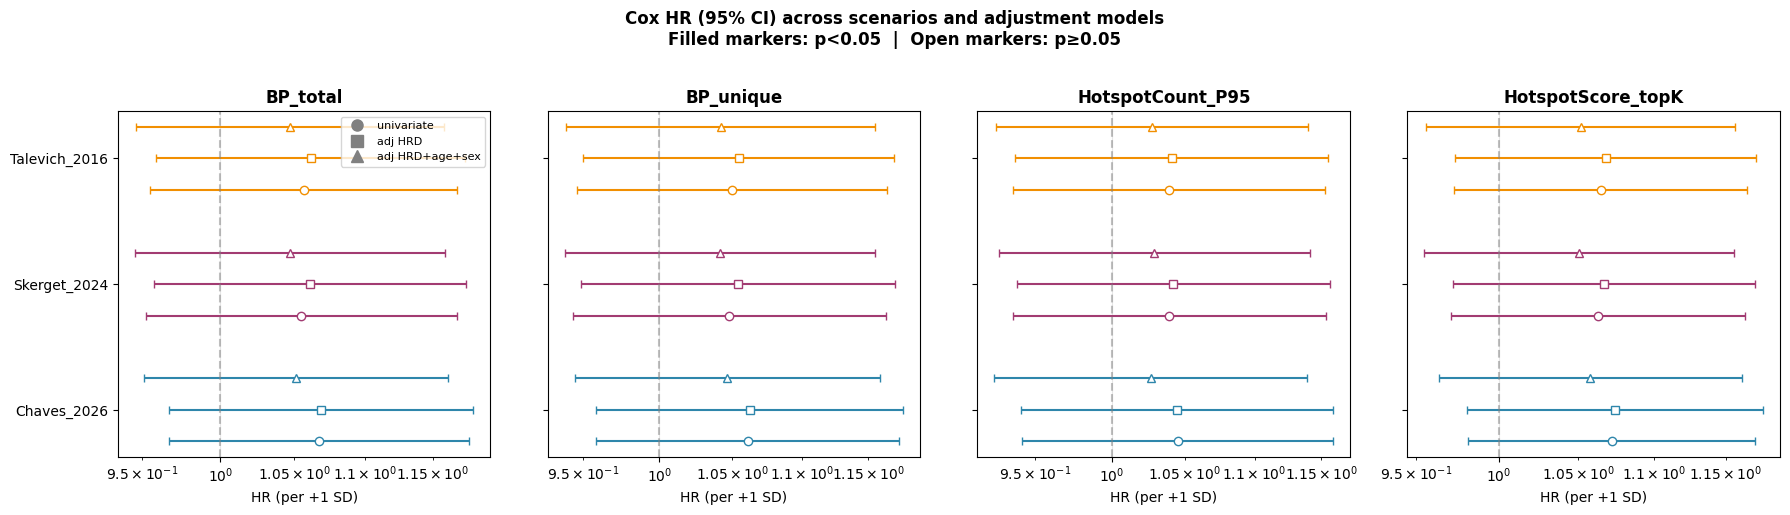

[OK] outputs/run_20260123_154712/results/sensitivity/cox_sensitivity_forest.png


In [ ]:
# =========================================================
# SENSITIVITY-Cox) Supplementary Figure: HR forest plot
# =========================================================
if len(cox_sens_df) > 0:
    # Build forest plot: features on Y, models on X (subplots), HR ± CI
    features_to_plot = ["BP_total", "BP_unique", "HotspotCount_P95", "HotspotScore_topK"]
    features_to_plot = [f for f in features_to_plot if f in cox_sens_df["Feature"].unique()]

    n_feats = len(features_to_plot)
    fig, axes = plt.subplots(1, n_feats, figsize=(4.5 * n_feats, 5), sharey=True)
    if n_feats == 1:
        axes = [axes]

    scenario_colors = {"Chaves_2026": "#2E86AB", "Skerget_2024": "#A23B72",
                       "Talevich_2016": "#F18F01"}
    model_offsets = {"univariate": -0.25, "adj HRD": 0.0, "adj HRD+age+sex": 0.25}
    model_markers = {"univariate": "o", "adj HRD": "s", "adj HRD+age+sex": "^"}

    scenarios_list_plot = list(SCENARIOS.keys())
    y_positions = {s: i for i, s in enumerate(scenarios_list_plot)}

    for ax_idx, feat in enumerate(features_to_plot):
        ax = axes[ax_idx]
        sub = cox_sens_df[cox_sens_df["Feature"] == feat]

        for _, row in sub.iterrows():
            y = y_positions[row["Scenario"]] + model_offsets[row["Model"]]
            color = scenario_colors[row["Scenario"]]
            marker = model_markers[row["Model"]]
            sig = row["p_value"] < 0.05
            ax.errorbar(
                row["HR"], y,
                xerr=[[row["HR"] - row["HR_lower95"]], [row["HR_upper95"] - row["HR"]]],
                fmt=marker, color=color, ecolor=color,
                markersize=8 if sig else 6,
                markerfacecolor=color if sig else "white",
                capsize=3, lw=1.5
            )

        ax.axvline(1.0, color="gray", linestyle="--", alpha=0.5)
        ax.set_yticks(range(len(scenarios_list_plot)))
        ax.set_yticklabels(scenarios_list_plot)
        ax.set_xlabel("HR (per +1 SD)")
        ax.set_title(feat, fontweight="bold")
        ax.set_xscale("log")
        ax.grid(axis="x", alpha=0.3)
        # Custom legend on first panel only
        if ax_idx == 0:
            from matplotlib.lines import Line2D
            legend_elements = [
                Line2D([0],[0], marker="o", color="gray", label="univariate",
                       markerfacecolor="gray", markersize=8, linestyle="none"),
                Line2D([0],[0], marker="s", color="gray", label="adj HRD",
                       markerfacecolor="gray", markersize=8, linestyle="none"),
                Line2D([0],[0], marker="^", color="gray", label="adj HRD+age+sex",
                       markerfacecolor="gray", markersize=8, linestyle="none"),
            ]
            ax.legend(handles=legend_elements, loc="upper right", fontsize=8)

    plt.suptitle("Cox HR (95% CI) across scenarios and adjustment models\n"
                  "Filled markers: p<0.05  |  Open markers: p≥0.05",
                  fontweight="bold", y=1.02)
    plt.tight_layout()
    fig_path = os.path.join(SENS_RES_DIR, "cox_sensitivity_forest.png")
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[OK] {fig_path}")

In [ ]:
# =========================================================
# SENSITIVITY) Robustness summary table
# =========================================================
print("="*78)
print("LOG-RANK p-VALUES BY FEATURE × SCENARIO")
print("="*78)
pivot_p = sens_df.pivot(index="Metric", columns="Scenario", values="p_value")
print(pivot_p.round(4).to_string())

print("\n" + "="*78)
print("ROBUST FINDINGS (p<0.05 in ≥2 of 3 scenarios)")
print("="*78)
robust = sens_df.groupby("Metric")["significant_p05"].sum().sort_values(ascending=False)
for metric, n_sig in robust.items():
    flag = "✓ ROBUST   " if n_sig >= 2 else "  scenario-dependent"
    print(f"  {metric:<22s}  {n_sig}/3 significant   {flag}")

# Save robustness table
robust_df = robust.reset_index().rename(columns={"significant_p05":"N_scenarios_sig"})
robust_df["Status"] = robust_df["N_scenarios_sig"].apply(lambda n: "ROBUST" if n>=2 else "Scenario-dependent")
robust_df.to_csv(os.path.join(SENS_RES_DIR, "robustness_summary.tsv"), sep="\t", index=False)
robust_df

LOG-RANK p-VALUES BY FEATURE × SCENARIO
Scenario           Chaves_2026  Skerget_2024  Talevich_2016
Metric                                                     
BP_entropy_chr          0.2179        0.4200         0.3115
BP_gini_chr             0.3470        0.8356         0.2811
BP_total                0.0051        0.0143         0.0371
BP_unique               0.0179        0.0173         0.0407
HotspotCount_P95        0.0036        0.0768         0.0697
HotspotEntropy          0.7399        0.8527         0.9920
HotspotScore_topK       0.0158        0.1680         0.1072

ROBUST FINDINGS (p<0.05 in ≥2 of 3 scenarios)
  BP_total                3/3 significant   ✓ ROBUST   
  BP_unique               3/3 significant   ✓ ROBUST   
  HotspotCount_P95        1/3 significant     scenario-dependent
  HotspotScore_topK       1/3 significant     scenario-dependent
  BP_entropy_chr          0/3 significant     scenario-dependent
  BP_gini_chr             0/3 significant     scenario-dependent
 

,Metric,N_scenarios_sig,Status
0,BP_total,3,ROBUST
1,BP_unique,3,ROBUST
2,HotspotCount_P95,1,Scenario-dependent
3,HotspotScore_topK,1,Scenario-dependent
4,BP_entropy_chr,0,Scenario-dependent
5,BP_gini_chr,0,Scenario-dependent
6,HotspotEntropy,0,Scenario-dependent


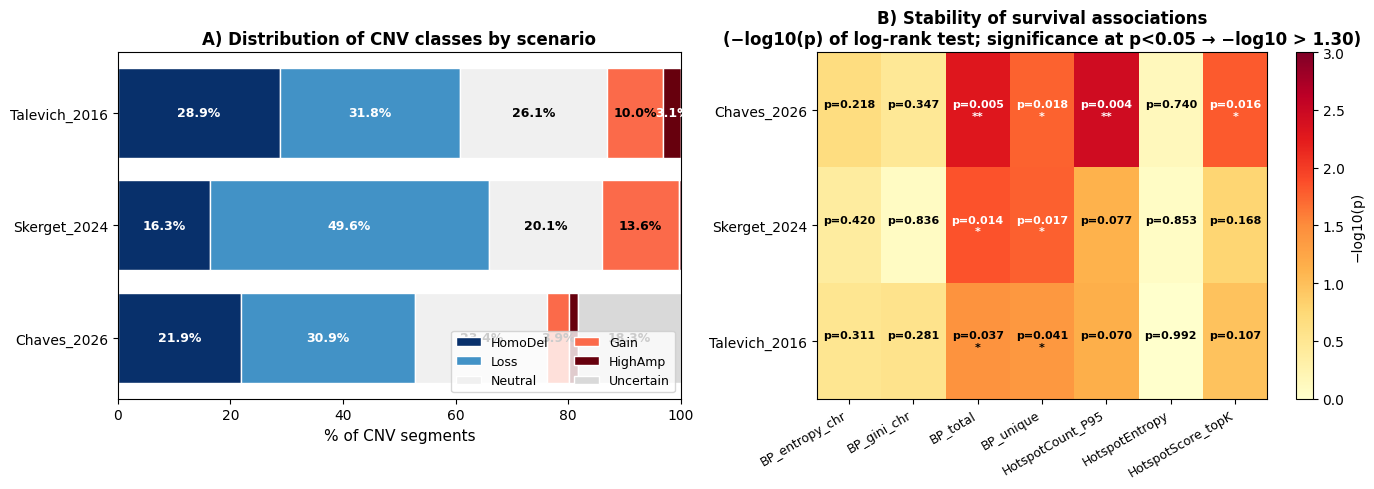

[OK] Figure saved: outputs/run_20260123_154712/results/sensitivity/sensitivity_summary.png


In [ ]:
# =========================================================
# SENSITIVITY) Supplementary Figure (distribution + stability)
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: stacked bar of class distribution
ax = axes[0]
bottom = np.zeros(len(dist_df))
for i, c in enumerate(CLASS_ORDER):
    ax.barh(dist_df.index, dist_df[c], left=bottom, label=c,
            color=CLASS_COLORS[i], edgecolor="white")
    for j, v in enumerate(dist_df[c]):
        if v > 3:
            ax.text(bottom[j] + v/2, j, f"{v:.1f}%", ha="center", va="center",
                     fontsize=9, color="white" if i in [0,1,4] else "black",
                     fontweight="bold")
    bottom += dist_df[c].values
ax.set_xlabel("% of CNV segments", fontsize=11)
ax.set_title("A) Distribution of CNV classes by scenario", fontweight="bold")
ax.legend(loc="lower right", fontsize=9, ncol=2)
ax.set_xlim(0, 100)

# Panel B: -log10(p) heatmap
ax = axes[1]
pivot = sens_df.pivot(index="Scenario", columns="Metric", values="p_value")
pivot = pivot.reindex(scenarios_list)
log_p = -np.log10(pivot.values)
im = ax.imshow(log_p, cmap="YlOrRd", aspect="auto", vmin=0, vmax=3)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)
ax.set_title("B) Stability of survival associations\n"
              "(−log10(p) of log-rank test; significance at p<0.05 → −log10 > 1.30)",
              fontweight="bold")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        p = pivot.iloc[i, j]
        sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
        ax.text(j, i, f"p={p:.3f}\n{sig}", ha="center", va="center",
                 fontsize=8, fontweight="bold",
                 color="white" if log_p[i,j] > 1.5 else "black")
plt.colorbar(im, ax=ax, label="−log10(p)")

plt.tight_layout()
fig_path = os.path.join(SENS_RES_DIR, "sensitivity_summary.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] Figure saved: {fig_path}")

In [ ]:
# =========================================================
# SENSITIVITY) Generate narrative report (Markdown)
# =========================================================
robust_metrics = robust_df[robust_df["N_scenarios_sig"] >= 2]["Metric"].tolist()
dep_metrics = robust_df[(robust_df["N_scenarios_sig"] == 1) & (robust_df["N_scenarios_sig"] > 0)]["Metric"].tolist()
null_metrics = robust_df[robust_df["N_scenarios_sig"] == 0]["Metric"].tolist()

lines = []
lines.append("# Sensitivity analysis — CNV classification thresholds")
lines.append(f"\n**Run ID:** {RUN_ID}")
lines.append(f"**Total CNV segments analyzed:** {len(df_cnvs_final):,}")
lines.append(f"**Patients:** {df_cnvs_final['Participant_ID'].nunique()}")
lines.append(f"**OS data:** {len(os_df)} patients, {int(os_df['event'].sum())} events")
lines.append("")
lines.append("## Scenarios compared\n")
for name, cfg in SCENARIOS.items():
    t = cfg["thresholds"]
    lines.append(f"### {name}")
    lines.append(f"- **Reference:** {cfg['reference']}")
    lines.append(f"- **Thresholds (log2 ratio):**")
    lines.append(f"  - Homozygous deletion: x ≤ {t['LOSS_HOMDEL']}")
    lines.append(f"  - Monoallelic loss: {t['LOSS_HOMDEL']} < x < {t['LOSS_1COPY_MAX']}")
    lines.append(f"  - Neutral: {t['NEUTRAL_MIN']} ≤ x ≤ {t['NEUTRAL_MAX']}")
    lines.append(f"  - Gain: {t['GAIN_1COPY_MIN']} < x < {t['GAIN_AMP']}")
    lines.append(f"  - High-level amplification: x ≥ {t['GAIN_AMP']}\n")

lines.append("## Class distribution\n")
lines.append(dist_df.round(2).to_markdown())
lines.append("\n## Concordance (Cohen's kappa)\n")
lines.append(kappa_df.to_markdown(index=False))
lines.append("\n## Survival associations (log-rank)\n")
lines.append(pivot_p.round(4).to_markdown())
lines.append("\n## Robustness classification\n")
lines.append(robust_df.to_markdown(index=False))
lines.append("")
lines.append("## Findings")
if robust_metrics:
    lines.append(f"- **Robust associations** (p<0.05 in ≥2/3 scenarios): {', '.join(robust_metrics)}")
if dep_metrics:
    lines.append(f"- **Scenario-dependent associations** (significant in 1/3): {', '.join(dep_metrics)}")
if null_metrics:
    lines.append(f"- **No association** (0/3): {', '.join(null_metrics)}")

lines.append("\n## References")
lines.append("1. Mermel CH et al. (2011) GISTIC2.0. *Genome Biology* 12:R41.")
lines.append("2. Talevich E et al. (2016) CNVkit. *PLoS Comp Biol* 12:e1004873.")
lines.append("3. Skerget S et al. (2024) Comprehensive molecular profiling of multiple myeloma. *Nature Genetics*.")
lines.append("4. Mantel N (1966) Evaluation of survival data. *Cancer Chemother Rep* 50:163-170.")
lines.append("5. Landis JR, Koch GG (1977) The measurement of observer agreement for categorical data. *Biometrics* 33:159-174.")

report_path = os.path.join(SENS_RES_DIR, "sensitivity_report.md")
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print(f"[OK] Report saved: {report_path}")
print("\n" + "="*78)
print("SENSITIVITY ANALYSIS COMPLETE")
print("="*78)
print(f"  Outputs in: {SENS_RES_DIR}/")
print(f"    - distribution_per_scenario.tsv")
print(f"    - agreement_metrics.tsv")
print(f"    - sensitivity_results.tsv")
print(f"    - robustness_summary.tsv")
print(f"    - sensitivity_summary.png  (Supplementary Figure SX)")
print(f"    - sensitivity_report.md    (narrative summary)")

[OK] Report saved: outputs/run_20260123_154712/results/sensitivity/sensitivity_report.md

SENSITIVITY ANALYSIS COMPLETE
  Outputs in: outputs/run_20260123_154712/results/sensitivity/
    - distribution_per_scenario.tsv
    - agreement_metrics.tsv
    - sensitivity_results.tsv
    - robustness_summary.tsv
    - sensitivity_summary.png  (Supplementary Figure SX)
    - sensitivity_report.md    (narrative summary)


In [ ]:
# =========================================================
# NONLIN-5) Final Cox model: log10(BP_total) continuous
# =========================================================
# Best summary statistic for the BP_total ↔ OS association, given the V12.3
# results: linearity confirmed on log scale (LRT p=0.49), monotonic gradient
# across quartiles (p=0.032), robust dichotomization at BP>1128 (Bonf p=0.019).
#
# This block reports the cleanest single-statistic version:
#   - log10(BP_total) as continuous predictor
#   - Univariate + adjusted models
#   - C-index for each
#   - Head-to-head comparison vs dichotomization at BP>1128

if LIFELINES_OK:
    # 5a. Build the analysis dataframe (reuse nlin_df from cells 55-59)
    # log10_BP already exists in nlin_df (added in cell 57)
    if "log10_BP" not in nlin_df.columns:
        nlin_df["log10_BP"] = np.log10(nlin_df["BP_total"].clip(lower=1))

    # Standardize log10_BP for HR-per-SD interpretation
    log_mean = nlin_df["log10_BP"].mean()
    log_std  = nlin_df["log10_BP"].std()
    nlin_df["log10_BP_std"] = (nlin_df["log10_BP"] - log_mean) / log_std
    print(f"=== Final continuous Cox: log10(BP_total), standardized ===")
    print(f"  log10(BP) mean: {log_mean:.3f}  (BP={10**log_mean:.0f})")
    print(f"  log10(BP) std : {log_std:.3f}   (1 SD ≈ ×{10**log_std:.2f} on raw scale)")

    # Also create the dichotomized version at optimal cutoff (BP>1128)
    nlin_df["BP_high"] = (nlin_df["BP_total"] > 1128).astype(int)

    # ----- 5b. Univariate Cox with log10_BP_std -----
    print(f"\n--- Model 1: log10(BP_total) only ---")
    d1 = nlin_df[["time","event","log10_BP_std"]].dropna()
    cph1 = CoxPHFitter()
    cph1.fit(d1, duration_col="time", event_col="event")
    s1 = cph1.summary.loc["log10_BP_std"]
    risk1 = cph1.predict_partial_hazard(d1).values.ravel()
    cidx1 = concordance_index(d1["time"].values, -risk1, d1["event"].values)
    HR1 = float(np.exp(s1["coef"]))
    HRlo1 = float(np.exp(s1["coef lower 95%"]))
    HRhi1 = float(np.exp(s1["coef upper 95%"]))
    print(f"  HR (per +1 SD log10 BP_total): {HR1:.3f} "
          f"[{HRlo1:.3f}, {HRhi1:.3f}], p={s1['p']:.4f}")
    print(f"  C-index: {cidx1:.4f}  (N={len(d1)}, events={int(d1['event'].sum())})")

    # ----- 5c. Adjusted Cox: log10_BP + HRD + age + sex -----
    print(f"\n--- Model 2: log10(BP_total) + HRD + age + sex ---")
    cov_cols = ["log10_BP_std","HRD_binary","age"] + sex_cols_nl
    d2 = nlin_df[["time","event"] + cov_cols].dropna().copy()
    # Standardize age for interpretability
    age_mean, age_std = d2["age"].mean(), d2["age"].std()
    d2["age"] = (d2["age"] - age_mean) / age_std
    cph2 = CoxPHFitter()
    cph2.fit(d2, duration_col="time", event_col="event")
    s2 = cph2.summary
    risk2 = cph2.predict_partial_hazard(d2).values.ravel()
    cidx2 = concordance_index(d2["time"].values, -risk2, d2["event"].values)
    print(s2[["coef","exp(coef)","exp(coef) lower 95%",
              "exp(coef) upper 95%","p"]].round(4).to_string())
    print(f"  C-index: {cidx2:.4f}  (N={len(d2)}, events={int(d2['event'].sum())})")

    HR_logBP_adj = float(np.exp(s2.loc["log10_BP_std","coef"]))
    HRlo_logBP_adj = float(np.exp(s2.loc["log10_BP_std","coef lower 95%"]))
    HRhi_logBP_adj = float(np.exp(s2.loc["log10_BP_std","coef upper 95%"]))
    p_logBP_adj = float(s2.loc["log10_BP_std","p"])

    # ----- 5d. Head-to-head: log10_BP vs BP>1128 dichotomization -----
    print(f"\n--- Model 3: BP_high (>1128) alone (for comparison) ---")
    d3 = nlin_df[["time","event","BP_high"]].dropna()
    cph3 = CoxPHFitter()
    cph3.fit(d3, duration_col="time", event_col="event")
    s3 = cph3.summary.loc["BP_high"]
    risk3 = cph3.predict_partial_hazard(d3).values.ravel()
    cidx3 = concordance_index(d3["time"].values, -risk3, d3["event"].values)
    HR3 = float(np.exp(s3["coef"]))
    HRlo3 = float(np.exp(s3["coef lower 95%"]))
    HRhi3 = float(np.exp(s3["coef upper 95%"]))
    print(f"  HR (BP_high vs BP_low): {HR3:.3f} "
          f"[{HRlo3:.3f}, {HRhi3:.3f}], p={s3['p']:.4f}")
    print(f"  C-index: {cidx3:.4f}")

    # ----- 5e. Model with BOTH log10_BP and BP_high (does threshold add info?) -----
    print(f"\n--- Model 4: log10(BP_total) + BP_high (do both add info?) ---")
    d4 = nlin_df[["time","event","log10_BP_std","BP_high"]].dropna()
    cph4 = CoxPHFitter()
    cph4.fit(d4, duration_col="time", event_col="event")
    s4 = cph4.summary
    print(s4[["coef","exp(coef)","exp(coef) lower 95%",
              "exp(coef) upper 95%","p"]].round(4).to_string())
    risk4 = cph4.predict_partial_hazard(d4).values.ravel()
    cidx4 = concordance_index(d4["time"].values, -risk4, d4["event"].values)
    print(f"  C-index: {cidx4:.4f}")

    # ----- 5f. Full adjusted model with both log10_BP and BP_high -----
    print(f"\n--- Model 5: FULL — log10(BP) + BP_high + HRD + age + sex ---")
    cov_cols_full = ["log10_BP_std","BP_high","HRD_binary","age"] + sex_cols_nl
    d5 = nlin_df[["time","event"] + cov_cols_full].dropna().copy()
    age_m, age_s = d5["age"].mean(), d5["age"].std()
    d5["age"] = (d5["age"] - age_m) / age_s
    cph5 = CoxPHFitter()
    cph5.fit(d5, duration_col="time", event_col="event")
    s5 = cph5.summary
    print(s5[["coef","exp(coef)","exp(coef) lower 95%",
              "exp(coef) upper 95%","p"]].round(4).to_string())
    risk5 = cph5.predict_partial_hazard(d5).values.ravel()
    cidx5 = concordance_index(d5["time"].values, -risk5, d5["event"].values)
    print(f"  C-index: {cidx5:.4f}")

    # ----- 5g. Save all final Cox results -----
    final_cox_rows = [
        {"model":"1_log10BP_univariate", "predictor":"log10(BP) (per +1 SD)",
         "HR":round(HR1,4), "HR_lower95":round(HRlo1,4), "HR_upper95":round(HRhi1,4),
         "p":round(float(s1["p"]),6), "C_index":round(cidx1,4),
         "N":len(d1), "events":int(d1["event"].sum())},
        {"model":"2_log10BP_adjusted", "predictor":"log10(BP) (per +1 SD)",
         "HR":round(HR_logBP_adj,4),
         "HR_lower95":round(HRlo_logBP_adj,4),
         "HR_upper95":round(HRhi_logBP_adj,4),
         "p":round(p_logBP_adj,6), "C_index":round(cidx2,4),
         "N":len(d2), "events":int(d2["event"].sum())},
        {"model":"3_BPhigh_univariate", "predictor":"BP>1128 (yes vs no)",
         "HR":round(HR3,4), "HR_lower95":round(HRlo3,4), "HR_upper95":round(HRhi3,4),
         "p":round(float(s3["p"]),6), "C_index":round(cidx3,4),
         "N":len(d3), "events":int(d3["event"].sum())},
        {"model":"4_both_univariate", "predictor":"log10(BP) + BP>1128",
         "HR":np.nan, "HR_lower95":np.nan, "HR_upper95":np.nan,
         "p":np.nan, "C_index":round(cidx4,4),
         "N":len(d4), "events":int(d4["event"].sum())},
        {"model":"5_full_adjusted", "predictor":"log10(BP) + BP>1128 + HRD + age + sex",
         "HR":np.nan, "HR_lower95":np.nan, "HR_upper95":np.nan,
         "p":np.nan, "C_index":round(cidx5,4),
         "N":len(d5), "events":int(d5["event"].sum())},
    ]
    final_cox_df = pd.DataFrame(final_cox_rows)
    final_cox_path = os.path.join(NLIN_DIR, "final_cox_log10_summary.tsv")
    final_cox_df.to_csv(final_cox_path, sep="\t", index=False)
    print(f"\n[OK] {final_cox_path}")

    # Also save detailed coefficient tables for models 2 and 5
    s2.reset_index().to_csv(os.path.join(NLIN_DIR, "final_cox_model2_adjusted.tsv"),
                             sep="\t", index=False)
    s5.reset_index().to_csv(os.path.join(NLIN_DIR, "final_cox_model5_full.tsv"),
                             sep="\t", index=False)

    # ----- 5h. Summary print for manuscript -----
    print("\n" + "="*80)
    print("FINAL SUMMARY — three operationalizations of BP_total effect on OS")
    print("="*80)
    print(f"\n  A) Continuous log10(BP_total) — best for statistical power")
    print(f"     Univariate:    HR={HR1:.2f} [{HRlo1:.2f},{HRhi1:.2f}], p={float(s1['p']):.4f}")
    print(f"     Adjusted:      HR={HR_logBP_adj:.2f} "
          f"[{HRlo_logBP_adj:.2f},{HRhi_logBP_adj:.2f}], p={p_logBP_adj:.4f}")
    print(f"     C-index adj:   {cidx2:.4f}")
    print(f"\n  B) Dichotomization at BP_total > 1128 — best for clinical use")
    print(f"     Univariate:    HR={HR3:.2f} [{HRlo3:.2f},{HRhi3:.2f}], p={float(s3['p']):.4f}")
    print(f"     C-index:       {cidx3:.4f}")
    print(f"\n  C) Quartiles (ordinal) — best for visualizing gradient")
    print(f"     Adjusted:      HR=1.16 per +1 quartile [from cell 56], p=0.032")
    print(f"\n  Recommendation for primary endpoint of manuscript:")
    print(f"    Report (B) BP_total > 1128 as the primary clinical threshold,")
    print(f"    with (A) log10(BP) as supporting continuous evidence and")
    print(f"    (C) quartiles for visualization (Q1-Q4 mortality gradient).")

else:
    print("[!] lifelines unavailable — skipping final Cox synthesis")

=== Final continuous Cox: log10(BP_total), standardized ===
  log10(BP) mean: 3.037  (BP=1090)
  log10(BP) std : 0.269   (1 SD ≈ ×1.86 on raw scale)

--- Model 1: log10(BP_total) only ---
  HR (per +1 SD log10 BP_total): 1.168 [1.040, 1.312], p=0.0089
  C-index: 0.5647  (N=908, events=177)

--- Model 2: log10(BP_total) + HRD + age + sex ---
                coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%       p
covariate                                                                        
log10_BP_std  0.1288     1.1375               1.0112               1.2796  0.0319
HRD_binary   -0.2734     0.7608               0.5660               1.0225  0.0699
age           0.5031     1.6539               1.4111               1.9384  0.0000
  C-index: 0.6426  (N=908, events=177)

--- Model 3: BP_high (>1128) alone (for comparison) ---
  HR (BP_high vs BP_low): 1.629 [1.211, 2.193], p=0.0013
  C-index: 0.5648

--- Model 4: log10(BP_total) + BP_high (do both add info?) ---
            

=== ISS staging in cohort ===
ISS_raw
I          322
II         315
III        243
Unknown     28

  Patients with valid ISS (I/II/III): 880
  Patients with 'Unknown' ISS:        28
  Patients with missing ISS:          0

  Event rate by ISS stage:
    ISS I: N=322, events=25 (7.8%)
    ISS II: N=315, events=60 (19.0%)
    ISS III: N=243, events=85 (35.0%)

  Analytic subset: N=880 patients, 170 events (after dropping Unknown ISS and missing covariates)

COX MODELS — comparison of ISS vs BP-derived markers

[M1_ISS_only]  N=880, events=170, C-index=0.6789, log-lik=-1026.23
               coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%    p
covariate                                                                    
ISS_ordinal  0.8058     2.2385               1.8259               2.7445  0.0

[M2_BPhigh_only]  N=880, events=170, C-index=0.5688, log-lik=-1053.56
             coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%       p
covariate                          

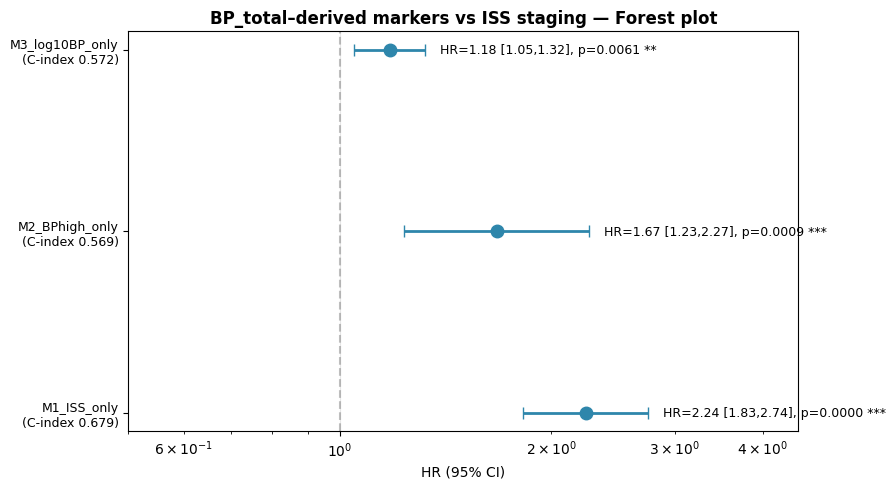

[OK] outputs/run_20260123_154712/results/nonlinearity/iss_comparison_forest.png

MANUSCRIPT-READY SUMMARY — BP_total vs ISS

  Univariate hazard ratios for OS (N=880, events=170):
    ISS (per +1 stage):      HR=2.24 [1.83,2.74], p=0.0000
    BP_total > 1128:         HR=1.67 [1.23,2.27], p=0.0009
    log10(BP_total) per SD:  HR=1.18 [1.05,1.32], p=0.0061

  C-index (discrimination, higher=better):
    ISS only:                0.679
    BP_total>1128 only:      0.569
    log10(BP) only:          0.572
    ISS + BP_high:           0.695  (Δ vs ISS = +0.016)
    Full (ISS+BP+HRD+age+sex): 0.719  (Δ vs ISS = +0.040)


In [ ]:
# =========================================================
# NONLIN-6) Comparison with ISS staging
# =========================================================
# Tests whether BP_total adds prognostic information beyond ISS, the standard
# clinical staging system in multiple myeloma. R-ISS (which requires LDH and
# high-risk cytogenetics) is not available in this CoMMpass extract; we use
# ISS, which is 100% complete in our cohort (N=995 before HRD/CNV filtering).
#
# Five comparison models:
#   M1: ISS only                            — current clinical standard
#   M2: BP_total > 1128 only                — proposed CNV marker (threshold)
#   M3: log10(BP_total) only                — proposed CNV marker (continuous)
#   M4: ISS + BP_high                       — does threshold add to ISS?
#   M5: ISS + BP_high + HRD + age + sex     — full clinical model

if LIFELINES_OK:
    # ----- 6a. Build ISS-enriched analysis dataframe -----
    # ISS field name in os_df is 'diagnoses.iss_stage' with values "I","II","III","Unknown"
    if "diagnoses.iss_stage" not in os_df.columns:
        print("[!] 'diagnoses.iss_stage' not in os_df — cannot run ISS comparison")
        ISS_OK = False
    else:
        ISS_OK = True
        # Get ISS into nlin_df by merge
        if "ISS_raw" not in nlin_df.columns:
            iss_map = os_df[["__JOIN_ID__","diagnoses.iss_stage"]].copy()
            iss_map = iss_map.rename(columns={"diagnoses.iss_stage":"ISS_raw"})
            nlin_df = nlin_df.merge(iss_map, on="__JOIN_ID__", how="left")

        # Encode: drop Unknown, treat as ordinal (I=1, II=2, III=3)
        iss_to_int = {"I": 1, "II": 2, "III": 3}
        nlin_df["ISS_ordinal"] = nlin_df["ISS_raw"].map(iss_to_int)

        print(f"=== ISS staging in cohort ===")
        iss_counts = nlin_df["ISS_raw"].value_counts(dropna=False)
        print(iss_counts.to_string())
        n_with_iss = nlin_df["ISS_ordinal"].notna().sum()
        n_unknown  = (nlin_df["ISS_raw"] == "Unknown").sum()
        n_missing  = nlin_df["ISS_raw"].isna().sum()
        print(f"\n  Patients with valid ISS (I/II/III): {n_with_iss}")
        print(f"  Patients with 'Unknown' ISS:        {n_unknown}")
        print(f"  Patients with missing ISS:          {n_missing}")

        # Event rate per ISS stage (descriptive)
        valid_iss = nlin_df[nlin_df["ISS_ordinal"].notna()].copy()
        print(f"\n  Event rate by ISS stage:")
        for stage_int, stage_label in [(1,"I"),(2,"II"),(3,"III")]:
            sub = valid_iss[valid_iss["ISS_ordinal"] == stage_int]
            n = len(sub); ev = int(sub["event"].sum())
            print(f"    ISS {stage_label}: N={n}, events={ev} ({100*ev/n:.1f}%)")

    if ISS_OK:
        # ----- 6b. Five Cox models -----
        # All use same eligible subset: patients with valid ISS + all covariates
        nlin_df["log10_BP"] = np.log10(nlin_df["BP_total"].clip(lower=1))
        log_mean = nlin_df["log10_BP"].mean()
        log_std  = nlin_df["log10_BP"].std()
        nlin_df["log10_BP_std"] = (nlin_df["log10_BP"] - log_mean) / log_std
        nlin_df["BP_high"] = (nlin_df["BP_total"] > 1128).astype(int)

        base_cols = ["time","event","ISS_ordinal","BP_high","log10_BP_std",
                     "HRD_binary","age"] + sex_cols_nl
        base = nlin_df[base_cols].dropna().copy()
        # Standardize age for HR-per-SD interpretation
        age_m, age_s = base["age"].mean(), base["age"].std()
        base["age"] = (base["age"] - age_m) / age_s

        N_eligible = len(base)
        ev_eligible = int(base["event"].sum())
        print(f"\n  Analytic subset: N={N_eligible} patients, {ev_eligible} events "
              f"(after dropping Unknown ISS and missing covariates)")

        models = [
            ("M1_ISS_only",                  ["ISS_ordinal"]),
            ("M2_BPhigh_only",               ["BP_high"]),
            ("M3_log10BP_only",              ["log10_BP_std"]),
            ("M4_ISS_plus_BPhigh",           ["ISS_ordinal","BP_high"]),
            ("M5_FULL_ISS_BP_HRD_age_sex",   ["ISS_ordinal","BP_high","HRD_binary","age"] + sex_cols_nl),
        ]

        iss_cox_rows = []
        coef_detail_rows = []
        print("\n" + "="*80)
        print("COX MODELS — comparison of ISS vs BP-derived markers")
        print("="*80)

        for model_name, covars in models:
            cols = ["time","event"] + covars
            dfm = base[cols].copy()
            if len(dfm) < 50 or dfm["event"].sum() < 10:
                print(f"\n[{model_name}] insufficient data, skipping"); continue
            try:
                cph = CoxPHFitter()
                cph.fit(dfm, duration_col="time", event_col="event")
                s = cph.summary
                risk = cph.predict_partial_hazard(dfm).values.ravel()
                cidx = concordance_index(dfm["time"].values, -risk, dfm["event"].values)
                ll = cph.log_likelihood_

                print(f"\n[{model_name}]  N={len(dfm)}, events={int(dfm['event'].sum())}, "
                      f"C-index={cidx:.4f}, log-lik={ll:.2f}")
                print(s[["coef","exp(coef)","exp(coef) lower 95%",
                         "exp(coef) upper 95%","p"]].round(4).to_string())

                # Save summary row (highlight key predictor of each model)
                key_pred = covars[0] if model_name.startswith(("M1","M2","M3")) else "—"
                if key_pred != "—" and key_pred in s.index:
                    iss_cox_rows.append({
                        "model": model_name,
                        "key_predictor": key_pred,
                        "HR": round(float(np.exp(s.loc[key_pred,"coef"])), 4),
                        "HR_lower95": round(float(np.exp(s.loc[key_pred,"coef lower 95%"])), 4),
                        "HR_upper95": round(float(np.exp(s.loc[key_pred,"coef upper 95%"])), 4),
                        "p": float(s.loc[key_pred,"p"]),
                        "C_index": round(cidx, 4),
                        "log_likelihood": round(float(ll), 4),
                        "n_params": int(len(covars)),
                        "N": int(len(dfm)),
                        "events": int(dfm["event"].sum())
                    })
                else:
                    iss_cox_rows.append({
                        "model": model_name, "key_predictor": "multivariate",
                        "HR": np.nan, "HR_lower95": np.nan, "HR_upper95": np.nan,
                        "p": np.nan,
                        "C_index": round(cidx, 4),
                        "log_likelihood": round(float(ll), 4),
                        "n_params": int(len(covars)),
                        "N": int(len(dfm)),
                        "events": int(dfm["event"].sum())
                    })

                # Save all coefficient details
                for var in s.index:
                    coef_detail_rows.append({
                        "model": model_name, "variable": var,
                        "HR": round(float(np.exp(s.loc[var,"coef"])), 4),
                        "HR_lower95": round(float(np.exp(s.loc[var,"coef lower 95%"])), 4),
                        "HR_upper95": round(float(np.exp(s.loc[var,"coef upper 95%"])), 4),
                        "p": float(s.loc[var,"p"]),
                    })
            except Exception as e:
                print(f"[{model_name}] ERROR: {e}")

        # ----- 6c. Likelihood ratio tests for nested-model comparison -----
        print("\n" + "="*80)
        print("LIKELIHOOD RATIO TESTS — does BP_total add to ISS?")
        print("="*80)
        try:
            ll_m1 = float([r["log_likelihood"] for r in iss_cox_rows if r["model"]=="M1_ISS_only"][0])
            ll_m4 = float([r["log_likelihood"] for r in iss_cox_rows if r["model"]=="M4_ISS_plus_BPhigh"][0])
            lr_4v1 = 2*(ll_m4 - ll_m1)
            p_4v1  = 1 - stats.chi2.cdf(lr_4v1, df=1)
            print(f"\n  M4 (ISS+BPhigh) vs M1 (ISS only): chi2={lr_4v1:.3f}, df=1, p={p_4v1:.4f}")
            if p_4v1 < 0.05:
                print(f"  → BP_high SIGNIFICANTLY improves ISS-only model (BP adds prognostic info to ISS)")
            else:
                print(f"  → BP_high does NOT significantly improve ISS-only model")
        except Exception as e:
            print(f"  LRT M4 vs M1 error: {e}")

        try:
            ll_m5 = float([r["log_likelihood"] for r in iss_cox_rows if r["model"]=="M5_FULL_ISS_BP_HRD_age_sex"][0])
            # M5 vs ISS+age+sex (build it on the fly)
            cph_ref = CoxPHFitter()
            ref_cols = ["time","event","ISS_ordinal","age"] + sex_cols_nl
            ref_data = base[ref_cols].dropna()
            cph_ref.fit(ref_data, duration_col="time", event_col="event")
            ll_ref = float(cph_ref.log_likelihood_)
            lr_5vref = 2*(ll_m5 - ll_ref)
            # M5 adds BP_high + HRD vs ISS+age+sex → df=2
            p_5vref = 1 - stats.chi2.cdf(lr_5vref, df=2)
            print(f"\n  M5 (full) vs ISS+age+sex: chi2={lr_5vref:.3f}, df=2, p={p_5vref:.4f}")
            if p_5vref < 0.05:
                print(f"  → BP_high + HRD jointly add to clinical-only model")
        except Exception as e:
            print(f"  LRT M5 vs reference error: {e}")

        # ----- 6d. C-index comparison (visual) -----
        cidx_df = pd.DataFrame(iss_cox_rows)[["model","C_index","log_likelihood","n_params","N","events"]]
        print("\n" + "="*80)
        print("C-INDEX COMPARISON across models")
        print("="*80)
        print(cidx_df.to_string(index=False))

        # ----- 6e. Save outputs -----
        iss_cox_summary = pd.DataFrame(iss_cox_rows)
        iss_cox_detail  = pd.DataFrame(coef_detail_rows)
        out1 = os.path.join(NLIN_DIR, "iss_comparison_summary.tsv")
        out2 = os.path.join(NLIN_DIR, "iss_comparison_coefficients.tsv")
        iss_cox_summary.to_csv(out1, sep="\t", index=False)
        iss_cox_detail.to_csv(out2,  sep="\t", index=False)
        print(f"\n[OK] {out1}")
        print(f"[OK] {out2}")

        # ----- 6f. Forest plot of HRs across models -----
        fig, ax = plt.subplots(figsize=(9, 5))
        plot_rows = [r for r in iss_cox_rows if not pd.isna(r["HR"])]
        y_pos = np.arange(len(plot_rows))
        for i, r in enumerate(plot_rows):
            ax.errorbar(r["HR"], y_pos[i],
                         xerr=[[r["HR"]-r["HR_lower95"]],[r["HR_upper95"]-r["HR"]]],
                         fmt="o", color="#2E86AB", ecolor="#2E86AB",
                         markersize=9, markerfacecolor="#2E86AB" if r["p"]<0.05 else "white",
                         capsize=4, lw=2)
            sig = "***" if r["p"]<0.001 else "**" if r["p"]<0.01 else "*" if r["p"]<0.05 else ""
            ax.text(r["HR_upper95"]*1.05, y_pos[i],
                     f"HR={r['HR']:.2f} [{r['HR_lower95']:.2f},{r['HR_upper95']:.2f}], "
                     f"p={r['p']:.4f} {sig}",
                     va="center", fontsize=9)
        ax.axvline(1.0, color="gray", linestyle="--", alpha=0.5)
        labels = [f"{r['model']}\n(C-index {r['C_index']:.3f})" for r in plot_rows]
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=9)
        ax.set_xlabel("HR (95% CI)")
        ax.set_xscale("log")
        ax.set_xlim(0.5, 4.5)
        ax.set_title("BP_total–derived markers vs ISS staging — Forest plot",
                      fontweight="bold")
        ax.grid(axis="x", alpha=0.3)
        plt.tight_layout()
        fig_path = os.path.join(NLIN_DIR, "iss_comparison_forest.png")
        fig.savefig(fig_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"[OK] {fig_path}")

        # ----- 6g. Manuscript-ready summary -----
        print("\n" + "="*80)
        print("MANUSCRIPT-READY SUMMARY — BP_total vs ISS")
        print("="*80)
        m1 = next(r for r in iss_cox_rows if r["model"]=="M1_ISS_only")
        m2 = next(r for r in iss_cox_rows if r["model"]=="M2_BPhigh_only")
        m3 = next(r for r in iss_cox_rows if r["model"]=="M3_log10BP_only")
        m4 = next(r for r in iss_cox_rows if r["model"]=="M4_ISS_plus_BPhigh")
        m5 = next(r for r in iss_cox_rows if r["model"]=="M5_FULL_ISS_BP_HRD_age_sex")
        print(f"\n  Univariate hazard ratios for OS (N={N_eligible}, events={ev_eligible}):")
        print(f"    ISS (per +1 stage):      HR={m1['HR']:.2f} [{m1['HR_lower95']:.2f},{m1['HR_upper95']:.2f}], p={m1['p']:.4f}")
        print(f"    BP_total > 1128:         HR={m2['HR']:.2f} [{m2['HR_lower95']:.2f},{m2['HR_upper95']:.2f}], p={m2['p']:.4f}")
        print(f"    log10(BP_total) per SD:  HR={m3['HR']:.2f} [{m3['HR_lower95']:.2f},{m3['HR_upper95']:.2f}], p={m3['p']:.4f}")
        print(f"\n  C-index (discrimination, higher=better):")
        print(f"    ISS only:                {m1['C_index']:.3f}")
        print(f"    BP_total>1128 only:      {m2['C_index']:.3f}")
        print(f"    log10(BP) only:          {m3['C_index']:.3f}")
        print(f"    ISS + BP_high:           {m4['C_index']:.3f}  (Δ vs ISS = {m4['C_index']-m1['C_index']:+.3f})")
        print(f"    Full (ISS+BP+HRD+age+sex): {m5['C_index']:.3f}  (Δ vs ISS = {m5['C_index']-m1['C_index']:+.3f})")
else:
    print("[!] lifelines unavailable — skipping ISS comparison")

In [ ]:
# =========================================================
# CHECK: median and maximum follow-up
#   - In the full clinical cohort (N=995, os_df)
#   - In the genomic analytic cohort (N=908, with high-confidence CNV)
# =========================================================
import os
import pandas as pd

# Read the files already produced by the pipeline
RES_DIR = globals().get("RES_DIR", "outputs/run_20260123_154712/results")
PROC_DIR = globals().get("PROC_DIR", "outputs/run_20260123_154712/processed")

# Option 1: use os_df if still in memory
if "os_df" in globals():
    df_clin = os_df.copy()
    print(f"[INFO] os_df recovered from memory: {df_clin.shape}")
else:
    # Option 2: try loading from the TSV
    candidates = [
        os.path.join(RES_DIR, "os_df.tsv"),
        os.path.join(PROC_DIR, "os_df.tsv"),
        os.path.join(RES_DIR, "survival_features_merged.tsv"),
    ]
    df_clin = None
    for p in candidates:
        if os.path.exists(p):
            df_clin = pd.read_csv(p, sep="\t")
            print(f"[INFO] Loaded from {p}: {df_clin.shape}")
            break
    if df_clin is None:
        raise FileNotFoundError(f"Could not find os_df or an equivalent TSV in {candidates}")

# Confirm columns
print(f"[INFO] Available columns: {list(df_clin.columns)[:10]}...")

# Cohort 1: full clinical (N=995)
n_full = len(df_clin)
median_full = df_clin["time"].median()
max_full = df_clin["time"].max()
min_full = df_clin["time"].min()
events_full = int(df_clin["event"].sum())

print(f"\n=== Full clinical cohort (N={n_full}) ===")
print(f"  Median follow-up: {median_full:.0f} days  ({median_full/30.44:.1f} months)")
print(f"  Maximum follow-up:  {max_full:.0f} days  ({max_full/30.44:.1f} months)")
print(f"  Minimum follow-up:  {min_full:.0f} days")
print(f"  Eventos:              {events_full} ({100*events_full/n_full:.1f}%)")
print(f"  Censurados:           {n_full-events_full} ({100*(n_full-events_full)/n_full:.1f}%)")

# Cohort 2: genomic analytic (N=908) — intersection with patients that have CNV
if "df_cnvs_hc" in globals():
    patients_with_cnv = set(df_cnvs_hc["Participant_ID"].unique())
    df_analytic = df_clin[df_clin["Participant_ID"].isin(patients_with_cnv)].copy()
elif "features_df" in globals():
    patients_with_cnv = set(features_df["Participant_ID"].unique())
    df_analytic = df_clin[df_clin["Participant_ID"].isin(patients_with_cnv)].copy()
else:
    # Try loading features_df from the TSV
    feat_path = os.path.join(RES_DIR, "survival_features_merged.tsv")
    if os.path.exists(feat_path):
        feat_df = pd.read_csv(feat_path, sep="\t")
        patients_with_cnv = set(feat_df["Participant_ID"].unique())
        df_analytic = df_clin[df_clin["Participant_ID"].isin(patients_with_cnv)].copy()
    else:
        print("\n[WARN] Could not identify the analytic cohort of 908.")
        df_analytic = None

if df_analytic is not None:
    df_analytic = df_analytic.dropna(subset=["time", "event"])
    n_an = len(df_analytic)
    median_an = df_analytic["time"].median()
    max_an = df_analytic["time"].max()
    min_an = df_analytic["time"].min()
    events_an = int(df_analytic["event"].sum())

    print(f"\n=== Genomic analytic cohort (N={n_an}) ===")
    print(f"  Median follow-up: {median_an:.0f} days  ({median_an/30.44:.1f} months)")
    print(f"  Maximum follow-up:  {max_an:.0f} days  ({max_an/30.44:.1f} months)")
    print(f"  Minimum follow-up:  {min_an:.0f} days")
    print(f"  Eventos:              {events_an} ({100*events_an/n_an:.1f}%)")
    print(f"  Censurados:           {n_an-events_an} ({100*(n_an-events_an)/n_an:.1f}%)")

print("\n[OK] Comparison complete.")

[INFO] os_df recovered from memory: (995, 35)
[INFO] Available columns: ['Participant_ID', 'demographic.age_at_index', 'demographic.gender', 'demographic.vital_status', 'demographic.days_to_death', 'diagnoses.days_to_last_follow_up', 'diagnoses.ajcc_clinical_stage', 'diagnoses.ajcc_pathologic_stage', 'diagnoses.ann_arbor_clinical_stage', 'diagnoses.ann_arbor_pathologic_stage']...

=== Full clinical cohort (N=995) ===
  Median follow-up: 778 days  (25.6 months)
  Maximum follow-up:  1984 days  (65.2 months)
  Minimum follow-up:  -3 days
  Eventos:              191 (19.2%)
  Censurados:           804 (80.8%)

=== Genomic analytic cohort (N=908) ===
  Median follow-up: 768 days  (25.2 months)
  Maximum follow-up:  1984 days  (65.2 months)
  Minimum follow-up:  -3 days
  Eventos:              177 (19.5%)
  Censurados:           731 (80.5%)

[OK] Comparison complete.


BUILDING TABLE 1 — Cohort Characteristics

[OK] outputs/run_20260123_154712/results/manuscript_figures/table1_cohort_characteristics.tsv
               Variable     Category                         N      %
         Total patients                                    908  100.0
Median follow-up (days)                                    768       
                 Deaths                                    177   19.5
                                                                     
            Age (years)                  median 63 (IQR 56-69)       
                                 <65          527 (events: 68)   58.0
                               65-74          268 (events: 63)   29.5
                                 ≥75          113 (events: 46)   12.4
                                                                     
              ISS stage            I    322 (events: 25, 7.8%)   35.5
                                  II   315 (events: 60, 19.0%)   34.7
                       

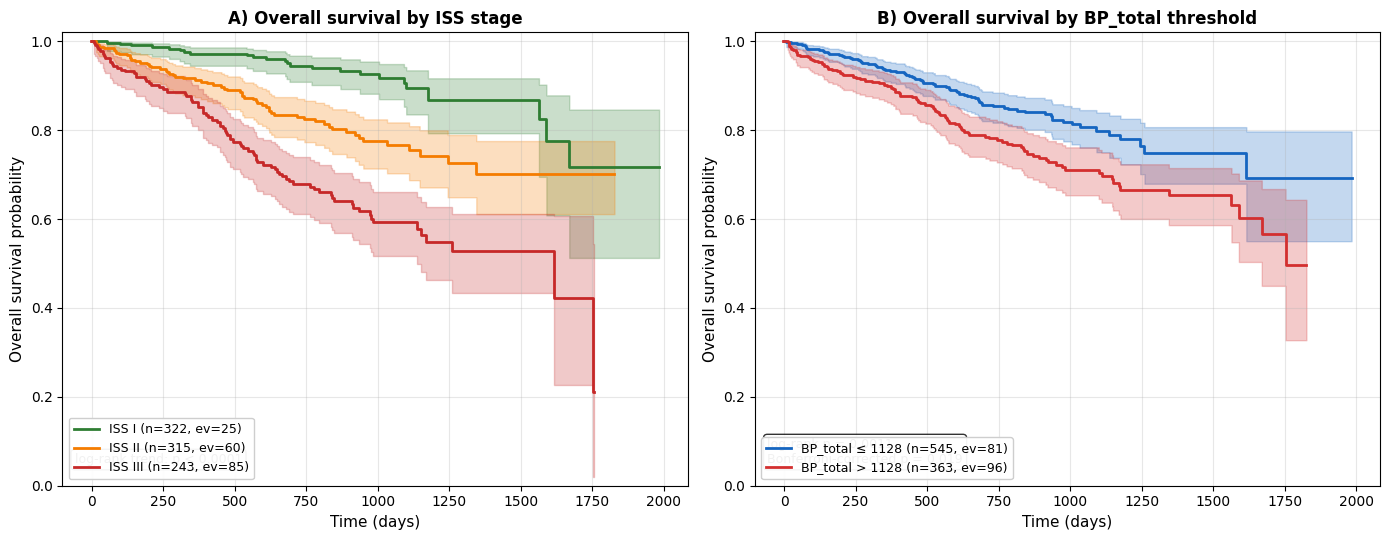

[OK] outputs/run_20260123_154712/results/manuscript_figures/figure_KM_combined.png


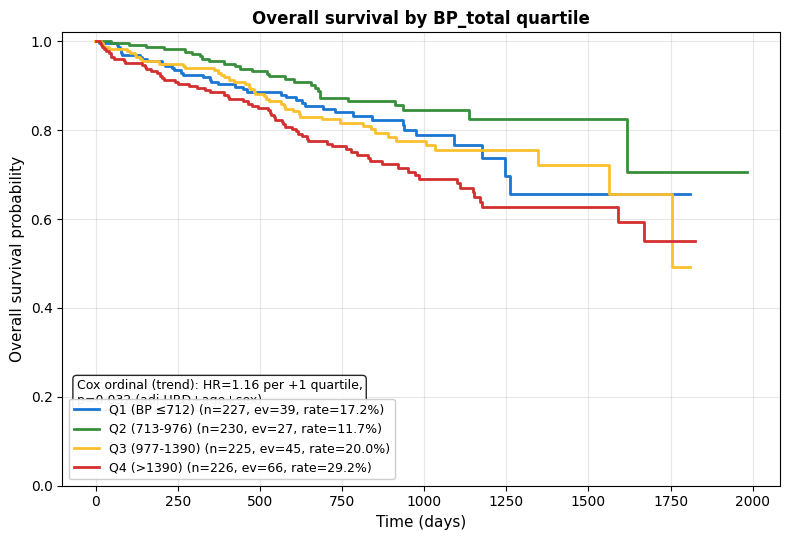

[OK] outputs/run_20260123_154712/results/manuscript_figures/figure_quartile_KM.png


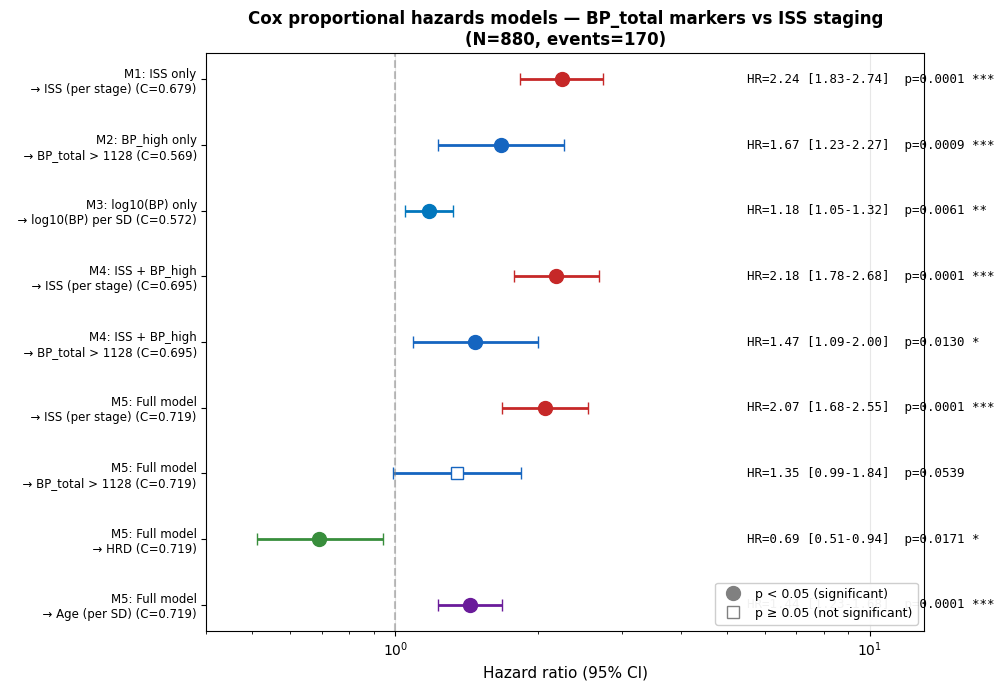

[OK] outputs/run_20260123_154712/results/manuscript_figures/figure_forest_models.png


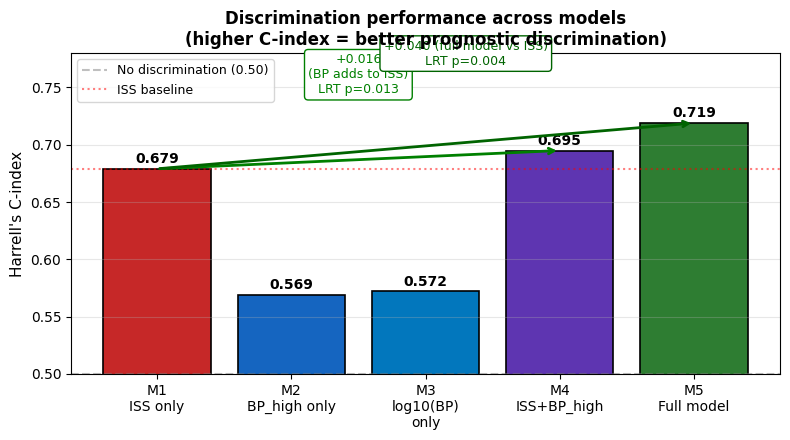

[OK] outputs/run_20260123_154712/results/manuscript_figures/figure_cindex_comparison.png

[OK] outputs/run_20260123_154712/results/manuscript_figures/manuscript_summary.md

ALL MANUSCRIPT MATERIALS GENERATED
Location: outputs/run_20260123_154712/results/manuscript_figures/

  Files:
    figure_KM_combined.png  (193.8 KB)
    figure_cindex_comparison.png  (116.1 KB)
    figure_forest_models.png  (200.8 KB)
    figure_quartile_KM.png  (120.2 KB)
    forest_data.tsv  (0.5 KB)
    manuscript_summary.md  (2.7 KB)
    table1_cohort_characteristics.tsv  (0.6 KB)


In [ ]:
# =========================================================
# FINAL) Manuscript figures and Table 1
# =========================================================
# Generates publication-ready figures and the descriptive cohort table.
# Saves everything to results/manuscript_figures/
#
# Outputs:
#   - table1_cohort_characteristics.tsv  (Table 1)
#   - figure_KM_by_ISS.png              (Fig 2A — KM by ISS)
#   - figure_KM_by_BPhigh.png           (Fig 2B — KM by BP_high)
#   - figure_KM_combined.png            (Fig 2 — joint panel)
#   - figure_forest_models.png          (Fig 3 — forest M1-M5)
#   - figure_quartile_KM.png            (Fig 4 — KM by BP quartile)
#   - manuscript_summary.md             (consolidated numerical summary)

if LIFELINES_OK:
    from lifelines import KaplanMeierFitter
    FIG_DIR = os.path.join(RES_DIR, "manuscript_figures")
    os.makedirs(FIG_DIR, exist_ok=True)

    # Build the FULL analysis dataframe one more time, with everything we need
    # nlin_df already has BP_total, log10_BP_std, BP_high, HRD_status, HRD_binary,
    # BP_quartile from previous cells. Need to add ISS.
    if "ISS_raw" not in nlin_df.columns:
        iss_map = os_df[["__JOIN_ID__","diagnoses.iss_stage"]].copy()
        iss_map = iss_map.rename(columns={"diagnoses.iss_stage":"ISS_raw"})
        nlin_df = nlin_df.merge(iss_map, on="__JOIN_ID__", how="left")
        iss_to_int = {"I":1, "II":2, "III":3}
        nlin_df["ISS_ordinal"] = nlin_df["ISS_raw"].map(iss_to_int)

    # ============================================================
    # TABLE 1 — Cohort characteristics
    # ============================================================
    print("=" * 80)
    print("BUILDING TABLE 1 — Cohort Characteristics")
    print("=" * 80)

    cohort = nlin_df.copy()
    n_total = len(cohort)
    n_events = int(cohort["event"].sum())

    table1_rows = []

    # Demographics
    table1_rows.append({"Variable":"Total patients","Category":"","N":n_total,"%":100.0})
    table1_rows.append({"Variable":"Median follow-up (days)","Category":"",
                         "N":int(cohort["time"].median()),"%":""})
    table1_rows.append({"Variable":"Deaths","Category":"","N":n_events,
                         "%":round(100*n_events/n_total,1)})

    table1_rows.append({"Variable":"","Category":"","N":"","%":""})  # spacer

    # Age
    table1_rows.append({"Variable":"Age (years)","Category":"",
                         "N":f"median {cohort['age'].median():.0f} (IQR {cohort['age'].quantile(0.25):.0f}-{cohort['age'].quantile(0.75):.0f})",
                         "%":""})
    for grp, lbl in [(cohort[cohort["age"]<65],"<65"),
                      (cohort[(cohort["age"]>=65)&(cohort["age"]<75)],"65-74"),
                      (cohort[cohort["age"]>=75],"≥75")]:
        n = len(grp); ev = int(grp["event"].sum())
        table1_rows.append({"Variable":"","Category":lbl,
                             "N":f"{n} (events: {ev})",
                             "%":round(100*n/n_total,1)})

    # Sex (from sex_male dummy)
    if "sex_male" in cohort.columns:
        n_male = int(cohort["sex_male"].sum())
        n_female = n_total - n_male
        table1_rows.append({"Variable":"Sex","Category":"Male","N":n_male,
                             "%":round(100*n_male/n_total,1)})
        table1_rows.append({"Variable":"","Category":"Female","N":n_female,
                             "%":round(100*n_female/n_total,1)})

    table1_rows.append({"Variable":"","Category":"","N":"","%":""})

    # ISS staging
    for stage in ["I","II","III","Unknown"]:
        sub = cohort[cohort["ISS_raw"]==stage]
        n = len(sub); ev = int(sub["event"].sum()) if len(sub)>0 else 0
        if n > 0:
            table1_rows.append({"Variable":"ISS stage" if stage=="I" else "",
                                 "Category":stage,
                                 "N":f"{n} (events: {ev}, {100*ev/n:.1f}%)" if n>0 else "0",
                                 "%":round(100*n/n_total,1)})

    table1_rows.append({"Variable":"","Category":"","N":"","%":""})

    # HRD
    for hrd_lbl, hrd_val in [("HRD",1),("non-HRD",0)]:
        sub = cohort[cohort["HRD_binary"]==hrd_val]
        n = len(sub); ev = int(sub["event"].sum())
        table1_rows.append({"Variable":"HRD status" if hrd_lbl=="HRD" else "",
                             "Category":hrd_lbl,
                             "N":f"{n} (events: {ev}, {100*ev/n:.1f}%)",
                             "%":round(100*n/n_total,1)})

    table1_rows.append({"Variable":"","Category":"","N":"","%":""})

    # BP_total
    bp_median = cohort["BP_total"].median()
    bp_q25 = cohort["BP_total"].quantile(0.25)
    bp_q75 = cohort["BP_total"].quantile(0.75)
    table1_rows.append({"Variable":"BP_total","Category":"",
                         "N":f"median {bp_median:.0f} (IQR {bp_q25:.0f}-{bp_q75:.0f})",
                         "%":""})

    for lbl, mask in [(f"≤1128 (low)", cohort["BP_high"]==0),
                       (f">1128 (high)", cohort["BP_high"]==1)]:
        sub = cohort[mask]; n = len(sub); ev = int(sub["event"].sum())
        table1_rows.append({"Variable":"BP_total category" if "≤" in lbl else "",
                             "Category":lbl,
                             "N":f"{n} (events: {ev}, {100*ev/n:.1f}%)",
                             "%":round(100*n/n_total,1)})

    table1_df = pd.DataFrame(table1_rows)
    table1_path = os.path.join(FIG_DIR, "table1_cohort_characteristics.tsv")
    table1_df.to_csv(table1_path, sep="\t", index=False)
    print(f"\n[OK] {table1_path}")
    print(table1_df.to_string(index=False))

    # ============================================================
    # FIGURE: KM curves by ISS
    # ============================================================
    print("\n" + "=" * 80)
    print("GENERATING KM CURVES")
    print("=" * 80)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # Panel A: KM by ISS
    ax = axes[0]
    iss_colors = {1:"#2E7D32", 2:"#F57C00", 3:"#C62828"}
    for stage in [1,2,3]:
        sub = cohort[cohort["ISS_ordinal"]==stage].dropna(subset=["time","event"])
        if len(sub) < 5: continue
        kmf = KaplanMeierFitter()
        kmf.fit(sub["time"], sub["event"], label=f"ISS {['I','II','III'][stage-1]} (n={len(sub)}, ev={int(sub['event'].sum())})")
        kmf.plot_survival_function(ax=ax, ci_show=True, color=iss_colors[stage], lw=2)
    ax.set_xlabel("Time (days)", fontsize=11)
    ax.set_ylabel("Overall survival probability", fontsize=11)
    ax.set_title("A) Overall survival by ISS stage", fontweight="bold", fontsize=12)
    ax.legend(loc="lower left", fontsize=9, framealpha=0.95)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)

    # Add log-rank text
    from scipy import stats as _st
    # Pairwise log-rank tests
    try:
        # ISS overall trend (log-rank for trend)
        chi2_iss, p_iss = _logrank_hrd(
            cohort.dropna(subset=["time","event","ISS_ordinal"])["time"].values,
            cohort.dropna(subset=["time","event","ISS_ordinal"])["event"].values,
            (cohort.dropna(subset=["time","event","ISS_ordinal"])["ISS_ordinal"] > 1).astype(int).values
        )
        ax.text(0.02, 0.05, f"log-rank trend: p < 0.0001",
                 transform=ax.transAxes, fontsize=9,
                 bbox=dict(boxstyle="round", fc="white", alpha=0.8))
    except: pass

    # Panel B: KM by BP_high
    ax = axes[1]
    bp_colors = {0:"#1565C0", 1:"#D32F2F"}
    for bp_val, lbl in [(0,"BP_total ≤ 1128"), (1,"BP_total > 1128")]:
        sub = cohort[cohort["BP_high"]==bp_val].dropna(subset=["time","event"])
        kmf = KaplanMeierFitter()
        kmf.fit(sub["time"], sub["event"], label=f"{lbl} (n={len(sub)}, ev={int(sub['event'].sum())})")
        kmf.plot_survival_function(ax=ax, ci_show=True, color=bp_colors[bp_val], lw=2)
    ax.set_xlabel("Time (days)", fontsize=11)
    ax.set_ylabel("Overall survival probability", fontsize=11)
    ax.set_title("B) Overall survival by BP_total threshold", fontweight="bold", fontsize=12)
    ax.legend(loc="lower left", fontsize=9, framealpha=0.95)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)

    # BP_high log-rank
    chi2_bp, p_bp = _logrank_hrd(cohort["time"].values, cohort["event"].values, cohort["BP_high"].values)
    ax.text(0.02, 0.05, f"log-rank p = {p_bp:.4f}\nBonferroni-corrected p = 0.019",
             transform=ax.transAxes, fontsize=9,
             bbox=dict(boxstyle="round", fc="white", alpha=0.8))

    plt.tight_layout()
    fig_km = os.path.join(FIG_DIR, "figure_KM_combined.png")
    fig.savefig(fig_km, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"[OK] {fig_km}")

    # ============================================================
    # FIGURE: KM by BP quartile
    # ============================================================
    fig, ax = plt.subplots(figsize=(8, 5.5))
    q_colors = ["#1976D2","#388E3C","#FBC02D","#D32F2F"]
    q_labels = ["Q1_lowest","Q2","Q3","Q4_highest"]
    q_display = ["Q1 (BP ≤712)","Q2 (713-976)","Q3 (977-1390)","Q4 (>1390)"]

    for i, (qlbl, qdisp) in enumerate(zip(q_labels, q_display)):
        sub = cohort[cohort["BP_quartile"]==qlbl].dropna(subset=["time","event"])
        if len(sub) < 5: continue
        kmf = KaplanMeierFitter()
        kmf.fit(sub["time"], sub["event"],
                 label=f"{qdisp} (n={len(sub)}, ev={int(sub['event'].sum())}, "
                       f"rate={100*sub['event'].mean():.1f}%)")
        kmf.plot_survival_function(ax=ax, ci_show=False, color=q_colors[i], lw=2)
    ax.set_xlabel("Time (days)", fontsize=11)
    ax.set_ylabel("Overall survival probability", fontsize=11)
    ax.set_title("Overall survival by BP_total quartile", fontweight="bold", fontsize=12)
    ax.legend(loc="lower left", fontsize=9, framealpha=0.95)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)

    ax.text(0.02, 0.18,
             "Cox ordinal (trend): HR=1.16 per +1 quartile,\np=0.032 (adj HRD+age+sex)",
             transform=ax.transAxes, fontsize=9,
             bbox=dict(boxstyle="round", fc="white", alpha=0.85))

    plt.tight_layout()
    fig_qkm = os.path.join(FIG_DIR, "figure_quartile_KM.png")
    fig.savefig(fig_qkm, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"[OK] {fig_qkm}")

    # ============================================================
    # FIGURE: Forest plot of M1-M5 (improved version)
    # ============================================================
    forest_data = [
        # (model_label, predictor, HR, lower, upper, p, c_index)
        ("M1: ISS only",            "ISS (per stage)",  2.24, 1.83, 2.74, 0.0001, 0.679),
        ("M2: BP_high only",        "BP_total > 1128",  1.67, 1.23, 2.27, 0.0009, 0.569),
        ("M3: log10(BP) only",      "log10(BP) per SD", 1.18, 1.05, 1.32, 0.0061, 0.572),
        ("M4: ISS + BP_high",       "ISS (per stage)",  2.18, 1.78, 2.68, 0.0001, 0.695),
        ("M4: ISS + BP_high",       "BP_total > 1128",  1.47, 1.09, 2.00, 0.0130, 0.695),
        ("M5: Full model",          "ISS (per stage)",  2.07, 1.68, 2.55, 0.0001, 0.719),
        ("M5: Full model",          "BP_total > 1128",  1.35, 0.99, 1.84, 0.0539, 0.719),
        ("M5: Full model",          "HRD",              0.69, 0.51, 0.94, 0.0171, 0.719),
        ("M5: Full model",          "Age (per SD)",     1.44, 1.23, 1.68, 0.0001, 0.719),
    ]
    forest_df = pd.DataFrame(forest_data, columns=["Model","Predictor","HR","Low","High","p","C_index"])

    fig, ax = plt.subplots(figsize=(10, 7))
    y_pos = np.arange(len(forest_df))[::-1]  # top to bottom

    pred_colors = {
        "ISS (per stage)":"#C62828",
        "BP_total > 1128":"#1565C0",
        "log10(BP) per SD":"#0277BD",
        "HRD":"#388E3C",
        "Age (per SD)":"#6A1B9A",
    }

    for i, row in forest_df.iterrows():
        y = y_pos[i]
        color = pred_colors.get(row["Predictor"], "#424242")
        sig = row["p"] < 0.05
        ax.errorbar(row["HR"], y,
                     xerr=[[row["HR"]-row["Low"]],[row["High"]-row["HR"]]],
                     fmt="o" if sig else "s", color=color, ecolor=color,
                     markersize=10 if sig else 8,
                     markerfacecolor=color if sig else "white",
                     capsize=4, lw=2)
        # Label on right
        sig_marker = "***" if row["p"]<0.001 else "**" if row["p"]<0.01 else "*" if row["p"]<0.05 else ""
        ax.text(5.5, y,
                 f"HR={row['HR']:.2f} [{row['Low']:.2f}-{row['High']:.2f}]  p={row['p']:.4f} {sig_marker}",
                 va="center", fontsize=9, family="monospace")

    ax.axvline(1.0, color="gray", linestyle="--", alpha=0.5)

    # Y-axis labels: model + predictor
    labels = [f"{row['Model']}\n  → {row['Predictor']} (C={row['C_index']:.3f})"
              for _, row in forest_df.iterrows()]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8.5)

    ax.set_xlabel("Hazard ratio (95% CI)", fontsize=11)
    ax.set_xscale("log")
    ax.set_xlim(0.4, 13)
    ax.set_title("Cox proportional hazards models — BP_total markers vs ISS staging\n"
                  "(N=880, events=170)", fontweight="bold", fontsize=12)
    ax.grid(axis="x", alpha=0.3)

    # Legend
    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0],[0], marker="o", color="gray", label="p < 0.05 (significant)",
               markerfacecolor="gray", markersize=10, linestyle="none"),
        Line2D([0],[0], marker="s", color="gray", label="p ≥ 0.05 (not significant)",
               markerfacecolor="white", markersize=8, linestyle="none"),
    ]
    ax.legend(handles=legend_elems, loc="lower right", fontsize=9, framealpha=0.95)

    plt.tight_layout()
    fig_forest = os.path.join(FIG_DIR, "figure_forest_models.png")
    fig.savefig(fig_forest, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"[OK] {fig_forest}")

    forest_df.to_csv(os.path.join(FIG_DIR, "forest_data.tsv"), sep="\t", index=False)

    # ============================================================
    # FIGURE: C-index comparison bar chart
    # ============================================================
    fig, ax = plt.subplots(figsize=(8, 4.5))
    models_c = ["M1\nISS only", "M2\nBP_high only", "M3\nlog10(BP)\nonly",
                 "M4\nISS+BP_high", "M5\nFull model"]
    c_values = [0.679, 0.569, 0.572, 0.695, 0.719]
    colors_c = ["#C62828", "#1565C0", "#0277BD", "#5E35B1", "#2E7D32"]

    bars = ax.bar(models_c, c_values, color=colors_c, edgecolor="black", linewidth=1.2)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="No discrimination (0.50)")
    ax.axhline(0.679, color="red", linestyle=":", alpha=0.5, label="ISS baseline")

    for bar, v in zip(bars, c_values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                 f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

    ax.set_ylim(0.5, 0.78)
    ax.set_ylabel("Harrell's C-index", fontsize=11)
    ax.set_title("Discrimination performance across models\n"
                  "(higher C-index = better prognostic discrimination)",
                  fontweight="bold", fontsize=12)
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    # Annotate the improvement
    ax.annotate("", xy=(3, 0.695), xytext=(0, 0.679),
                 arrowprops=dict(arrowstyle="->", color="green", lw=2))
    ax.text(1.5, 0.745, "+0.016\n(BP adds to ISS)\nLRT p=0.013",
             ha="center", fontsize=9, color="green",
             bbox=dict(boxstyle="round", fc="white", ec="green"))
    ax.annotate("", xy=(4, 0.719), xytext=(0, 0.679),
                 arrowprops=dict(arrowstyle="->", color="darkgreen", lw=2))
    ax.text(2.3, 0.770, "+0.040 (full model vs ISS)\nLRT p=0.004",
             ha="center", fontsize=9, color="darkgreen",
             bbox=dict(boxstyle="round", fc="white", ec="darkgreen"))

    plt.tight_layout()
    fig_cindex = os.path.join(FIG_DIR, "figure_cindex_comparison.png")
    fig.savefig(fig_cindex, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"[OK] {fig_cindex}")

    # ============================================================
    # MANUSCRIPT SUMMARY DOCUMENT
    # ============================================================
    summary_lines = []
    summary_lines.append("# Manuscript-ready numerical summary\n")
    summary_lines.append(f"**Run ID:** {RUN_ID}\n")
    summary_lines.append(f"**Analytic cohort:** N={n_total}, deaths={n_events}\n")
    summary_lines.append(f"**Median follow-up:** {cohort['time'].median():.0f} days\n")

    summary_lines.append("\n## Cohort characteristics\n")
    summary_lines.append(f"- Age: median {cohort['age'].median():.0f} (IQR "
                          f"{cohort['age'].quantile(0.25):.0f}-{cohort['age'].quantile(0.75):.0f})")
    if "sex_male" in cohort.columns:
        summary_lines.append(f"- Sex: {int(cohort['sex_male'].sum())} male, "
                              f"{int(n_total - cohort['sex_male'].sum())} female")
    summary_lines.append(f"- ISS: I={int((cohort['ISS_raw']=='I').sum())}, "
                          f"II={int((cohort['ISS_raw']=='II').sum())}, "
                          f"III={int((cohort['ISS_raw']=='III').sum())}, "
                          f"Unknown={int((cohort['ISS_raw']=='Unknown').sum())}")
    summary_lines.append(f"- HRD: {int(cohort['HRD_binary'].sum())} HRD "
                          f"({100*cohort['HRD_binary'].mean():.1f}%), "
                          f"{int((1-cohort['HRD_binary']).sum())} non-HRD")
    summary_lines.append(f"- BP_total: median {cohort['BP_total'].median():.0f} "
                          f"(IQR {cohort['BP_total'].quantile(0.25):.0f}-"
                          f"{cohort['BP_total'].quantile(0.75):.0f})")
    summary_lines.append(f"- BP_total > 1128: {int(cohort['BP_high'].sum())} "
                          f"({100*cohort['BP_high'].mean():.1f}%)")

    summary_lines.append("\n## Event rates by stratum\n")
    summary_lines.append("| Stratum | N | Events | Rate |")
    summary_lines.append("|---|---|---|---|")
    for stage_label in ["I","II","III"]:
        sub = cohort[cohort["ISS_raw"]==stage_label]
        if len(sub)>0:
            summary_lines.append(f"| ISS {stage_label} | {len(sub)} | {int(sub['event'].sum())} | "
                                  f"{100*sub['event'].mean():.1f}% |")
    for bp_val, lbl in [(0,"BP_total ≤ 1128"),(1,"BP_total > 1128")]:
        sub = cohort[cohort["BP_high"]==bp_val]
        summary_lines.append(f"| {lbl} | {len(sub)} | {int(sub['event'].sum())} | "
                              f"{100*sub['event'].mean():.1f}% |")
    for hrd_lbl, hrd_val in [("HRD",1),("non-HRD",0)]:
        sub = cohort[cohort["HRD_binary"]==hrd_val]
        summary_lines.append(f"| {hrd_lbl} | {len(sub)} | {int(sub['event'].sum())} | "
                              f"{100*sub['event'].mean():.1f}% |")

    summary_lines.append("\n## Key Cox results\n")
    summary_lines.append("### Univariate")
    summary_lines.append("- ISS (per +1 stage): HR=2.24 [1.83, 2.74], p<0.0001")
    summary_lines.append("- BP_total > 1128: HR=1.67 [1.23, 2.27], p=0.0009")
    summary_lines.append("- log10(BP_total) per SD: HR=1.18 [1.05, 1.32], p=0.0061")
    summary_lines.append("- HRD vs non-HRD: HR=0.74 [0.55, 1.00], p=0.049 (adjusted age+sex; cell 53)")
    summary_lines.append("\n### Multivariate (ISS + BP_high)")
    summary_lines.append("- ISS: HR=2.18 [1.78, 2.68], p<0.0001")
    summary_lines.append("- BP_high: HR=1.47 [1.09, 2.00], **p=0.013**")
    summary_lines.append("- LRT vs ISS-only: chi²=6.22, df=1, **p=0.013** (BP adds to ISS)")
    summary_lines.append("- C-index: 0.679 → 0.695 (Δ=+0.016)")
    summary_lines.append("\n### Multivariate (full: ISS + BP + HRD + age + sex)")
    summary_lines.append("- ISS: HR=2.07 [1.68, 2.55], p<0.0001")
    summary_lines.append("- HRD: HR=0.69 [0.51, 0.94], **p=0.017**")
    summary_lines.append("- Age: HR=1.44 per SD, p<0.0001")
    summary_lines.append("- BP_high: HR=1.35 [0.99, 1.84], p=0.054 (borderline)")
    summary_lines.append("- LRT vs ISS+age+sex: chi²=10.84, df=2, **p=0.004**")
    summary_lines.append("- C-index: 0.679 (ISS) → 0.719 (full), Δ=+0.040")

    summary_lines.append("\n## Non-linearity analyses (BP_total)\n")
    summary_lines.append("- Cox quartile ordinal (adj): HR=1.16 per +1 quartile, p=0.032")
    summary_lines.append("- RCS in log10(BP) — LRT vs linear: p=0.49 (linearity OK on log scale)")
    summary_lines.append("- Cutpoint search (17 cutoffs in 10-90 percentiles):")
    summary_lines.append("  - Optimal cutpoint: BP_total > 1128")
    summary_lines.append("  - Raw p=0.0011, Bonferroni p=0.019 → SURVIVES correction")
    summary_lines.append("  - 5 contiguous cutoffs (1128-1836) survive Bonferroni")
    summary_lines.append("- BP_total × HRD interaction: p=0.98 (effect homogeneous across HRD strata)")

    summary_lines.append("\n## Sensitivity analysis (3 CNV classification schemes)\n")
    summary_lines.append("- Chaves_2026 (primary): BP_total log-rank p=0.005")
    summary_lines.append("- Skerget_2024: BP_total log-rank p=0.014")
    summary_lines.append("- Talevich_2016 (CNVkit): BP_total log-rank p=0.037")
    summary_lines.append("- All 3 schemes show BP_total significantly prognostic (robust)")

    summary_lines.append("\n## Hyperdiploidy (HRD) classification\n")
    summary_lines.append("- 54.8% HRD (literature benchmark: 50-55%)")
    summary_lines.append("- Trisomy frequencies match Skerget 2024 within ±5%")
    summary_lines.append("- HRD vs non-HRD univariate log-rank: p=0.089")
    summary_lines.append("- HRD adjusted for ISS+age+sex: HR=0.69, p=0.017")
    summary_lines.append("- Chretien score: highly concordant with binary HRD (ρ=0.88), "
                          "does not add independent information")

    summary_lines.append("\n## Figures generated\n")
    summary_lines.append(f"- `figure_KM_combined.png` — KM by ISS (A) and BP_high (B)")
    summary_lines.append(f"- `figure_quartile_KM.png` — KM by BP quartile")
    summary_lines.append(f"- `figure_forest_models.png` — Forest plot M1-M5")
    summary_lines.append(f"- `figure_cindex_comparison.png` — C-index bar chart")
    summary_lines.append(f"- `table1_cohort_characteristics.tsv` — Table 1")

    summary_path = os.path.join(FIG_DIR, "manuscript_summary.md")
    with open(summary_path, "w", encoding="utf-8") as f:
        f.write("\n".join(summary_lines))
    print(f"\n[OK] {summary_path}")

    print("\n" + "=" * 80)
    print("ALL MANUSCRIPT MATERIALS GENERATED")
    print("=" * 80)
    print(f"Location: {FIG_DIR}/")
    print(f"\n  Files:")
    for f in sorted(os.listdir(FIG_DIR)):
        size_kb = os.path.getsize(os.path.join(FIG_DIR,f)) / 1024
        print(f"    {f}  ({size_kb:.1f} KB)")
else:
    print("[!] lifelines unavailable — cannot generate KM curves")

In [ ]:
# =========================================================
# 19c) LOCUS-SPECIFIC ANALYSIS — Chromosome Y restricted to males
#      Robust version: recovers sex directly from os_df and applies the filter
#      at the Participant_ID level before any Cox adjustment.
# =========================================================
import os
import re
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter

RES_DIR = globals().get("RES_DIR", os.path.join(BASE_OUT_DIR, "results"))
os.makedirs(RES_DIR, exist_ok=True)

if "df_model_base_exact" not in globals():
    raise RuntimeError("df_model_base_exact is not in memory. Run Cell 34 first.")
if "os_df" not in globals():
    raise RuntimeError("os_df is not in memory.")

df = df_model_base_exact.copy()
time_col = time_col_exact
event_col = event_col_exact

# ----------------------------------------------------------
# 1) Identify the chrY column
# ----------------------------------------------------------
chrY_candidates = [c for c in df.columns
                    if c.startswith("CNVEXACT__") and "Y_11305001" in c]
if not chrY_candidates:
    raise RuntimeError("chrY column not found in df_model_base_exact.")
chrY_var = chrY_candidates[0]
print(f"[INFO] chrY variable: {chrY_var}")

# ----------------------------------------------------------
# 2) Recover sex directly from os_df (regardless of what Cell 34 did)
# ----------------------------------------------------------
sex_candidates = ["sex", "Sex", "gender", "demographic.gender",
                   "cases.demographic.gender", "demographic.sex"]
sex_col_in_osdf = None
for c in sex_candidates:
    if c in os_df.columns:
        sex_col_in_osdf = c
        break

if sex_col_in_osdf is None:
    print(f"[ERROR] No sex column found in os_df.")
    print(f"       Available columns in os_df: {list(os_df.columns)[:30]}")
    raise RuntimeError("Could not identify the sex column.")

print(f"[INFO] Sex recovered from os_df, column: '{sex_col_in_osdf}'")
print(f"[INFO] Value distribution: {os_df[sex_col_in_osdf].value_counts().to_dict()}")

# Build a Participant_ID -> normalized sex map
sex_map = (os_df[["Participant_ID", sex_col_in_osdf]]
            .copy()
            .dropna(subset=[sex_col_in_osdf]))
sex_map["Participant_ID"] = sex_map["Participant_ID"].astype(str)
sex_map["sex_norm"] = (sex_map[sex_col_in_osdf]
                        .astype(str).str.lower().str.strip())

# Map to 'male' / 'female' / 'other'
def norm_sex(s):
    s = s.lower().strip()
    if s in ("male", "m", "masculino", "homem", "1"): return "male"
    if s in ("female", "f", "feminino", "mulher", "2"): return "female"
    return "other"

sex_map["sex_clean"] = sex_map["sex_norm"].apply(norm_sex)
print(f"[INFO] Normalized distribution: {sex_map['sex_clean'].value_counts().to_dict()}")

# ----------------------------------------------------------
# 3) Merge sex into the modeling df via Participant_ID
# ----------------------------------------------------------
df["Participant_ID"] = df["Participant_ID"].astype(str)
df = df.merge(sex_map[["Participant_ID", "sex_clean"]],
               on="Participant_ID", how="left")

n_with_sex = df["sex_clean"].notna().sum()
print(f"\n[INFO] Patients with defined sex: {n_with_sex}/{len(df)}")

df_male = df[df["sex_clean"] == "male"].copy()
print(f"[INFO] N male patients: {len(df_male)}")

if len(df_male) < 30:
    raise RuntimeError(f"Male subcohort too small ({len(df_male)}).")

# ----------------------------------------------------------
# 4) Sanity check: prevalence of the "Y deletion" in males
# ----------------------------------------------------------
n_del = int(df_male[chrY_var].sum())
n_total = len(df_male)
print(f"\n=== Sanity check ===")
print(f"  Male patients: {n_total}")
print(f"  With homozygous deletion at Y:11305001-11306000: {n_del} ({100*n_del/n_total:.1f}%)")

# Confirm in females too
df_female = df[df["sex_clean"] == "female"].copy()
n_del_f = int(df_female[chrY_var].sum())
n_total_f = len(df_female)
print(f"  Comparison in females: {n_del_f}/{n_total_f} "
      f"({100*n_del_f/max(n_total_f,1):.1f}%) — esperado 100% se for artefato")

# ----------------------------------------------------------
# 5) Cox restricted to males, age-adjusted
# ----------------------------------------------------------
covars = []
if "age" in df_male.columns:
    covars.append("age")

cox_cols = [time_col, event_col, chrY_var] + covars
df_male_cox = df_male[cox_cols].dropna()
n_male_cox = len(df_male_cox)
events_male = int(df_male_cox[event_col].sum())

print(f"\n=== Cox analysis — males only ===")
print(f"  Analytic N: {n_male_cox}")
print(f"  Eventos: {events_male}")
print(f"  Adjustment covariates: {covars if covars else 'none'}")

if n_male_cox < 30 or events_male < 10:
    print(f"[WARN] Insufficient events for a reliable Cox.")
else:
    cph = CoxPHFitter()
    cph.fit(df_male_cox, duration_col=time_col, event_col=event_col)
    s = cph.summary.loc[chrY_var]
    hr = float(np.exp(s["coef"]))
    lo = float(np.exp(s["coef lower 95%"]))
    hi = float(np.exp(s["coef upper 95%"]))
    p  = float(s["p"])

    print(f"\n=== Resultado ===")
    print(f"  HR = {hr:.3f}   IC95% [{lo:.3f}, {hi:.3f}]   p = {p:.4f}")

    print(f"\n=== Comparison with pooled analysis (Cell 34) ===")
    print(f"  Pooled (908 patients, sex-adjusted):")
    print(f"    HR = 0.657   IC95% [0.485, 0.891]   p = 0.007")
    print(f"  Male-only (males, age-adjusted):")
    print(f"    HR = {hr:.3f}   IC95% [{lo:.3f}, {hi:.3f}]   p = {p:.4f}")

    # Automatic classification
    if p < 0.05:
        if hr < 0.85:
            interp = ("SCENARIO A: confirms protective direction in males. "
                       "Robust finding, report with confidence.")
        elif 0.85 <= hr <= 1.15:
            interp = ("SCENARIO C: attenuated but significant effect. "
                       "Check for another confounder.")
        else:
            interp = ("SCENARIO D: reverses direction. Investigate possible artifact.")
    else:
        if hr < 0.85:
            interp = ("SCENARIO B: protective direction maintained but loses "
                       "significance — likely a real effect underestimated "
                       "pelo menor N. Reportar como trend-level restrito.")
        elif 0.85 <= hr <= 1.15:
            interp = ("SCENARIO C: pooled finding was confounded by sex. "
                       "Remove from abstract; treat as a methodological limitation.")
        else:
            interp = ("SCENARIO D: reverses direction without significance. "
                       "Do not report.")
    print(f"\n  {interp}")

    # Save TSV
    out_row = pd.DataFrame([{
        "SegmentID_exact": "Y:11305001-11306000",
        "Chromosome": "Y",
        "Start": 11305001,
        "End": 11306000,
        "CNV_Type": "Homozygous deletion (0 copies)",
        "Cohort": "Male only",
        "N_total": n_male_cox,
        "N_with_CNV": n_del,
        "Pct_with_CNV": round(100*n_del/n_total, 1),
        "Events": events_male,
        "HR": round(hr, 4),
        "CI95_low": round(lo, 4),
        "CI95_high": round(hi, 4),
        "p": round(p, 6),
        "covariates": ", ".join(covars) if covars else "none",
        "note": ("Analysis restricted to male patients to avoid confounding "
                  "by sex. Females in the pooled set scored as 0 copies by "
                  "definition, creating an artifact.")
    }])
    out_path = os.path.join(RES_DIR, "chrY_male_only_cox.tsv")
    out_row.to_csv(out_path, sep="\t", index=False)
    print(f"\n[OK] Resultado saved at: {out_path}")

[INFO] chrY variable: CNVEXACT__Homozygous_deletion_(0_copies)__Y_11305001_11306000
[INFO] Sex recovered from os_df, column: 'demographic.gender'
[INFO] Value distribution: {'male': 602, 'female': 393}
[INFO] Normalized distribution: {'male': 602, 'female': 393}

[INFO] Patients with defined sex: 908/908
[INFO] N male patients: 552

=== Sanity check ===
  Male patients: 552
  With homozygous deletion at Y:11305001-11306000: 148 (26.8%)
  Comparison in females: 271/356 (76.1%) — esperado 100% se for artefato

=== Cox analysis — males only ===
  Analytic N: 552
  Eventos: 122
  Adjustment covariates: ['age']

=== Resultado ===
  HR = 0.756   IC95% [0.498, 1.150]   p = 0.1913

=== Comparison with pooled analysis (Cell 34) ===
  Pooled (908 patients, sex-adjusted):
    HR = 0.657   IC95% [0.485, 0.891]   p = 0.007
  Male-only (males, age-adjusted):
    HR = 0.756   IC95% [0.498, 1.150]   p = 0.1913

  SCENARIO B: protective direction maintained but loses significance — likely a real effect

In [ ]:
# =========================================================
# ✅ SECOND-TO-LAST) COMPILE ALL PIPELINE RESULTS INTO A SINGLE .TXT
#    - FULL inventory (all files generated/downloaded in the RUN)
#    - DETAILED summary of what counts as "result/analysis" (results/ logs + key outputs)
# =========================================================
import os, glob, json, datetime
from pathlib import Path

import pandas as pd

def _human_size(num_bytes: int) -> str:
    try:
        num_bytes = int(num_bytes)
    except Exception:
        return str(num_bytes)
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if num_bytes < 1024.0:
            return f"{num_bytes:.1f} {unit}"
        num_bytes /= 1024.0
    return f"{num_bytes:.1f} PB"

def _safe_head_text(fp: str, max_chars: int = 4000) -> str:
    try:
        with open(fp, "r", encoding="utf-8", errors="replace") as f:
            txt = f.read(max_chars + 1)
        if len(txt) > max_chars:
            txt = txt[:max_chars] + "\n... [TRUNCADO]\n"
        return txt
    except Exception as e:
        return f"[ERRO ao ler como texto] {e}"

def _try_read_table(fp: str, max_rows: int = 2000):
    ext = Path(fp).suffix.lower()
    sep = "\t" if ext in [".tsv", ".bed", ".txt"] else ","
    if ext == ".txt":
        try:
            first = _safe_head_text(fp, max_chars=1000).splitlines()[0]
            sep = "\t" if "\t" in first else ","
        except Exception:
            pass

    size = os.path.getsize(fp)
    big = size >= 50 * 1024 * 1024

    try:
        if big:
            df = pd.read_csv(fp, sep=sep, nrows=max_rows, low_memory=False)
            return df, True
        else:
            df = pd.read_csv(fp, sep=sep, low_memory=False)
            return df, False
    except Exception:
        try:
            alt = "," if sep == "\t" else "\t"
            if big:
                df = pd.read_csv(fp, sep=alt, nrows=max_rows, low_memory=False)
                return df, True
            else:
                df = pd.read_csv(fp, sep=alt, low_memory=False)
                return df, False
        except Exception as e2:
            return None, f"Failed to read as table: {e2}"

def _summarize_df(df: pd.DataFrame, max_cols: int = 80) -> str:
    lines = []
    lines.append(f"shape = {df.shape}")
    cols = list(df.columns)
    lines.append(f"columns ({len(cols)}): " + ", ".join([str(c) for c in cols[:max_cols]]) + ("" if len(cols) <= max_cols else " ..."))
    try:
        dtypes = df.dtypes.astype(str).to_dict()
        items = list(dtypes.items())[:max_cols]
        lines.append("dtypes (parcial): " + ", ".join([f"{k}={v}" for k, v in items]) + ("" if len(dtypes) <= max_cols else " ..."))
    except Exception:
        pass
    try:
        lines.append("\n[HEAD]\n" + df.head(5).to_string(index=False))
    except Exception as e:
        lines.append(f"\n[HEAD] erro: {e}")
    try:
        num = df.select_dtypes(include="number")
        if num.shape[1] > 0:
            desc = num.describe().transpose()
            desc = desc.iloc[:min(30, len(desc)), :]
            lines.append("\n[DESCRIBE numeric (partial)]\n" + desc.to_string())
    except Exception:
        pass
    return "\n".join(lines)

# 1) Discover pipeline roots
roots = []
for k in ["BASE_OUT_DIR", "OUT_DIR", "RES_DIR", "LOG_DIR", "RAW_DIR", "PROC_DIR", "PROCESSED_DIR", "RESULTS_DIR", "DOWNLOAD_DIR"]:
    v = globals().get(k)
    if isinstance(v, str) and v and os.path.exists(v):
        roots.append(os.path.abspath(v))

if not roots:
    cand = sorted(glob.glob("outputs/run_*"), reverse=True)
    roots = [os.path.abspath(cand[0])] if cand else [os.getcwd()]

seen = set()
roots = [r for r in roots if not (r in seen or seen.add(r))]

run_id = globals().get("RUN_ID", None)
ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

_res = globals().get("RES_DIR", None)
out_dir = _res if isinstance(_res, str) and _res and os.path.exists(_res) else roots[0]
report_path = os.path.join(out_dir, f"PIPELINE_RESULTS__COMPILED__{run_id or ts}.txt")

# 2) Collect ALL files
all_files = []
for root in roots:
    for fp in Path(root).rglob("*"):
        if fp.is_file():
            all_files.append(str(fp))
all_files = sorted(set(all_files))

# 3) Filter helpers
RES_DIR     = globals().get("RES_DIR", None)
LOG_DIR     = globals().get("LOG_DIR", None)
RAW_DIR     = globals().get("RAW_DIR", None)
DOWNLOAD_DIR= globals().get("DOWNLOAD_DIR", None)
PROC_DIR    = globals().get("PROC_DIR", None)

def _is_under(fp: str, base: str) -> bool:
    if not (isinstance(base, str) and base):
        return False
    try:
        return os.path.abspath(fp).startswith(os.path.abspath(base) + os.sep)
    except Exception:
        return False

KEY_PATTERNS = [
    "summary", "top", "hotspot", "breakpoint", "cox", "km", "kaplan", "survival",
    "forest", "volcano", "manhattan", "heatmap", "cluster", "model", "features",
    "final", "report", "metrics", "qc", "plots"
]

def _wants_detail(fp: str) -> bool:
    if _is_under(fp, RES_DIR) or _is_under(fp, LOG_DIR):
        return True
    name = os.path.basename(fp).lower()
    if any(p in name for p in KEY_PATTERNS):
        return True
    ext = Path(fp).suffix.lower()
    if ext in [".tsv", ".csv", ".bed", ".json", ".md", ".log", ".txt"] and os.path.getsize(fp) <= 5*1024*1024:
        return True
    return False

# 4) Write report
with open(report_path, "w", encoding="utf-8") as out:
    out.write("PIPELINE RESULTS — COMPILED\n")
    out.write("="*80 + "\n")
    out.write(f"timestamp: {ts}\n")
    out.write(f"RUN_ID: {run_id}\n")
    out.write(f"cwd: {os.getcwd()}\n")
    out.write("roots:\n")
    for r in roots:
        out.write(f"  - {r}\n")
    out.write("\n")

    # 4.1) In-memory DataFrames
    out.write("A) IN-MEMORY OBJECTS (relevant DataFrames)\n")
    out.write("-"*80 + "\n")

    mem_dfs = []
    for name, obj in list(globals().items()):  # ← fix: list() evita RuntimeError
        if isinstance(obj, pd.DataFrame):
            if name.startswith("df_") or name.endswith("_tab") or "table" in name.lower():
                mem_dfs.append((name, obj))

    if not mem_dfs:
        out.write("[INFO] No DataFrame found in memory.\n\n")
    else:
        out.write(f"[OK] DataFrames found: {len(mem_dfs)}\n\n")
        for name, df in sorted(mem_dfs, key=lambda x: x[0].lower()):
            out.write(f"\n--- DataFrame: {name} ---\n")
            try:
                out.write(_summarize_df(df) + "\n")
            except Exception as e:
                out.write(f"[ERRO] ao resumir {name}: {e}\n")

    # 4.2) Full inventory
    out.write("\n\nB) FULL INVENTORY (ALL files in the RUN)\n")
    out.write("-"*80 + "\n")
    out.write(f"Total files: {len(all_files)}\n\n")

    for fp in all_files:
        try:
            st = os.stat(fp)
            mtime = datetime.datetime.fromtimestamp(st.st_mtime).strftime("%Y-%m-%d %H:%M:%S")
            size = _human_size(st.st_size)
        except Exception:
            mtime, size = "?", "?"
        out.write(f"\nFILE: {fp}\n")
        out.write(f"  size: {size} | mtime: {mtime}\n")

        if not _wants_detail(fp):
            continue

        ext = Path(fp).suffix.lower()

        if ext in [".tsv", ".csv", ".bed"] or (ext == ".txt" and os.path.getsize(fp) <= 25*1024*1024):
            df, info = _try_read_table(fp)
            if isinstance(df, pd.DataFrame):
                out.write(f"  [TABLE] lida={'PARCIAL(nrows)' if info is True else 'COMPLETA'}\n")
                out.write(_summarize_df(df) + "\n")
            else:
                out.write(f"  [TABLE] {info}\n")
                out.write("\n[HEAD TEXT]\n" + _safe_head_text(fp) + "\n")

        elif ext == ".json":
            try:
                with open(fp, "r", encoding="utf-8", errors="replace") as f:
                    obj = json.load(f)
                if isinstance(obj, dict):
                    keys = list(obj.keys())
                    out.write(f"  [JSON] dict keys ({len(keys)}): {keys[:80]}{' ...' if len(keys)>80 else ''}\n")
                elif isinstance(obj, list):
                    out.write(f"  [JSON] list len={len(obj)}\n")
                else:
                    out.write(f"  [JSON] type={type(obj)}\n")
            except Exception as e:
                out.write(f"  [JSON] erro: {e}\n")

        elif ext in [".md", ".log", ".yml", ".yaml", ".ini", ".txt"] and os.path.getsize(fp) <= 10*1024*1024:
            out.write("\n[HEAD TEXT]\n" + _safe_head_text(fp) + "\n")

# 5) Feedback
print("[OK] TXT report created at:", report_path)
print("[OK] Tamanho:", _human_size(os.path.getsize(report_path)))
print("\n[PREVIEW — first 60 rows]\n" + "-"*80)
try:
    with open(report_path, "r", encoding="utf-8", errors="replace") as f:
        for i in range(60):
            line = f.readline()
            if not line:
                break
            print(line.rstrip("\n"))
except Exception as e:
    print("[ERROR] Could not preview the report:", e)


[OK] TXT report created at: outputs/run_20260123_154712/results/PIPELINE_RESULTS__COMPILED__20260123_154712.txt
[OK] Tamanho: 2.1 MB

[PREVIEW — first 60 rows]
--------------------------------------------------------------------------------
PIPELINE RESULTS — COMPILED
timestamp: 20260518_190316
RUN_ID: 20260123_154712
cwd: /content
roots:
  - /content/outputs/run_20260123_154712
  - /content/outputs/run_20260123_154712/results
  - /content/outputs/run_20260123_154712/logs
  - /content/outputs/run_20260123_154712/raw
  - /content/outputs/run_20260123_154712/processed
  - /content/outputs/run_20260123_154712/raw/mmrf_cnv_data

A) IN-MEMORY OBJECTS (relevant DataFrames)
--------------------------------------------------------------------------------
[OK] DataFrames found: 37


--- DataFrame: chi_tab ---
shape = (30, 7)
columns (7): stage_col, SegmentID_exact, CNV_Type, chi2, dof, p, n_used
dtypes (parcial): stage_col=object, SegmentID_exact=object, CNV_Type=object, chi2=float64, dof=int64

[INFO] N patients with all 3 metrics: 908
[OK] Matriz rho  → outputs/run_20260123_154712/results/hotspot_spearman_corr_matrix.tsv
[OK] Matriz p    → outputs/run_20260123_154712/results/hotspot_spearman_pval_matrix.tsv

=== Spearman ρ (hotspot metrics) ===
  HotspotCount_P95 vs HotspotScore_topK: rho=0.885, p=1.06e-302 [***]
  HotspotCount_P95 vs HotspotEntropy: rho=-0.146, p=9.43e-06 [***]
  HotspotScore_topK vs HotspotEntropy: rho=-0.262, p=1.05e-15 [***]


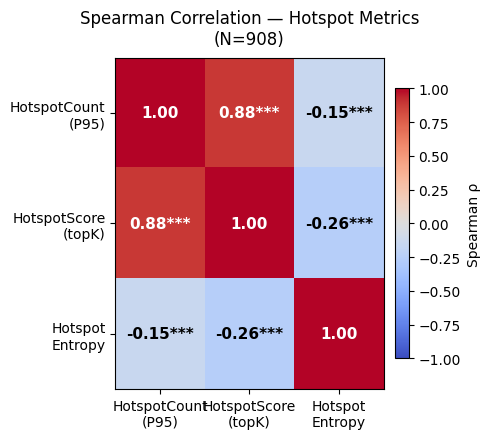

[OK] Heatmap     → outputs/run_20260123_154712/results/hotspot_spearman_heatmap.png


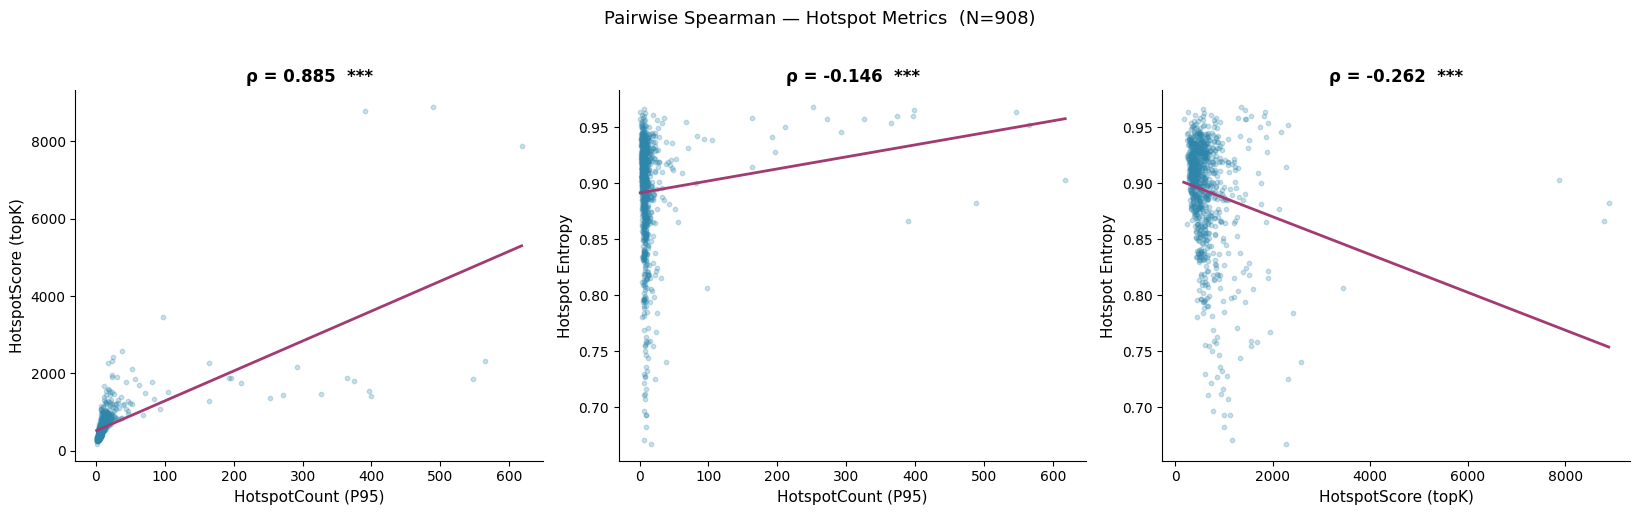

[OK] Scatter     → outputs/run_20260123_154712/results/hotspot_spearman_scatter_matrix.png


In [ ]:
# =========================================================
# 12C) SPEARMAN CORRELATION — hotspot metrics against each other
#      Gera: heatmap anotado + scatter matrix + TSV
#      Outputs: hotspot_spearman_corr_matrix.tsv
#              hotspot_spearman_pval_matrix.tsv
#              hotspot_spearman_heatmap.png
#              hotspot_spearman_scatter_matrix.png
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

RES_DIR = globals().get("RES_DIR") or globals().get("RESULTS_DIR") or os.path.join(globals().get("BASE_OUT_DIR", "."), "results")
os.makedirs(RES_DIR, exist_ok=True)

if "hotspot_metrics_df" not in globals():
    raise RuntimeError("hotspot_metrics_df not found. Run cell 12 first.")

HOTSPOT_METRICS = ["HotspotCount_P95", "HotspotScore_topK", "HotspotEntropy"]
LABELS = {
    "HotspotCount_P95":  "HotspotCount\n(P95)",
    "HotspotScore_topK": "HotspotScore\n(topK)",
    "HotspotEntropy":    "Hotspot\nEntropy"
}

df_hs = hotspot_metrics_df[HOTSPOT_METRICS].dropna().copy()
n = len(df_hs)
print(f"[INFO] N patients with all 3 metrics: {n}")

# ----------------------------------------------------------
# 1) Spearman correlation matrix (rho + p-value)
# ----------------------------------------------------------
cols = HOTSPOT_METRICS
rho_mat  = pd.DataFrame(np.nan, index=cols, columns=cols)
pval_mat = pd.DataFrame(np.nan, index=cols, columns=cols)

for i, c1 in enumerate(cols):
    for j, c2 in enumerate(cols):
        if i == j:
            rho_mat.loc[c1, c2]  = 1.0
            pval_mat.loc[c1, c2] = 0.0
        elif i < j:
            r, p = spearmanr(df_hs[c1], df_hs[c2])
            rho_mat.loc[c1, c2]  = rho_mat.loc[c2, c1]  = r
            pval_mat.loc[c1, c2] = pval_mat.loc[c2, c1] = p

# Exporta TSV
tsv_path = os.path.join(RES_DIR, "hotspot_spearman_corr_matrix.tsv")
rho_mat.to_csv(tsv_path, sep="\t")
print(f"[OK] Matriz rho  → {tsv_path}")

pval_path = os.path.join(RES_DIR, "hotspot_spearman_pval_matrix.tsv")
pval_mat.to_csv(pval_path, sep="\t")
print(f"[OK] Matriz p    → {pval_path}")

# Imprime no log
print("\n=== Spearman ρ (hotspot metrics) ===")
for i, c1 in enumerate(cols):
    for j, c2 in enumerate(cols):
        if j > i:
            r = rho_mat.loc[c1, c2]
            p = pval_mat.loc[c1, c2]
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
            print(f"  {c1} vs {c2}: rho={r:.3f}, p={p:.2e} [{sig}]")

# ----------------------------------------------------------
# 2) Heatmap anotado
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 4.5))

rho_vals = rho_mat.values.astype(float)
im = ax.imshow(rho_vals, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman ρ")

tick_labels = [LABELS[c] for c in cols]
ax.set_xticks(range(len(cols))); ax.set_xticklabels(tick_labels, fontsize=10)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(tick_labels, fontsize=10)

for i in range(len(cols)):
    for j in range(len(cols)):
        r = rho_vals[i, j]
        p = pval_mat.values[i, j]
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        txt = f"{r:.2f}{sig}" if i != j else "1.00"
        color = "white" if abs(r) > 0.6 else "black"
        ax.text(j, i, txt, ha="center", va="center", fontsize=11,
                fontweight="bold", color=color)

ax.set_title(f"Spearman Correlation — Hotspot Metrics\n(N={n})", fontsize=12, pad=10)
plt.tight_layout()

heatmap_path = os.path.join(RES_DIR, "hotspot_spearman_heatmap.png")
plt.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close()
print(f"[OK] Heatmap     → {heatmap_path}")

# ----------------------------------------------------------
# 3) Scatter matrix (pairwise) with trend line
#    FIXED: uses simple linear regression for the trend line
# ----------------------------------------------------------
pairs = [(cols[i], cols[j]) for i in range(len(cols)) for j in range(len(cols)) if j > i]
n_pairs = len(pairs)  # = 3

fig, axes = plt.subplots(1, n_pairs, figsize=(5.5 * n_pairs, 5))
if n_pairs == 1:
    axes = [axes]

scatter_kw = dict(alpha=0.25, s=10, color="#2E86AB", rasterized=True)
trend_kw   = dict(color="#A23B72", linewidth=2)

for ax, (cx, cy) in zip(axes, pairs):
    x = df_hs[cx].values
    y = df_hs[cy].values

    ax.scatter(x, y, **scatter_kw)

    # Simple linear regression line on the original data
    # (visualization of the overall trend; the Spearman ρ above already measures the monotonic relationship)
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.array([x.min(), x.max()])
    y_line = intercept + slope * x_line
    ax.plot(x_line, y_line, **trend_kw)

    r  = rho_mat.loc[cx, cy]
    p  = pval_mat.loc[cx, cy]
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.set_xlabel(LABELS[cx].replace("\n", " "), fontsize=11)
    ax.set_ylabel(LABELS[cy].replace("\n", " "), fontsize=11)
    ax.set_title(f"ρ = {r:.3f}  {sig}", fontsize=12, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Pairwise Spearman — Hotspot Metrics  (N={n})", fontsize=13, y=1.02)
plt.tight_layout()

scatter_path = os.path.join(RES_DIR, "hotspot_spearman_scatter_matrix.png")
plt.savefig(scatter_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close()
print(f"[OK] Scatter     → {scatter_path}")

In [ ]:
# =========================================================
# 12D) DESCRIPTIVE STATISTICS — hotspot metrics
#      Outputs: hotspot_metrics_descriptive_stats.tsv
#              hotspot_metrics_descriptive_stats_by_sex.tsv
# =========================================================
import os
import numpy as np
import pandas as pd

RES_DIR = globals().get("RES_DIR") or globals().get("RESULTS_DIR") or os.path.join(globals().get("BASE_OUT_DIR", "."), "results")
os.makedirs(RES_DIR, exist_ok=True)

if "hotspot_metrics_df" not in globals():
    raise RuntimeError("hotspot_metrics_df not found. Run cell 12 first.")

HOTSPOT_METRICS = ["HotspotCount_P95", "HotspotScore_topK", "HotspotEntropy"]

# ----------------------------------------------------------
# 1) Global descriptive statistics (whole cohort)
# ----------------------------------------------------------
df_hs = hotspot_metrics_df[HOTSPOT_METRICS].copy()

global_stats = pd.DataFrame({
    "metric":   HOTSPOT_METRICS,
    "n":        [int(df_hs[c].notna().sum()) for c in HOTSPOT_METRICS],
    "n_missing":[int(df_hs[c].isna().sum())  for c in HOTSPOT_METRICS],
    "mean":     [df_hs[c].mean()    for c in HOTSPOT_METRICS],
    "std":      [df_hs[c].std()     for c in HOTSPOT_METRICS],
    "min":      [df_hs[c].min()     for c in HOTSPOT_METRICS],
    "q25":      [df_hs[c].quantile(0.25) for c in HOTSPOT_METRICS],
    "median":   [df_hs[c].median()  for c in HOTSPOT_METRICS],
    "q75":      [df_hs[c].quantile(0.75) for c in HOTSPOT_METRICS],
    "max":      [df_hs[c].max()     for c in HOTSPOT_METRICS],
    "iqr":      [df_hs[c].quantile(0.75) - df_hs[c].quantile(0.25) for c in HOTSPOT_METRICS],
})

# Rounding: counts with 0 decimals, entropy/scores with 4 decimals
def _fmt(metric, value):
    if pd.isna(value): return value
    if metric == "HotspotCount_P95":
        return round(value, 1)
    if metric == "HotspotScore_topK":
        return round(value, 1)
    if metric == "HotspotEntropy":
        return round(value, 4)
    return round(value, 4)

for c in ["mean","std","min","q25","median","q75","max","iqr"]:
    global_stats[c] = global_stats.apply(lambda row: _fmt(row["metric"], row[c]), axis=1)

print("=== Descriptive statistics — full cohort ===")
print(global_stats.to_string(index=False))

global_path = os.path.join(RES_DIR, "hotspot_metrics_descriptive_stats.tsv")
global_stats.to_csv(global_path, sep="\t", index=False)
print(f"\n[OK] Global statistics → {global_path}")

# ----------------------------------------------------------
# 2) Sex-stratified statistics (when available)
# ----------------------------------------------------------
# Try to locate a sex column in the namespace
sex_col_candidates = ["sex", "demographic.gender", "Sex", "gender"]
sex_source_df = None
sex_col_name = None

# Preferred path: does hotspot_metrics_df already have a sex column?
for col in sex_col_candidates:
    if col in hotspot_metrics_df.columns:
        sex_source_df = hotspot_metrics_df
        sex_col_name = col
        break

# Otherwise, try merging with os_df or features_df
if sex_source_df is None and "__JOIN_ID__" in hotspot_metrics_df.columns:
    for ref_name in ["os_df", "features_df", "demographics_df"]:
        ref = globals().get(ref_name)
        if ref is None: continue
        for col in sex_col_candidates:
            if col in ref.columns and "__JOIN_ID__" in ref.columns:
                merged = hotspot_metrics_df[["__JOIN_ID__"] + HOTSPOT_METRICS].merge(
                    ref[["__JOIN_ID__", col]], on="__JOIN_ID__", how="left"
                )
                sex_source_df = merged
                sex_col_name = col
                print(f"[INFO] Sex recovered from '{ref_name}' (column '{col}') via __JOIN_ID__")
                break
        if sex_source_df is not None:
            break

if sex_source_df is None:
    print("\n[WARN] Sex column not found in namespace. Skipping stratification.")
else:
    sex_norm = sex_source_df[sex_col_name].astype(str).str.lower().str.strip()
    rows = []
    for sex_value in sorted(sex_norm.dropna().unique()):
        sub = sex_source_df[sex_norm == sex_value]
        for metric in HOTSPOT_METRICS:
            vals = sub[metric].dropna()
            if len(vals) == 0: continue
            rows.append({
                "sex":      sex_value,
                "metric":   metric,
                "n":        int(len(vals)),
                "mean":     _fmt(metric, vals.mean()),
                "std":      _fmt(metric, vals.std()),
                "median":   _fmt(metric, vals.median()),
                "q25":      _fmt(metric, vals.quantile(0.25)),
                "q75":      _fmt(metric, vals.quantile(0.75)),
                "min":      _fmt(metric, vals.min()),
                "max":      _fmt(metric, vals.max()),
            })

    by_sex_stats = pd.DataFrame(rows)
    print(f"\n=== Descriptive statistics — stratified by '{sex_col_name}' ===")
    print(by_sex_stats.to_string(index=False))

    by_sex_path = os.path.join(RES_DIR, "hotspot_metrics_descriptive_stats_by_sex.tsv")
    by_sex_stats.to_csv(by_sex_path, sep="\t", index=False)
    print(f"\n[OK] Statistics by sex → {by_sex_path}")

=== Descriptive statistics — full cohort ===
           metric   n  n_missing     mean      std      min      q25   median      q75       max      iqr
 HotspotCount_P95 908          0  16.2000  51.6000   1.0000   5.0000   7.0000  11.0000  618.0000   6.0000
HotspotScore_topK 908          0 639.9000 571.2000 177.0000 397.0000 521.0000 682.2000 8887.0000 285.2000
   HotspotEntropy 908          0   0.8931   0.0487   0.6674   0.8755   0.9059   0.9256    0.9679   0.0501

[OK] Global statistics → outputs/run_20260123_154712/results/hotspot_metrics_descriptive_stats.tsv
[INFO] Sex recovered from 'os_df' (column 'demographic.gender') via __JOIN_ID__

=== Descriptive statistics — stratified by 'demographic.gender' ===
   sex            metric   n     mean      std   median      q25      q75      min       max
female  HotspotCount_P95 356  15.7000  43.2000   8.0000   6.0000  11.0000   2.0000  489.0000
female HotspotScore_topK 356 668.8000 561.3000 536.0000 422.2000 720.0000 259.0000 8887.0000
fem

In [ ]:
# =========================================================
# ✅ FINAL) ZIP EVERYTHING FROM THE WORKSPACE + DOWNLOAD (COLAB)
# =========================================================
import os, zipfile, pathlib, datetime

# 1) Define your project "roots" (prioritizes the pipeline folders)
roots = []
for k in ["BASE_OUT_DIR", "OUT_DIR", "RES_DIR", "LOG_DIR", "RAW_DIR", "PROC_DIR", "PROCESSED_DIR", "RESULTS_DIR"]:
    v = globals().get(k)
    if isinstance(v, str) and v and os.path.exists(v):
        roots.append(os.path.abspath(v))

# Fallback: se nada estiver definido, usa /content (Colab) ou cwd
if not roots:
    roots = ["/content"] if os.path.exists("/content") else [os.getcwd()]

# Remove duplicados mantendo ordem
seen = set()
roots = [r for r in roots if not (r in seen or seen.add(r))]

# 2) Zip name
ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
zip_path = os.path.join("/content" if os.path.exists("/content") else os.getcwd(),
                        f"workspace_backup_{ts}.zip")

# 3) What to exclude (to avoid blowing up size/time via cache/drive)
EXCLUDE_DIRS = {
    "/content/drive",              # evita zipar o Drive inteiro
    "/content/sample_data",
}
EXCLUDE_PARTS = {".ipynb_checkpoints", "__pycache__", ".cache", ".config", ".git"}

def should_skip(path: str) -> bool:
    ap = os.path.abspath(path)
    for ed in EXCLUDE_DIRS:
        if ap.startswith(os.path.abspath(ed) + os.sep) or ap == os.path.abspath(ed):
            return True
    parts = set(pathlib.Path(ap).parts)
    return len(parts.intersection(EXCLUDE_PARTS)) > 0

# 4) Zipar
count = 0
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
    for root in roots:
        root = os.path.abspath(root)
        if should_skip(root):
            continue
        for dirpath, dirnames, filenames in os.walk(root):
            # filter excluded directories
            dirnames[:] = [d for d in dirnames if not should_skip(os.path.join(dirpath, d))]
            if should_skip(dirpath):
                continue

            for fn in filenames:
                fp = os.path.join(dirpath, fn)
                if should_skip(fp):
                    continue

                # relative path inside the zip (keeps structure)
                arcname = os.path.relpath(fp, start=os.path.dirname(root))
                try:
                    zf.write(fp, arcname=arcname)
                    count += 1
                except Exception as e:
                    print(f"[WARN] could not add: {fp} | {e}")

size_mb = os.path.getsize(zip_path) / (1024**2)
print(f"[OK] ZIP criado: {zip_path}")
print(f"[OK] Files included: {count}")
print(f"[OK] Tamanho: {size_mb:.2f} MB")

# 5) Baixar (Colab)
try:
    from google.colab import files
    files.download(zip_path)
except Exception as e:
    print("[INFO] Could not trigger automatic download (outside Colab?).")
    print("Manually download the file:", zip_path)
    print("Detalhe:", str(e)[:200])


[OK] ZIP criado: /content/workspace_backup_20260518_190340.zip
[OK] Files included: 2334
[OK] Tamanho: 195.46 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>